# Clinical NLP over Italian Hospital Records 

*NLP4DH exam project.* End-to-end **Natural Language Processing (NLP)** pipeline over Italian hospital reports. Techniques: **regex extraction**, **lexical and dense candidate generation**, **zero-shot Named Entity Recognition (NER, via GLiNER)**, **rule-based context classification (ConText)**, **entity linking with abstention over the UMLS Metathesaurus**, a **symbolic alert engine**, an **RDF knowledge graph with SPARQL**, **neuro-symbolic tool-calling (Ollama)**.

**Architecture.** The pipeline is *Neuro | Symbolic*, Kautz Type 3: neural components map prose to symbols - condition mentions, UMLS concepts - and symbolic stages consume them, accepting, rejecting or abstaining on each candidate. Section 9 adds a *Neuro[Symbolic]* layer, Type 6: the neural component selects which symbolic operation to invoke and consumes its output.

> **Notebook structure**

> 0. Setup and data loading
> 1. Exploratory data analysis
> 2. Shared drug resources - AIFA catalog
> 3. Structured extraction and AIFA (ATC) linking - discharge therapy
> 4. Symbolic extraction and AIFA (ATC) linking - admission therapy
> 5. Anamnesis - zero-shot NER, ConText, UMLS (Unified Medical Language System) concept linking
> 6. Alert engine *(symbolic, deterministic)*
> 7. Evaluation against the manual gold - selection on 20 development patients, reporting on 30 held out
> 8. RDF knowledge graph, SPARQL & patient-level visualization 
> 9. End-to-end demonstration & local LLM with tool calling *(Kautz Type 6)*
> 10. Discussion


## Section 0 - Setup and data loading




In [1]:
# Standard library
import gc
import hashlib
import inspect
import json
import os
import random
import re
import textwrap
import time
from collections import Counter, defaultdict
from datetime import date
from itertools import combinations
from pathlib import Path

# Data analysis
import numpy as np
import pandas as pd

# NLP and machine learning
import requests
import spacy
import torch
from gliner import GLiNER
from medspacy.context import ConTextRule
from sentence_transformers import SentenceTransformer

# Evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_fscore_support, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from spacy import displacy

# RDF knowledge graph
from rdflib import Graph, Literal, Namespace, RDF, RDFS, URIRef, XSD
from rdflib.plugins.sparql import prepareQuery

# Local LLM (httpx carries the client's transport errors)
import httpx
import ollama

# Notebook display
from IPython.display import HTML, display

# The model libraries print progress bars and deprecation notices that add nothing to the output.
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except ImportError:
    pass

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except ImportError:
    pass


C:\Users\ileni\nlp4dh\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ANNOTATION_DIR = DATA_DIR / "annotations"
EXTERNAL_DATA_DIR = DATA_DIR / "external"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
ANNOTATION_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# UMLS Metathesaurus, through the UTS REST API. The release is pinned.
UMLS_VERSION = "2026AA"
UMLS_BASE_URL = "https://uts-ws.nlm.nih.gov/rest"
UMLS_API_KEY = os.getenv("UMLS_API_KEY")
UMLS_CACHE_DIR = EXTERNAL_DATA_DIR / "umls_cache"
UMLS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

UMLS_SEMANTIC_GROUP = "Disorders"   # applied by the API

# The semantic types inside that group. The API applies the restriction server-side, so this set is
# NOT a linking decision and no mention is rejected by it: it is used once, in the Section 7.5
# summary, to count how many linked concepts fall outside the expected types. A non-zero count would
# mean the server-side restriction did not hold.
UMLS_DISORDER_SEMANTIC_TYPES = {
    "T047",  # Disease or Syndrome
    "T048",  # Mental or Behavioral Dysfunction
    "T191",  # Neoplastic Process
    "T046",  # Pathologic Function
    "T184",  # Sign or Symptom
    "T033",  # Finding
    "T019",  # Congenital Abnormality
    "T020",  # Acquired Abnormality
    "T037",  # Injury or Poisoning
    "T190",  # Anatomical Abnormality
    "T049",  # Cell or Molecular Dysfunction
    "T050",  # Experimental Model of Disease
}

# Models
SPACY_MODEL = "it_core_news_lg"
GLINER_MODEL = "urchade/gliner_multi-v2.1"
EMBEDDER_MODEL = "intfloat/multilingual-e5-small"
OLLAMA_MODEL = "qwen2.5:3b-instruct"

# Decision thresholds. Every stage that can abstain has a similarity floor and, where a wrong
# neighbour is plausible, a margin to the best rival of a different entity.
NER_THRESHOLD = 0.45          # GLiNER span confidence

NGRAM_SIZE = 3                # character n-gram used by every lexical index
DRUG_LEXICAL_SIM = 0.7        # brand-name trigram floor
DRUG_LEXICAL_MARGIN = 0.06    # margin to the best different-ingredient candidate

# UMLS entity linking. Both values are read off the score distribution in Section 5, BEFORE the
# held-out gold is opened - they are not tuned against it. Section 7.5 reports what they achieve on
# gold the linker had never seen. They are set conservatively, which favours abstention over a wrong
# concept.
UMLS_COSINE_FLOOR = 0.80      # cosine below which a contextual decision is refused
UMLS_COSINE_MARGIN = 0.005    # gap to the runner-up; below it the two concepts are treated as tied
UMLS_MAX_CANDIDATES = 15      # unique CUIs carried from candidate generation into ranking

# The two outcomes that count as a link. They are kept apart because they were reached differently:
# one by an exact API match, one by contextual ranking.
UMLS_LINKED_STATUSES = ("linked_exact", "linked_contextual")

pd.set_option("display.max_colwidth", 90)

print(f"project root: {PROJECT_ROOT.name}/ | device: {DEVICE} | seed: {RANDOM_SEED}")
print(f"UMLS release {UMLS_VERSION} | API key configured: {UMLS_API_KEY is not None} | "
      f"cache: {UMLS_CACHE_DIR.relative_to(PROJECT_ROOT)}")


project root: nlp4dh/ | device: cuda | seed: 42
UMLS release 2026AA | API key configured: True | cache: data\external\umls_cache


**UMLS access**

Entity linking uses the UMLS Metathesaurus through the UTS REST API. Using it requires a personal
UMLS licence and an API key, which the notebook reads from the environment and never stores:

```bash
export UMLS_API_KEY="your-key"          # Linux, macOS
```

```powershell
$env:UMLS_API_KEY="your-key"            # Windows PowerShell, current session only
setx UMLS_API_KEY "your-key"            # Windows, persistent
```

**After `setx`, Jupyter or the IDE must be restarted.** A process inherits its environment when it
starts, so a kernel that was already running will not see the new variable. The notebook reads the
key only through `os.getenv`. 

In [3]:
# Raw dataset: 857 patients, three reports each.
with open(DATA_DIR / "pazienti_con_terapia_uscita_testuale.json", encoding="utf-8") as f:
    patients = json.load(f)

# The three report types per patient, named as they appear in the source records.
T_ANAMNESI = "Anamnesi"
T_INGRESSO = "Terapia medica all'ingresso"
T_DIMISSIONE = "Terapia alla Dimissione"

def report_of(patient, report_type):
    """Return the full report record of a given type, or None if the patient has no such report."""
    for report in patient["referti"]:
        if report["tipo"] == report_type:
            return report

    return None

def report_text(patient, report_type):
    """Free text of a given report type, empty string when the report is missing."""
    report = report_of(patient, report_type)

    return (report["testo"] or "") if report else ""

def report_year(patient, report_type):
    """Year of the report's own date ('03.03.2026 10:30' -> 2026), or None."""
    report = report_of(patient, report_type)
    match = re.search(r"\b(\d{4})\b", str(report["data"])) if report and report.get("data") else None

    return int(match.group(1)) if match else None

def wrap(text, width=100):
    """Wrap long free text for readable output, keeping the existing line breaks."""
    return "\n".join(textwrap.fill(line, width=width) if line.strip() else line
                     for line in str(text).splitlines())

print(f"loaded {len(patients)} patients from {DATA_DIR.name}/")


loaded 857 patients from data/


## Section 1 - Exploratory data analysis

**Goal.** Inspect the data before building anything: patient and report counts, free-text length per report type, and the *critical cases* every downstream step must survive (empty therapies, combination drugs, non-drug lines such as oxygen / NIV / CPAP).

In [4]:
rows = []

for p in patients:
    for r in p["referti"]:
        rows.append({"tipo": r["tipo"], "len_chars": len(r["testo"] or "")})

reports_df = pd.DataFrame(rows)

n_patients = len(patients)
n_exactly3 = sum(len(p["referti"]) == 3 for p in patients)
print(f"patients: {n_patients} | patients with exactly 3 reports: {n_exactly3}")

length_stats = (reports_df.groupby("tipo")["len_chars"]
                .agg(["count", "min", "median", "mean", "max"])
                .round(0).astype(int))
print("Text length in characters per report type (count = number of reports):")
length_stats


patients: 857 | patients with exactly 3 reports: 857
Text length in characters per report type (count = number of reports):


,count,min,median,mean,max
tipo,,,,,
Anamnesi,857,222,1693,2239,15968
Terapia alla Dimissione,857,15,649,679,2281
Terapia medica all'ingresso,857,4,284,318,1899


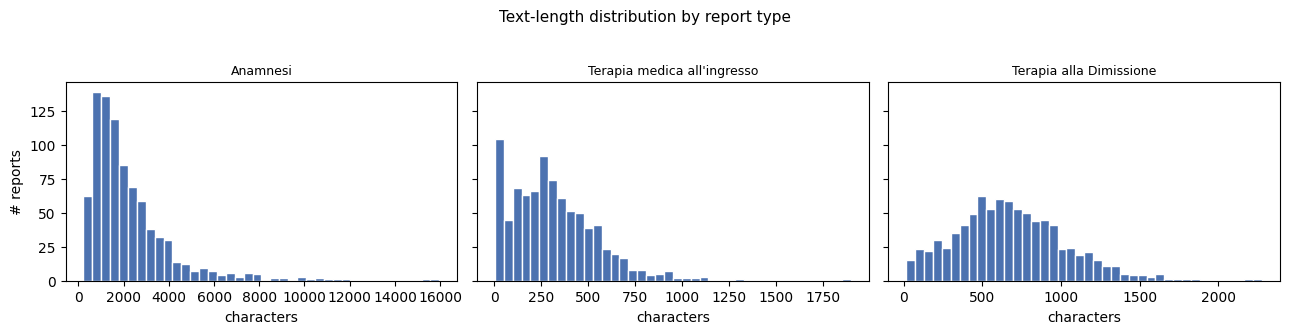

In [5]:
# Text-length distribution per report type

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)

for ax, tipo in zip(axes, [T_ANAMNESI, T_INGRESSO, T_DIMISSIONE]):
    vals = reports_df.loc[reports_df.tipo == tipo, "len_chars"]
    ax.hist(vals, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(tipo, fontsize=9)
    ax.set_xlabel("characters")

axes[0].set_ylabel("# reports")
fig.suptitle("Text-length distribution by report type", y=1.03, fontsize=11)
plt.tight_layout()
plt.show()


In [6]:
# Representative examples, incl. the critical cases downstream steps must handle
def show(title, text, width=350):
    body_text = text[:width] + ("…" if len(text) > width else "")
    print(f"### {title}\n{wrap(body_text)}\n")

# Structured discharge line (near-template) + combination drug (Clopidogrel/ASA):
show("Terapia alla Dimissione - structured template + combination drug",
     report_text(patients[0], T_DIMISSIONE))

# Semi-structured ingress line ('Nome: dose forma /die (ore N)'):
show("Terapia medica all'ingresso - semi-structured", report_text(patients[0], T_INGRESSO))

# Semi-structured ingress: bare brand-name list "al bisogno" (no doses/template):
show("Terapia medica all'ingresso - semi-structured (brand-name list)",
     report_text(next(p for p in patients if p["encOid"] == 10237923), T_INGRESSO))

# Edge 1: empty home therapy.
ex_empty = next(p for p in patients if "essuna terapia" in report_text(p, T_INGRESSO))
show("EDGE - empty home therapy", report_text(ex_empty, T_INGRESSO))

# Edge 2: non-drug line (oxygen / NIV / CPAP) among drugs - must be filtered.
ex_o2 = next(p for p in patients if re.search(r"Ossigeno|NIV|CPAP", report_text(p, T_INGRESSO)))
show("EDGE - non-drug lines (O2/NIV/CPAP) among drugs", report_text(ex_o2, T_INGRESSO))

# Edge 3: bare description, no dose/structure.
ex_bare = next(p for p in patients
               if not re.search(r"\d", report_text(p, T_INGRESSO))
               and "essuna" not in report_text(p, T_INGRESSO)
               and len(report_text(p, T_INGRESSO)) > 10)
show("EDGE - bare free-text, no doses", report_text(ex_bare, T_INGRESSO))


### Terapia alla Dimissione - structured template + combination drug
"Acido folico (Folina cps. molli 5 mg): da assumere 5 mg (ore 15)" "Tiamina (Benerva cpr.gastr. 300
mg): da assumere 300 mg (ore 15)" "Colecalciferolo (Annova cp.riv. 7000 UI): da assumere 7000 UI
(ore 13), ogni 6 giorni (a partire da 2 giorni fa)" "Clopidogrel/acido acetilsalicilico (Duoplavin
cp.riv. 75 mg): da assumere 75/100 mg (ore 19)" "Panto…

### Terapia medica all'ingresso - semi-structured
Atorvastatina sa: 80 mg cp.riv. /die (ore 22) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 12) ;
Omnic: 0,4 mg cps. rigide rm /die (ore 22) ; Folina: 5 mg cps. molli /die (ore 15) ; Benerva: 300 mg
cpr.gastr. /die (ore 15) ; Annova: 7000 UI cp.riv. (ore 13) ogni 6 giorni ;

### Terapia medica all'ingresso - semi-structured (brand-name list)
Al bisogno assume: Normix, Mesalazina, Flexiban, Arcoxia;

### EDGE - empty home therapy
Nessuna terapia domiciliare.

### EDGE - non-drug lines (O2/NIV/CPAP) among drugs
Rosumibe: 10/10 

In [7]:
# Representative anamnesis examples
def patient_oid(p):
    return p["encOid"] if isinstance(p, dict) and "encOid" in p else p

def first_patient_with(pattern, *, exclude=None, forbid=None, min_len=None):
    exclude = set() if exclude is None else {patient_oid(p) for p in exclude}
    forbid = [] if forbid is None else list(forbid)

    for p in patients:
        if patient_oid(p) in exclude:
            continue

        txt = report_text(p, T_ANAMNESI) or ""

        if min_len is not None and len(txt) < min_len:
            continue

        if forbid and any(re.search(rx, txt, flags=re.IGNORECASE) for rx in forbid):
            continue

        if re.search(pattern, txt, flags=re.IGNORECASE):
            return p

    return None

def sentence_with(text, pattern, width=260):
    txt = text or ""
    sentences = re.split(r"(?<=[.!?])\s+", txt)

    for sent in sentences:
        if re.search(pattern, sent, flags=re.IGNORECASE):
            return sent.strip()

    match = re.search(pattern, txt, flags=re.IGNORECASE)

    if not match:
        return txt[:width] + ("…" if len(txt) > width else "")

    start = max(0, match.start() - width // 2)
    end = min(len(txt), match.end() + width // 2)
    prefix = "…" if start > 0 else ""
    suffix = "…" if end < len(txt) else ""
    return f"{prefix}{txt[start:end]}{suffix}"




In [8]:
# Examples of the four phenomena the context stage has to handle.
ex_narrative = next(
    p for p in patients
    if len(report_text(p, T_ANAMNESI) or "") > 300
    and not re.search(
        r"\b(pregress\w*|remot\w*|familiarit\w*|non\s+familiarit\w*|nega\b|esclu\w*|in passato)\b",
        report_text(p, T_ANAMNESI) or "",
        flags=re.IGNORECASE,
    )
)
show("Anamnesi - narrative overview", report_text(ex_narrative, T_ANAMNESI))

# 2) Negation: different patient; print the sentence with the negated finding.
ex_negated = first_patient_with(
    r"\bNega\b|\bnon\s+ha\s+mostrato\s+evidenza\b|\bE'?\s+stata\s+quindi\s+esclusa\b|\bnon\s+presenta\b",
    exclude=[ex_narrative],
)

if ex_negated is not None:
    print("### Anamnesi - negated condition")
    print(wrap(sentence_with(report_text(ex_negated, T_ANAMNESI), r"\bNega\b|\bnon\s+ha\s+mostrato\s+evidenza\b|\bE'?\s+stata\s+quindi\s+esclusa\b|\bnon\s+presenta\b")))
    print()

# 3) Family history: condition belongs to relatives, not the patient.
ex_family = first_patient_with(
    r"\bfamiliarit\w*|madre|padre|fratell\w*|sorell\w*",
    exclude=[ex_narrative],
    forbid=[r"\bnega\b|\bnon\s+(?:ha|presenta|riferisce|si\s+evidenzia|si\s+documenta)\b|pregress\w*|remot\w*|precedent\w*|in passato\b"],
)

if ex_family is not None:
    print("### Anamnesi - family history")
    print(wrap(sentence_with(report_text(ex_family, T_ANAMNESI), r"\bfamiliarit\w*|madre|padre|fratell\w*|sorell\w*")))
    print()

# 4) Historical / remote history: condition is in the past.
ex_historical = first_patient_with(
    r"\b(pregress\w*|remot\w*|precedent\w*|in passato|anamnesi patologica remota)\b",
    exclude=[ex_narrative, ex_family],
    forbid=[r"\bnega\b|\bnon\s+(?:ha|presenta|riferisce|si\s+evidenzia|si\s+documenta)\b|familiarit\w*|madre|padre|fratell\w*|sorell\w*"],
)

if ex_historical is not None:
    print("### Anamnesi - historical / remote history")
    print(wrap(sentence_with(report_text(ex_historical, T_ANAMNESI), r"\b(pregress\w*|remot\w*|precedent\w*|in passato|anamnesi patologica remota)\b")))
    print()

# 5) Mixed cue: center on the family-history term so the family signal shows.
ex_mixed = first_patient_with(
    r"\bnon\s+familiarit\w*|\bfamiliarit\w*",
    exclude=[ex_narrative, ex_family, ex_historical],
)

if ex_mixed is not None:
    print("### Anamnesi - mixed cue (family vs negation)")
    print(wrap(sentence_with(report_text(ex_mixed, T_ANAMNESI), r"\bnon\s+familiarit\w*|\bfamiliarit\w*")))
    print()


### Anamnesi - narrative overview
Fattori di rischio: Ipertensione arteriosa essenziale, ipercolesterolemia, Obesita si. Barriera
linguistica totale. 19/12/25 intervento di TEA carotidea a sinistra con interposizione di tratto di
safena sinistra. Residua stenosi del 50% della carotide destra. Polmonite bilaterale ricoverato in
Albania. Durante il ricovero eseguiva una TC con riscon…

### Anamnesi - negated condition
Nega allergia a farmaci e/o alimenti.

### Anamnesi - family history
AF: lontana familiarita per CHD non meglio definita.

### Anamnesi - historical / remote history
Allergie e intolleranze: Allergie e intolleranze non note Anamnesi Remota: Ipertensione arteriosa.

### Anamnesi - mixed cue (family vs negation)
Nega familiarita per diabete o altre cardiopatie congenite.




| Observation | Consequence for the pipeline |
|---|---|
| All 857 patients have exactly the 3 expected report types | Retrieve by type; no missing-report handling. |
| *Terapia alla Dimissione* follows a near-fixed template `Principio (Nome forma dosaggio): da assumere …` | **Section 3** extracts it with regex. |
| *Terapia medica all'ingresso* is short and heterogeneous (semi-structured, bare lists, empty, or non-drug) | **Section 4** needs a symbolic candidate extractor (AIFA-catalog gazetteer, exact longest-match). |
| *Anamnesi* is long, narrative Italian prose | **Section 5** needs NER + context (negation/family/temporal) over real syntax. |

## Section 2 - Shared drug resources (AIFA catalog)

### Knowledge sources

Seven external sources. Only DDInter and MED-RT assert a clinical fact; the others supply identity,
classification or integration.

| source | scope | clinical assertion |
|---|---|---|
| AIFA | Italian registry of commercial products and their active ingredients | none (registry) |
| ATC | drug class hierarchy; basis for class-level allergy matching | none (classification) |
| RxNorm | normalized drug identifiers (RxCUI) | none (vocabulary) |
| DDInter | drug-drug interactions and severity | yes |
| MED-RT | `ci_with` relation, drug to disease class | yes |
| UMLS | concept identity; aligns an Italian mention to a MeSH disease class | none |
| RDF / SPARQL | integration layer over the above | not a source |

Loaded here: AIFA, ATC, RxNorm. DDInter and MED-RT in Section 6, UMLS in Section 5, the graph in
Section 8.

### Input files

Three levels of the same registry: package, product name, active ingredient. The example column
follows one molecule.

| resource | example | supplies |
|---|---|---|
| `aifa/normalized/aifa_confezioni.parquet` (159,631 rows) | `XARATOR` / `10 MG COMPRESSE RIVESTITE CON FILM` -> `ATORVASTATINA CALCIO TRIIDRATO` | package -> active-ingredient map; source of `label_to_ingredients`. Only file recording the components of a combination product (`PAPAVERINA CLORIDRATO/BELLADONNA`) |
| `aifa_products.csv` (10,504 rows) | `ATORVASTATINA ABC` -> `C10AA05` | product-name catalog with product-level ATC; the brand half of the gazetteer vocabulary |
| `ingredient_crosswalk.csv` (2,304 rows) | `Atorvastatina` -> key `atorvastatina`, `C10AA05`, ATC-4 `C10AA`, RxCUI `83367`, `DDInter133` | ATC, ATC-4 and, where present, RxCUI and DDInter. Sole location of the external identifiers; `lookup_key` is unique, so one lookup returns all of them |

The package label carries the salted, hydrated form, the product catalog a generic name and its code,
the crosswalk the canonical molecule and its identifiers. The reducers below map the first onto the
third. Extraction operates on names; every rule joins on the ingredient.

- **Candidate-based catalog.** A normalized key maps to the *list* of products sharing it
  (`DRUG_CANDIDATES`); an ambiguous label is disambiguated or abstained on.

In [9]:
# Shared drug resources - AIFA catalog

# resources (given inputs, resolved once over the full AIFA registry rather than over this cohort)
aifa_products = pd.read_csv(EXTERNAL_DATA_DIR / "aifa_products.csv")            # product label -> ATC
ingredient_crosswalk = pd.read_csv(EXTERNAL_DATA_DIR / "ingredient_crosswalk.csv")   # ingredient -> codes, unique lookup_key
aifa_packages = pd.read_parquet(EXTERNAL_DATA_DIR / "aifa" / "normalized" / "aifa_confezioni.parquet")   # package -> active ingredients

# normalization shared by both therapy sections
def normalize_text(x): return re.sub(r'\s+', ' ', str(x).lower().strip())

NON_PHARMA_THERAPY = re.compile(r'\b(ossigeno|NIV|CPAP|cannula nasale|maschera|ventil|microinfusore|'
                         r'insulinica|nutricomp|SNG|parenterale|simeox|acapella|pep[- ]?mask)', re.I)


Surface forms vary by salt, ester, hydrate and trailing dose or administration instruction. Five
reducers map them onto the keys used downstream. They are not interchangeable: each targets a
different dictionary.

| function | removes | key into | `Atorvastatina calcio` -> |
|---|---|---|---|
| `normalize_text` | case, whitespace | `DRUG_CANDIDATES`, catalog of product names | `atorvastatina calcio` |
| `normalize_drug_key` | + salts, hydrates, dose and instruction tails | `KB_ATC` / `KB_ATC4` / `KB_RXCUI` / `KB_DDI`, the crosswalk | `atorvastatina` |
| `ingredient_identity` | + adduct tails; uppercases | `label_to_ingredients`, molecule identity | `ATORVASTATINA` |
| `display_name` | dose and instruction tail only; keeps case | none - display form | `Atorvastatina calcio` |
| `char_ngrams` | nothing; emits a trigram set | lexical fallback index | - |

`normalize_text` and `normalize_drug_key` diverge by design. The catalog key must match the
AIFA-registered name, since `Atorvastatina calcio` is a registered product; the crosswalk key must
collapse the salt, since two salts of one molecule interact identically and every rule joins on the
molecule.

One molecule, four surface forms:

| written as | `normalize_text` | `normalize_drug_key` | `ingredient_identity` | `display_name` |
|---|---|---|---|---|
| `Atorvastatina` | `atorvastatina` | `atorvastatina` | `ATORVASTATINA` | `Atorvastatina` |
| `Atorvastatina calcio` | `atorvastatina calcio` | `atorvastatina` | `ATORVASTATINA` | `Atorvastatina calcio` |
| `ATORVASTATINA CALCIO TRIIDRATO` | `atorvastatina calcio triidrato` | `atorvastatina` | `ATORVASTATINA` | `ATORVASTATINA CALCIO TRIIDRATO` |
| `Atorvastatina calcio 20 mg 1 cp la sera` | `atorvastatina calcio 20 mg 1 cp la sera` | `atorvastatina` | `ATORVASTATINA CALCIO 20 MG 1 CP LA SERA` | `Atorvastatina calcio` |

`normalize_drug_key` reduces all four forms to `atorvastatina`, which is what makes the identifier
lookup work on free text. `ingredient_identity` does not strip posology: it is applied to catalog
labels, which carry none.

The assertions below check that key and display form agree on the ingredient.

In [10]:
# salt / hydrate / ambiguous-ion stripping so a mention and its AIFA ingredient reduce to the same base
# name. Two deletion mechanisms, kept apart on purpose: SALT_OR_ESTER and HYDRATE remove a token wherever
# it occurs; SALT_ION_AMBIG is position-aware. 

# 1. counterions that only ever appear as a salt/ester -> safe to drop anywhere in the name
SALT_OR_ESTER = re.compile(r'\b(cloridrato|idrocloruro|besilato|mesilato|maleato|fumarato|emifumarato|'
                         r'tartrato|succinato|solfato|acetato|dipropionato|furoato|valerato|nitrato|'
                         r'fosfato|citrato|bromuro|sodico|sodica|calcico|potassico)\b', re.I)

# 2. hydration state: any -idrato suffix + anidro
HYDRATE = re.compile(r'\b\w*idrato\b|\banidro\b', re.I)

# 3. ambiguous ions (a counterion OR the active ingredient): dropped only as "[sale] di <ion>" or as a
#    trailing counterion, never as a leading active - "calcio carbonato" keeps calcio, "atorvastatina
#    calcio" drops it. Surface position is the only available signal; it disagrees with the chemical role
#    only in rare leading-counterion names (documented in Section 10).
SALT_ION_AMBIG = re.compile(r'\b(?:sale\s+)?di\s+(?:sodio|potassio|calcio|magnesio|zinco)\b'
                             r'|\s+(?:sodio|potassio|calcio|magnesio|zinco)(?=\s*$)', re.I)

def strip_salt(s):
    """Ingredient-key reduction: counterion + hydrate + ambiguous-ion stripping (the crosswalk key)."""
    s = SALT_OR_ESTER.sub(' ', s)
    s = HYDRATE.sub(' ', s)
    s = SALT_ION_AMBIG.sub(' ', s)
    return re.sub(r'\s+', ' ', s).strip()

# 4. ester / adduct forms the IDENTITY reducer strips as a suffix. They stay OUT of the crosswalk key:
#    an ester can be registered under an ATC code of its own, and the crosswalk key is what the
#    identifier lookup joins on.
ADDUCT_TAIL = re.compile(r"\s+(?:sale di \w+|arginina|erbumina|meglumina|trometamolo|tert[- ]?butilamina|"
                         r"calcium|propanediolo|propionato|xinafoato|embonato|pamoato)\b.*$", re.I)

def ingredient_identity(n):
    """Identity a label is matched on: salt, hydrate and adduct removed, uppercased."""
    b = strip_salt(str(n).upper())
    return (ADDUCT_TAIL.sub('', b).strip() or b)

DOSE_TAIL_KEY = re.compile(r'\b(?:mg|mcg|ml|ui|cp|cpr|cps|gtt|fl|bustin[ae]|bust|sciroppo|scir|soluz|'
                            r'gocce|nipio|fiale|fiala|die|ore|da assumere)\b.*$', re.I)

def normalize_drug_key(value):
    """Canonical ingredient key (lower, salt/dose stripped) - the crosswalk is keyed by this."""
    v = DOSE_TAIL_KEY.sub('', re.sub(r'\s+', ' ', str(value).strip()))
    v = re.sub(r'\s+\d+(?:[.,]\d+)?\s*$', '', v)                       # bare trailing dose number
    return (strip_salt(v.upper()) or str(value).strip().upper()).lower().strip()

def display_name(value):
    """Display form of an ingredient: the same dose/instruction tail that normalize_drug_key already
    ignores is removed from the printed name too, natural case kept. The discharge template sometimes
    leaves dose and instructions inside the active-ingredient field ("Pantoprazolo 20 mg 1 cp al
    mattino h 7"): the key ignored that tail, the printed name did not, so the two drifted apart.
    Only a tail introduced by a unit or instruction token is cut - a bare trailing number can be part
    of the name itself ("Macrogol 3350"), and the key, not the display form, is what lookups use."""
    raw = re.sub(r'\s+', ' ', str(value).strip())
    v = DOSE_TAIL_KEY.sub('', raw)

    if v != raw:                       # a unit or instruction token was found, so a number before it is a dose
        v = re.sub(r'\s+\d+(?:[.,]\d+)?\s*$', '', v)

    return v.strip(" ,;.-") or raw

# the display name and the key must never disagree about what the ingredient is
assert all(normalize_drug_key(display_name(x)) == normalize_drug_key(x)
           for x in ["Pantoprazolo 20 mg 1 cp al mattino h 7", "Acido acetilsalicilico 100 mg",
                     "Bisoprololo 2.5", "Macrogol 3350", "Warfarin sodico"])
assert display_name("Pantoprazolo 20 mg 1 cp al mattino h 7") == "Pantoprazolo"
assert display_name("Macrogol 3350") == "Macrogol 3350"

# a clean drug name: length > 2, has letters, no unit/instruction token or clock time (keeps "Macrogol 3350")
NOISY_DRUG_TEXT = re.compile(r"\b(?:ore|cp|cpr|cps|mg|mcg|gtt|fiala|fiale|bustin[ae]|die|prn|al bisogno)\b|"
                             r"\b\d[\d.,/]*\s*(?:g|ui|ml|fl)\b|\b\d{1,2}[:.]\d{2}\b", re.I)

def looks_like_drug_name(value):
    return (isinstance(value, str) and len(value.strip()) > 2
            and bool(re.search(r"[A-Za-zÀ-ÿ]", value)) and not NOISY_DRUG_TEXT.search(value))

assert not looks_like_drug_name("10 mg") and looks_like_drug_name("Macrogol 3350")


In [11]:
# brand/label -> active-ingredient set (combination-aware)
label_to_ingredients = {}

for den, active_ingredient in zip(aifa_packages.DENOMINAZIONE, aifa_packages.PA_ASSOCIATI):
    if pd.notna(den) and pd.notna(active_ingredient):
        label_to_ingredients.setdefault(ingredient_identity(den), set()).update(ingredient_identity(x) for x in str(active_ingredient).split("/"))

def ingredients_of(label): return label_to_ingredients.get(ingredient_identity(label), {ingredient_identity(label)})

# ONE catalog: normalized key -> LIST of distinct (label, atc, active-ingredient set)
DRUG_CANDIDATES = defaultdict(list)

def add_candidates(labels, atcs):
    for lab, atc in zip(labels.astype(str), atcs):
        catalog_key = normalize_text(lab)

        if len(catalog_key) < 4:
            continue

        candidate = (str(lab), (str(atc) if pd.notna(atc) else None), frozenset(ingredients_of(lab)))

        if candidate not in DRUG_CANDIDATES[catalog_key]:
            DRUG_CANDIDATES[catalog_key].append(candidate)

# `normalized_label` is deliberately not a fourth source: it is already
# normalize_text(preferred_label), which add_candidates applies anyway, so it would add no key -
# only a duplicate candidate under every product key. `lookup_key` IS a source: it is the
# salt-stripped form, and it reaches names the registered label does not.
add_candidates(aifa_products.preferred_label, aifa_products.atc_link)
add_candidates(ingredient_crosswalk.preferred_label, ingredient_crosswalk.atc_link)
add_candidates(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc_link)

def representative_atc(cands):
    atc_codes = Counter(x[1] for x in cands if x[1])
    return min(atc_codes.items(), key=lambda kv: (-kv[1], kv[0]))[0] if atc_codes else None


The crosswalk maps an ingredient key to its external identifiers. ATC codes are assigned per route of administration, so an ingredient name alone does not determine a code: alongside the single chosen code, candidate sets record every code still in play at the fifth and fourth ATC levels, and a separate map holds the code carried by a registered product.


In [12]:
# ingredient -> codes: the crosswalk is 1:1 (unique lookup_key), so one lookup yields ALL ids
ingredient_crosswalk["lookup_key"] = ingredient_crosswalk["lookup_key"].astype("string")
ingredient_crosswalk["RXCUI"] = pd.to_numeric(ingredient_crosswalk["RXCUI"], errors="coerce").astype("Int64")
ingredient_crosswalk["DDINTER"] = ingredient_crosswalk["DDINTER"].astype("string")
assert ingredient_crosswalk["lookup_key"].is_unique
KB_ATC   = dict(zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc_link))    # ingredient key -> ATC (level 5)
KB_ATC4  = dict(zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc4))        # ATC (level 4)
KB_LABEL = dict(zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.preferred_label))  # canonical name
KB_RXCUI = {k: int(v) for k, v in zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.RXCUI) if pd.notna(v)}
KB_DDI   = {str(k).strip(): v for k, v in zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.DDINTER) if pd.notna(v)}

# ATC is assigned per route of administration, so an ingredient NAME does not determine a code: the same
# substance is a different code inhaled, nasal or topical. KB_ATC above is the resource's single pick;
# these two make the ambiguity visible and give the one signal that can settle it.
KB_ATC_CANDIDATES = {k: [c for c in str(v).split("|") if c]                      # every code in play
                     for k, v in zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc_candidates)}
# The class-allergy rule tests `atc.startswith(prefix)` at ATC-4, so an ingredient whose ATC-4 is
# undetermined needs the complete set of possible level-4 codes in order to say so.
KB_ATC4_CANDIDATES = {k: [c for c in str(v).split("|") if c]
                      for k, v in zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc4_candidates)}
# A product is registered under ONE ATC, so a brand carries the route the ingredient name lost.
PRODUCT_ATC = {}

for lab, codes in zip(aifa_products.normalized_label, aifa_products.ATC.astype(str)):
    atc_codes = {c for c in codes.split("|") if c and c != "nan"}

    if len(atc_codes) == 1:
        PRODUCT_ATC.setdefault(str(lab), next(iter(atc_codes)))

n_ambiguous_atc = sum(len(v) > 1 for v in KB_ATC_CANDIDATES.values())
n_ambiguous_atc4 = sum(len(v) > 1 for v in KB_ATC4_CANDIDATES.values())
# Ambiguous ingredients whose candidate codes do not even share the ANATOMICAL MAIN GROUP (ATC level
# 1). For these, backing off to a coarser ATC level cannot help: the common ancestor is the root.
n_ambiguous_across_anatomy = sum(1 for v in KB_ATC_CANDIDATES.values() if len({c[0] for c in v if c}) > 1)
print(f"ingredients whose ATC the name cannot settle: {n_ambiguous_atc}/{len(KB_ATC_CANDIDATES)} "
      f"({n_ambiguous_atc / len(KB_ATC_CANDIDATES):.1%}), of which still undetermined at ATC-4: {n_ambiguous_atc4} "
      f"| products registered under one ATC: {len(PRODUCT_ATC)}")


ingredients whose ATC the name cannot settle: 214/2304 (9.3%), of which still undetermined at ATC-4: 189 | products registered under one ATC: 10343


Resolution happens in two steps. The gazetteer scans a segment for the longest catalog label starting at each token, keeping character offsets. The resolver then maps a name to its catalog candidates, collapses them when they agree on the active ingredient, and abstains otherwise.


In [13]:
# gazetteer (offset-preserving) + resolver
TOKEN_RE = re.compile("[A-Za-zÀ-ſ0-9']+")
MAX_GAZ_TOKENS = min(10, max((len(TOKEN_RE.findall(k)) for k in DRUG_CANDIDATES), default=5))

def gazetteer_spans(text):
    """Longest-match product/ingredient spans in a segment -> list of (span_text, start, end)."""
    toks = list(TOKEN_RE.finditer(text))
    low = [t.group(0).lower() for t in toks]
    out = []
    i = 0
    n = len(toks)

    while i < n:
        hit = next(((i, i + L) for L in range(min(MAX_GAZ_TOKENS, n - i), 0, -1)
                    if " ".join(low[i:i + L]) in DRUG_CANDIDATES), None)

        if hit:
            a, b = hit
            out.append((text[toks[a].start():toks[b - 1].end()], toks[a].start(), toks[b - 1].end()))
            i = b
        else:
            i += 1

    return out

def resolve_drug_name(name):
    """ONE AIFA resolver for both therapy sections. Candidate generation (all products for the key) ->
    ingredient-level collapse -> NIL. Returns (label, atc, source, active_ingredients, atc_ambiguous).
    source in {exact_full, gazetteer_anchor, ingredient_collapse, nil_ambiguous, nil_unknown}."""
    key = normalize_text(name)
    src = "exact_full"
    cands = DRUG_CANDIDATES.get(key)

    if not cands:
        sp = gazetteer_spans(name)

        if sp and normalize_text(sp[0][0]) in DRUG_CANDIDATES:
            key = normalize_text(sp[0][0])
            cands = DRUG_CANDIDATES[key]
            src = "gazetteer_anchor"

    if not cands:
        return (None, None, "nil_unknown", [], False)

    ing_sets = {c[2] for c in cands}

    if len(ing_sets) > 1:
        return (None, None, "nil_ambiguous", [], False)              # candidates disagree on the ingredient -> NIL

    ingredient_names = sorted(next(iter(ing_sets)))
    atcs = sorted({c[1] for c in cands if c[1]})
    ambiguous = len(atcs) > 1                                          # same ingredient, several ATC-code variants

    if ambiguous and len(cands) > 1:
        src = "ingredient_collapse"

    return (cands[0][0], representative_atc(cands), src, ingredient_names, ambiguous)


In [14]:
# lexical fallback: character-trigram candidate generation 
# Same principle as the scispaCy linker (character n-grams over a catalog), over AIFA rather than UMLS
# because these are Italian brand names -> candidate (never a certain link without a margin).

def char_ngrams(s, n=NGRAM_SIZE):
    s = "  " + re.sub(r"\s+", " ", str(s).lower().strip()) + " "
    return {s[i:i + n] for i in range(len(s) - n + 1)}

NGRAM_POST = defaultdict(set)
CAT_NGRAMS = {}

for gk in DRUG_CANDIDATES:
    key_trigrams = char_ngrams(gk)
    CAT_NGRAMS[gk] = key_trigrams

    for gold_text in key_trigrams:
        NGRAM_POST[gold_text].add(gk)
        
def ngram_resolve(name):
    """Best character-trigram (Jaccard) catalog key, accepted only if >= DRUG_LEXICAL_SIM AND the margin to the
    best DIFFERENT-ingredient key is clear. Returns (label, atc, sim) or (None, None, 0.0). A candidate."""

    if "," in name or "+" in name or len(name.strip()) < 4:
        return (None, None, 0.0)

    query_trigrams = char_ngrams(name)

    if not query_trigrams:
        return (None, None, 0.0)

    cand = set()

    for query_trigram in query_trigrams:
        cand |= NGRAM_POST.get(query_trigram, set())

    scored = sorted(((len(query_trigrams & CAT_NGRAMS[catalog_key]) / len(query_trigrams | CAT_NGRAMS[catalog_key]), catalog_key) for catalog_key in cand),
                    key=lambda t: (-t[0], t[1]))

    if not scored or scored[0][0] < DRUG_LEXICAL_SIM:
        return (None, None, 0.0)

    best, best_k = scored[0]
    best_ai = DRUG_CANDIDATES[best_k][0][2]
    runner_up = next((s for s, k in scored[1:] if DRUG_CANDIDATES[k][0][2] != best_ai), 0.0)

    if (best - runner_up) < DRUG_LEXICAL_MARGIN:
        return (None, None, 0.0)

    lab, atc, _ = DRUG_CANDIDATES[best_k][0]

    return (lab, atc, round(best, 3))

print(f"shared AIFA catalog: {len(DRUG_CANDIDATES)} keys (products {len(aifa_products)}, "
      f"ingredients {len(ingredient_crosswalk)}) | ingredient->codes: ATC {len(KB_ATC)}, "
      f"RxCUI {len(KB_RXCUI)}, DDInter {len(KB_DDI)}")


shared AIFA catalog: 12852 keys (products 10504, ingredients 2304) | ingredient->codes: ATC 2304, RxCUI 1548, DDInter 587


## Section 3 - Structured extraction and AIFA entity linking of the *Terapia alla Dimissione* (regex)

The *Terapia alla Dimissione* is a near-fixed template, read with named-group regex in three stages - **header**, **commercial part**, **body**:

```
"Principio attivo (Nome commerciale forma dosaggio): da assumere <dose> <unit> (ore N)[, ...] [notes]"
```

- **Template-based IE.** NER would locate spans and assign a category; here *position* declares each field's role - the slot before the parenthesis is the active ingredient. Nothing to discover.
- **Extraction, then linking.** The parser reads the template without the catalog; each active ingredient is then linked to its canonical catalog entry:

```
discharge text -> slot extraction -> active ingredient (near-canonical form)
                                  -> catalog lookup -> ATC / ATC-4 / RxCUI / DDInter
```

- **Linking is a near-direct lookup.** The template states the ingredient in near-canonical form, so identity is *given*; only the codes get attached.

In [15]:
# Raw input for this section: the discharge-therapy free text of the first three patients (truncated).
for patient in patients[:3]:
    discharge_text = report_text(patient, T_DIMISSIONE).strip()
    print(f"--- patient {patient['encOid']} | Terapia alla Dimissione ---")
    print(wrap((discharge_text[:400] + " ...") if len(discharge_text) > 400 else (discharge_text or "(no discharge therapy)")))
    print()


--- patient 10216091 | Terapia alla Dimissione ---
"Acido folico (Folina cps. molli 5 mg): da assumere 5 mg (ore 15)" "Tiamina (Benerva cpr.gastr. 300
mg): da assumere 300 mg (ore 15)" "Colecalciferolo (Annova cp.riv. 7000 UI): da assumere 7000 UI
(ore 13), ogni 6 giorni (a partire da 2 giorni fa)" "Clopidogrel/acido acetilsalicilico (Duoplavin
cp.riv. 75 mg): da assumere 75/100 mg (ore 19)" "Pantoprazolo (Pantoprazolo sand cpr.gastr. 20 mg):
da a ...

--- patient 10175544 | Terapia alla Dimissione ---
"Omeprazolo (Omeprazolo my cps. 20 mg): da assumere 20 mg (ore 8)" "Acido folico (Folina cps. molli
5 mg): da assumere 5 mg (ore 8)" "Clopidogrel/acido acetilsalicilico (Duoplavin cp.riv. 75 mg): da
assumere 75/100 mg (ore 20)"

--- patient 10223315 | Terapia alla Dimissione ---
"Ossigeno, NIV Maschera, solo notte in aria ambiente, secondo schema domiciliare" "Clopidogrel
(Clopidogrel zen cp.riv. 75 mg): da assumere 75 mg (ore 8)" "Rosuvastatina/ezetimibe (Rosumibe cpr.
10/10 mg): da ass

In [16]:
# Vocabularies / building-block patterns
# Pharmaceutical-form lead tokens: the commercial part is "<Brand> <forma> <dose><unit>", and the
# forma always begins with one of these abbreviations. The brand is split from the forma.
FORMA_LEAD = re.compile(r'\b(cp|cerott|soluz|sosp|comp|bust|gtt|fial|fl|'
                        r'capsul|ovul|crema|pomata|collirio|spray|scir|granul|polvere|nebuliz)', re.I)
# Trailing strength inside the parenthesis, e.g. "... 5 mg", "... 7000 UI", "... 10 mg/d".
DOSE_TAIL  = re.compile(r'([\d]+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)*)\s*(mg/d|mg|mcg|g|UI|U|ml|%|unità)\s*$', re.I)
# Non-drug therapy lines (oxygen / ventilation) that must NOT enter the drug table.
NON_PHARMA_THERAPY_STRICT    = re.compile(r'\b(ossigeno|NIV|CPAP|cannula nasale|maschera|ventil)', re.I)
# A numeric dose that immediately governs an "(ore N)" administration-time group.
DOSE_ORA   = re.compile(r'([\d]+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)*)\s*(mg|mcg|g|UI|U|ml|gtt|unità)?'
                        r'[^()]*?\(ore\s*([^)]+)\)', re.I)
# Header: "<principio attivo> (<commercial>)?: <body>"
HEADER     = re.compile(r'^\s*(?P<pa>[^(:]+?)\s*(?:\((?P<comm>[^)]*)\))?\s*:\s*(?P<body>.*)$', re.S)


The helpers below turn the raw text fields of a therapy entry into typed values: a number written with an Italian decimal comma, the components of a combination strength, and the brand / pharmaceutical form / unit strength contained in the commercial part.


In [17]:
# Helpers: Italian decimal numbers, combination strengths, and commercial-name splitting
def to_float(s):
    """Italian decimal comma -> float. '5,5' -> 5.5; '75/100' -> 75.0; '5' -> 5.0; None -> None; invalid -> None."""

    if s is None:
        return None

    s = s.split("/")[0].replace(",", ".")

    try:
        return float(s)
    except ValueError:
        return None

def dose_components(s):
    """Combination strength -> list of floats: '75/100' -> [75.0, 100.0]; '5' -> [5.0]."""

    if s is None:
        return []

    out = []

    for part in str(s).split("/"):
        try:
            out.append(float(part.replace(",", ".").strip()))
        except ValueError:
            pass

    return out

def parse_commercial(comm):
    """'Atorvastatina sa cp.riv. 80 mg' -> (nome_commerciale, forma, dosaggio_unitario, unit)."""
    dosaggio = unit = None
    rest = comm
    m = DOSE_TAIL.search(comm)

    if m:
        dosaggio, unit = m.group(1), m.group(2)
        rest = comm[:m.start()].strip()

    fm = FORMA_LEAD.search(rest)

    if fm:
        nome, forma = rest[:fm.start()].strip(), rest[fm.start():].strip()
    else:
        nome, forma = rest, None

    return (nome or None), forma, dosaggio, unit


In [18]:
# Helpers: administration-time counting, body parsing, and top-level parenthesis scan
def count_administration_times(ore_text):
    """Count clock times inside an '(ore ...)' group: '09:30'->1, '8-20'->2, '8, 14, 20'->3."""
    return len(re.findall(r"(?<!\d)(?:[01]?\d|2[0-4])(?:[:.][0-5]\d)?(?!\d)", ore_text))   # 24 = midnight

def parse_body(body):
    """Extract (dose, ora) pairs, the number of explicit administration times, and the residual free-text note."""
    pairs = [(to_float(dose), re.sub(r'\s+', '', ora)) for dose, dose_unit, ora in DOSE_ORA.findall(body)]

    # n_explicit_times = how many explicit clock times appear in the "(ore ...)" groups. It is NOT a
    # count of administration times: "ogni 6 giorni" / "a giorni alterni" are not decoded). "(ore 09:30)" is 1,
    # "(ore 8-20)" is 2, "(ore 8, 14, 20)" is 3.
    n_explicit_times = sum(count_administration_times(ore) for ore in re.findall(r'\(ore\s*([^)]+)\)', body))

    # note = whatever free text is left once dose/(ore ...) chunks are removed
    note = re.sub(r'^\s*da assumere\s*', '', body)
    note = DOSE_ORA.sub(' ', note)
    note = re.sub(r'\(ore[^)]*\)', ' ', note)
    note = re.sub(r'\s+', ' ', note).strip(' ,.;')
    return pairs, (n_explicit_times or None), (note or None)

def scan_entry(entry):
    """Deterministic parenthesis scan for entries the HEADER regex mishandles: a parenthetical *synonym*
    before the commercial product ("Omega polienoici (esteri...) (Esapent 1 g): ..."), or the strength
    written *after* the parenthesis ("Clomipramina (Anafranil) 25 mg: ..."). Returns (pa_raw, commercial,
    body). The LAST top-level parenthetical before the top-level ':' is the commercial part; everything
    before it is the active ingredient; any text between that parenthesis and the ':' (a trailing
    strength) is kept with the commercial part so parse_commercial can read it. A regex cannot express
    "last top-level paren", so a small scan is used instead of an ever-growing pattern."""
    depth = 0
    cut = -1                                               # first ':' at paren-depth 0 -> header | body

    for i, ch in enumerate(entry):
        if ch == "(": depth += 1
        elif ch == ")": depth = max(0, depth - 1)
        elif ch == ":" and depth == 0: cut = i; break

    head = entry[:cut] if cut >= 0 else entry
    body = entry[cut + 1:] if cut >= 0 else ""
    depth = 0
    start = None
    groups = []                              # top-level parenthetical groups in the header

    for i, ch in enumerate(head):
        if ch == "(":
            if depth == 0: start = i

            depth += 1
        elif ch == ")":
            depth -= 1

            if depth == 0 and start is not None: groups.append((start, i)); start = None

    if groups:
        s, e = groups[-1]
        pa_raw = re.sub(r"\([^)]*\)", "", head[:s]).strip()           # drop a parenthetical synonym from the ingredient
        commercial = (head[s + 1:e] + " " + head[e + 1:]).strip()     # commercial + any strength written after the paren
    else:
        pa_raw, commercial = re.sub(r"\([^)]*\)", "", head).strip(), None

    return pa_raw, (commercial or None), body.strip()


The function below combines the helpers into a single entry parser: it separates pharmacological from non-pharmacological therapy, chooses between the header regex and the parenthesis scan, and returns one dictionary per entry.


In [19]:
# Parse one therapy entry into a structured row
def parse_discharge_entry(entry):
    """Parse one quoted therapy entry into a structured row. A non-pharmacological therapy (oxygen / NIV /
    CPAP / nasal cannula) is KEPT but flagged `therapy_type="non_pharmacological"` with no active
    ingredient; a pharmacological entry is parsed from the template; text that is neither returns None."""
    entry = entry.strip()

    if not entry:
        return None

    if NON_PHARMA_THERAPY_STRICT.search(entry.split("(")[0]):                            # oxygen / ventilation: keep, flagged
        return dict(therapy_type="non_pharmacological", principio_attivo=[],
                    nome_commerciale=entry.split(":")[0].strip()[:60], forma=None,
                    dosaggio_unitario=None, dosaggio_raw=None, dosaggio_componenti=[],
                    dosaggio_per_ingrediente=None, unit=None, dose_ora=[], n_orari_espliciti=None,
                    note=None, status="active")

    m = HEADER.match(entry)

    if m:                                                             # clean "PA (comm): body" fast path
        pa_raw, comm, body = m.group("pa").strip(), m.group("comm"), m.group("body")
    elif "(" in entry:                                               # stacked/nested parens or dose-after-paren
        pa_raw, comm, body = scan_entry(entry)
    else:
        return None                                                  # no template structure (no colon, no product paren)

    if not pa_raw:
        return None

    nome, forma, dos_u, unit = parse_commercial(comm) if comm else (None, None, None, None)
    pairs, n_explicit_times, note = parse_body(body)
    # combination -> per-ingredient list; each name trimmed of any dose/instruction tail the template
    # left inside the field. If trimming would empty a field the raw text is kept, so nothing is lost
    # - the downstream looks_like_drug_name guard still rejects a field that is only a dose.
    pa_list = [display_name(x) or x.strip() for x in pa_raw.split("/") if x.strip()]
    dose_comp = dose_components(dos_u)                                     # keep BOTH dose components (75/100 -> [75,100])
    dose_per_ing = dict(zip(pa_list, dose_comp)) if len(dose_comp) > 1 and len(pa_list) == len(dose_comp) else None

    # prescription status: currently-suspended (past participle 'sospeso/a'), PRN ('al bisogno'),
    # else active. NB 'poi sospendere' is a *planned* future stop -> still active now.
    body_text = body.lower()
    status = ("suspended" if re.search(r"\bsospes[oaei]\b", body_text)
              else "prn" if "al bisogno" in body_text else "active")
    return dict(
        therapy_type="pharmacological",
        principio_attivo=pa_list,                                    # split combination drugs on '/'
        nome_commerciale=nome, forma=forma,
        dosaggio_unitario=to_float(dos_u),                            # first component (kept for compatibility)
        dosaggio_raw=dos_u, dosaggio_componenti=dose_comp,           # full combination strength preserved
        dosaggio_per_ingrediente=dose_per_ing, unit=unit,
        dose_ora=pairs, n_orari_espliciti=n_explicit_times, note=note, status=status,
    )


The block below defines the drug-name validity pattern reused later in the pipeline and runs the parser on example entries to check the parsing behaviour.


In [20]:
# Validity filter reused by ATC linking (Section 4) and the alert engine (Section 6): a clean drug name has
# length > 2 and no unit/instruction token or clock time (keeps names with digits, e.g. "Macrogol 3350").
assert not looks_like_drug_name("100") and not looks_like_drug_name("10 mg") and not looks_like_drug_name("1 cp alle ore 8")
assert looks_like_drug_name("Macrogol 3350") and looks_like_drug_name("Vitamina B12")

# Test
demo_entry = "Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)"

# Stacked parentheticals: a parenthetical synonym can precede the commercial product, so the
# paren-scan takes the LAST parenthetical as the product.
omega = ("Omega polienoici (esteri etilici di acidi grassi polinsaturi) "
          "(Esapent cps. molli 1 g): da assumere 1 g (ore 20)")
omega_parsed = parse_discharge_entry(omega)
assert omega_parsed["principio_attivo"] == ["Omega polienoici"] and omega_parsed["nome_commerciale"] == "Esapent", omega_parsed
assert parse_discharge_entry(demo_entry)["dose_ora"] == [(5.0, "8")]              # ordinary template unchanged
assert parse_discharge_entry("Ossigeno 2 lt/min al bisogno")["therapy_type"] == "non_pharmacological"
print("parser self-tests passed (stacked parens, ordinary template, non-pharmacological line)")
print(f'\nExample discharge entry (input):\n  "{demo_entry}"\n')
parse_discharge_entry(demo_entry)


parser self-tests passed (stacked parens, ordinary template, non-pharmacological line)

Example discharge entry (input):
  "Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)"



{'therapy_type': 'pharmacological',
 'principio_attivo': ['Ramipril'],
 'nome_commerciale': 'Triatec',
 'forma': 'cpr. divisibili',
 'dosaggio_unitario': 5.0,
 'dosaggio_raw': '5',
 'dosaggio_componenti': [5.0],
 'dosaggio_per_ingrediente': None,
 'unit': 'mg',
 'dose_ora': [(5.0, '8')],
 'n_orari_espliciti': 1,
 'note': None,
 'status': 'active'}

Parsed fields (principio_attivo = active ingredient(s), nome_commerciale = brand, forma = pharmaceutical form, dosaggio_unitario/unit = unit strength, dose_ora = (dose, hour) pairs, n_orari_espliciti = number of explicit administration times, therapy_type = pharmacological / non_pharmacological, status = active/prn/suspended):

In [21]:
# Run the parser over all patients -> one row per drug per patient
def is_empty_discharge(text):
    """Empty only if the report states a global absence of therapy. A report that contains quoted
    drug entries is never empty, even if it also mentions 'nessuna' somewhere (e.g. a report ending
    '... al momento nessuna Ossigeno 2 lt/min' that still lists five real prescriptions)."""
    t = text.strip().lower()

    if not t:
        return True

    if re.search(r'"[^"]+"', text):            # has quoted drug entries -> not empty
        return False

    return bool(re.search(r'nessun|non assume|nulla|assente', t))

discharge_rows = []
n_patients_with_therapy = n_nondrug = 0

for p in patients:
    text = report_text(p, T_DIMISSIONE)

    if is_empty_discharge(text):
        continue

    n_patients_with_therapy += 1
    entries = re.findall(r'"([^"]*)"', text) or [text]   # entries are quoted; fall back to whole text

    for e in entries:
        parsed = parse_discharge_entry(e)

        if parsed is None:
            if e.strip():
                n_nondrug += 1

            continue

        discharge_rows.append({"encOid": p["encOid"], **parsed})

discharge_df = pd.DataFrame(discharge_rows)

pharma = discharge_df[discharge_df.therapy_type == "pharmacological"]
print(f"discharge reports with a non-empty therapy section: {n_patients_with_therapy} / {n_patients}")
print(f"rows extracted (total)            : {len(discharge_df)}")
print(f"  pharmacological                 : {(discharge_df.therapy_type == 'pharmacological').sum()}")
print(f"  non-pharmacological (O2/NIV/...) : {(discharge_df.therapy_type == 'non_pharmacological').sum()}")
print(f"undecodable lines dropped         : {n_nondrug}")
print(f"combination drugs (>=2 active ingredients): {(pharma.principio_attivo.map(len) > 1).sum()} / {len(pharma)} pharmacological rows")
discharge_df.head(8)


discharge reports with a non-empty therapy section: 852 / 857
rows extracted (total)            : 6445
  pharmacological                 : 6401
  non-pharmacological (O2/NIV/...) : 44
undecodable lines dropped         : 11
combination drugs (>=2 active ingredients): 711 / 6401 pharmacological rows


,encOid,therapy_type,principio_attivo,nome_commerciale,forma,dosaggio_unitario,dosaggio_raw,dosaggio_componenti,dosaggio_per_ingrediente,unit,dose_ora,n_orari_espliciti,note,status
0,10216091,pharmacological,[Acido folico],Folina,cps. molli,5.0,5,[5.0],None,mg,"[(5.0, 15)]",1.0,None,active
1,10216091,pharmacological,[Tiamina],Benerva,cpr.gastr.,300.0,300,[300.0],None,mg,"[(300.0, 15)]",1.0,None,active
2,10216091,pharmacological,[Colecalciferolo],Annova,cp.riv.,7000.0,7000,[7000.0],None,UI,"[(7000.0, 13)]",1.0,ogni 6 giorni (a partire da 2 giorni fa),active
3,10216091,pharmacological,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,75,[75.0],None,mg,"[(75.0, 19)]",1.0,None,active
4,10216091,pharmacological,[Pantoprazolo],Pantoprazolo sand,cpr.gastr.,20.0,20,[20.0],None,mg,"[(20.0, 8)]",1.0,None,active
5,10216091,pharmacological,[Atorvastatina],Atorvastatina sa,cp.riv.,80.0,80,[80.0],None,mg,"[(80.0, 22)]",1.0,None,active
6,10216091,pharmacological,[Tamsulosina],Omnic,cps. rigide rm,0.4,0.4,[0.4],None,mg,"[(0.4, 22)]",1.0,None,active
7,10175544,pharmacological,[Omeprazolo],Omeprazolo my,cps.,20.0,20,[20.0],None,mg,"[(20.0, 8)]",1.0,None,active


In [22]:
# Discharge drugs written OUTSIDE the quoted template (AIFA-validated tail recovery)
# C3: some discharge reports append prescriptions as free text around the quoted entries
# ("... Stilnox 10 mg 1 cp, Silodosina 8 mg ..."), which the quoted-template parser drops. The
# UNQUOTED remainder is scanned for "<Name> <dose><unit>" candidates, KEPT ONLY when the name resolves
# in the AIFA catalog (resolve_drug_name): real drugs are recovered, prose / lab values
# ("glicemia 120 mg", "ferritina pari a ...") do not resolve and drop out. Recovered rows carry
# the catalog active ingredient(s), so they normalize like the quoted rows.
TAIL_STOP = re.compile(r'^(diagnos|anamnes|terapia|prosegu|come da|secondo|si raccomanda|non assumere|'
                        r'in caso|controllo|rivalut|nota|posologia|domicil|dimission|invariat|consigli|'
                        r'allerg|storia|regredit|paziente|si consiglia|programma|ricovero|visita|esami|prescriv)', re.I)

TAIL_DRUG = re.compile(r"^\s*(?P<name>[A-Za-zÀ-ÿ][A-Za-zÀ-ÿ0-9'.\- ]{1,40}?)\s+"
                        r"(?P<dose>\d+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)*)\s*(?P<unit>mg|mcg|g|UI|ml|gtt|cp|cpr|bustin[ae]|fiala|fl)\b", re.I)

tail_rows, n_tail_patients = [], 0

for p in patients:
    dtext = report_text(p, T_DIMISSIONE)

    if not re.search(r'"[^"]+"', dtext):                     # only reports that use the quoted template
        continue

    have = {normalize_text(i) for i in                                 # ingredients already extracted from the quotes
            discharge_df.loc[discharge_df.encOid == p["encOid"], "principio_attivo"].explode().dropna()}

    added = 0

    for seg in re.split(r'[;\n,]', re.sub(r'"[^"]*"', '\n', dtext)):
        seg = seg.strip(" .,-–\t")

        if len(seg) < 5 or TAIL_STOP.match(seg) or NON_PHARMA_THERAPY.search(seg):
            continue

        tail_match = TAIL_DRUG.match(seg)

        if not tail_match:
            continue

        label_name = re.sub(r'\s*\([^)]*\)', '', tail_match.group("name")).strip()
        lab, atc = resolve_drug_name(label_name)[:2]

        if lab is None:                                       # not in the AIFA catalog -> drop (prose / lab value)
            continue

        recovered_ingredients = sorted(ingredients_of(lab))

        if any(normalize_text(i) in have for i in recovered_ingredients):               # already present in the quoted regimen
            continue

        have.update(normalize_text(i) for i in recovered_ingredients)
        lowered = seg.lower()
        status_value = ("suspended" if re.search(r"\bsospes[oaei]\b", lowered)
                   else "prn" if ("al bisogno" in lowered or "in caso di" in lowered) else "active")
        tail_rows.append({"encOid": p["encOid"], "therapy_type": "pharmacological", "principio_attivo": recovered_ingredients,
                           "nome_commerciale": lab, "forma": None,
                           "dosaggio_unitario": to_float(tail_match.group("dose")), "dosaggio_raw": tail_match.group("dose"),
                           "dosaggio_componenti": dose_components(tail_match.group("dose")),
                           "dosaggio_per_ingrediente": None, "unit": tail_match.group("unit"),
                           "dose_ora": [], "n_orari_espliciti": None, "note": "outside quoted block",
                           "status": status_value})
        added += 1

    n_tail_patients += (added > 0)

if tail_rows:
    tail_df = pd.DataFrame(tail_rows).dropna(axis=1, how="all")   # avoid the all-NA-column concat FutureWarning
    discharge_df = pd.concat([discharge_df, tail_df], ignore_index=True)

print(f"discharge tail recovery (C3): +{len(tail_rows)} AIFA-validated rows from outside the quoted "
      f"template, {n_tail_patients} patients | discharge rows now: {len(discharge_df)}")


discharge tail recovery (C3): +19 AIFA-validated rows from outside the quoted template, 17 patients | discharge rows now: 6464


In [23]:
# Parquet cannot store Python lists/tuples directly, so the two structured columns are JSON-encoded.
discharge_cache = discharge_df.copy()
discharge_cache["principio_attivo"] = discharge_cache["principio_attivo"].map(json.dumps)
discharge_cache["dose_ora"]         = discharge_cache["dose_ora"].map(json.dumps)
discharge_cache.to_parquet(OUTPUT_DIR / "sec3_discharge_drugs.parquet")
print("cached -> outputs/sec3_discharge_drugs.parquet")

# Show a couple of illustrative rows: a combination drug and one carrying a free-text note.
discharge_df[discharge_df.note.notna() | (discharge_df.principio_attivo.map(len) > 1)].head(6)


cached -> outputs/sec3_discharge_drugs.parquet


,encOid,therapy_type,principio_attivo,nome_commerciale,forma,dosaggio_unitario,dosaggio_raw,dosaggio_componenti,dosaggio_per_ingrediente,unit,dose_ora,n_orari_espliciti,note,status
2,10216091,pharmacological,[Colecalciferolo],Annova,cp.riv.,7000.0,7000,[7000.0],None,UI,"[(7000.0, 13)]",1.0,ogni 6 giorni (a partire da 2 giorni fa),active
3,10216091,pharmacological,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,75,[75.0],None,mg,"[(75.0, 19)]",1.0,None,active
9,10175544,pharmacological,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,75,[75.0],None,mg,"[(75.0, 20)]",1.0,None,active
12,10223315,pharmacological,"[Rosuvastatina, ezetimibe]",Rosumibe,cpr.,10.0,10/10,"[10.0, 10.0]","{'Rosuvastatina': 10.0, 'ezetimibe': 10.0}",mg,"[(10.0, 22)]",1.0,None,active
13,10223315,pharmacological,"[Perindopril, amlodipina]",Reaptan,cp.riv.,10.0,10/10,"[10.0, 10.0]","{'Perindopril': 10.0, 'amlodipina': 10.0}",mg,"[(10.0, 8)]",1.0,None,active
23,10231321,pharmacological,"[Vildagliptin, metformina]",Vildagliptin met te,cp.riv.,1000.0,1000,[1000.0],None,mg,"[(1000.0, 8), (1000.0, 20)]",2.0,None,active


In [24]:
# Link each discharge active ingredient to its canonical catalog entry + ALL identifiers
# The discharge template states the active ingredient in near-canonical form, so identity is GIVEN: this
# is a near-direct lookup (ingredient -> codes), not a disambiguation problem. One lookup by the canonical
# key yields ATC / ATC-4 / RxCUI / DDInter, since the crosswalk carries them all per ingredient.
disc_ing = []

for pid, (_, r) in enumerate(discharge_df.iterrows()):                 # prescription_id groups a product's ingredients
    if r.therapy_type != "pharmacological":                             # oxygen / device rows carry no ingredient
        continue

    for pa in r.principio_attivo:
        disc_ing.append({"encOid": r.encOid, "principio_attivo": pa, "nome_commerciale": r.nome_commerciale,
                         "status": r.status, "prescription_id": pid})

discharge_linked = pd.DataFrame(disc_ing)
discharge_linked["drug_key"] = discharge_linked.principio_attivo.map(normalize_drug_key)

discharge_linked["atc"]     = discharge_linked.drug_key.map(KB_ATC)
discharge_linked["atc4"]    = discharge_linked.drug_key.map(KB_ATC4)
discharge_linked["rxcui"]   = discharge_linked.drug_key.map(KB_RXCUI).astype("Int64")   
discharge_linked["ddinter"] = discharge_linked.drug_key.map(KB_DDI).astype("string")    

# NB `link_source` names how the PIPELINE linked this row, kept distinct from any provenance the
# catalog files carry about how the resource itself chose a code.
discharge_linked["link_source"]   = np.where(discharge_linked.atc.notna(), "exact_aifa_ingredient", "NIL")
discharge_linked["matched_label"] = pd.NA
discharge_linked["match_similarity"] = pd.NA


In [25]:
# lexical fallback (character-trigram, margin-checked) for a VALID ingredient name absent from the
# crosswalk: the drug catalog is closed, same-language and curated, so lexical
# matching suffices and avoids nearest-neighbour hallucination.
needs_fallback = discharge_linked.atc.isna() & discharge_linked.drug_key.map(looks_like_drug_name)
unlinked_names = sorted(discharge_linked.loc[needs_fallback, "principio_attivo"].astype(str).unique())
trigram_fallback = {}

for unlinked_name in unlinked_names:
    lab, atc, sim = ngram_resolve(unlinked_name)

    if lab is not None and atc:
        trigram_fallback[unlinked_name] = (atc, lab, sim)

if trigram_fallback:
    collected_rows = needs_fallback & discharge_linked.principio_attivo.astype(str).isin(trigram_fallback)
    fallback_names = discharge_linked.loc[collected_rows, "principio_attivo"].astype(str)
    discharge_linked.loc[collected_rows, "atc"]           = fallback_names.map(lambda q: trigram_fallback[q][0])
    discharge_linked.loc[collected_rows, "matched_label"] = fallback_names.map(lambda q: trigram_fallback[q][1])
    discharge_linked.loc[collected_rows, "match_similarity"] = fallback_names.map(lambda q: trigram_fallback[q][2])
    discharge_linked.loc[collected_rows, "link_source"]   = "aifa_lexical_trigram"
    has_level5_atc = discharge_linked["atc"].astype("string").str.len().ge(5)
    discharge_linked["atc4"] = discharge_linked["atc4"].fillna(discharge_linked["atc"].where(has_level5_atc).str.slice(0, 5))


In [26]:
# Which ATC this row is entitled to assert
# The crosswalk commits to one code per ingredient, but the ingredient NAME does not carry the route and
# ATC does: beclometasone is A07EA07 as a foam, R03BA01 inhaled, R01AD01 nasal. Rather than let a
# frequency vote settle that silently, keep the candidates, take the route from the product where the
# template names a brand, and abstain where neither settles it. `atc` is deliberately left untouched:
# the interaction rule needs the per-ingredient split, and a product code collapses a combination
# product onto a single row.
candidate_codes = discharge_linked.drug_key.map(lambda k: KB_ATC_CANDIDATES.get(k, []))
discharge_linked["atc_candidates"] = candidate_codes.map("|".join)
# A product code counts only when it is one of THIS ingredient's candidates. That blocks a code the
# ingredient can never carry - Duoplavin's B01AC30 is not among acetylsalicylic acid's candidates -
# but it is not a general guard against combination collapse: a combination code can itself be one of
# the ingredient's candidates, as C10BA06 (rosuvastatin + ezetimibe) is for rosuvastatina, and then it
# is committed. The committed code is used only by the coverage report below; the interaction rules
# join on `atc` and `ddinter`, so a collapsed product code does not reach them.
brand_atc = discharge_linked.nome_commerciale.map(normalize_drug_key).map(PRODUCT_ATC)
discharge_linked["atc_product"] = [b if (pd.notna(b) and b in c) else pd.NA
                                   for b, c in zip(brand_atc, candidate_codes)]

discharge_linked["atc_resolution"] = np.select(
    [discharge_linked.atc.isna(),
     candidate_codes.map(len) == 0,                       # not in the crosswalk: the code came from the trigram guess
     candidate_codes.map(len) == 1,
     discharge_linked.atc_product.notna()],
    ["NIL", "lexical_fallback", "unambiguous", "product"],
    default="underdetermined")
# the code the row is willing to assert - null wherever the evidence does not licence one
discharge_linked["atc_committed"] = np.select(
    [discharge_linked.atc_resolution == "unambiguous",
     discharge_linked.atc_resolution == "product"],
    [discharge_linked.atc, discharge_linked.atc_product],
    default=None)


In [27]:
# The canonical ingredient this row denotes
# `drug_key` is the normalised SURFACE form, so a brand written in the template ("Eutirox") becomes a
# key of its own. Downstream that mints an ActiveIngredient node per surface form: 'Eutirox' and
# 'Levotiroxina' end up as two substances instead of one. Where the row was resolved, the crosswalk
# key of the substance is recorded here, and the surface form is kept as an alias.
trigram_ingredient = {}

for unlinked_name, (fallback_atc, fallback_label, fallback_similarity) in trigram_fallback.items():
    fallback_ingredients = sorted(ingredients_of(fallback_label))
    # only when the matched product denotes exactly ONE substance: a combination product would
    # collapse two ingredients into one node, which is the error the alert rules cannot survive
    if len(fallback_ingredients) == 1:
        trigram_ingredient[unlinked_name] = normalize_drug_key(fallback_ingredients[0])

discharge_linked["canonical_key"] = np.where(
    discharge_linked.drug_key.isin(KB_LABEL), discharge_linked.drug_key,
    discharge_linked.principio_attivo.astype(str).map(trigram_ingredient))
discharge_linked["canonical_label"] = discharge_linked.canonical_key.map(KB_LABEL)
print(f"canonical ingredient identified for {int(discharge_linked.canonical_key.notna().sum())}"
      f"/{len(discharge_linked)} rows "
      f"({int((discharge_linked.canonical_key.notna() & (discharge_linked.canonical_key != discharge_linked.drug_key)).sum())} "
      f"of them written under a different surface form, e.g. a brand)")


canonical ingredient identified for 6833/7206 rows (10 of them written under a different surface form, e.g. a brand)


The linked table is written to disk and then summarised: how each row's ATC code was resolved, and how many rows were linked by exact crosswalk lookup, by lexical fallback, or not at all.


In [28]:
# Save the linked table and report ATC resolution and linking coverage
discharge_linked.to_parquet(OUTPUT_DIR / "sec3_discharge_linked.parquet")

print()
print("ATC the row can assert:", discharge_linked.atc_resolution.value_counts().to_dict())
print(f"  committed: {int(discharge_linked.atc_committed.notna().sum())}/{len(discharge_linked)} "
      f"({discharge_linked.atc_committed.notna().mean():.1%}) | abstained as route-underdetermined: "
      f"{int((discharge_linked.atc_resolution == 'underdetermined').sum())}")
moved = discharge_linked.atc_committed.notna() & (discharge_linked.atc_committed != discharge_linked.atc)
print(f"  rows where the product overrides the ingredient vote: {int(moved.sum())}")

if moved.any():
    display(discharge_linked.loc[moved, ["principio_attivo", "nome_commerciale", "atc", "atc_committed"]]
            .value_counts().head(8).rename("rows").reset_index())

# coverage report 
n_link = int(discharge_linked.atc.notna().sum())
print(f"discharge active-ingredient rows: {len(discharge_linked)}")
link_counts = discharge_linked.link_source.value_counts()
print(f"  exact crosswalk lookup: {int(link_counts.get('exact_aifa_ingredient', 0))}  | "
      f"lexical trigram fallback: {int(link_counts.get('aifa_lexical_trigram', 0))}  | "
      f"NIL: {int(link_counts.get('NIL', 0))}")
print(f"  identifier fill: atc {int(discharge_linked.atc.notna().sum())}, atc4 {int(discharge_linked.atc4.notna().sum())}, "
      f"rxcui {int(discharge_linked.rxcui.notna().sum())}, ddinter {int(discharge_linked.ddinter.notna().sum())} "
      f"/ {len(discharge_linked)} rows")
nil_names = discharge_linked.loc[discharge_linked.atc.isna(), "principio_attivo"].astype(str)
nil_fragments = nil_names[~nil_names.map(looks_like_drug_name)]
nil_drug_like = nil_names[nil_names.map(looks_like_drug_name)]
print(f"  NIL kinds: {len(nil_fragments)} non-drug fragments (e.g. {list(nil_fragments.unique()[:3])}); "
      f"{len(nil_drug_like)} drug-like, absent from the catalog (e.g. {list(nil_drug_like.unique()[:3])})")
display(discharge_linked[discharge_linked.link_source == "aifa_lexical_trigram"]
        [["principio_attivo", "matched_label", "match_similarity", "atc"]].drop_duplicates().head(6))



ATC the row can assert: {'unambiguous': 5041, 'product': 1174, 'underdetermined': 608, 'NIL': 373, 'lexical_fallback': 10}
  committed: 6215/7206 (86.2%) | abstained as route-underdetermined: 608
  rows where the product overrides the ingredient vote: 362


,principio_attivo,nome_commerciale,atc,atc_committed,rows
0,Rosuvastatina,Rosumibe,C10AA07,C10BA06,98
1,Rosuvastatina,Cholecomb,C10AA07,C10BA06,62
2,Potassio cloruro,Kcl retard,B05XA01,A12BA01,37
3,Potassio cloruro,Lentokalium,B05XA01,A12BA01,35
4,Olmesartan medoxomil,Plaunac,C09DA08,C09CA08,18
5,Rosuvastatina,Quiloga,C10AA07,C10BA06,13
6,Rosuvastatina,Aurozeb,C10AA07,C10BA06,11
7,Rosuvastatina,Ezateros,C10AA07,C10BA06,9


discharge active-ingredient rows: 7206
  exact crosswalk lookup: 6823  | lexical trigram fallback: 10  | NIL: 373
  identifier fill: atc 6833, atc4 6833, rxcui 6569, ddinter 3474 / 7206 rows
  NIL kinds: 10 non-drug fragments (e.g. ['5', '10', '80']); 363 drug-like, absent from the catalog (e.g. ['Canrenone', 'Insulina lispro da dna ricombinante', 'Acido valproico'])


,principio_attivo,matched_label,match_similarity,atc
2901,Sodio polistirensulfonato,Sodio Polistirene Solfonato,0.71,V03AE01
3954,Fenobarbital,Fenobarbitale,0.8,N03AA02
4396,Olmesartan,OLMESARTAN HCS,0.733,C09CA08
5050,Ezetrol,EZETROL,1.0,C10AX09
5618,Brufen,BRUFEN,1.0,M01AE01
5824,Cardirene,CARDIRENE,1.0,B01AC06


The rows that received no code are listed together with the reason they could not be linked, followed by the ingredient names that still contain a dose or instruction token.


In [29]:
# the unlinked rows themselves, so the NIL tail is inspectable rather than only counted
nil_view = discharge_linked.loc[discharge_linked.atc.isna(),
                                 ["encOid", "principio_attivo", "drug_key", "nome_commerciale", "status"]].copy()
nil_view["nil_kind"] = np.where(nil_view.principio_attivo.astype(str).map(looks_like_drug_name),
                                 "drug_like_absent_from_catalog", "non_drug_fragment")
# A two-way split under-describes the tail: a reader who sees the NIL total needs to know how much of it
# is a real coverage gap and how much is parser residue. Same principle as the alert engine's
# rule-by-rule counters - report the composition, not just the total.
NIL_INSTRUCTION = re.compile(r"\b(inr|controllo|comunicare|secondo|schema|come da|al bisogno|terapia)\b", re.I)
NIL_DEVICE = re.compile(r"\b(c-?pap|niv|ossigeno|aerosol|ventil|cicli)\b", re.I)

def nil_reason(name):
    """Why this ingredient row carries no code."""
    nil_name = str(name).strip()

    if not looks_like_drug_name(nil_name):
        return "parsing fragment (dose or bare number)"

    if NIL_DEVICE.search(nil_name):
        return "non-pharmacological therapy"

    if NIL_INSTRUCTION.search(nil_name):
        return "instruction text, not a drug name"

    # No cue matched, so this is not demonstrably an instruction: it is only too long to be one
    # ingredient name, which is a different kind of parser residue and is counted separately.
    if len(nil_name.split()) > 4:
        return "multi-word field, not a single ingredient name"

    return "drug-like name absent from the crosswalk"

nil_view["nil_reason"] = nil_view.principio_attivo.map(nil_reason)
print()
print(f"composition of the {len(nil_view)} unlinked (NIL) ingredient rows:")
print(nil_view.nil_reason.value_counts().to_string())
print(f"\nNIL (unlinked) discharge ingredient rows - {len(nil_view)} rows, {nil_view.drug_key.nunique()} distinct keys:")
display(nil_view.drop_duplicates("drug_key").head(25))

# Ingredient names still carrying a dose or instruction token, i.e. what the trimming did not catch.
DOSE_LEFT = re.compile(r'\b(?:mg|mcg|ml|ui|cp|cpr|cps|gtt|ore|die)\b|\bh\s*\d|\s\d+[.,]\d+\s*$', re.I)
names_with_dose_tail = discharge_linked.principio_attivo.astype(str).str.contains(DOSE_LEFT)
print(f"ingredient names still carrying a dose or instruction token: {int(names_with_dose_tail.sum())} / {len(discharge_linked)}")

if names_with_dose_tail.any():
    display(discharge_linked.loc[names_with_dose_tail, ["principio_attivo", "drug_key", "atc"]].drop_duplicates().head(8))



composition of the 373 unlinked (NIL) ingredient rows:
nil_reason
drug-like name absent from the crosswalk          316
multi-word field, not a single ingredient name     40
parsing fragment (dose or bare number)             10
instruction text, not a drug name                   4
non-pharmacological therapy                         3

NIL (unlinked) discharge ingredient rows - 373 rows, 52 distinct keys:


,encOid,principio_attivo,drug_key,nome_commerciale,status,nil_kind,nil_reason
19,10247783,Canrenone,canrenone,Luvion,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
73,10239553,Insulina lispro da dna ricombinante,insulina lispro da dna ricombinante,Humalog,active,drug_like_absent_from_catalog,"multi-word field, not a single ingredient name"
128,10242891,Acido valproico,acido valproico,Depakin,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
157,10175560,benserazide,benserazide,Madopar,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
205,10233473,Dabigatran,dabigatran,Pradaxa grat.,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
239,10227380,vilanterolo,vilanterolo,Revinty ell polv.inal.,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
250,10227380,calcio pantotenato,calcio pantotenato,Becozym,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
338,10213455,Sacubitril,sacubitril,Entresto,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
376,10234370,esperidina,esperidina,Daflon,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk
388,10231322,Cefditoren,cefditoren,Giasion,active,drug_like_absent_from_catalog,drug-like name absent from the crosswalk


ingredient names still carrying a dose or instruction token: 2 / 7206


,principio_attivo,drug_key,atc
2286,Bisoprololo 2.5,bisoprololo,C07AB07
6420,"valsartan Entresto 24,3",valsartan entresto,NaN


A report with a non-empty therapy section does not always yield a usable prescription row: an entry
can survive the segmentation and still fail the parser or the drug-name validity test. The two counts
below therefore answer different questions, and the second is the smaller of the two.

In [30]:
# Section 3 in numbers, read from the two frames the section produced.
link_counts = discharge_linked.link_source.value_counts()
combination_products = (discharge_df.loc[discharge_df.therapy_type == "pharmacological",
                                         "principio_attivo"].map(len) > 1).sum()

discharge_summary = pd.Series({
    "patients in the cohort": len(patients),
    "patients represented by at least one parsed discharge row": discharge_df.encOid.nunique(),
    "prescription rows": len(discharge_df),
    "pharmacological rows": (discharge_df.therapy_type == "pharmacological").sum(),
    "non-pharmacological rows": (discharge_df.therapy_type != "pharmacological").sum(),
    "rows recovered outside the quoted template": len(tail_rows),
    "combination products (more than one ingredient)": combination_products,
    "ingredient rows after explosion": len(discharge_linked),
    "linked by exact catalog lookup": link_counts.get("exact_aifa_ingredient", 0),
    "linked by lexical trigram fallback": link_counts.get("aifa_lexical_trigram", 0),
    "unlinked (NIL)": link_counts.get("NIL", 0),
}, name="count").astype(int)

display(discharge_summary.to_frame())


,count
patients in the cohort,857
patients represented by at least one parsed discharge row,849
prescription rows,6464
pharmacological rows,6420
non-pharmacological rows,44
rows recovered outside the quoted template,19
combination products (more than one ingredient),713
ingredient rows after explosion,7206
linked by exact catalog lookup,6823
linked by lexical trigram fallback,10


**Section 3 output.** `discharge_df` holds one row per prescription; `discharge_linked` holds one row
per active ingredient, carrying `atc`, `atc4`, `rxcui` and `ddinter`. Non-pharmacological therapies
(oxygen, NIV, CPAP) are kept and flagged, but they have no active ingredient, so they take no part in
ATC linking or in the interaction rules.

**Limitations.** A minority of prescription bodies are count-based (`1 cp`, `mezza cp x 2`) rather than
`da assumere <dose>`; for those, `dose_ora` may hold a tablet count instead of a strength. Only drug
identity is evaluated in Section 7, as the patient-level multiset of active ingredients.
`nome_commerciale`, `forma`, `dose_ora`, `n_orari_espliciti`, `status` and `note` remain exploratory.


## Section 4 - Symbolic extraction and AIFA entity linking of the admission therapy

Admission therapy names drugs by **commercial product name** - not the active ingredient (unlike the Section 3 discharge template). Identity must be *recovered* from the catalog. Commercial names are a closed, enumerable vocabulary, already curated as a public catalog: the AIFA product list loaded in Section 2.

Why symbolic detection + a real Entity-Linking stage:
- **Closed vocabulary.** A closed set with a curated lexicon. No need to learn a drug name; look it up.
- **Detection == linking for irregular text.** The gazetteer finds a mention because it matches the catalog.
- **Regular segments dominate: detection is free.** Template puts the name before the colon; position is given. The work is **normalization**. The regular / irregular split and the failure profile of each are measured by the extraction cell below, which breaks provenance down by segment format.

**Linking**:

```
segment -> symbolic detection (template colon / longest-match gazetteer, with offsets)
        -> candidate generation (ALL AIFA products for the normalized key)
        -> ingredient-level collapse  -> active ingredient + ATC
        -> else NIL (ambiguous / unknown)
```

- **Lexical fallback = candidate generation only.** A truncated or mistyped brand matched by character-trigram similarity - same principle as the scispaCy linker (character n-grams over a catalog). Over AIFA not UMLS/RxNorm: those surface forms are English, these are Italian brand names. Never a final link without a margin to the best *different-ingredient* candidate.


In [31]:
# Raw input: admission-therapy free text, first three patients.

for patient in patients[:3]:
    admission_text = report_text(patient, T_INGRESSO).strip()
    print(f"--- patient {patient['encOid']} | Terapia medica all'ingresso ---")
    print(wrap(admission_text or "(no admission therapy)"))
    print()


--- patient 10216091 | Terapia medica all'ingresso ---
Atorvastatina sa: 80 mg cp.riv. /die (ore 22) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 12) ;
Omnic: 0,4 mg cps. rigide rm /die (ore 22) ; Folina: 5 mg cps. molli /die (ore 15) ; Benerva: 300 mg
cpr.gastr. /die (ore 15) ; Annova: 7000 UI cp.riv. (ore 13) ogni 6 giorni ;

--- patient 10175544 | Terapia medica all'ingresso ---
Acido acetils au: 100 mg cpr.gastr. /die (ore 14) ; Omeprazolo my: 20 mg cps. /die ; Folina: 5 mg
cps. molli /die ;

--- patient 10223315 | Terapia medica all'ingresso ---
Rosumibe: 10/10 mg cpr. /die (ore 22) ; Coversyl: 20 mg cp.riv. /die (ore 8) ; Norvasc: 5 mg cpr.
divisibili /die (ore 20) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 8) ; Ossigeno, NIV Maschera,
solo notte, % oss.=21 % CPAP: PEEP=8 CPAP domiciliare;



In [32]:
# Symbolic detection router over admission free text (linking = shared Section-2 resolver)
# Admission gives only the BRAND name; identity comes from the catalog (Section 2). Router only:
# offsets + therapy_type + active. Candidate generation, ingredient-collapse and the lexical
# fallback live in shared resolve_drug_name / ngram_resolve.

def is_nonpharma(seg):
    # device/gas/parenteral line, UNLESS it also carries a real (non-device) catalog drug. Decide on
    # segment content: "Daptomicina in Fisiologica" stays pharmacological, "Ossigeno ..." (only catalog
    # hit is the gas) is non-pharmacological.
    if not NON_PHARMA_THERAPY.search(seg):
        return False

    return all(NON_PHARMA_THERAPY.search(s[0]) for s in gazetteer_spans(seg))

SUSP_PAST = re.compile(r"\b(sospes[oaei]|interrott[oaei]|non\s+assume|stop(?:pat[oaei])?)\b", re.I)
SUSP_FUT  = re.compile(r"\b(da\s+sospendere|sospendere\s+(?:prima|dopo)|prima\s+della\s+procedura)\b", re.I)

def therapy_active(seg):
    lowered = seg.lower()

    if SUSP_FUT.search(lowered):  return True, "planned_stop"           # a planned future stop is still active now

    if SUSP_PAST.search(lowered): return False, "suspended"             # past/current suspension -> not active

    if "al bisogno" in lowered or "in caso di" in lowered: return True, "prn"

    return True, "active"

def segment_mentions(seg):
    """Yield (mention_text, start_in_seg, end_in_seg): the colon name if it resolves, else gazetteer spans."""

    if ":" in seg:
        name = seg.split(":")[0].strip()

        if len(name) > 2 and resolve_drug_name(name)[0] is not None:
            j = seg.find(name)
            yield (name, j, j + len(name))
            return

        sp = gazetteer_spans(seg)

        if sp:
            yield from sp
            return

        if len(name) > 2:
            j = seg.find(name)
            yield (name, j, j + len(name))
            return   # detection fallback (normalizes to NIL)
    else:
        sp = gazetteer_spans(seg)

        if sp:
            yield from sp
        elif len(seg.strip()) > 2:
            yield (seg.strip(), seg.find(seg.strip()), seg.find(seg.strip()) + len(seg.strip()))


In [33]:
# Split an admission therapy into mentions, keeping character offsets.
def ingress_mentions(text):
    """Router over ';'/newline/list-dash segments. One entry PER MENTION OCCURRENCE (not de-duplicated),
    each with char offsets into `text`, therapy_type, the active flag and the segment format."""
    text = text or ""

    if not text.strip() or "essuna terapia" in text.lower():
        return []

    out = []
    cursor = 0

    for seg in re.split(r'[;\n]|\s[-–]\s(?=[^-–;()\n]+\()', text):
        s = seg.strip()
        seg_start = text.find(seg, cursor) if seg else cursor
        cursor = (seg_start + len(seg)) if seg_start >= 0 else cursor

        if not s:
            continue

        off = text.find(s, seg_start) if seg_start >= 0 else -1
        base = off if off >= 0 else 0
        ttype = "non_pharmacological" if is_nonpharma(s) else "pharmacological"
        active, cue = therapy_active(s)
        fmt = "regular" if ":" in s else "irregular"

        for mtext, m0, m1 in segment_mentions(s):
            if ttype == "non_pharmacological":
                continue

            out.append(dict(mention=mtext, start=base + m0, end=base + m1,
                            therapy_type=ttype, active=active, status_cue=cue, fmt=fmt))

        if ttype == "non_pharmacological":
            out.append(dict(mention=s[:60], start=base, end=base + len(s),
                            therapy_type=ttype, active=active, status_cue=cue, fmt=fmt))

    return out



In [34]:
# Worked example: segment -> mentions -> resolved link.
for segment in ["Bisoprololo (Congescor 2.5 mg): 1 cp al mattino",
             "Pantoprazolo (Pantorc) sospeso da 1 settimana",
             "Ossigeno 2 L/min in cannula nasale"]:
    for worked_mention in ingress_mentions(segment):
        if worked_mention["therapy_type"] == "non_pharmacological":
            resolution_rows = "(non-pharmacological -> not linked)"
        else:
            lab, atc, source_name, worked_ingredients, amb = resolve_drug_name(worked_mention["mention"])
            resolution_rows = f"-> {lab} ({atc}, {source_name})"

        print(f"  mention={worked_mention['mention']!r} [{worked_mention['start']}:{worked_mention['end']}] "
              f"{worked_mention['therapy_type'][:6]}/{worked_mention['status_cue']}  {resolution_rows}")


  mention='Bisoprololo (Congescor 2.5 mg)' [0:30] pharma/active  -> bisoprololo (C07AB07, gazetteer_anchor)
  mention='Pantoprazolo' [0:12] pharma/suspended  -> Pantoprazolo (A02BC02, exact_full)
  mention='Pantorc' [14:21] pharma/suspended  -> PANTORC (A02BC02, exact_full)
  mention='Ossigeno 2 L/min in cannula nasale' [0:34] non_ph/active  (non-pharmacological -> not linked)


In [35]:
# Apply linker to every patient's admission therapy -> normalized drug table
# One row PER MENTION OCCURRENCE. 
ingress_rows = []

for p in patients:
    for m in ingress_mentions(report_text(p, T_INGRESSO)):
        if m["therapy_type"] == "non_pharmacological":       # device / O2 / parenteral: kept, never linked
            lab, atc, source_name, ingredient, amb, sim = None, None, "non_pharmacological", [], False, pd.NA
        else:
            lab, atc, source_name, ingredient, amb = resolve_drug_name(m["mention"])   # candidate gen -> collapse -> NIL
            sim = pd.NA

            if lab is None and source_name == "nil_unknown" and looks_like_drug_name(m["mention"]):
                flab, fatc, fsim = ngram_resolve(m["mention"])         # character-trigram CANDIDATE fallback

                if flab is not None:
                    lab, atc, source_name, sim, ingredient = flab, fatc, "lexical_trigram", fsim, sorted(ingredients_of(flab))

        ingress_rows.append({"encOid": p["encOid"], "mention": m["mention"],
                             "start": m["start"], "end": m["end"],
                             "matched_label": lab if lab is not None else pd.NA, "atc": atc,
                             "active_ingredients": ingredient, "match_source": source_name, "match_similarity": sim,
                             "atc_ambiguous": amb, "therapy_type": m["therapy_type"],
                             "active": m["active"], "status_cue": m["status_cue"], "fmt": m["fmt"],
                             "resolved": lab is not None})

ingress_drugs = pd.DataFrame(ingress_rows)
ingress_drugs.to_parquet(OUTPUT_DIR / "sec4_ingress_drugs.parquet")

# what each stage buys
pharmacological_mentions = ingress_drugs[ingress_drugs.therapy_type == "pharmacological"]
print(f"admission mentions: {len(ingress_drugs)}  (pharmacological {len(pharmacological_mentions)}, "
      f"non_pharmacological {int((ingress_drugs.therapy_type=='non_pharmacological').sum())})")
print("\nresolution provenance (match_source):")
print(ingress_drugs.match_source.value_counts().to_string())
print(f"\ntherapy_type: {ingress_drugs.therapy_type.value_counts().to_dict()}")
print(f"active flag : {ingress_drugs.active.value_counts().to_dict()}  | status cues: {ingress_drugs.status_cue.value_counts().to_dict()}")

# Unit-7 ambiguity audit on this catalog (demonstrate the pitfall, not assert it)
keys_multi_atc = sum(1 for v in DRUG_CANDIDATES.values() if len({c[1] for c in v if c[1]}) > 1)
keys_multi_ingredient = sum(1 for v in DRUG_CANDIDATES.values() if len({c[2] for c in v}) > 1)
print(f"\nambiguity audit: of {len(DRUG_CANDIDATES)} keys, {keys_multi_atc} have >1 ATC-code variant but "
      f"{keys_multi_ingredient} have >1 active-ingredient set.")
print(f"  -> the arbitrary 'most popular' winner could pick the wrong ATC VARIANT ({keys_multi_atc} keys), but never "
      f"the wrong ingredient (0 keys); ingredient-level collapse resolves every ambiguous key, and the "
      f"interaction layer needs the ingredient, not the exact package.")
print(f"  admission mentions that landed on an ATC-ambiguous key: {int(pharmacological_mentions.atc_ambiguous.sum())}")

# provenance by segment format (failure profile differs: template vs irregular tail)
print("\nmatch_source x segment format:")
print(pharmacological_mentions.groupby(['fmt','match_source']).size().unstack(fill_value=0).to_string())

# lexical candidate links - inspect for wrong matches (known failure Vitamina B -> Vitamina E, and others)
print("\nlexical candidate links (character-trigram, kept separate with their similarity):")
display(ingress_drugs[ingress_drugs.match_source == "lexical_trigram"]
        [["mention", "matched_label", "match_similarity", "atc"]].drop_duplicates().head(10))
# NIL mentions themselves - unresolved tail inspectable, not just counted
print("\nNIL admission mentions (no catalog identity) - inspect:")
display(ingress_drugs[ingress_drugs.match_source == "nil_unknown"]
        [["encOid", "mention", "fmt", "therapy_type", "active"]].drop_duplicates("mention").head(25))
ingress_drugs[ingress_drugs.encOid == patients[0]["encOid"]][["mention","matched_label","atc","match_source","therapy_type","active"]]


admission mentions: 5143  (pharmacological 5115, non_pharmacological 28)

resolution provenance (match_source):
match_source
exact_full             4044
gazetteer_anchor        906
nil_unknown             159
non_pharmacological      28
lexical_trigram           6

therapy_type: {'pharmacological': 5115, 'non_pharmacological': 28}
active flag : {True: 5120, False: 23}  | status cues: {'active': 5083, 'prn': 36, 'suspended': 23, 'planned_stop': 1}

ambiguity audit: of 12852 keys, 0 have >1 ATC-code variant but 0 have >1 active-ingredient set.
  -> the arbitrary 'most popular' winner could pick the wrong ATC VARIANT (0 keys), but never the wrong ingredient (0 keys); ingredient-level collapse resolves every ambiguous key, and the interaction layer needs the ingredient, not the exact package.
  admission mentions that landed on an ATC-ambiguous key: 0

match_source x segment format:
match_source  exact_full  gazetteer_anchor  lexical_trigram  nil_unknown
fmt                                

,mention,matched_label,match_similarity,atc
122,Spiolto respi,SPIOLTO RESPIMAT,0.706,R03AL06
950,Ketoconazole est,KETOCONAZOLE ESTEVE,0.762,H02CA03
4467,Sacubitril/valsartan,Sacubitril Valsartan,0.75,C09DX04
4859,Neolotan plus,NEO-LOTAN PLUS,0.706,C09DA01



NIL admission mentions (no catalog identity) - inspect:


,encOid,mention,fmt,therapy_type,active
6,10175544,Acido acetils au,regular,pharmacological,True
67,10223310,Acido acetils eg,regular,pharmacological,True
97,10242891,Idracal,regular,pharmacological,True
179,10227380,Revinty ell,regular,pharmacological,True
182,10227380,2 l/min con prolunga corta,irregular,pharmacological,True
188,10236042,Dabigatran ete mv,regular,pharmacological,True
265,10234370,"Vitamina D, B12, A",irregular,pharmacological,True
307,9764312,Ferrograd,regular,pharmacological,True
502,10216113,Elebrato ell,regular,pharmacological,True
516,10199994,emacrit capsule 1 matt 1 sera,irregular,pharmacological,True


,mention,matched_label,atc,match_source,therapy_type,active
0,Atorvastatina sa,Atorvastatina,C10AA05,gazetteer_anchor,pharmacological,True
1,Clopidogrel zen,Clopidogrel,B01AC04,gazetteer_anchor,pharmacological,True
2,Omnic,OMNIC,G04CA02,exact_full,pharmacological,True
3,Folina,FOLINA,B03BB01,exact_full,pharmacological,True
4,Benerva,BENERVA,A11DA01,exact_full,pharmacological,True
5,Annova,ANNOVA,A11CC05,exact_full,pharmacological,True


In [36]:
# Section 4 in numbers: how each mention was resolved, and what the trigram fallback matched.
admission_summary = pd.Series({
    "mention occurrences": len(ingress_drugs),
    "pharmacological": (ingress_drugs.therapy_type == "pharmacological").sum(),
    "non-pharmacological": (ingress_drugs.therapy_type != "pharmacological").sum(),
    "catalog keys": len(DRUG_CANDIDATES),
    "keys with more than one ATC variant": keys_multi_atc,
    "keys with more than one ingredient set": keys_multi_ingredient,
    "mentions landing on an ATC-ambiguous key": ingress_drugs.atc_ambiguous.fillna(False).sum(),
    "mentions marked not active": (~ingress_drugs.active).sum(),
}, name="count").astype(int)

display(admission_summary.to_frame())
print("resolution provenance:")
display(ingress_drugs.match_source.value_counts().rename("mentions").to_frame())
print("lexical trigram fallback - every match it produced:")
display(ingress_drugs.loc[ingress_drugs.match_source == "lexical_trigram",
                          ["mention", "matched_label", "match_similarity", "atc"]].drop_duplicates())


,count
mention occurrences,5143
pharmacological,5115
non-pharmacological,28
catalog keys,12852
keys with more than one ATC variant,0
keys with more than one ingredient set,0
mentions landing on an ATC-ambiguous key,0
mentions marked not active,23


resolution provenance:


,mentions
match_source,
exact_full,4044
gazetteer_anchor,906
nil_unknown,159
non_pharmacological,28
lexical_trigram,6


lexical trigram fallback - every match it produced:


,mention,matched_label,match_similarity,atc
122,Spiolto respi,SPIOLTO RESPIMAT,0.706,R03AL06
950,Ketoconazole est,KETOCONAZOLE ESTEVE,0.762,H02CA03
4467,Sacubitril/valsartan,Sacubitril Valsartan,0.75,C09DX04
4859,Neolotan plus,NEO-LOTAN PLUS,0.706,C09DA01


**Section 4 output.** `ingress_drugs` holds one row per mention occurrence, with character offsets,
`therapy_type`, an `active` flag and the provenance of the link.

**The ambiguity audit** is the interesting part of the table. A key that maps to several ATC codes but
to a single active ingredient cannot mislead the interaction rules: those join on the ingredient, and
the ingredient-level collapse resolves the key. No dose or form re-ranking is attempted, for two
reasons: the colliding candidates agree on the ingredient, and neither AIFA file carries strength or
form, so the signal needed to re-rank does not exist in this data.

**The lexical fallback stays a candidate generator.** It proposes a catalog key by character-trigram
similarity and is accepted only with a margin over the best candidate carrying a *different*
ingredient, which is what blocks the classic `Vitamina B` / `Vitamina E` confusion.

Drug identity is the only thing evaluated against the manual gold in Section 7. There is no independent
ATC gold, so a link is a candidate, not a measured coding accuracy.

**Scope.** The alert engine runs on the discharge regimen only (Section 6, *Perimeter*): the admission list feeds no rule and is carried as reader context. Reconciling the two regimens - what was stopped, started or changed during the stay - requires a correspondence between them that neither report states.

This is the only stage where drug identity is **recovered** rather than read from a template, so candidate generation, ingredient-level collapse and abstention are all exercised here; Section 7.2 measures detection and linking separately for the same reason. Section 3 has the ingredient given by the template; Section 5 has no enumerable lexicon.


## Section 5 - Clinical information extraction from the *Anamnesi*: NER, context and UMLS linking

**Input.** 857 free-text `Anamnesi` reports. Telegraphic Italian, section headers, dates, abbreviations.

**Task.** Turn each report into typed condition mentions a downstream rule can use. Three stages, each with its own failure mode:

| stage | technique | decides |
|---|---|---|
| A - mention detection | zero-shot NER (GLiNER, `gliner_multi-v2.1`) | *what* is mentioned |
| B - context | ConText (medSpaCy) over an Italian cue list | *whether it holds*, for *whom*, *when* |
| C - linking | UMLS candidate search, then contextual ranking over the candidate concepts | *which concept* |




In [37]:
# Raw input: anamnesis free-text excerpt, first three patients.
for patient in patients[:3]:
    anamnesis_text = report_text(patient, T_ANAMNESI).strip()
    print(f"--- patient {patient['encOid']} | Anamnesi ---")
    print(wrap((anamnesis_text[:350] + " ...") if len(anamnesis_text) > 350 else (anamnesis_text or "(no anamnesis)")))
    print()


--- patient 10216091 | Anamnesi ---
Allergie e intolleranze: Allergie e intolleranze non note Anamnesi Remota: Paziente di 65 anni. Nega
allergia a farmaci e/o alimenti. Ipertensione arteriosa sistemica. Dislipidemia. Ateromasia TSA
(placca non significativa a livello di ICA sn). Nega diabete mellito ed altri fattori di rischio CV.
Psoriasi in trattamento. IPB. Sostituzione d'anca si ...

--- patient 10175544 | Anamnesi ---
Diagnosi: Forame ovale pervio in paziente con pregresso TIA. Anamnesi patologica remota: Fumatore
(5-6 sigarette/die). Ipercolesterolemia (totale 209 mg/dL - LDL115 mg/dL). Pregressa ulcera
duodenale. Riferita intolleranza alla statina (forti dolori muscolari, anche se non ha eseguito
dosaggio delle CK). Mutazione in omozigosi MTHFR. Iperomocistein ...

--- patient 10223315 | Anamnesi ---
Allergie e intolleranze: Allergie: Altro (Riferisce allergia (broncospasmo) ad antibiotico non
noto.) Anamnesi Remota: Nega familiarita per cardiopatia, diabete, dislipidemia +, no

In [38]:
# spaCy Italian model - sentence segmentation ONLY. GLiNER runs per sentence, so span
# offsets stay document-level.
nlp = spacy.load(SPACY_MODEL)
print("spaCy pipeline:", nlp.pipe_names)

# Zero-shot label set

NER_LABELS = ["malattia", "sintomo", "sostanza allergenica"]

# GLiNER loads LAZILY, only when a span cache is missing.
gliner = None

def get_gliner():
    global gliner

    if gliner is None:
        gliner = GLiNER.from_pretrained(GLINER_MODEL).to(DEVICE)

    return gliner

def extract_entities(text, labels=None):
    """Sentence-split `text`, run GLiNER per sentence, return spans with document-level offsets."""
    labels = labels or NER_LABELS
    sents = [(s.text, s.start_char) for s in nlp(text).sents if s.text.strip()]

    if not sents:
        return []

    per_sentence = get_gliner().batch_predict_entities([s for s, _ in sents], labels, threshold=NER_THRESHOLD)
    spans = []

    for (sent_text, sent_off), ents in zip(sents, per_sentence):
        for e in ents:
            spans.append(dict(label=e["label"], text=e["text"], score=round(e["score"], 2),
                              start=sent_off + e["start"], end=sent_off + e["end"],
                              sentence=sent_text.strip()))

    return spans

print("GLiNER loads on demand (only if a span cache is absent).")
print("labels:", NER_LABELS, "| threshold:", NER_THRESHOLD)

# Intermediate output: the segmentation GLiNER runs on.
# N.B. spaCy does not always break at a header without terminal punctuation
# ("... non note Anamnesi Remota:"), so a few "sentences" merge a header with the previous line.
ex = report_text(patients[0], T_ANAMNESI)
sentence_spans = [s.text.strip() for s in nlp(ex).sents if s.text.strip()]
print(f"\nsample anamnesis -> {len(sentence_spans)} sentences; first few:")

for sentence_preview in sentence_spans[:4]:
    print("  -", sentence_preview[:150])


spaCy pipeline: ['tok2vec', 'morphologizer', 'tagger', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
GLiNER loads on demand (only if a span cache is absent).
labels: ['malattia', 'sintomo', 'sostanza allergenica'] | threshold: 0.45

sample anamnesis -> 17 sentences; first few:
  - Allergie e intolleranze:
  - Allergie e intolleranze non note Anamnesi Remota:
  - Paziente di 65 anni.
  - Nega allergia a farmaci e/o alimenti.


### Selection and reporting are kept apart

Comparing variants and reporting performance on the same patients would make the reported figures an
optimistic estimate: whatever was chosen was chosen partly for how it behaves on those very patients.
The annotated set is therefore split by patient, once, before any comparison is run. The label-set
comparison below and the ConText scope comparison in Section 5 both run on the development half; the
scorecard in Section 7 is computed on the held-out half and reported once.

The cost is a smaller reporting set, and it is worth stating plainly: on the smallest gold subsets -
the annotated allergens - the held-out figures rest on a handful of items and
should be read as indicative.


In [39]:
# The annotated patients are split once, by patient, with the notebook's seed. Every choice made by
# comparing variants - the NER label set, the ConText scope - is made on the development half, and
# Section 7 reports on the held-out half only. The split is on PATIENTS, not on mentions, because
# mentions of one patient share a document, a writing style and a set of conditions.
# plain Python ints: these ids end up in a cache signature that is serialized to JSON
gold_patients_all = sorted(int(x) for x in
                           pd.read_csv(ANNOTATION_DIR / "gold_report_manifest.csv").encOid.unique())
shuffled_patients = list(gold_patients_all)
random.Random(RANDOM_SEED).shuffle(shuffled_patients)

DEV_PATIENTS = sorted(shuffled_patients[:20])       # choose here
TEST_PATIENTS = sorted(shuffled_patients[20:])      # report here

assert not set(DEV_PATIENTS) & set(TEST_PATIENTS)
print(f"annotated patients: {len(gold_patients_all)} -> {len(DEV_PATIENTS)} development, "
      f"{len(TEST_PATIENTS)} held out")


annotated patients: 50 -> 20 development, 30 held out


#### Choosing the label set

Labels are **type names, not descriptions**. GLiNER matches entity *types* against words, and standard NER inventories keep the definition in a field separate from the class name (`spacy.explain("WORK_OF_ART")`). A label carrying its own gloss fuses the two back together.

Rule: **one label = one entity type**, not one word.

| | |
|---|---|
| `allergene`, `sostanza allergenica` | acceptable - a noun, or a compound noun, naming one category |
| `allergia` | a type name, but it names the condition rather than the substance the label must find |
| `diagnosi o malattia`, `sintomo o segno` | not acceptable - a disjunction of two categories |
| a descriptive paraphrase | not acceptable - a gloss, not a type |

Final set: three type names, no disjunctions, no glosses. The comparison below is run **only on the
20 development patients**, on **exact** offsets (primary) and **relaxed** overlap (IoU >= 0.5,
secondary). The selected set is then evaluated once, on the 30 held-out patients, in Section 7.

The comparison is between variants, so it says which label set to prefer, not how well the tagger
performs: that figure comes from the held-out half. Nor is any out-of-corpus claim made - the
alternative sets are tagged over the development patients only, so what the selected labels yield over
all 857 reports is reported by the extraction cell that follows and has no measured counterpart for
the alternatives.


### A - Mention detection (zero-shot NER)

In [40]:
# Label-set comparison against the annotated condition spans
# Cached: this loads GLiNER and re-tags the 20 development anamneses for each candidate set.
LABEL_SETS = {
    "type names":                    ["malattia", "sintomo", "sostanza allergenica"],   # selected for the final pipeline
    "type names, one-word allergen": ["malattia", "sintomo", "allergene"],
    "type names, generic allergy":   ["malattia", "sintomo", "allergia"],
    "one disjunctive label":         ["malattia", "sintomo o segno", "allergia"],
    "descriptive glosses":           ["diagnosi o malattia", "sintomo o segno", "sostanza allergenica"],
    "disease split + symptom":       ["malattia", "condizione patologica", "sintomo", "allergia"],
    "disease split, no symptom":     ["malattia", "condizione patologica", "farmaco", "allergia"],
}
# Which labels of each set denote a CONDITION, i.e. are comparable with the gold.
CONDITION_OF = {n: [l for l in ls if l not in ("farmaco", "allergia", "allergene", "sostanza allergenica")]
                for n, ls in LABEL_SETS.items()}

# Development half only: this cell CHOOSES the label set.
gold_ner = pd.read_csv(ANNOTATION_DIR / "gold_anamnesis_context.csv")
gold_ner = gold_ner[gold_ner.encOid.isin(DEV_PATIENTS)]
patients_by_oid = {p["encOid"]: p for p in patients}
lab_cache = OUTPUT_DIR / "sec5_labelset_comparison.parquet"
lab_meta = OUTPUT_DIR / "sec5_labelset_comparison.meta.json"
lab_sig = {"sets": LABEL_SETS, "threshold": NER_THRESHOLD, "gold_rows": len(gold_ner), "patients": DEV_PATIENTS,
            "model": GLINER_MODEL}

if lab_cache.exists() and lab_meta.exists() and json.loads(lab_meta.read_text(encoding="utf-8")) == lab_sig:
    label_cmp = pd.read_parquet(lab_cache)
    print("loaded cached label-set comparison")
else:
    def per_axis_prf(tp, fp, fn):
        P = tp / (tp + fp) if tp + fp else 0.0
        R = tp / (tp + fn) if tp + fn else 0.0
        return P, R, (2 * P * R / (P + R) if P + R else 0.0)

    def span_iou(a, b):
        lo, hi = max(a[0], b[0]), min(a[1], b[1])
        return 0.0 if hi <= lo else (hi - lo) / (max(a[1], b[1]) - min(a[0], b[0]))

    gold_spans = {(int(r.encOid), int(r.start), int(r.end)) for r in gold_ner.itertuples()}
    gold_by_oid = {}

    for gold_oid, span_start, span_end in gold_spans:
        gold_by_oid.setdefault(gold_oid, []).append((span_start, span_end))

    collected_rows = []

    for label_name, label_names in LABEL_SETS.items():
        kept_flags = set(CONDITION_OF[label_name])
        predicted = set()

        for patient_id in sorted(gold_ner.encOid.unique()):
            for span in extract_entities(report_text(patients_by_oid[patient_id], T_ANAMNESI), label_names):
                if span["label"] in kept_flags:            # one span emitted under two labels counts once
                    predicted.add((patient_id, span["start"], span["end"]))

        true_positive = len(predicted & gold_spans)
        exact_precision, exact_recall, exact_f1 = per_axis_prf(true_positive, len(predicted) - true_positive, len(gold_spans) - true_positive)
        already_used, tpr = set(), 0

        for gold_oid, span_start, span_end in sorted(predicted):
            best_score, bi = 0.0, None

            for gold_index, gold_span in enumerate(gold_by_oid.get(gold_oid, [])):
                if (gold_oid, gold_index) in already_used:
                    continue

                overlap = span_iou((span_start, span_end), gold_span)

                if overlap > best_score:
                    best_score, bi = overlap, gold_index

            if best_score >= 0.5:
                already_used.add((gold_oid, bi))
                tpr += 1

        rP, rR, rF = per_axis_prf(tpr, len(predicted) - tpr, len(gold_spans) - tpr)
        collected_rows.append({"label set": label_name, "labels": ", ".join(label_names), "spans": len(predicted),
                      "exact P": round(exact_precision, 3), "exact R": round(exact_recall, 3), "exact F1": round(exact_f1, 3),
                      "relaxed P": round(rP, 3), "relaxed R": round(rR, 3), "relaxed F1": round(rF, 3)})
        print(f"  {label_name:40} {len(predicted):5} spans | exact F1 {exact_f1:.3f} | relaxed F1 {rF:.3f}")

    label_cmp = pd.DataFrame(collected_rows)
    label_cmp.to_parquet(lab_cache)
    lab_meta.write_text(json.dumps(lab_sig), encoding="utf-8")

print(f"\ncompared on {len(gold_ner)} annotated condition mentions over "
      f"{gold_ner.encOid.nunique()} development patients")
show_rows = label_cmp.rename(columns={"label set": "structure"}).copy()
show_rows.index = ["[" + ", ".join(f'"{label_token}"' for label_token in label_string.split(", ")) + "]" for label_string in show_rows.labels]
show_rows.index.name = "labels"

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(show_rows[["structure", "spans", "exact P", "exact R", "exact F1",
                   "relaxed P", "relaxed R", "relaxed F1"]])


loaded cached label-set comparison

compared on 554 annotated condition mentions over 20 development patients


,structure,spans,exact P,exact R,exact F1,relaxed P,relaxed R,relaxed F1
labels,,,,,,,,
"[""malattia"", ""sintomo"", ""sostanza allergenica""]",type names,502,0.590,0.534,0.561,0.689,0.625,0.655
"[""malattia"", ""sintomo"", ""allergene""]","type names, one-word allergen",457,0.615,0.507,0.556,0.711,0.587,0.643
"[""malattia"", ""sintomo"", ""allergia""]","type names, generic allergy",416,0.639,0.480,0.548,0.745,0.560,0.639
"[""malattia"", ""sintomo o segno"", ""allergia""]",one disjunctive label,369,0.669,0.446,0.535,0.756,0.504,0.605
"[""diagnosi o malattia"", ""sintomo o segno"", ""sostanza allergenica""]",descriptive glosses,92,0.620,0.103,0.176,0.663,0.110,0.189
"[""malattia"", ""condizione patologica"", ""sintomo"", ""allergia""]",disease split + symptom,396,0.682,0.487,0.568,0.763,0.545,0.636
"[""malattia"", ""condizione patologica"", ""farmaco"", ""allergia""]","disease split, no symptom",337,0.724,0.440,0.548,0.816,0.496,0.617


In [41]:
# The label sets the discussion below compares, side by side.
cmp_by_set = label_cmp.set_index("label set")
SELECTED_SET = "type names"
ONE_WORD_SET = "type names, one-word allergen"      # the same set, allergy type name in one word
PAIRED_SET = "type names, generic allergy"          # differs from the next row by one label only
DISJUNCTIVE_SET = "one disjunctive label"
GLOSS_SET = "descriptive glosses"
CONSERVATIVE_SET = "disease split, no symptom"

label_set_effect = cmp_by_set.loc[
    [SELECTED_SET, ONE_WORD_SET, PAIRED_SET, DISJUNCTIVE_SET, GLOSS_SET, CONSERVATIVE_SET],
    ["spans", "exact P", "exact R", "exact F1"]]

display(label_set_effect)


,spans,exact P,exact R,exact F1
label set,,,,
type names,502,0.590,0.534,0.561
"type names, one-word allergen",457,0.615,0.507,0.556
"type names, generic allergy",416,0.639,0.480,0.548
one disjunctive label,369,0.669,0.446,0.535
descriptive glosses,92,0.620,0.103,0.176
"disease split, no symptom",337,0.724,0.440,0.548


**Reading the comparison.** `spans` counts CONDITION-label spans only, and precision and recall are
computed on those alone: the gold annotates conditions, so a set is neither rewarded nor penalised for
carrying an allergy label. An allergy label matters only through how many condition spans the other
labels are left to produce.

The measurement isolates the principle, not a word count. Three sets differ only in the allergy
label - a one-word type name, a two-word one, and the name of the condition rather than the substance
- which separates label length from what the label names. `type names, generic allergy` and
`one disjunctive label` are in turn the same set with one type name replaced by a disjunction, and
exact F1 drops between them. Replacing every type name with a descriptive formulation collapses it
much further. Label length is not the problem; naming two categories, or describing one instead of
naming it, is.

Among the sets that respect the rule, the selected one trades precision for recall. That is the right
direction here: the gold is exhaustive, and a downstream symbolic stage can discard a false candidate
but cannot recover a mention that was never proposed.


In [42]:
# Load (or, on first run, compute) the anamnesis entity spans
# The entity_cache_path sidecar records model, LABEL SET and threshold, so changing the labels invalidates it
# automatically instead of silently reusing spans from the old prompt.
entity_cache_path = OUTPUT_DIR / "sec5_anamnesis_entities.parquet"
entity_cache_meta = OUTPUT_DIR / "sec5_anamnesis_entities.meta.json"
gliner_sig = {"model": GLINER_MODEL, "labels": NER_LABELS, "threshold": NER_THRESHOLD,
               "spacy": [nlp.meta.get("name"), nlp.meta.get("version")],
               "extract_sha256": hashlib.sha256(inspect.getsource(extract_entities).encode("utf-8")).hexdigest(),
               "texts_sha256": hashlib.sha256("\n".join(report_text(p, T_ANAMNESI) for p in patients).encode("utf-8")).hexdigest()}
cache_ok = (entity_cache_path.exists() and entity_cache_meta.exists()
             and json.loads(entity_cache_meta.read_text(encoding="utf-8")) == gliner_sig)

if cache_ok:
    anamnesis_entities = pd.read_parquet(entity_cache_path)
    print("loaded cached entities:", len(anamnesis_entities))
else:
    (OUTPUT_DIR / "sec5_conditions_linked.parquet").unlink(missing_ok=True)   # invalidate the derived entity_cache_path
    rows = []

    for i, p in enumerate(patients):
        for e in extract_entities(report_text(p, T_ANAMNESI)):
            rows.append({"encOid": p["encOid"], **e})

        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1}/{len(patients)}")

    anamnesis_entities = pd.DataFrame(rows)
    anamnesis_entities.to_parquet(entity_cache_path)
    entity_cache_meta.write_text(json.dumps(gliner_sig), encoding="utf-8")
    print("computed and cached entities:", len(anamnesis_entities))

# GLiNER is NOT released here: the next cell tags the one synthetic demo document with it, so a
# single load serves the cohort and the demo. The release happens there.
print("\nspans per label:")
print(anamnesis_entities.label.value_counts().to_string())
print(f"mean spans / patient: {len(anamnesis_entities) / len(patients):.1f}")

# Manifestation spans: the class the conservative label set does not ask for. Sample below.
print("\nexamples of 'sintomo' spans (the class the conservative label set does not request):")
display(anamnesis_entities[anamnesis_entities.label == "sintomo"]
        [["text", "score", "sentence"]].drop_duplicates("text").head(12))
# Allergen spans are a heterogeneous class (drugs, foods, pollens, materials), so zero-shot
# confidences sit close to the threshold - shown here, not left to be discovered.
print("\nexamples of 'sostanza allergenica' spans (note the low score margin over the threshold):")
display(anamnesis_entities[anamnesis_entities.label == "sostanza allergenica"]
        [["text", "score", "sentence"]].drop_duplicates("text").head(12))

# The label tags a SUBSTANCE, not the patient's reaction to it, so where the span occurs decides its
# meaning. Measured directly: how many of these spans sit in a sentence that mentions an allergy or
# an intolerance at all?
allergen_spans = anamnesis_entities[anamnesis_entities.label == "sostanza allergenica"]
in_allergy_sentence = allergen_spans.sentence.astype(str).str.contains(r"allerg|intolleran", case=False, regex=True)
print(f"\n'sostanza allergenica' spans: {len(allergen_spans)} | in a sentence mentioning an allergy or an "
      f"intolerance: {int(in_allergy_sentence.sum())} | elsewhere: {int((~in_allergy_sentence).sum())}")
print("\nspans in an allergy-bearing sentence:")
display(allergen_spans[in_allergy_sentence][["text", "score", "sentence"]].drop_duplicates("text").head(6))
print("spans elsewhere in the report:")
display(allergen_spans[~in_allergy_sentence][["text", "score", "sentence"]].drop_duplicates("text").head(6))

print(f"\nGLiNER spans for the first patient (encOid {patients[0]['encOid']}):")
anamnesis_entities[anamnesis_entities.encOid == patients[0]["encOid"]][["label", "text", "score", "sentence"]].head(10)


loaded cached entities: 17473

spans per label:
label
malattia                10318
sintomo                  6805
sostanza allergenica      350
mean spans / patient: 20.4

examples of 'sintomo' spans (the class the conservative label set does not request):


,text,score,sentence
6,extrasistolia ventricolare,0.83,Ha eseguito ECG Holter 24 h (Gennaio 26): ritmo sinusale stabile con rarissima extrasi...
7,extrasistolia sopraventricolare,0.88,Ha eseguito ECG Holter 24 h (Gennaio 26): ritmo sinusale stabile con rarissima extrasi...
9,dispnea,0.95,"Asintomatico a riposo per angor, dispnea e palpitazioni."
10,palpitazioni,0.95,"Asintomatico a riposo per angor, dispnea e palpitazioni."
11,Forame ovale pervio,0.59,Forame ovale pervio in paziente con pregresso TIA.
15,forti dolori muscolari,0.90,"Riferita intolleranza alla statina (forti dolori muscolari, anche se non ha eseguito d..."
20,formicolio del braccio dx,0.79,"a Gennaio 2025 TIA caratterizzato da formicolio del braccio dx, deficit di forza e afa..."
21,deficit di forza,0.90,"a Gennaio 2025 TIA caratterizzato da formicolio del braccio dx, deficit di forza e afa..."
22,afasia,0.96,"a Gennaio 2025 TIA caratterizzato da formicolio del braccio dx, deficit di forza e afa..."
25,sincope,0.73,"Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA."



examples of 'sostanza allergenica' spans (note the low score margin over the threshold):


,text,score,sentence
106,angfioTC,0.51,Eseguita angfioTC propedeutica all'intervento.
150,ASA,0.47,sostituita ASA con clopidogrel.
165,hsTnT,0.58,"hsTnT 5 ng/l, urinocoltura negativa."
173,flecainide,0.54,Sostituita flecainide con nadololo.
174,nadololo,0.55,Sostituita flecainide con nadololo.
340,DM1,0.46,DM1 in terapia sostitutiva insulinica con microinfusore;
344,Paracetamolo,0.56,"Allergia a Ketoprofene, Paracetamolo (dubbia) e alimenti ( pomodoro)."
361,SIV 11,0.71,"Spessori parietali VS lievemente aumentati (SIV 11, PP 11.6, LVEDd 40 mm, EVD 113 ml);"
362,PP 11.6,0.54,"Spessori parietali VS lievemente aumentati (SIV 11, PP 11.6, LVEDd 40 mm, EVD 113 ml);"
413,CDx,0.49,SAF>CDx;



'sostanza allergenica' spans: 350 | in a sentence mentioning an allergy or an intolerance: 35 | elsewhere: 315

spans in an allergy-bearing sentence:


,text,score,sentence
344,Paracetamolo,0.56,"Allergia a Ketoprofene, Paracetamolo (dubbia) e alimenti ( pomodoro)."
441,acido acetilsalicilico,0.61,"Intolleranze (acido acetilsalicilico, SGLT2) Fattori di rischio:"
539,Intolleranza al lattosio,0.48,"Altro (graminacee, acaro della polvere, pollini, pelo di cane e gatto) Intolleranze (I..."
540,graminacee,0.75,"Nega allergie per farmaci, riferisce substrato atopico (graminacee, acaro della polver..."
541,acaro della polvere,0.65,"Nega allergie per farmaci, riferisce substrato atopico (graminacee, acaro della polver..."
542,pollini,0.72,"Nega allergie per farmaci, riferisce substrato atopico (graminacee, acaro della polver..."


spans elsewhere in the report:


,text,score,sentence
106,angfioTC,0.51,Eseguita angfioTC propedeutica all'intervento.
150,ASA,0.47,sostituita ASA con clopidogrel.
165,hsTnT,0.58,"hsTnT 5 ng/l, urinocoltura negativa."
173,flecainide,0.54,Sostituita flecainide con nadololo.
174,nadololo,0.55,Sostituita flecainide con nadololo.
340,DM1,0.46,DM1 in terapia sostitutiva insulinica con microinfusore;



GLiNER spans for the first patient (encOid 10216091):


,label,text,score,sentence
0,malattia,Ipertensione arteriosa sistemica,0.95,Ipertensione arteriosa sistemica.
1,malattia,Dislipidemia,0.94,Dislipidemia.
2,malattia,Ateromasia TSA,0.89,Ateromasia TSA (placca non significativa a livello di ICA sn).
3,malattia,diabete mellito,0.94,Nega diabete mellito ed altri fattori di rischio CV.
4,malattia,Psoriasi,0.92,Psoriasi in trattamento.
5,malattia,Recente episodio ischemico cerebrale,0.64,Recente episodio ischemico cerebrale (alterazioni alla RMN a livello della regione fro...
6,sintomo,extrasistolia ventricolare,0.83,Ha eseguito ECG Holter 24 h (Gennaio 26): ritmo sinusale stabile con rarissima extrasi...
7,sintomo,extrasistolia sopraventricolare,0.88,Ha eseguito ECG Holter 24 h (Gennaio 26): ritmo sinusale stabile con rarissima extrasi...
8,malattia,angor,0.84,"Asintomatico a riposo per angor, dispnea e palpitazioni."
9,sintomo,dispnea,0.95,"Asintomatico a riposo per angor, dispnea e palpitazioni."


In [43]:
# Synthetic demo patient: source texts and their GLiNER spans
# The Section 9 end-to-end demonstration uses ONE synthetic document, tagged here by the cohort's own
# `extract_entities` and cached like every other neural artifact in this notebook. 
# CONSTRAINT: `demo_anam_spans` feeds only the Section 9 demo. No synthetic span enters any
# corpus-level count, table, distribution or figure - every Section 5 figure stays over the 857 reports.
# Headers carry the trailing colon that the corpus uses on every section header (verified: the header
# form is universal in the corpus), so the segmentation below detects them; accents are written plain,
# matching the corpus convention.
DEMO_OID = "demo_synthetic_01"
DEMO_ANAMNESI = """Anamnesi patologica remota:
Ipertensione arteriosa in trattamento da circa quindici anni. Dislipidemia.
Fibrillazione atriale permanente, in terapia anticoagulante orale dal 2019.
Cardiopatia ischemica cronica, sottoposto ad angioplastica con impianto di stent
su discendente anteriore nel marzo 2021. Insufficienza renale cronica di grado
moderato, ultimo controllo con creatinina 1,6 mg/dl. Pregressa colecistectomia (2008).
Nega diabete mellito e broncopneumopatia cronica ostruttiva.
Anamnesi familiare:
Padre deceduto per infarto miocardico a 68 anni. Familiarita per cardiopatia ischemica.
Nega familiarita per neoplasie.
Fattori di rischio:
Ex fumatore (cessato nel 2015, circa 30 pacchetti/anno). Sedentarieta. Sovrappeso.
Allergie e intolleranze:
Allergie: Principi attivi (Penicilline) - riferita orticaria diffusa dopo
somministrazione di amoxicillina in eta giovanile.
Intolleranze (statine) - mialgie diffuse con precedente terapia, sospesa
autonomamente dal paziente.
Allergie: Altro (pollini, acari della polvere).
Anamnesi prossima:
Accesso in Pronto Soccorso per dispnea da sforzo ingravescente da circa due settimane,
associata a cardiopalmo. Riferisce inoltre tosse produttiva e rialzo termico (TC 38,2 C)
da tre giorni. All'ingresso obiettivita polmonare con crepitii bibasali.
Rx torace compatibile con addensamento parenchimale al lobo inferiore destro.
Sospetto scompenso cardiaco a frazione di eiezione conservata.
Non segni di trombosi venosa profonda."""

DEMO_INGRESSO = ("Coumadin: 5 mg cpr /die (ore 17) ; Cardioaspirin: 100 mg cpr.gastrores. /die (ore 8) ; "
                 "Ramipril teva: 5 mg cps. rigide /die (ore 8) ; Bisoprololo eg: 2,5 mg cp.riv. /die (ore 8) ; "
                 "Lasix: 25 mg cpr /die (ore 8) ; Pantorc: 20 mg cpr.gastrores. /die (ore 7) ; "
                 "Omnic: 0,4 mg cps. rigide rm /die (ore 22) ;")

DEMO_DIMISSIONE = [
    'Warfarin (Coumadin cpr 5 mg): da assumere secondo INR, attualmente 5 mg (ore 17)',
    'Acido acetilsalicilico (Cardioaspirin cpr. gastrores. 100 mg): da assumere 100 mg (ore 8)',
    'Amoxicillina/acido clavulanico (Augmentin cpr.riv. 875/125 mg): da assumere 1 cp (ore 8), 1 cp (ore 20) per 7 giorni',
    'Rosuvastatina (Crestor cpr.riv. 10 mg): da assumere 10 mg (ore 22)',
    'Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)',
    'Bisoprololo (Concor cp.riv. 2,5 mg): da assumere 2,5 mg (ore 8)',
    'Furosemide (Lasix cpr 25 mg): da assumere 25 mg (ore 8)',
    'Pantoprazolo (Pantorc cpr.gastrores. 20 mg): da assumere 20 mg (ore 7)',
    'Pantoprazolo (Peptazol cpr.gastrores. 20 mg): da assumere 20 mg (ore 20)']

# Cached exactly like the cohort spans, and for the same reason: the sidecar records the label set,
# the threshold and a hash of the demo text, so changing any of them invalidates it instead of
# silently reusing spans tagged under a different prompt.
# The cost of doing this here rather than out of process is nil on a normal run: with the cache warm
# no model is loaded at all, and when it is cold GLiNER is already resident for the cohort - the cell
# above deliberately releases it only AFTER this one, so a single load serves both.
demo_cache = OUTPUT_DIR / "demo_synthetic_spans.json"
demo_sig = {"labels": NER_LABELS, "threshold": NER_THRESHOLD,
            "text_sha256": hashlib.sha256(DEMO_ANAMNESI.encode("utf-8")).hexdigest()}
cached_demo = json.loads(demo_cache.read_text(encoding="utf-8")) if demo_cache.exists() else None

if cached_demo is not None and cached_demo.get("sig") == demo_sig:
    demo_anam_spans = cached_demo["spans"]
    print(f"synthetic demo anamnesis: {len(demo_anam_spans)} GLiNER spans loaded from "
          f"outputs/{demo_cache.name}")
else:
    demo_anam_spans = extract_entities(DEMO_ANAMNESI)          # the cohort's own tagger, same labels
    demo_cache.write_text(json.dumps({"sig": demo_sig, "spans": demo_anam_spans}), encoding="utf-8")
    print(f"synthetic demo anamnesis: {len(demo_anam_spans)} GLiNER spans computed and cached to "
          f"outputs/{demo_cache.name}")

# Release GLiNER now that both the cohort and the demo are tagged (head-room for the later models).

if gliner is not None:
    del gliner
    gliner = None

gc.collect()

try: torch.cuda.empty_cache()
except RuntimeError: pass

print(f"{len(demo_anam_spans)} demo spans feed the Section 9 demonstration ONLY - they are held in "
      f"`demo_anam_spans`, never merged into `anamnesis_entities`, so no corpus-level count, table, "
      f"distribution or figure in Sections 5 and 7 can see them.")


synthetic demo anamnesis: 24 GLiNER spans loaded from outputs/demo_synthetic_spans.json


24 demo spans feed the Section 9 demonstration ONLY - they are held in `demo_anam_spans`, never merged into `anamnesis_entities`, so no corpus-level count, table, distribution or figure in Sections 5 and 7 can see them.


In [44]:
# Downstream (context, linking) a "condition" = named disease OR reported manifestation: both are
# clinical conditions of the patient, both annotated in the gold. The allergen label stays separate -
# it names a substance, not a condition.
CONDITION_LABELS = ["malattia", "sintomo"]
conditions = anamnesis_entities[anamnesis_entities.label.isin(CONDITION_LABELS)]
print(f"condition mentions: {len(conditions)} | distinct surface forms: {conditions.text.str.lower().nunique()}")
print("\nmost frequent condition terms:")
display(conditions.text.str.lower().value_counts().head(15).rename("mentions").to_frame())


condition mentions: 17123 | distinct surface forms: 6685

most frequent condition terms:


,mentions
text,
dispnea,449
ipertensione arteriosa,375
ipercolesterolemia,286
fibrillazione atriale,216
dispnea da sforzo,178
cardiopatia ischemica,152
ipertensione arteriosa essenziale,149
obesita,149
angor,121


In [45]:
# Where the allergen label fires: inside an allergy context, or in ordinary clinical prose.
allergen_context = pd.Series({
    "spans labelled sostanza allergenica": len(allergen_spans),
    "in a sentence mentioning an allergy or intolerance": int(in_allergy_sentence.sum()),
    "elsewhere in the report": int((~in_allergy_sentence).sum()),
}, name="spans")

display(allergen_context.to_frame())


,spans
spans labelled sostanza allergenica,350
in a sentence mentioning an allergy or intolerance,35
elsewhere in the report,315


**Observations on stage A.**

- **Ignoring the type-name rule is expensive and silent.** The table above shows a disjunctive label
  costing exact F1 in an otherwise identical set, and descriptive labels keeping a small fraction of
  the recall of type names. Nothing in the tagger's output signals that the labels are the problem.
- **Asking for `sintomo` is where most of the recall comes from.** `dispnea`, `angor` and `astenia`
  are conditions under the annotation policy; a disease-only label set reaches some of them and misses
  the rest, which is what the span counts in the comparison table show.
- **`sostanza allergenica` is a heterogeneous class** - drugs, foods, pollens, materials - so its
  spans sit close to the threshold, and the sample above shows the resulting noise: laboratory values
  and acronyms.
- **The label is reliable inside an allergy context and noisy outside it.** It tags a substance, not
  the fact that a patient reacts to one, so where the span occurs decides its meaning: the counts
  above separate the two cases. The spans outside an allergy sentence are ordinary drug names, as in
  *"Sostituita flecainide con nadololo"*, a therapy change. Deciding which candidate counts as an
  allergen is a separate, symbolic question, and Section 6 answers it.

Sentence segmentation is imperfect: spaCy does not always break at a section header that lacks
terminal punctuation, so a few sentences glue a header to the previous line. Offsets stay
document-level, so this affects the context window, not the spans.

Above all, GLiNER extracts a mention regardless of its context: `diabete mellito` is found inside
`Nega diabete mellito`, even though the patient does not have it. That is what stage B is for.


### B - Context: does the mention hold, for whom, and when?

A condition named in an anamnesis is not automatically one the patient has: it may be denied (`Nega diabete`), attributed to a relative (`Familiarità per cardiopatia`), or uncertain (`sospetta amiloidosi`). Raw NER spans fed to the alert engine would count all three as facts.

The three questions are **independent**: `Non familiarità per X` is negated *and* about the family, so one label cannot carry both. Each mention gets one value on each of three axes - **assertion**, **experiencer**, **temporality** - matching the gold's annotation scheme. The gold `temporality` column records the clinical status the annotator reads rather than what the text marks, which is why it is the hardest of the three; Section 5 measures the mismatch and Section 7.4 reports the axis anyway, next to the other two.

#### Document structure and cue vocabularies

Two symbolic ingredients feed the context model:

1. **Discourse sections.** The anamnesis is organised under headers - `Anamnesi Remota`,
   `Anamnesi Prossima`, `Anamnesi Familiare` / `Familiarità`, `Fattori di rischio`. A header marks
   *where* a mention sits. Used as a **scope boundary** (a negation must not leak across a header) and
   reported as a column, but it assigns no context label: whether it also predicts *time* is measured
   below, not assumed.
2. **Cues.** Negation (`nega`, `non`, `senza`, `negativo per`), family (`familiarità`, `madre`, ...),
   uncertainty (`sospetto`, `possibile`, ...), time (`pregresso`, `in atto`, ...). Matched on the
   **surface form**: the Italian lemmatizer mis-analyses telegraphic clinical verbs (`Nega` tagged as an
   adjective), so a lemma+PoS filter would silently drop real triggers.

*Observation.* Section detection requires the trailing colon (`allergie e intolleranze:`). Every real occurrence carries it, so the case does not arise in the corpus, but the pattern is rigid - a header without the colon is not segmented.

In [46]:
# Italian cue vocabularies (curated on this corpus; they are the ConText rule material below)
# Cues matched on the surface form: the Italian lemmatizer is inconsistent on telegraphic clinical
# verbs ("Nega" -> lemma "nega", tagged ADJ), so a lemma+PoS filter would drop real triggers.
# Multi-word cues stay as phrases ("negativo per", "storia di") because the single word means something
# else: "negativo" reports a test result backwards, "negativo per X" negates X forwards.
NEG_FORWARD  = {"nega", "negato", "negata", "non", "senza", "nessun", "nessuno", "mai",
                "assenza di", "negativo per", "negativa per",
                "negativi per", "negative per", "asintomatico per", "asintomatica per"}
NEG_BACKWARD = {"negativo", "negativa", "negato", "negata", "assente", "escluso", "esclusa"}
FAM_LEMMAS   = {"familiarita", "familiarità", "familiare", "madre", "padre", "fratello", "sorella",
                "figlio", "figlia", "zio", "zia", "nonno", "nonna", "genitore", "materno", "paterno"}
HIST_CUES    = {"pregresso", "pregressa", "pregressi", "pregresse", "storia di", "in passato",
                "esito di", "esiti di", "precedente", "precedenti", "anamnesi positiva per"}
CURR_CUES    = {"attualmente", "in atto", "in corso", "attuale", "persistente", "recente", "tuttora"}
POSSIBLE_CUES = {"sospetto", "sospetta", "sospetti", "sospette", "possibile", "possibili", "probabile",
                 "probabili", "verosimile", "verosimilmente", "dubbio", "dubbia", "presunto", "presunta"}
# Cues that CLOSE an open scope: an affirming verb or adversative ends the preceding negation.
TERMINATE_CUES = {"ma", "pero", "però", "tuttavia", "mentre", "riferisce", "presenta", "lamenta"}

# Discourse-section segmentation
# A header must be followed by ':' so an inline "familiarità per X" is not read as a section boundary.
SECTION_RE = re.compile(r'(anamnesi\s+(?:patologica\s+)?remota|anamnesi\s+(?:patologica\s+)?prossima|'
                        r'anamnesi\s+familiare|anamnesi\s+fisiologica|fattori\s+di\s+rischio|'
                        r'allergie\s+e\s+intolleranze|familiarit[aà])\s*:', re.I)
# The same header strings, as plain literals: they are also used as scope BOUNDARIES below.
SECTION_HEADERS = {"anamnesi remota", "anamnesi patologica remota", "anamnesi prossima",
                   "anamnesi patologica prossima", "anamnesi familiare", "anamnesi fisiologica",
                   "fattori di rischio", "allergie e intolleranze", "familiarita", "familiarità"}

# `section` is WHERE a mention sits in the document - nothing more. It carries no context label and is
# used only as a scope boundary (a negation must not leak across a header). Recorded as a column
# for reference.
def section_marks(text):
    """List of (char_offset, section_name) for the discourse sections found in the text."""
    marks = []

    for m in SECTION_RE.finditer(text):
        h = m.group(1).lower()
        name = ("remota" if "remota" in h else "prossima" if "prossima" in h else
                "familiare" if "familiar" in h else "fisiologica" if "fisiologica" in h else
                "allergie" if "allergie" in h else "fattori_di_rischio")
        marks.append((m.start(), name))

    if not marks or marks[0][0] > 0:
        marks.insert(0, (0, "apertura"))          # text before the first header

    return sorted(marks)

def section_of(marks, pos):
    """Section name covering character offset `pos`."""
    name = "apertura"

    for start, n in marks:
        if pos >= start: name = n
        else: break

    return name

print("cue vocabularies:",
      f"negation={len(NEG_FORWARD | NEG_BACKWARD)} | family={len(FAM_LEMMAS)} | historical={len(HIST_CUES)} | "
      f"current={len(CURR_CUES)} | possible={len(POSSIBLE_CUES)} | terminate={len(TERMINATE_CUES)}")

# Worked example on a real anamnesis: the section map is pure document structure.
section_example = report_text(next(p for p in patients if p["encOid"] == 10175544), T_ANAMNESI)
section_offsets = section_marks(section_example)
print(f"\nsections found in patient 10175544: {[n for _, n in section_offsets]}")
collected_rows = []

for section_index, (start_off, label_name) in enumerate(section_offsets):
    end_off = section_offsets[section_index + 1][0] if section_index + 1 < len(section_offsets) else len(section_example)
    collected_rows.append({"section": label_name, "start": start_off, "end": end_off,
                  "text": " ".join(section_example[start_off:end_off].split())[:70]})

display(pd.DataFrame(collected_rows))


cue vocabularies: negation=20 | family=16 | historical=11 | current=7 | possible=14 | terminate=8

sections found in patient 10175544: ['apertura', 'remota', 'familiare', 'prossima']


,section,start,end,text
0,apertura,0,61,Diagnosi: Forame ovale pervio in paziente con pregresso TIA.
1,remota,61,356,Anamnesi patologica remota: Fumatore (5-6 sigarette/die). Ipercolester
2,familiare,356,594,Anamnesi familiare: Primogenito operato per pervieta del forame ovale
3,prossima,594,2124,Anamnesi patologica prossima: a Gennaio 2025 TIA caratterizzato da for


In [47]:
# Context model: medSpaCy ConText
# ConText (Harkema et al., 2009) generalises NegEx: a cue is a typed MODIFIER with a direction and a
# scope, applied to every entity inside that scope. Used here instead of hand-written scope code for
# three reasons: scope semantics come from the published algorithm, not this notebook; the rules are
# declarative data (a cue list), so adding a cue is not a code change; and each modifier category acts
# on ONE axis, which the multi-axis gold requires.

# Pipeline: blank Italian tokenizer + sentence boundaries + ConText. No statistical component needed
# (ConText reads cues and offsets, not parses), which also keeps this step independent of the parser
# errors telegraphic clinical text provokes.
def context_rules(use_terminate=True):
    """ConTextRules built from the Italian vocabularies above, one category per axis value."""
    rules  = [ConTextRule(c, "NEGATED_EXISTENCE",  direction="FORWARD")  for c in sorted(NEG_FORWARD)]
    rules += [ConTextRule(c, "NEGATED_EXISTENCE",  direction="BACKWARD") for c in sorted(NEG_BACKWARD)]
    rules += [ConTextRule(c, "POSSIBLE_EXISTENCE", direction="FORWARD")  for c in sorted(POSSIBLE_CUES)]
    rules += [ConTextRule(c, "FAMILY",             direction="FORWARD")  for c in sorted(FAM_LEMMAS)]
    rules += [ConTextRule(c, "HISTORICAL",         direction="FORWARD")  for c in sorted(HIST_CUES)]
    rules += [ConTextRule(c, "CURRENT",            direction="FORWARD")  for c in sorted(CURR_CUES)]

    if use_terminate:
        # Section headers terminate a scope: "Allergie e intolleranze non note Anamnesi Remota:
        # Ipertensione ..." must not negate the conditions listed after the header.
        rules += [ConTextRule(c, "TERMINATE", direction="TERMINATE")
                  for c in sorted(TERMINATE_CUES | SECTION_HEADERS)]

    return rules

def build_context_nlp(max_scope=None, use_terminate=True):
    """ConText pipeline. `max_scope=None` = scope runs to the sentence boundary; an integer caps it
    at that many tokens (the classic fixed-window NegEx behaviour)."""
    n = spacy.blank("it")
    n.add_pipe("sentencizer")
    n.add_pipe("medspacy_context", config={"rules": None, "max_scope": max_scope})   # rules=None: no English defaults
    n.get_pipe("medspacy_context").add(context_rules(use_terminate))
    return n


In [48]:
# Three INDEPENDENT axes
# A single label cannot encode "Non familiarità per X" (negated AND family), so each mention gets one
# value per axis and each modifier category writes to exactly one axis.
AXIS_DEFAULT = {"assertion": "affirmed", "temporality": "unspecified", "experiencer": "patient"}

def classify_context(ent, cats=None):
    """Map the ConText modifiers attached to `ent` onto the three axes. `cats` overrides the modifier
    category set (the dependency-scope variant passes the cues that survive its syntactic filter)."""
    cats = cats if cats is not None else {m.category for m in ent._.modifiers}
    # An explicit uncertainty cue outranks negation: "non escluse possibili stenosi" is uncertain, not
    # absent. Fixed precedence, so the result is independent of modifier attachment order.
    return {"assertion": "possible"   if "POSSIBLE_EXISTENCE" in cats else
                         "negated"    if "NEGATED_EXISTENCE"  in cats else "affirmed",
            "temporality": "historical" if "HISTORICAL" in cats else
                           "current"    if "CURRENT"    in cats else "unspecified",
            "experiencer": "family" if "FAMILY" in cats else "patient"}

def context_axes(text, spans, ctx_nlp):
    """Run ConText over `text` with `spans` = [(start, end), ...] as targets; one axis dict per span."""
    doc = ctx_nlp.make_doc(text)
    keep, taken = [], set()

    for i, (s, e) in enumerate(spans):
        sp = doc.char_span(int(s), int(e), label="CONDITION", alignment_mode="expand")

        if sp is None:
            continue

        rng = set(range(sp.start, sp.end))

        if rng & taken:                       # spaCy forbids overlapping ents; keep the first of a nest
            continue

        taken |= rng
        keep.append((i, sp))

    doc.ents = [sp for _, sp in keep]         # GLiNER spans become the ConText targets

    for _, proc in ctx_nlp.pipeline:
        doc = proc(doc)

    out = [dict(AXIS_DEFAULT, cues="") for _ in spans]
    ent_at = {e.start: e for e in doc.ents}

    for i, sp in keep:
        ent = ent_at[sp.start]
        out[i] = dict(classify_context(ent), cues="; ".join(sorted({m.category for m in ent._.modifiers})))

    return out


The next cell defines an alternative scope mechanism rather than a further stage of the same one. It reuses the cues, the spans and the axis mapping defined above, and differs only in how far a modifier is allowed to reach.


In [49]:
# Dependency-scope variant (Unit 5: syntactic scope)
# No ConText flag for this (max_scope is a token window, the pipeline is parser-free), so build it:
#   sentence-scope ConText -> candidate cue -> mention pairs
#   it_core_news_lg parse   -> keep a pair iff the mention head sits in the cue's subtree
# Only removes pairs, so recall cannot exceed the sentence scope. Cues, spans and axis mapping stay
# shared, which is what makes the comparison a comparison of scope alone.
def context_axes_dependency(text, spans, ctx_permissive, parser):
    doc = ctx_permissive.make_doc(text)
    keep, taken = [], set()

    for i, (s, e) in enumerate(spans):
        sp = doc.char_span(int(s), int(e), label="CONDITION", alignment_mode="expand")

        if sp is None:
            continue

        rng = set(range(sp.start, sp.end))

        if rng & taken:                          # no overlapping ents
            continue

        taken |= rng
        keep.append((i, sp))

    doc.ents = [sp for _, sp in keep]

    for _, proc in ctx_permissive.pipeline:
        doc = proc(doc)

    pdoc = parser(text)                           # dep parse of the same report

    def governs(cue, tgt):                        # does the cue Span govern the target token?
        c = pdoc.char_span(cue.start_char, cue.end_char, alignment_mode="expand")
        return c is not None and tgt in set(c.root.subtree)

    out = [dict(AXIS_DEFAULT, cues="") for _ in spans]
    ent_at = {e.start: e for e in doc.ents}

    for i, sp in keep:
        ent = ent_at[sp.start]
        tsp = pdoc.char_span(int(spans[i][0]), int(spans[i][1]), alignment_mode="expand")
        tgt = tsp.root if tsp is not None else None
        kept = {m.category for m in ent._.modifiers
                if tgt is not None and governs(doc[m.modifier_span[0]:m.modifier_span[1]], tgt)}
        out[i] = dict(classify_context(ent, cats=kept), cues="; ".join(sorted(kept)))

    return out


The functions above are now applied to a few short example sentences, so that the modifiers reaching each mention and the resulting axis values can be inspected directly.


In [50]:
# Instantiate the ConText pipeline and show modifier-to-mention assignment on example sentences
ctx_demo_nlp = build_context_nlp()
print("ConText rules loaded:", len(context_rules()), "| pipeline:", ctx_demo_nlp.pipe_names)

# Intermediate output: which modifier reaches which mention, on real anamnesis sentences.
demos = [("Nega diabete mellito e dislipidemia.", ["diabete mellito", "dislipidemia"]),
          ("Non familiarita per malattie cardiovascolari.", ["malattie cardiovascolari"]),
          ("Pregresso infarto miocardico, attualmente angina da sforzo.", ["infarto miocardico", "angina da sforzo"])]
collected_rows = []

for report, terms in demos:
    span_offsets = [(report.find(t), report.find(t) + len(t)) for t in terms]

    for demo_term, axes_of_term in zip(terms, context_axes(report, span_offsets, ctx_demo_nlp)):
        collected_rows.append({"sentence": report, "mention": demo_term, "modifiers": axes_of_term["cues"] or "(none)",
                      "assertion": axes_of_term["assertion"], "temporality": axes_of_term["temporality"],
                      "experiencer": axes_of_term["experiencer"]})

print("\nConText modifiers reaching each mention:")
display(pd.DataFrame(collected_rows))


ConText rules loaded: 88 | pipeline: ['sentencizer', 'medspacy_context']

ConText modifiers reaching each mention:


,sentence,mention,modifiers,assertion,temporality,experiencer
0,Nega diabete mellito e dislipidemia.,diabete mellito,NEGATED_EXISTENCE,negated,unspecified,patient
1,Nega diabete mellito e dislipidemia.,dislipidemia,NEGATED_EXISTENCE,negated,unspecified,patient
2,Non familiarita per malattie cardiovascolari.,malattie cardiovascolari,FAMILY; NEGATED_EXISTENCE,negated,unspecified,family
3,"Pregresso infarto miocardico, attualmente angina da sforzo.",infarto miocardico,HISTORICAL,affirmed,historical,patient
4,"Pregresso infarto miocardico, attualmente angina da sforzo.",angina da sforzo,CURRENT; HISTORICAL,affirmed,historical,patient


Both coordinated items after 'Nega' are negated - scope runs to the sentence boundary, not stopping at the first mention. In the second sentence the negation and the family cue land on the same mention, different axes.

### Scope configuration

One open ConText choice: **how far a modifier reaches**. Four mechanisms, same cues / spans / axis
mapping, only the scope differs; scored per axis and macro-averaged on the development half.

| scope mechanism | reach |
|---|---|
| sentence + `TERMINATE` | to sentence end, cut early by a terminator |
| 5-token + `TERMINATE` | <= 5 tokens (classic NegEx window) |
| sentence, no `TERMINATE` | to sentence end, never cut |
| dependency subtree | only mentions the cue token governs (`it_core_news_lg` parse) |

The fourth (Unit 5, syntax) sits on the sentence-scope pairs and only *removes* them, so its recall
cannot exceed the sentence scope. Whether the pairs it removes were the wrong ones is what the
comparison measures. Default = best mean macro-F1 among the three parser-free configs, fixed
in advance.

In [51]:
# Scope-mechanism comparison against the annotated set

# Development half only: this cell CHOOSES the scope configuration.
gold_ctx_dev = pd.read_csv(ANNOTATION_DIR / "gold_anamnesis_context.csv")
gold_ctx_dev = gold_ctx_dev[gold_ctx_dev.encOid.isin(DEV_PATIENTS)]
AXES = ["assertion", "temporality", "experiencer"]
# The axes the comparison is allowed to optimise: temporality is reported for inspection but never
# scored, so it must not enter the selection criterion.
SCORED_AXES = ["assertion", "experiencer"]

# One metric harness for all variants. `axes_fn(text, spans)` -> one axis dict per span, the only thing
# that changes across variants (the scope). Gold, spans, cues, axis mapping and F1 are shared.
def score_context_config(axes_fn):
    pred = {a: [] for a in AXES}
    true = {a: [] for a in AXES}
    n_cued = 0

    for oid, g in gold_ctx_dev.groupby("encOid"):
        axes = axes_fn(report_text(patients_by_oid[oid], T_ANAMNESI), list(zip(g.start, g.end)))

        for r, a in zip(g.itertuples(), axes):
            n_cued += bool(a["cues"])

            for x in AXES:
                pred[x].append(a[x])
                true[x].append(getattr(r, x))

    row = {f"{a} mF1": round(f1_score(true[a], pred[a], average="macro", zero_division=0), 3) for a in AXES}
    # The selection criterion averages assertion and experiencer only: temporality carries too little
# textual signal to choose a configuration on, though Section 7.4 does score it. (the gold conflates
    # event time, discourse position and clinical status), so selecting a configuration on a mean that
    # includes it would tune the pipeline on an axis the notebook declines to score.
    row["mean mF1"] = round(float(np.mean([row[f"{a} mF1"] for a in SCORED_AXES])), 3)
    row["mentions with a cue"] = n_cued
    return row, pred, true

# 3 ConText configs (window vs sentence, +/- TERMINATE) + the dependency variant (built above, reuses the
# loaded parser).
CONTEXT_CONFIGS = {"sentence scope + TERMINATE":   dict(max_scope=None, use_terminate=True),
                   "5-token window + TERMINATE":   dict(max_scope=5,    use_terminate=True),
                   "sentence scope, no TERMINATE": dict(max_scope=None, use_terminate=False)}
scores, preds = {}, {}

for label_name, kw in CONTEXT_CONFIGS.items():
    config_nlp = build_context_nlp(**kw)
    scores[label_name], pred_by_axis, true_by_axis = score_context_config(lambda text, spans, scoped_nlp=config_nlp: context_axes(text, spans, scoped_nlp))
    preds[label_name] = (pred_by_axis, true_by_axis)

ctx_permissive = build_context_nlp(max_scope=None, use_terminate=True)      # sentence-scope candidates
scores["dependency subtree"], pred_by_axis, true_by_axis = score_context_config(
    lambda text, spans: context_axes_dependency(text, spans, ctx_permissive, nlp))
preds["dependency subtree"] = (pred_by_axis, true_by_axis)

context_cmp = pd.DataFrame(scores).T
print(f"compared on {len(gold_ctx_dev)} annotated condition mentions over "
      f"{gold_ctx_dev.encOid.nunique()} development patients (mF1 = macro-F1)")
display(context_cmp)

# Default = best config among the parser-free ones (the dependency variant needs a parse at inference; it
# is a comparison entry, not a deployable default).
CONTEXT_DEFAULT = context_cmp.loc[list(CONTEXT_CONFIGS), "mean mF1"].idxmax()
print(f"selection criterion: mean macro-F1 over {SCORED_AXES} (temporality excluded)")
ctx_nlp = build_context_nlp(**CONTEXT_CONFIGS[CONTEXT_DEFAULT])
print(f"default configuration -> {CONTEXT_DEFAULT!r}")

# Dependency variant only drops pairs -> recall bounded by sentence scope. P/R on the two scored axes.
def macro_pr(name, axis):
    p, t = preds[name]
    return (round(precision_score(t[axis], p[axis], average="macro", zero_division=0), 3),
            round(recall_score(t[axis], p[axis], average="macro", zero_division=0), 3))

print("\ndependency subtree vs sentence scope + TERMINATE (macro precision / recall):")

for axis_name in ("assertion", "experiencer"):
    dep_precision, dep_recall = macro_pr("dependency subtree", axis_name)
    sentence_precision, sentence_recall = macro_pr("sentence scope + TERMINATE", axis_name)
    print(f"  {axis_name:12s} dependency {dep_precision} / {dep_recall}   sentence {sentence_precision} / {sentence_recall}")

pred_by_axis, true_by_axis = preds[CONTEXT_DEFAULT]
print("\nper-axis confusion of the default configuration (rows = gold, columns = predicted):")

for axis_name in AXES:
    display(pd.crosstab(pd.Series(true_by_axis[axis_name], name=f"gold {axis_name}"), pd.Series(pred_by_axis[axis_name], name="predicted")))


compared on 554 annotated condition mentions over 20 development patients (mF1 = macro-F1)


,assertion mF1,temporality mF1,experiencer mF1,mean mF1,mentions with a cue
sentence scope + TERMINATE,0.883,0.180,1.000,0.942,154.0
5-token window + TERMINATE,0.876,0.140,0.936,0.906,137.0
"sentence scope, no TERMINATE",0.865,0.187,1.000,0.932,163.0
dependency subtree,0.645,0.114,1.000,0.823,64.0


selection criterion: mean macro-F1 over ['assertion', 'experiencer'] (temporality excluded)
default configuration -> 'sentence scope + TERMINATE'

dependency subtree vs sentence scope + TERMINATE (macro precision / recall):
  assertion    dependency 0.86 / 0.566   sentence 0.88 / 0.893
  experiencer  dependency 1.0 / 1.0   sentence 1.0 / 1.0

per-axis confusion of the default configuration (rows = gold, columns = predicted):


predicted,affirmed,negated,possible
gold assertion,,,
affirmed,445,21,1
negated,4,74,0
possible,2,0,7


predicted,current,historical,unspecified
gold temporality,,,
current,16,6,246
historical,3,14,174
unspecified,0,5,90


predicted,family,patient
gold experiencer,,
family,16,0
patient,0,538


In [52]:
# Why the dependency variant loses: the parser mis-scopes negation here
# Parser-free default, justified on 3 real sentences. A cue governs a mention only if the mention head is
# in the cue's subtree; the trees below (arc labels = dependency relations) show it usually is not - two
# failures, one that works.
dep_examples = [
    ("Non ipertensione, diabete, non ipercolesterolemia.", "non",
     "coordination: 'Non' is parsed as an advmod leaf, so its subtree is only itself - it reaches "
     "neither the conjunct 'diabete' nor 'ipercolesterolemia', and every negation here is dropped."),
    ("non familiarita per malattie cardiovascolari.", "non",
     "split axes: the negation 'non' attaches to the verb as an advmod leaf and misses 'malattie "
     "cardiovascolari', while the family cue 'familiarita' (ROOT) still governs it - experiencer "
     "survives but assertion does not."),
    ("Nega diabete mellito e dislipidemia.", "nega",
     "the case that works: 'Nega' is parsed as the VERB root and governs both coordinated conditions, "
     "so here the dependency filter correctly keeps the negation."),
]

for example_sentence, cue_word, note_text in dep_examples:
    parsed_sentence = nlp(example_sentence)
    cue_span = next((t for t in parsed_sentence if t.text.lower() == cue_word), None)
    gov = [t.text for t in parsed_sentence if cue_span is not None and t in set(cue_span.subtree) and t is not cue_span]
    print(example_sentence)
    print("  " + note_text)
    print(f"  tokens governed by {cue_span.text!r}: {gov or '(none - empty subtree)'}")
    display(HTML(displacy.render(parsed_sentence, style="dep", jupyter=False,
                                 options={"compact": True, "distance": 90, "word_spacing": 18})))


Non ipertensione, diabete, non ipercolesterolemia.
  coordination: 'Non' is parsed as an advmod leaf, so its subtree is only itself - it reaches neither the conjunct 'diabete' nor 'ipercolesterolemia', and every negation here is dropped.
  tokens governed by 'Non': ['Non']


non familiarita per malattie cardiovascolari.
  split axes: the negation 'non' attaches to the verb as an advmod leaf and misses 'malattie cardiovascolari', while the family cue 'familiarita' (ROOT) still governs it - experiencer survives but assertion does not.
  tokens governed by 'non': ['non']


Nega diabete mellito e dislipidemia.
  the case that works: 'Nega' is parsed as the VERB root and governs both coordinated conditions, so here the dependency filter correctly keeps the negation.
  tokens governed by 'Nega': ['Nega', 'diabete', 'mellito', 'e', 'dislipidemia', '.']


In [53]:
# Each configuration against the selected one, per axis.
scope_delta = (context_cmp[["assertion mF1", "temporality mF1", "experiencer mF1", "mean mF1"]]
               - context_cmp.loc[CONTEXT_DEFAULT,
                                 ["assertion mF1", "temporality mF1", "experiencer mF1", "mean mF1"]])

print(f"macro-F1 relative to the selected configuration ({CONTEXT_DEFAULT!r}):")
display(scope_delta.round(3))
precision_recall_rows = []

for axis in SCORED_AXES:
    dependency_p, dependency_r = macro_pr("dependency subtree", axis)
    selected_p, selected_r = macro_pr(CONTEXT_DEFAULT, axis)
    precision_recall_rows.append({"axis": axis, "dependency P": dependency_p,
                                  "dependency R": dependency_r, "selected P": selected_p,
                                  "selected R": selected_r})

print("dependency variant against the selected configuration, macro precision and recall:")
display(pd.DataFrame(precision_recall_rows).set_index("axis"))


macro-F1 relative to the selected configuration ('sentence scope + TERMINATE'):


,assertion mF1,temporality mF1,experiencer mF1,mean mF1
sentence scope + TERMINATE,0.000,0.000,0.000,0.000
5-token window + TERMINATE,-0.007,-0.040,-0.064,-0.036
"sentence scope, no TERMINATE",-0.018,0.007,0.000,-0.010
dependency subtree,-0.238,-0.066,0.000,-0.119


dependency variant against the selected configuration, macro precision and recall:


,dependency P,dependency R,selected P,selected R
axis,,,,
assertion,0.86,0.566,0.88,0.893
experiencer,1.00,1.000,1.00,1.000


**Reading it.** Scope is a per-axis trade-off, and the table above is what settles it rather than any
prior expectation.

- **The three token-scope configurations are close on assertion**, and the sentence scope is the best
  of them by a small margin. Dropping `TERMINATE` costs more than shortening the window does: section
  headers stop acting as boundaries, and the scope runs past them.
- **Experiencer is where the short window is clearly worse.** Family cues are list headers, and the
  mention is often more than five tokens away from them, so a five-token cap simply cannot reach it.
- **Temporality is flat across scopes**, because its cues barely fire at all. The next cell examines
  why. The axis is still reported in Section 7.4 - it just cannot be improved by moving the scope.
- **The dependency variant is the interesting failure.** It can only *drop* pairs the sentence scope
  proposed, so its recall cannot exceed it - the usual expectation is that it buys precision in return.
  On this data it does not: the printed precision and recall show it losing on assertion in both
  directions at once. The parse trees above show why: `non` attaches as an `advmod` leaf and misses
  the coordinated conditions, so the pairs it removes are the right ones. It is the only syntax-level
  component in the pipeline, and it is kept as a rejected experiment.

The default configuration is selected on the mean over assertion and experiencer only. Temporality
is reported in Section 7.4, but it is not a selection criterion: an axis whose cues barely fire is
flat across the very configurations the criterion has to tell apart, so including it would add noise
to the choice without informing it.


In [54]:
# Is the annotated temporal axis a target a cue-based system can be scored against?
# The temporality axis records the annotator's clinical READING of each mention (current / historical /
# unspecified). Question: how much of that reading is marked in the text - could a cue-based classifier
# reproduce it even in principle. Cue list deliberately generous; exact percentages depend on it, the
# conclusion does not.
HIST_CUE = re.compile(r"pregress\w*|remot\w*|in anamnesi|storia di|esiti? di|sottopost\w*|"
                         r"intervento|\b(?:19|20)\d{2}\b", re.I)
CURR_CUE = re.compile(r"attualmente|in atto|in corso|tuttora|in trattamento|in terapia|"
                         r"affett\w* da|presenta", re.I)

def temporal_cue(sentence):
    sentence_text = str(sentence)
    return HIST_CUE.search(sentence_text) is not None, CURR_CUE.search(sentence_text) is not None

has_cue = gold_ctx_dev.sentence.map(lambda s: any(temporal_cue(s)))
no_cue = gold_ctx_dev[~has_cue]
definite = no_cue[no_cue.temporality != "unspecified"]
print(f"gold condition mentions: {len(gold_ctx_dev)}")
print(f"(1) sentence carries NO explicit temporal cue: {len(no_cue)} "
      f"({len(no_cue) / len(gold_ctx_dev):.0%})")
print(f"(2) of those, still given a DEFINITE label: {len(definite)} "
      f"(current {int((no_cue.temporality == 'current').sum())}, "
      f"historical {int((no_cue.temporality == 'historical').sum())}); "
      f"unspecified {int((no_cue.temporality == 'unspecified').sum())}")

# (3) where exactly one cue polarity is present, does it agree with the annotator's label?
cue_gold, cue_predictions = [], []

for sentence, lab in zip(gold_ctx_dev.sentence, gold_ctx_dev.temporality):
    has_historical_cue, has_current_cue = temporal_cue(sentence)

    if has_historical_cue and not has_current_cue:
        cue_gold.append(lab)
        cue_predictions.append("historical")
    elif has_current_cue and not has_historical_cue:
        cue_gold.append(lab)
        cue_predictions.append("current")

print(f"(3) where a single-polarity cue is present ({len(cue_gold)} mentions): it agrees with the gold "
      f"label {sum(a == b for a, b in zip(cue_gold, cue_predictions)) / len(cue_gold):.0%} of the time")


gold condition mentions: 554
(1) sentence carries NO explicit temporal cue: 276 (50%)
(2) of those, still given a DEFINITE label: 217 (current 160, historical 57); unspecified 59


(3) where a single-polarity cue is present (242 mentions): it agrees with the gold label 50% of the time


**Reading it.** The axis records the annotator's *clinical* reading, not textual marking. Half the mentions carry no explicit temporal cue, yet most of those still get a definite `current` / `historical` label. Where a cue is present it agrees with gold barely above chance. The annotation conflates three different things - when the event happened, where it sits in the report, and whether the condition is still active - and a cue-based classifier is scored against only the first. This is a mismatch between the target and the method, not a weak classifier. It does not show that temporal information is absent from the text: section position, verb tense and aspect, event type, inter-sentence relations, the report date and the chronicity of the condition are all untested here. Exact percentages depend on the cue list; the conclusion does not (any reasonable list leaves most mentions cue-less). Section 7.4 scores the axis on the held-out patients regardless, and that is where the size of the mismatch becomes visible: it is the only axis that **loses to its own majority baseline**. Reporting that is more informative than declaring the axis unmeasurable.

In [55]:
# Apply the default configuration to every anamnesis
cond_mask = anamnesis_entities.label.isin(CONDITION_LABELS)
ctx_rows = []

for patient_id, patient_spans in anamnesis_entities[cond_mask].groupby("encOid"):
    anamnesis_report = report_of(patients_by_oid[patient_id], T_ANAMNESI)
    report = (anamnesis_report["testo"] or "") if anamnesis_report else ""
    report_oid = anamnesis_report["reportOid"] if anamnesis_report else None
    section_offsets = section_marks(report)

    for span_row, axes_of_span in zip(patient_spans.itertuples(), context_axes(report, list(zip(patient_spans.start, patient_spans.end)), ctx_nlp)):
        ctx_rows.append({"encOid": patient_id, "reportOid": report_oid,
                          "condition": span_row.text, "start": int(span_row.start), "end": int(span_row.end),
                          "section": section_of(section_offsets, int(span_row.start)), "cues": axes_of_span["cues"],
                          **{axis_name: axes_of_span[axis_name] for axis_name in AXES}, "sentence": span_row.sentence})

anamnesis_context = pd.DataFrame(ctx_rows)
print(f"context assigned to {len(anamnesis_context)} condition mentions over "
      f"{anamnesis_context.encOid.nunique()} patients")

for axis_name in AXES:
    print(f"  {axis_name:12s}: {anamnesis_context[axis_name].value_counts().to_dict()}")

# Examples of every non-default value
for axis_name, values_seen in [("assertion", ["negated", "possible"]), ("experiencer", ["family"]),
                   ("temporality", ["historical", "current"])]:
    for axis_value in values_seen:
        subject_rows = anamnesis_context[anamnesis_context[axis_name] == axis_value]
        print(f"\n{axis_name} = {axis_value}  ({len(subject_rows)} mentions):")
        display(subject_rows[["condition", "cues", "sentence"]].head(4))


context assigned to 17123 condition mentions over 857 patients
  assertion   : {'affirmed': 14840, 'negated': 1951, 'possible': 332}
  temporality : {'unspecified': 15861, 'historical': 779, 'current': 483}
  experiencer : {'patient': 16538, 'family': 585}

assertion = negated  (1951 mentions):


,condition,cues,sentence
24,disnea,NEGATED_EXISTENCE,"Nega disnea, cardiopalmo, nega nuove sincopi."
25,cardiopalmo,NEGATED_EXISTENCE,"Nega disnea, cardiopalmo, nega nuove sincopi."
28,tachicardia,NEGATED_EXISTENCE,Non eseguito ECG della tachicardia ma e stata consigliata manovra vagale con la quale ...
56,cardiopatie congenite,FAMILY; NEGATED_EXISTENCE,nega familiarita per cardiopatie congenite e morte cardiaca improvvisoa Anamnesi pross...



assertion = possible  (332 mentions):


,condition,cues,sentence
32,tachicardia da rientro,POSSIBLE_EXISTENCE,In data 23.07.2025 sospetta recidiva di tachicardia da rientro (non disponibile docume...
78,polmonite,POSSIBLE_EXISTENCE,"Per episodi febbrili in sospetta polmonite, in ottobre 2025 eseguita TC torace con ris..."
95,malattia linfoproliferatica,POSSIBLE_EXISTENCE,Negli ultimi mesi emersa possibile diagnosi di malattia linfoproliferatica che necessi...
193,angiopatia amiloide,POSSIBLE_EXISTENCE,A luglio 2025 ricovero per emorragia corrtico-sottocorticale occipitale sinistra in ve...



experiencer = family  (585 mentions):


,condition,cues,sentence
4,cardiopatia,FAMILY,nessuna familiarita per cardiopatia.
56,cardiopatie congenite,FAMILY; NEGATED_EXISTENCE,nega familiarita per cardiopatie congenite e morte cardiaca improvvisoa Anamnesi pross...
59,ictus,FAMILY,"si, ipercolesterolemia, ex-fumatore, familiarita per ictus, ipertensione arteriosa."
60,ipertensione arteriosa,FAMILY,"si, ipercolesterolemia, ex-fumatore, familiarita per ictus, ipertensione arteriosa."



temporality = historical  (779 mentions):


,condition,cues,sentence
6,trauma infantile,HISTORICAL,Interventi occhio Sx per trauma infantile con residua riduzione del visus..
7,PTCA,HISTORICAL,PTCA pregressa in data 03/2008 su M1.
9,trauma infantile,HISTORICAL,Pregressi interventi occhio Sx per trauma infantile con successiva riduzione del visus.
123,incremento della componente di placca,HISTORICAL,"rispetto al precedente esame del 2015, incremento della componente di placca che si ma..."



temporality = current  (483 mentions):


,condition,cues,sentence
17,dispnea,CURRENT,"insufficienza mitralica moderato-severa da prolasso e flail del LPM, attualmente forte..."
18,facile affaticabilita,CURRENT,"insufficienza mitralica moderato-severa da prolasso e flail del LPM, attualmente forte..."
35,eutiroideo,CURRENT,Attualmente eutiroideo.
47,ipertrofia del ventricolo dx,CURRENT,1) l' ipertrofia del ventricolo dx valutata in grado di tollerare l'insufficienza polm...


**Section 5B output.** Context is assigned by ConText, a published algorithm, over an Italian cue list,
on three independent axes. All three are scored against the gold in Section 7.4.
Assertion and experiencer are usable; temporality is not, because the annotated axis records clinical
status rather than textual marking, so a cue-based classifier has no textual target to hit - and the
held-out numbers say so out loud rather than leaving it to a claim.

Downstream, assertion and experiencer gate the alert engine and temporality does not. It is extracted
and carried in the condition table, but no rule reads it: an axis that scores below its own majority
baseline should not decide which alerts a reader sees.


### C - Linking the conditions to UMLS

A span is a string; a rule needs a concept. Linking maps each condition mention to a **UMLS
Concept Unique Identifier (CUI)**, which is what lets an Italian mention, an English MeSH disease
class and a downstream rule refer to the same thing.

UMLS is used here for **concept identity only**: it supplies the identifier, a preferred label and
the semantic types. It does not assert any clinical relation. The contraindication relations used in
Section 6 come from MED-RT; UMLS is what aligns the two vocabularies.

The stage is deliberately split in two, because the failure modes are different:

| stage | question | how it can fail |
|---|---|---|
| candidate generation | which concepts could this string denote? | the right concept is never proposed |
| ranking | which of them does this sentence mean? | the right concept is proposed but not chosen |

Access is through the UTS REST API against a pinned release, with a local cache. Nothing here needs
the full UMLS distribution.


In [56]:
# E5 sentence embedder, used to RANK the candidates the UMLS API returns
# The drug path (Sections 3-4) is entirely lexical. Candidate generation for conditions is lexical
# too - the UMLS search endpoint - and the embedder never adds a candidate. It scores the ones
# already retrieved, comparing the mention in its sentence with each candidate's label and semantic
# types. That is what lets an Italian span be matched against an English label phrased differently.
# The cascade in Section 5C decides whether the best-ranked candidate is accepted at all.
# Lazy accessor, mirroring get_gliner(): a later section that releases the encoder cannot break a
# subsequent caller - the accessor simply reloads it. The synthetic-patient demo (Section 9) relies on
# this, since the encoder is freed before the graph is built.
MODEL_ID = EMBEDDER_MODEL
embedder = None

def get_embedder():
    global embedder

    if embedder is None:
        embedder = SentenceTransformer(MODEL_ID, device=DEVICE)

    return embedder

get_embedder()                        # eager-load E5 now (memory timing); cached in embedder
print(f"E5 embedder loaded, used to rank UMLS candidates: {MODEL_ID}")


E5 embedder loaded, used to rank UMLS candidates: intfloat/multilingual-e5-small


In [57]:
# UMLS REST client. One request helper, then one function per endpoint the notebook uses.
# The API key is read from the environment and is never written to a cache, an output or an error.
UMLS_TIMEOUT = 30
UMLS_MIN_INTERVAL = 0.25          # at most four requests per second
UMLS_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

# Search results carry semantic types by NAME; the concept endpoint carries them with their TUI.
# Filtering on names costs no extra request, so the accepted group is expressed both ways.
UMLS_SEMANTIC_TYPE_NAMES = {
    "T047": "Disease or Syndrome", "T048": "Mental or Behavioral Dysfunction",
    "T191": "Neoplastic Process", "T046": "Pathologic Function", "T184": "Sign or Symptom",
    "T033": "Finding", "T019": "Congenital Abnormality", "T020": "Acquired Abnormality",
    "T037": "Injury or Poisoning", "T190": "Anatomical Abnormality",
    "T049": "Cell or Molecular Dysfunction", "T050": "Experimental Model of Disease",
}
# Not used in the score: the API already restricts the search to the Disorders group. Kept as a
# check that can be counted in the linking summary.
UMLS_ACCEPTED_TYPE_NAMES = {UMLS_SEMANTIC_TYPE_NAMES[t] for t in UMLS_DISORDER_SEMANTIC_TYPES}

umls_session = requests.Session()
_umls_last_call = 0.0


class UmlsUnavailable(RuntimeError):
    """The API cannot answer: no key is configured, or the request failed.

    The message carries the endpoint and the status code, never the request URL. The key travels as
    a query parameter, and `requests` puts the full URL into the message of its own exceptions, so
    re-raising those unchanged would print the key in a notebook traceback.
    """


def umls_get(path, **params):
    """One GET against the UTS REST API, with a bounded retry on transient failures.

    `path` is appended to UMLS_BASE_URL. Returns the parsed JSON body. Raises UmlsUnavailable when
    no key is configured and when the request keeps failing. `from None` drops the original
    exception, whose message would contain the request URL and therefore the key.
    """
    global _umls_last_call

    if not UMLS_API_KEY:
        raise UmlsUnavailable("UMLS_API_KEY is not set")

    for attempt in range(3):
        wait = UMLS_MIN_INTERVAL - (time.monotonic() - _umls_last_call)

        if wait > 0:
            time.sleep(wait)

        _umls_last_call = time.monotonic()

        try:
            response = umls_session.get(f"{UMLS_BASE_URL}{path}",
                                        params={**params, "apiKey": UMLS_API_KEY},
                                        timeout=UMLS_TIMEOUT)
        except (requests.Timeout, requests.ConnectionError) as error:
            if attempt == 2:
                # `from None`: the original message embeds the URL, which embeds the key.
                raise UmlsUnavailable(f"{path}: {type(error).__name__} after 3 attempts") from None

            time.sleep(2 ** attempt)
            continue

        if response.status_code in UMLS_RETRYABLE_STATUS and attempt < 2:
            time.sleep(2 ** attempt)
            continue

        if not response.ok:
            raise UmlsUnavailable(f"{path}: HTTP {response.status_code}") from None

        return response.json()


In [58]:
def _search_rows(payload):
    """Normalise a search response into (cui, label, semantic type names) triples.

    An exhausted or empty search returns an empty list; some releases signal it with a single row
    whose identifier is the literal "NONE", which is filtered out here rather than downstream.
    """
    rows = []

    for item in payload.get("result", {}).get("results", []):
        cui = item.get("ui")

        if not cui or cui == "NONE":
            continue

        rows.append({"cui": cui, "label": item.get("name", ""),
                     "semantic_types": tuple(item.get("semanticTypes") or ())})

    return rows


def search_umls_candidates(term, search_type="exact", page_size=50,
                           semantic_group=UMLS_SEMANTIC_GROUP):
    """Concepts whose atoms match `term`. Returns a list of {cui, label, semantic_types}.

    `search_type` is "exact" or "words". The normalised search types are not used: they are built
    for English and mangle Italian terms. The semantic group is applied by the API, so a mention
    never has to be compared against concepts that could not be a clinical condition.
    """
    payload = umls_get(f"/search/{UMLS_VERSION}", string=term, searchType=search_type,
                       returnIdType="concept", semanticGroups=semantic_group, pageSize=page_size)

    return _search_rows(payload)


def get_umls_atoms(cui, language="ITA", page_size=25):
    """Atom strings of one concept in one language, as {name, source, term_type}.

    Used to recover the Italian surface form a mention matched, which is what makes the link
    inspectable in a notebook whose source text is Italian.
    """
    payload = umls_get(f"/content/{UMLS_VERSION}/CUI/{cui}/atoms",
                       language=language, pageSize=page_size)

    return [{"name": a.get("name", ""), "source": a.get("rootSource", ""),
             "term_type": a.get("termType", "")}
            for a in payload.get("result", []) or []]


def map_source_identifier_to_cui(source, source_id):
    """Every CUI an identifier from another vocabulary maps to, as a list of {cui, label}.

    A source identifier can map to more than one concept; the caller decides what to do about it,
    because picking one arbitrarily would silently invent an alignment.
    """
    payload = umls_get(f"/search/{UMLS_VERSION}", string=source_id, inputType="sourceUi",
                       searchType="exact", sabs=source, returnIdType="concept", pageSize=25)

    return [{"cui": r["cui"], "label": r["label"]} for r in _search_rows(payload)]


**The local cache.** Each endpoint function returns a plain Python structure rather than the raw
response, and only those fields are cached. The cache exists for three reasons: it avoids repeating
calls the API has already answered, it records searches that returned *no* result so they are not
asked again, and it lets a long run resume. Every row records the UMLS release, so changing
`UMLS_VERSION` starts a separate cache instead of mixing two releases. Nothing else about it matters
for this project.

In [59]:
# A small persistent cache, so a re-run does not repeat calls the API has already answered and so the
# notebook stays usable when no key is configured. Only normalised fields are stored: no raw payload,
# and never the key. Every row records the release it came from.
UMLS_CACHE_FILES = {
    "search": UMLS_CACHE_DIR / "search_candidates.parquet",
    # A query that returned nothing is a result, not a gap: without this the notebook would ask the
    # API the same unanswerable question on every run, and an interrupted run would mistake a
    # half-finished cascade for a finished one.
    "search_status": UMLS_CACHE_DIR / "search_status.parquet",
}
UMLS_CACHE_KEYS = {
    "search": ["normalised_query", "search_type", "cui"],
    "search_status": ["normalised_query", "search_type"],
}


def load_umls_cache(name):
    """The cached table for one query type, restricted to the pinned release."""
    path = UMLS_CACHE_FILES[name]

    if not path.exists():
        return pd.DataFrame()

    table = pd.read_parquet(path)

    return table[table.umls_release == UMLS_VERSION] if "umls_release" in table.columns else table


def extend_umls_cache(name, rows):
    """Append rows, drop duplicates on the table's key, and write back."""
    if not rows:
        return load_umls_cache(name)

    stamped = pd.DataFrame(rows).assign(umls_release=UMLS_VERSION,
                                        retrieved_at=pd.Timestamp.utcnow().isoformat())
    path = UMLS_CACHE_FILES[name]
    existing = pd.read_parquet(path) if path.exists() else pd.DataFrame()
    merged = (pd.concat([existing, stamped], ignore_index=True)
              .drop_duplicates(subset=UMLS_CACHE_KEYS[name] + ["umls_release"], keep="last"))
    merged.to_parquet(path, index=False)

    return merged[merged.umls_release == UMLS_VERSION]


umls_cache = {name: load_umls_cache(name) for name in UMLS_CACHE_FILES}
print("UMLS cache: " + " | ".join(f"{name} {len(table)} rows" for name, table in umls_cache.items()))


UMLS cache: search 23481 rows | search_status 13581 rows


In [60]:
# Candidate generation is per SURFACE FORM: the API is asked once for a string, however many
# patients used it. Ranking is per MENTION, further down, because the sentence decides which of the
# candidates is meant - two occurrences of the same word can denote different concepts.
UMLS_CUI_PATTERN = re.compile(r"^C\d{7}$")
UMLS_RETRYABLE_CACHE_STATUS = {"api_error"}


def umls_query_form(mention):
    """The string sent to the API: whitespace-collapsed and lower-cased, nothing else removed."""
    return normalize_text(mention)


def search_already_done(query, search_type):
    """True when this exact (query, search type) has been resolved and need not be asked again."""
    status = umls_cache["search_status"]

    if not len(status):
        return False

    done = status[(status.normalised_query == query) & (status.search_type == search_type)]

    return bool(len(done)) and done.iloc[-1].status not in UMLS_RETRYABLE_CACHE_STATUS


def as_tuple(value):
    """A list column read back from parquet is a numpy array, and `array or ()` is ambiguous."""
    if value is None or isinstance(value, float):     # float covers the NaN of a missing cell
        return ()

    return tuple(value)


def cached_candidates(query):
    """Candidates already stored for a surface form, exact first and then by rank."""
    table = umls_cache["search"]

    if not len(table):
        return []

    rows = table[table.normalised_query == query].copy()
    rows["exact_first"] = (rows.search_type != "exact").astype(int)
    rows = rows.sort_values(["exact_first", "candidate_rank"])

    # The rank travels with the candidate: an exact candidate that replaces an older word record has
    # to take its position from the exact search, not from the order things happened to be inserted.
    return [{"cui": r.cui, "label": r.candidate_label,
             "semantic_types": as_tuple(r.semantic_types), "search_type": r.search_type,
             "candidate_rank": int(r.candidate_rank)}
            for r in rows.itertuples()]


def exact_takes_precedence(previous, search_type):
    """Should a candidate replace what is already recorded for the same CUI?

    An exact hit replaces the same CUI recorded as a word match; nothing replaces an exact hit. The
    cache can hold both rows for one surface form - `words` written by an earlier run, `exact`
    written later - so the rule is applied both when loading the cache and when reading new results.
    """
    if previous is None:
        return True

    return search_type == "exact" and previous.get("search_type") != "exact"


def select_active_candidates(all_candidates):
    """The candidates the deciding branch receives: exact when any exist, otherwise words.

    Sorted by the rank the API gave them inside their own branch, so the order does not depend on
    when a record happened to enter the dictionary.
    """
    exact_candidates = [c for c in all_candidates if c.get("search_type") == "exact"]
    words_candidates = [c for c in all_candidates if c.get("search_type") == "words"]
    active_candidates = exact_candidates or words_candidates

    return sorted(active_candidates,
                  key=lambda candidate: candidate.get("candidate_rank", UMLS_MAX_CANDIDATES + 1))


In [61]:
def umls_candidates(mention):
    """Candidate concepts for one surface form, following the exact-then-words cascade.

    Candidate generation is cached by surface form, while ranking is repeated for each occurrence
    because the sentence context may differ.

    The returned list is the ACTIVE one: when the exact search produced anything, only the exact
    candidates are returned and the looser `words` candidates are held back. Exact provenance also
    has to SURVIVE: when an exact search returns a CUI the cache only knew as a word match, the exact
    row is written to the cache, otherwise the next clean run would reload the weaker record and not
    re-ask, because the exact search is already marked complete.
    """
    query = umls_query_form(mention)
    found = {}

    for candidate in cached_candidates(query):
        if exact_takes_precedence(found.get(candidate["cui"]), candidate["search_type"]):
            found[candidate["cui"]] = candidate

    new_rows = []

    for search_type in ("exact", "words"):
        if search_already_done(query, search_type):
            continue

        if search_type == "words" and found:
            break                       # exact search already produced candidates

        if not UMLS_API_KEY:
            if found:
                break

            raise UmlsUnavailable(f"no API key and no cached candidates for {query!r}")

        try:
            results = search_umls_candidates(query, search_type=search_type)
        except UmlsUnavailable:
            umls_cache["search_status"] = extend_umls_cache(
                "search_status",
                [{"normalised_query": query, "search_type": search_type, "status": "api_error"}])

            if found:
                break

            raise

        for rank, candidate in enumerate(results):
            if not exact_takes_precedence(found.get(candidate["cui"]), search_type):
                continue

            found[candidate["cui"]] = {**candidate, "search_type": search_type,
                                       "candidate_rank": rank}
            # Written whenever the record is kept, replacement included. The cache key carries
            # search_type, so the exact and the word row for one CUI coexist without conflict.
            new_rows.append({"query": mention, "normalised_query": query,
                             "search_type": search_type, "candidate_rank": rank,
                             "cui": candidate["cui"], "candidate_label": candidate["label"],
                             "semantic_types": list(candidate["semantic_types"])})

        umls_cache["search_status"] = extend_umls_cache(
            "search_status",
            [{"normalised_query": query, "search_type": search_type,
              "status": "completed_with_results" if results else "completed_no_results"}])

    if new_rows:
        umls_cache["search"] = extend_umls_cache("search", new_rows)

    return select_active_candidates(list(found.values()))[:UMLS_MAX_CANDIDATES]


### Linking a condition mention to a UMLS concept

**Input:** one Italian condition mention, and the sentence it was found in.
**Output:** a UMLS concept identifier (CUI), or an abstention with a recorded reason.

```
UMLS API                          -> candidate generation (cached by surface form)
mention + its own sentence        -> query embedding
preferred label + semantic types  -> candidate embedding
cosine similarity                 -> contextual ranking
floor and margin                  -> CUI or NIL
```

The decision is a cascade, not a weighted formula:

| exact search returns | what happens | status |
|---|---|---|
| exactly one concept | accepted provisionally; no embedding computed | `linked_exact` |
| several concepts | the sentence chooses between them | `linked_contextual` |
| nothing | the looser `words` search is asked, then ranked | `linked_contextual` |
| nothing, and `words` too | abstain | `nil_no_candidates` |

Two further abstentions come from the ranking itself: `nil_low_score` when the best cosine is below
the floor, and `nil_low_margin` when the best and the runner-up are effectively tied.

**Why cosine, and why multilingual.** The mention is Italian and the UMLS preferred label is usually
English, so a string comparison cannot bridge them. Multilingual E5 places both in one embedding
space. Only the sentence containing the mention is used, never the whole anamnesis, because a
patient's other conditions would drown the local context that actually disambiguates.

**Why one signal and not four.** A weighted combination of exact-match, lexical, contextual and
semantic-scope signals would need weights, and weights chosen against the held-out gold would make
that gold a development set. Every number below is either produced by the API or is a cosine.

The floor and the margin were **fixed here, from the score distribution below, before the held-out
gold was read**. They were not tuned against it, and Section 7.5 reports what they achieve on gold
the linker had never seen.

In [62]:
def build_query_text(mention, sentence):
    """The text that represents ONE mention occurrence: the mention inside its own sentence."""
    return f"query: {mention}. {sentence}".strip()


def build_candidate_text(candidate):
    """The text that represents a candidate concept: its preferred label and its semantic types."""
    semantic_types = ", ".join(candidate["semantic_types"])

    if semantic_types:
        return f"passage: {candidate['label']} [{semantic_types}]"

    return f"passage: {candidate['label']}"


def rank_umls_candidates(mention, sentence, candidates):
    """Rank UMLS candidates by contextual cosine similarity. Returns them best first.

    The mention is Italian and the preferred label is usually English, which is why a multilingual
    sentence-transformer is used: the two are compared in one shared embedding space. The `query:` /
    `passage:` prefixes are the ones multilingual E5 was trained with.
    """
    if not candidates:
        return []

    query_text = build_query_text(mention, sentence)
    candidate_texts = [build_candidate_text(candidate) for candidate in candidates]

    embeddings = get_embedder().encode([query_text] + candidate_texts,
                                       normalize_embeddings=True, show_progress_bar=False)
    query_embedding = embeddings[0]
    candidate_embeddings = embeddings[1:]
    cosine_scores = candidate_embeddings @ query_embedding        # unit vectors, so dot = cosine

    ranked = [{**candidate, "cosine": round(float(score), 4)}
              for candidate, score in zip(candidates, cosine_scores)]

    return sorted(ranked, key=lambda candidate: -candidate["cosine"])


In [63]:
# The record a linking decision produces, whether it accepted a concept or abstained.
def trigram_similarity(left, right):
    """Jaccard overlap of the character trigrams of two strings.

    Used only to choose which Italian atom to display for an accepted concept. It is not part of the
    linking decision.
    """
    left_grams, right_grams = char_ngrams(left), char_ngrams(right)

    if not left_grams or not right_grams:
        return 0.0

    return len(left_grams & right_grams) / len(left_grams | right_grams)


_ITALIAN_ATOMS = {}          # cui -> atom list, for the lifetime of the kernel


def italian_atoms(cui):
    """The Italian atoms of one concept, fetched at most once per concept per session.

    The atom list depends on the CUI alone; only the CHOICE among them depends on the mention. A
    concept linked by two hundred mentions would otherwise cost two hundred identical requests.
    """
    if cui not in _ITALIAN_ATOMS:
        try:
            _ITALIAN_ATOMS[cui] = get_umls_atoms(cui, language="ITA")
        except UmlsUnavailable:
            # A failure is NOT memoised: caching it would make a transient outage permanent for the
            # rest of the session and indistinguishable from a concept that has no Italian atom.
            return []

    return _ITALIAN_ATOMS[cui]


def italian_alias(cui, mention):
    """The Italian atom closest to the mention, or None when the concept has no Italian atom.

    Fetched only for the concept that was accepted: retrieving atoms for every candidate would
    multiply the request count for information the ranking does not use.
    """
    atoms = italian_atoms(cui)

    if not atoms:
        return None

    best = max(atoms, key=lambda a: trigram_similarity(normalize_text(mention),
                                                       normalize_text(a["name"])))

    return {"alias": best["name"], "language": "ITA", "source": best["source"]}

In [64]:
def unlinked(mention, status, candidate_count=0):
    """An abstention. The reason is recorded rather than a silent empty CUI."""
    return {"mention": mention, "umls_cui": None, "umls_label": None, "umls_semantic_types": None,
            "umls_score": None, "matched_alias": None, "matched_language": None,
            "matched_source": None, "link_source": None, "link_status": status,
            "candidate_count": candidate_count, "score_margin": None}


def linked(mention, concept, status, cosine, margin, candidate_count):
    """An accepted link, with the Italian atom that explains it."""
    alias = italian_alias(concept["cui"], mention)

    return {"mention": mention, "umls_cui": concept["cui"], "umls_label": concept["label"],
            "umls_semantic_types": "; ".join(concept["semantic_types"]),
            "umls_score": cosine,
            "matched_alias": alias["alias"] if alias else None,
            "matched_language": alias["language"] if alias else None,
            "matched_source": alias["source"] if alias else None,
            "link_source": f"umls_{concept.get('search_type', 'search')}",
            "link_status": status, "candidate_count": candidate_count, "score_margin": margin}


In [65]:
def link_umls_mention(mention, sentence="", candidates=None):
    """Link one Italian condition mention to a UMLS concept, or abstain with a reason.

    The cascade:
      1. exact search matched exactly one concept  -> accept it, no ranking needed
      2. exact search matched several concepts     -> the sentence chooses between them
      3. exact search matched nothing              -> rank the looser `words` candidates
      4. best cosine below the floor               -> abstain, nil_low_score
      5. best and runner-up within the margin      -> abstain, nil_low_margin
      6. no candidates at all                      -> abstain, nil_no_candidates
    """
    try:
        candidates = umls_candidates(mention) if candidates is None else candidates
    except UmlsUnavailable:
        return unlinked(mention, "api_unavailable")

    if not candidates:
        return unlinked(mention, "nil_no_candidates")

    exact_candidates = [c for c in candidates if c.get("search_type") == "exact"]

    # Case 1. The API returned one exact candidate inside the selected semantic group. It is
    # accepted on that basis alone: exact retrieval says the string matched an atom of that concept,
    # not that the concept is the right one. No embedding is computed and no threshold applies.
    # Section 7.5 measures how often this branch is acceptable on held-out gold.
    if len(exact_candidates) == 1:
        return linked(mention, exact_candidates[0], "linked_exact",
                      cosine=None, margin=None, candidate_count=len(exact_candidates))

    # Cases 2 and 3. Either several exact matches, or none - the sentence decides.
    #
    # `candidate_count` reports the candidates the DECIDING branch considered, not everything the
    # cache holds for this surface form. The cache can also contain `words` rows fetched by an
    # earlier run, and counting those would suggest the exact branch chose among fifteen concepts
    # when it chose among one.
    ranked = rank_umls_candidates(mention, sentence, exact_candidates or candidates)
    best = ranked[0]
    margin = round(best["cosine"] - ranked[1]["cosine"], 4) if len(ranked) > 1 else None

    if best["cosine"] < UMLS_COSINE_FLOOR:
        return unlinked(mention, "nil_low_score", len(ranked))

    if margin is not None and margin < UMLS_COSINE_MARGIN:
        return unlinked(mention, "nil_low_margin", len(ranked))

    status = "linked_contextual"

    return linked(mention, best, status, best["cosine"], margin, len(ranked))


In [66]:
# Parsing tests against recorded response shapes. These run without an API key and without network
# access: what they check is that the client reads the documented structure correctly, which is the
# part that silently breaks when a field is renamed.
MOCK_SEARCH_HIT = {"result": {"results": [
    {"ui": "C0004238", "name": "Atrial Fibrillation", "rootSource": "MTH",
     "semanticTypes": ["Disease or Syndrome"]},
    {"ui": "C0004238", "name": "Atrial Fibrillation", "rootSource": "MTH",
     "semanticTypes": ["Disease or Syndrome"]},
    {"ui": "C0235480", "name": "Paroxysmal atrial fibrillation", "rootSource": "MTH",
     "semanticTypes": ["Disease or Syndrome"]}]}}
MOCK_SEARCH_EMPTY = {"result": {"results": []}}
MOCK_SEARCH_SENTINEL = {"result": {"results": [{"ui": "NONE", "name": "NO RESULTS"}]}}

parsed = _search_rows(MOCK_SEARCH_HIT)
assert [row["cui"] for row in parsed] == ["C0004238", "C0004238", "C0235480"]
assert _search_rows(MOCK_SEARCH_EMPTY) == []
assert _search_rows(MOCK_SEARCH_SENTINEL) == [], "the NONE sentinel must not become a candidate"

# Candidate lists are deduplicated by CUI, and an exact search returning several CUIs is ambiguous
# rather than resolved by taking the first row.
unique_cuis = list(dict.fromkeys(row["cui"] for row in parsed))
assert unique_cuis == ["C0004238", "C0235480"]
assert len(unique_cuis) > 1, "two distinct concepts share this surface form"

# Every identifier the notebook accepts has the CUI shape.
assert all(UMLS_CUI_PATTERN.match(cui) for cui in unique_cuis)
assert not UMLS_CUI_PATTERN.match("C123")
assert not UMLS_CUI_PATTERN.match("D000138")

# The key never travels with a cached row.
sample_row = {"query": "x", "normalised_query": "x", "search_type": "exact", "candidate_rank": 0,
              "cui": "C0004238", "candidate_label": "Atrial Fibrillation", "semantic_types": []}
assert "apiKey" not in sample_row and "UMLS_API_KEY" not in sample_row

# A search that completed with no results is a recorded outcome, not a gap to retry: only an API
# error is retryable, otherwise an unanswerable query is re-asked on every run.
assert "completed_no_results" not in UMLS_RETRYABLE_CACHE_STATUS
assert "api_error" in UMLS_RETRYABLE_CACHE_STATUS

# The cascade: a single exact match is accepted without ranking, several exact matches are ranked.
one_exact = [{"cui": "C0004238", "label": "Atrial Fibrillation", "semantic_types": ("Disease or Syndrome",),
              "search_type": "exact"}]
assert len([c for c in one_exact if c["search_type"] == "exact"]) == 1

two_exact = one_exact + [{"cui": "C0235480", "label": "Paroxysmal atrial fibrillation",
                          "semantic_types": ("Disease or Syndrome",), "search_type": "exact"}]
assert len([c for c in two_exact if c["search_type"] == "exact"]) == 2, \
    "two concepts share this surface form, so the sentence has to choose"

# Candidate provenance: an exact hit outranks the same CUI recorded as a word match, and nothing
# outranks an exact hit. These run in memory and do not read or write the cache.
WORDS_RECORD = {"cui": "C0000001", "search_type": "words", "candidate_rank": 0}
EXACT_RECORD = {"cui": "C0000001", "search_type": "exact", "candidate_rank": 1}

assert exact_takes_precedence(None, "words"), "an unseen CUI is always recorded"
assert exact_takes_precedence(WORDS_RECORD, "exact"), "an exact hit must replace a word match"
assert not exact_takes_precedence(EXACT_RECORD, "words"), "a word match must not replace an exact hit"
assert not exact_takes_precedence(EXACT_RECORD, "exact"), "the first exact hit is kept"

# Replacing implies persisting: the same predicate decides what enters `found` and what is written
# to the cache, so an exact replacement can never update memory without updating the cache.
assert exact_takes_precedence(WORDS_RECORD, "exact") is True

# Loading a cached list where the same CUI appears twice keeps the exact record.
kept = {}

for record in [WORDS_RECORD, EXACT_RECORD]:
    if exact_takes_precedence(kept.get(record["cui"]), record["search_type"]):
        kept[record["cui"]] = record

assert kept["C0000001"]["search_type"] == "exact", "the exact record must survive the load"

# The active branch is never mixed, and it is ordered by its own rank.
MIXED = [{"cui": "C0000002", "search_type": "words", "candidate_rank": 0},
         {"cui": "C0000003", "search_type": "exact", "candidate_rank": 2},
         {"cui": "C0000004", "search_type": "exact", "candidate_rank": 1}]
active = select_active_candidates(MIXED)
assert [c["cui"] for c in active] == ["C0000004", "C0000003"], "exact only, ordered by exact rank"
assert select_active_candidates([MIXED[0]]) == [MIXED[0]], "words are used when no exact hit exists"

print("client parsing and candidate-provenance tests pass (in memory, no network access)")


client parsing and candidate-provenance tests pass (in memory, no network access)


In [67]:
# A worked example on four conditions of different kinds. Without a key and without a cache this
# reports that it was skipped: it never fabricates a link.
WORKED_CONDITIONS = ["fibrillazione atriale", "ipertensione arteriosa", "cardiopalmo",
                     "ipoacusia bilaterale"]
worked_rows = [link_umls_mention(term, sentence=f"Il paziente presenta {term}.")
               for term in WORKED_CONDITIONS]
worked = pd.DataFrame(worked_rows)[["mention", "umls_cui", "umls_label", "umls_semantic_types",
                                    "umls_score", "score_margin", "candidate_count", "link_status"]]

if (worked.link_status == "api_unavailable").all():
    print("UMLS linking skipped: configure UMLS_API_KEY or provide a local cache.")
else:
    display(worked)


,mention,umls_cui,umls_label,umls_semantic_types,umls_score,score_margin,candidate_count,link_status
0,fibrillazione atriale,C0004238,Atrial Fibrillation,Disease or Syndrome,None,None,1,linked_exact
1,ipertensione arteriosa,C0020538,Hypertensive disease,Disease or Syndrome,None,None,1,linked_exact
2,cardiopalmo,None,None,None,None,None,0,nil_no_candidates
3,ipoacusia bilaterale,C0018775,"Hearing Loss, Bilateral",Disease or Syndrome,None,None,1,linked_exact


In [68]:
# The numerical scale of the cosine scores and margins, measured on REAL mention occurrences from the
# DEVELOPMENT patients only. Each row is one extracted mention with the sentence it was found in,
# which is exactly what the linker ranks. Only occurrences that genuinely reach ranking are kept: a
# single exact candidate is accepted without ranking and says nothing about the thresholds.
threshold_population = anamnesis_context[anamnesis_context["encOid"].isin(DEV_PATIENTS)].copy()
ranking_sample = threshold_population.sample(n=min(120, len(threshold_population)),
                                             random_state=RANDOM_SEED)
assert set(ranking_sample["encOid"]).isdisjoint(TEST_PATIENTS), \
    "the threshold sample must not contain a held-out patient"

sample_rows = []

for occurrence in ranking_sample.itertuples():
    mention = str(occurrence.condition).strip()

    try:
        candidates = umls_candidates(mention)
    except UmlsUnavailable:
        continue

    exact_candidates = [c for c in candidates if c.get("search_type") == "exact"]
    reaches_ranking = len(exact_candidates) > 1 or (not exact_candidates and candidates)

    if not reaches_ranking:
        continue

    ranked = rank_umls_candidates(mention, str(occurrence.sentence),
                                  exact_candidates or candidates)
    sample_rows.append({
        "mention": mention,
        "ranked candidates": len(ranked),
        "best cosine": ranked[0]["cosine"],
        "margin": round(ranked[0]["cosine"] - ranked[1]["cosine"], 4) if len(ranked) > 1 else None,
        "best label": ranked[0]["label"]})

score_distribution = pd.DataFrame(sample_rows)


In [69]:
if len(score_distribution):
    print(f"development patients: {len(DEV_PATIENTS)} | mentions available: {len(threshold_population)}")
    print(f"sampled occurrences: {len(ranking_sample)} | reaching contextual ranking: "
          f"{len(score_distribution)}")
    display(score_distribution[["ranked candidates", "best cosine", "margin"]].describe().round(3))

    accepted = ((score_distribution["best cosine"] >= UMLS_COSINE_FLOOR)
                & (score_distribution["margin"].fillna(1) >= UMLS_COSINE_MARGIN))
    print(f"accepted at floor {UMLS_COSINE_FLOOR} and margin {UMLS_COSINE_MARGIN}: "
          f"{int(accepted.sum())} of {len(score_distribution)}")
    display(score_distribution.sort_values("best cosine", ascending=False).head(6)
            .reset_index(drop=True))
else:
    print("no sampled occurrence reached the contextual ranking step.")


development patients: 20 | mentions available: 502
sampled occurrences: 120 | reaching contextual ranking: 14


,ranked candidates,best cosine,margin
count,14.000,14.000,12.000
mean,7.071,0.845,0.009
std,5.929,0.028,0.014
min,1.000,0.795,0.000
25%,2.000,0.833,0.003
50%,4.000,0.844,0.004
75%,13.750,0.866,0.010
max,15.000,0.886,0.052


accepted at floor 0.8 and margin 0.005: 6 of 14


,mention,ranked candidates,best cosine,margin,best label
0,iposodiemia,2,0.8864,0.0039,Hyponatremia
1,asintomatico,15,0.8857,0.0137,Asymptomatic SARS-CoV-2
2,Obesita,15,0.8672,0.0022,Drug-induced obesity
3,flecainide,10,0.8664,0.0133,Flecainide adverse reaction
4,persistente,15,0.8647,0.0044,Persistent cloaca
5,adenocarcinoma prostatico,1,0.8505,NaN,Prostatic adenocarcinoma in situ


**Reading the distribution.** This table exists to show the **numerical scale** the two constants
operate on — nothing more. It is not tuning, and it says nothing about whether the links are right.

The sample is drawn from the **development patients only**, with an assertion in the cell that no
held-out patient appears in it. Drawing it from the whole cohort would involve no gold label, but the
held-out *texts* would still have influenced a decision, and the split would no longer mean what
Section 7 says it means.

Cosine similarities from a multilingual sentence-transformer do not spread over `[0, 1]`. Every
comparison here is a disorder label against a disorder mention, so the scores sit in a narrow band,
and the gap between the best and second-best candidate is smaller still — typically a few
thousandths. That is what fixes the scale of both constants:

- **`UMLS_COSINE_FLOOR = 0.80`** sits at the bottom of the observed range — one sampled occurrence
  falls below it. It is a sanity guard against a candidate unrelated to the mention, not the main
  gate.
- **`UMLS_COSINE_MARGIN = 0.005`** is the real gate: it decides how tied is too tied. It sits within a
  thousandth of the median observed gap, which is the order of magnitude the distribution shows.

A first margin of `0.02` was rejected. It is about five times the median gap and well into the tail, so it
would have abstained on nearly every mention with more than one candidate — a mismatch of scale
rather than a conservative policy. Both values keep the same relationship to the development
distribution that motivated them; neither was revised.

Selecting a threshold by looking at a score distribution is **not** gold-based tuning: correctness is
not observable in this table, only scale. The held-out gold evaluated in Section 7.5 was read
**after** both values were fixed, and neither was revised in light of it.

**Reading the worked examples.** The four terms are chosen to show the different outcomes the linker
can reach, not to demonstrate that it succeeds: a common condition with a single obvious concept, a
term whose surface form is shared by several concepts, a colloquial symptom, and a term whose
specificity has no exact counterpart.

What matters in the table is not only the CUI but the three columns beside it. `score_margin` says
how far the winner sat from the runner-up, `candidate_count` says how many candidates the deciding branch considered, and
`link_status` records the reason whenever the linker declined to commit. An abstention with a named
reason is a usable result; a wrong CUI is not.


> **Experimental linker output — not suitable for clinical use.** The links shown in this section and
> in the demonstration are the output of a linker that is now measured, but measured narrowly:
> Section 7.5 evaluates it on a 120-mention single-annotator sample from the held-out patients. That
> establishes how often it returns an acceptable concept on mentions of this kind. It does not
> establish clinical safety, it does not generalise to mention types the sample does not contain, and
> full-cohort coverage is a different quantity from held-out accuracy.

In [70]:
# Candidate generation is asked once per distinct surface form, because the API answer depends only
# on the string. The DECISION is taken once per mention, because the sentence is what settles which
# candidate is meant: two occurrences of the same word in different contexts are allowed to resolve
# to different concepts, and the ranking sees each occurrence's own sentence.
anamnesis_conditions = anamnesis_context.copy()
distinct_conditions = sorted(anamnesis_conditions.condition.astype(str).str.strip().unique())
umls_linking_possible = bool(UMLS_API_KEY) or len(umls_cache["search"]) > 0
print(f"condition mentions: {len(anamnesis_conditions)} | "
      f"distinct surface forms: {len(distinct_conditions)}")

candidates_by_form = {}

if umls_linking_possible:
    for term in distinct_conditions:
        candidates_by_form[term] = umls_candidates(term)

    print(f"surface forms with at least one candidate: "
          f"{sum(1 for v in candidates_by_form.values() if v)} of {len(distinct_conditions)}")
else:
    print("UMLS linking skipped: configure UMLS_API_KEY or provide a local cache.")


condition mentions: 17123 | distinct surface forms: 7216


surface forms with at least one candidate: 2268 of 7216


In [71]:
# One decision per mention, ranked against that mention's own sentence.
decisions = []

for mention in anamnesis_conditions.itertuples():
    term = str(mention.condition).strip()

    if not umls_linking_possible:
        decisions.append(unlinked(term, "api_unavailable"))
        continue

    decisions.append(link_umls_mention(term, sentence=str(mention.sentence),
                                       candidates=candidates_by_form.get(term, [])))

conditions_linked = pd.concat(
    [anamnesis_conditions.reset_index(drop=True),
     pd.DataFrame(decisions).drop(columns="mention").reset_index(drop=True)], axis=1)
conditions_linked.to_parquet(OUTPUT_DIR / "sec5_conditions_linked.parquet")
print(f"conditions_linked: {len(conditions_linked)} rows, one per mention")


conditions_linked: 17123 rows, one per mention


In [72]:
print("link status:")
display(conditions_linked.link_status.value_counts().rename("mentions").to_frame())

linked_mentions = conditions_linked[conditions_linked.link_status.isin(UMLS_LINKED_STATUSES)]

if len(linked_mentions):
    print(f"distinct concepts linked: {linked_mentions.umls_cui.nunique()}")
    display(linked_mentions[["condition", "umls_cui", "umls_label", "umls_semantic_types",
                             "matched_alias", "link_status", "umls_score"]]
            .drop_duplicates("condition").head(8).reset_index(drop=True))


link status:


,mentions
link_status,
nil_no_candidates,7650
linked_exact,6544
linked_contextual,1621
nil_low_margin,1210
nil_low_score,98


distinct concepts linked: 1497


,condition,umls_cui,umls_label,umls_semantic_types,matched_alias,link_status,umls_score
0,russamento,C0037384,Snoring,Sign or Symptom,Russamento,linked_exact,NaN
1,cardiopatia,C0018799,Heart Diseases,Disease or Syndrome,Cardiopatia non specificata,linked_exact,NaN
2,ipercolesterolemia,C0020443,Hypercholesterolemia,Disease or Syndrome,Ipercolesterolemia,linked_exact,NaN
3,Ipercolesterolemia,C0020443,Hypercholesterolemia,Disease or Syndrome,Ipercolesterolemia,linked_exact,NaN
4,vomito,C0042963,Vomiting,Sign or Symptom,Vomito,linked_exact,NaN
5,prolasso,C0033377,Ptosis,Disease or Syndrome,Prolasso,linked_exact,NaN
6,dispnea,C0013404,Dyspnea,Sign or Symptom,Dispnea,linked_exact,NaN
7,Angiodisplasia,C0085411,Angiodysplasia,Disease or Syndrome,Angiodisplasia,linked_exact,NaN


In [73]:
# How each discharge ingredient row earned its ATC code.
RESOLUTION_MEANING = {
    "unambiguous": "the ingredient has exactly one ATC in the terminology",
    "product": "a brand was named and its registered code is one of the ingredient's candidates",
    "underdetermined": "several candidates and no brand to settle them - abstained",
    "lexical_fallback": "key absent from the crosswalk, code from the trigram guess - not asserted",
    "NIL": "no link",
}
atc_resolution = discharge_linked.atc_resolution.value_counts().rename("rows").to_frame()
atc_resolution["what licensed the code"] = atc_resolution.index.map(RESOLUTION_MEANING)

atc_coverage = pd.Series({
    "rows whose ingredient has a single ATC": (discharge_linked.atc_resolution == "unambiguous").mean(),
    "rows with a code the pipeline commits to": discharge_linked.atc_committed.notna().mean(),
}, name="share of ingredient rows")

with pd.option_context("display.max_colwidth", None):
    display(atc_resolution)

display(atc_coverage.to_frame().style.format("{:.1%}"))
print(f"ambiguous ingredients whose candidates do not even share the anatomical main group: "
      f"{n_ambiguous_across_anatomy} of {n_ambiguous_atc}")


,rows,what licensed the code
atc_resolution,,
unambiguous,5041,the ingredient has exactly one ATC in the terminology
product,1174,a brand was named and its registered code is one of the ingredient's candidates
underdetermined,608,several candidates and no brand to settle them - abstained
NIL,373,no link
lexical_fallback,10,"key absent from the crosswalk, code from the trigram guess - not asserted"


,share of ingredient rows
rows whose ingredient has a single ATC,70.0%
rows with a code the pipeline commits to,86.2%


ambiguous ingredients whose candidates do not even share the anatomical main group: 136 of 214


**On linking quality.** Drug to ATC has high exact-key coverage in the local crosswalk, but the code
assignment is not independently validated, and the ingredient name is not always enough to determine a
code. ATC classifies a *product*: the WHO unit is (active ingredient, route, strength), so one
substance legitimately holds several codes - beclometasone is `A07EA07` as a rectal foam, `R03BA01`
inhaled, `R01AD01` nasal. A name-keyed crosswalk cannot see the route, and a most-frequent-code vote
would settle that silently and systematically, always toward the commonest form.

The resource therefore keeps `atc_candidates` next to the code it commits to. A product code is
accepted only when it is one of that ingredient's own candidates, which is what separates a route
correction (`Clenil` to `R03BA01`, an inhaler) from a combination collapse (`Duoplavin` to `B01AC30`,
which describes the product rather than the acetylsalicylic acid in it). The second would erase the
per-ingredient split that the interaction rule depends on, so `atc` itself is left untouched and the
route-bearing code is carried alongside it.

Two things follow from the table. The share of rows whose ingredient has a single ATC is a property of
(terminology x corpus), computable without any annotation, and it is a ceiling on what *any*
ingredient-keyed linker can reach; reading the brand lifts committed coverage above it. And since there
is no gold ATC annotation, none of this is an accuracy claim: the reportable quantity is coverage and
the reason for each abstention.

Backing off to a coarser ATC level was measured and rejected. The ambiguity is generated by anatomical
route, which lives at level 1, so for the ingredients counted above the common ancestor is the root.

Linking a condition mention to a UMLS concept is a harder problem than resolving a drug name: the
mention is a short colloquial Italian phrase, the target vocabulary is large and mostly English, and
the same string can denote more than one concept. This is why the alert engine leans on the drug
identity axis for its hard rules - those join on DDInter and RxNorm identifiers, both ingredient-level
and route-independent - and treats the condition axis as supporting evidence.


**Wrap-up.** Most extracted ingredient rows receive an ATC link - an exact AIFA ingredient link, or a character-trigram (lexical) fallback candidate for valid names outside the ingredient layer. Dose/instruction fragments stay NIL; a few valid names remain unlinked. No independent ATC-specific gold exists, so fallback links are candidates, not measured coding accuracy. Every anamnesis condition carries **either a UMLS concept identifier or an explicit `NIL` status**, plus its context axes. The two `conditions_linked` / `discharge_linked` tables are the **semantic backbone** consumed by the alert engine (Section 6) and the knowledge graph (Section 8). RxNorm CUIs are the drug-side identifier consumed by the drug-disease contraindication rule (Rule 4), an optional bridge to the international RxNorm/DrugBank ecosystem.

## Section 6 - Alert engine (deterministic, symbolic)

**Perimeter.** Rules run on the **discharge regimen** - what the patient takes after the stay.
Admission therapy is reader context; feeds no rule. Suspended prescriptions excluded; active and PRN
(*al bisogno*) kept.

**Inputs.** `discharge_linked` (Section 3): `atc`, `atc4`, `rxcui`, `ddinter` per ingredient, plus
the conditions and allergy substances of Section 5.

**Division of labour.** Neural side recognises and normalizes text; symbolic side checks rules over
the structured entities. No model decides whether an interaction exists - every rule is a
deterministic lookup or a derivation over identifiers.

| Rule | Derivation | Source |
|---|---|---|
| Duplicate active ingredient | same normalised active-ingredient name (`drug_key`) in >= 2 prescriptions | discharge prescriptions |
| Drug-drug interaction | ingredient pair in the interaction table | DDInter 2.0 |
| Drug-allergy, exact | allergen and prescribed drug are the same ingredient | anamnesis + AIFA catalog |
| Drug-allergy, class | prescribed ATC code falls under the allergen's class prefix | ATC hierarchy |
| Drug-condition contraindication | (drug RxCUI, disease) pair present in MED-RT | MED-RT via NLM RxClass |

**Sourcing.** The DDInter 2.0 bulk export (`data/external/ddinter/`) holds only the pairwise
interaction table - no drug-disease or duplication records. The other rules derive from resources
that exist, not from a fabricated table.

Every alert carries rule-level provenance: which rule, which identifiers, which source. **Traceable** -
a reader can reconstruct why a rule fired. It does not guarantee the mention was normalized correctly -
a separate question, and the one that actually limits the engine.

In [74]:
# Discharge regimen only. Clean active-ingredient names (looks_like_drug_name, Section 2);
# currently-suspended prescriptions (text "sospeso" / "ATTUALMENTE SOSPESO") dropped.
drugs_for_alerts = discharge_linked[discharge_linked.drug_key.map(looks_like_drug_name) &
                                    (discharge_linked.status != "suspended")].copy()

# The identity the rules reason over. `drug_key` is the normalised surface form, so a brand and its
# ingredient are two keys for one substance; `canonical_key` is what the crosswalk resolved them to.
# Where the crosswalk had no answer the surface key stands in, which is the best identity available.
# Both columns are kept: the surface form is still what gets printed and traced back to the report.
drugs_for_alerts["rule_key"] = drugs_for_alerts.canonical_key.fillna(drugs_for_alerts.drug_key)
resolved = int((drugs_for_alerts.rule_key != drugs_for_alerts.drug_key).sum())
print(f"rule identity: {drugs_for_alerts.rule_key.nunique()} distinct substances over "
      f"{drugs_for_alerts.drug_key.nunique()} surface forms "
      f"({resolved} rows where the crosswalk resolved a brand or variant)")

# Identifiers already on discharge_linked (Section 3) - consumed, not re-derived.
# The ingredient resource records how strongly each name anchored to its DDInter entry;
# that value rides onto every DDI alert so a marginal mapping shows as such.
ddi_confidence = {k: float(v) for k, v in zip(ingredient_crosswalk.lookup_key,
                                              ingredient_crosswalk.ddinter_similarity) if pd.notna(v)}

# DDI lookup: unordered id-pair -> severity (pairwise table used as-is at run time).
ddinter_ddi = pd.read_csv(EXTERNAL_DATA_DIR / "ddinter" / "normalized" / "safety" / "drug_interactions.csv")
# One unordered pair can appear twice with different severities: keep the HIGHER one
# (Major > Moderate > Minor) deterministically, not silent last-row-wins, and count conflicts.
SEV_PRIO = {"Major": 3, "Moderate": 2, "Minor": 1}
ddi_severity = {}
ddi_conflicts = 0

for a, b, s in zip(ddinter_ddi.ddinter_id_1, ddinter_ddi.ddinter_id_2, ddinter_ddi.severity):
    lookup = frozenset((a, b))

    if lookup in ddi_severity and ddi_severity[lookup] != s:
        ddi_conflicts += 1

        if SEV_PRIO.get(s, 0) <= SEV_PRIO.get(ddi_severity[lookup], 0):
            continue

    ddi_severity[lookup] = s

# Coverage ceilings
# A rule fires only where its identifier exists. Recall ceilings, not engine failures -
# stated next to the alert counts for that reason.
n_ing = len(ingredient_crosswalk)
print(f"identifier coverage in the ingredient resource: "
      f"DDINTER {ingredient_crosswalk.DDINTER.notna().sum()}/{n_ing} "
      f"({ingredient_crosswalk.DDINTER.notna().mean():.0%}) | "
      f"RXCUI {ingredient_crosswalk.RXCUI.notna().sum()}/{n_ing} "
      f"({ingredient_crosswalk.RXCUI.notna().mean():.0%})")
uniq_ing = sorted(drugs_for_alerts.drug_key.unique())
print(f"discharge regimen: {len(drugs_for_alerts)} rows | {len(uniq_ing)} distinct ingredients | "
      f"with a DDInter id: {drugs_for_alerts.ddinter.notna().sum()} rows | "
      f"with an RxCUI: {drugs_for_alerts.rxcui.notna().sum()} rows")
print(f"DDI pairs indexed: {len(ddi_severity)} | duplicate-pair severity conflicts resolved by priority: {ddi_conflicts}")


rule identity: 385 distinct substances over 390 surface forms (10 rows where the crosswalk resolved a brand or variant)


identifier coverage in the ingredient resource: DDINTER 587/2304 (25%) | RXCUI 1548/2304 (67%)
discharge regimen: 7187 rows | 390 distinct ingredients | with a DDInter id: 3469 rows | with an RxCUI: 6561 rows
DDI pairs indexed: 160235 | duplicate-pair severity conflicts resolved by priority: 0


### Allergy substances: two registers in one field

Two registers in the allergy field. The template writes an explicit list -
`Allergie: Principi attivi (Cefazolina)`, `Intolleranze (acido acetilsalicilico, SGLT2)`; free prose
adds the rest. The zero-shot recogniser reads the prose but skips substances inside those parentheses -
the most reliable part of the field, precisely because the template labelled it.

Same division as the therapy reports: **rules for the semi-structured part, the neural recogniser for
the free prose.** The two mention sets merge into one candidate set.

Resolution is strict. An allergy alert is a safety claim: a mention is accepted only on **exact
ingredient identity** through the shared catalog - no character-n-gram fallback, no gazetteer scan
inside a longer phrase - or on membership in a small hand-curated class map. Everything else is NIL,
fires nothing.

In [75]:
# Allergy / intolerance substances: template regex + GLiNER spans

# Heading of a parenthesised substance list in the allergy field ("Principi attivi (...)").
ALLERGY_LIST_RE = re.compile(r'\b(principi\s+attivi|alimenti|farmaci|altro|intolleranz\w*|allergie)\s*\(', re.I)

def closing_paren(text, open_idx):
    """Index of the parenthesis matching the '(' at open_idx (depth-aware: reasons are nested)."""
    depth = 0

    for j in range(open_idx, len(text)):
        if text[j] == "(":
            depth += 1
        elif text[j] == ")":
            depth -= 1

            if depth == 0:
                return j

    return -1

def allergy_template_mentions(text):
    """(kind, mention, start, end) for each substance listed parenthetically in the allergy section."""
    marks = section_marks(text)
    out = []

    for i, (start, name) in enumerate(marks):
        if name != "allergie":
            continue

        end = marks[i + 1][0] if i + 1 < len(marks) else len(text)
        seg = text[start:end]

        for m in ALLERGY_LIST_RE.finditer(seg):
            kind = "intolerance" if m.group(1).lower().startswith("intolleranz") else "allergy"
            open_paren_idx = seg.index("(", m.start())
            close_idx = closing_paren(seg, open_paren_idx)

            if close_idx < 0:
                continue

            inner = seg[open_paren_idx + 1:close_idx]
            # blank out the nested reason "(capogiri)" while PRESERVING offsets
            masked = re.sub(r'\([^)]*\)', lambda mm: " " * len(mm.group(0)), inner)

            for it in re.finditer(r'[^,;.]+', masked):
                s = it.group(0).strip()

                if 2 < len(s) < 60:
                    off = start + open_paren_idx + 1 + it.start() + (len(it.group(0)) - len(it.group(0).lstrip()))
                    out.append((kind, s, off, off + len(s)))

    return out

allergen_rows = []

for patient in patients:
    anamnesis_text = report_text(patient, T_ANAMNESI)

    for kind_label, allergen_mention, template_start, template_end in allergy_template_mentions(anamnesis_text):
        allergen_rows.append(dict(encOid=patient["encOid"], mention_source="template regex", kind=kind_label,
                           mention=allergen_mention, start=template_start, end=template_end))


The `sostanza allergenica` label matches a substance name wherever it appears, including in sentences that describe current therapy. The next cell keeps a GLiNER span only when it falls in an allergy context — inside the allergy section, or in a sentence whose allergy cue introduces it — and merges the surviving spans with the template mentions into a single frame.


In [76]:
# The label "sostanza allergenica" tags any substance name, wherever it occurs: "Sostituita
# flecainide con nadololo" is a therapy change, not an allergy. Accept a span only in an ALLERGY
# CONTEXT - the allergy section, or a sentence whose allergy cue INTRODUCES it. Without this the
# rule flags the patient as allergic to drugs they currently take - the worst failure a safety
# rule can make.
ALLERGY_CUE_RE = re.compile(r"allerg|intolleran", re.I)

def allergy_cue_introduces(sentence, mention):
    """True when an allergy/intolerance cue precedes the mention in its sentence.

    A cue anywhere in the sentence is not enough: an allergy list reads "allergia a X, Y", so the cue
    INTRODUCES its items and a substance named before it belongs to a different clause. The two
    failures this rejects are both a drug the patient takes: "assume cardioaspirina abitualmente e
    di non avere allergie" and "ha mantenuto clopidogrel ..., ma non riferisce intolleranza ad ASA"."""
    mention_index = str(sentence).lower().find(str(mention).lower())
    cue_match = ALLERGY_CUE_RE.search(str(sentence))
    return cue_match is not None and (mention_index < 0 or cue_match.start() < mention_index)

n_gliner_all = n_gliner_kept = 0

for patient_id, patient_group in anamnesis_entities[anamnesis_entities.label == "sostanza allergenica"].groupby("encOid"):
    anamnesis_text = report_text(patients_by_oid[patient_id], T_ANAMNESI)
    allergy_section_marks = section_marks(anamnesis_text)

    for allergen_row in patient_group.itertuples():
        n_gliner_all += 1

        if (section_of(allergy_section_marks, int(allergen_row.start)) != "allergie"
                and not allergy_cue_introduces(allergen_row.sentence, allergen_row.text)):
            continue

        n_gliner_kept += 1
        allergen_rows.append(dict(encOid=patient_id, mention_source="GLiNER", kind="allergy",
                           mention=allergen_row.text, start=int(allergen_row.start), end=int(allergen_row.end)))

allergens = pd.DataFrame(allergen_rows)
print(f"GLiNER allergen spans in an allergy context: {n_gliner_kept}/{n_gliner_all}")
print("allergy mentions by source:", allergens.mention_source.value_counts().to_dict(),
      "| by kind:", allergens.kind.value_counts().to_dict())


GLiNER allergen spans in an allergy context: 39/350
allergy mentions by source: {'template regex': 154, 'GLiNER': 39} | by kind: {'allergy': 173, 'intolerance': 20}


In [77]:
# The assertion axis decides whether a mention counts
# "Nega allergie note" and "Allergie e intolleranze non note" must fire nothing - the most damaging
# false positive here, so the same ConText model as the conditions handles it, not an ad-hoc check.
# Keyed by ROW INDEX, not accumulated in a list: groupby("encOid") visits patients in sorted order,
# while the frame holds every template mention before every GLiNER one, so a positional assignment
# would attach each flag to a different mention than the one it was computed for.
kept_flags = {}

for patient_id, patient_group in allergens.groupby("encOid"):
    report = report_text(patients_by_oid[patient_id], T_ANAMNESI)

    for mention_index, span_axes in zip(patient_group.index, context_axes(report, list(zip(patient_group.start, patient_group.end)), ctx_nlp)):
        kept_flags[mention_index] = span_axes["assertion"] == "affirmed" and span_axes["experiencer"] == "patient"

allergens["asserted"] = pd.Series(kept_flags)
print(f"denied or non-patient mentions dropped: {(~allergens.asserted).sum()} of {len(allergens)}")
allergens = allergens[allergens.asserted].drop(columns="asserted")


denied or non-patient mentions dropped: 11 of 193


Resolution assigns each surviving mention either an exact ingredient key from the shared catalog or an ATC class prefix taken from a small hand-curated map of Italian class terms; mentions matching neither stay NIL. Class membership is tested as ATC prefix containment, so the hierarchy itself supplies the reasoning.


In [78]:
# Resolution: exact ingredient identity, or a class
# Hand-curated, deliberately small: ~17 Italian class terms to ATC prefixes. ATC is hierarchical, so
# class membership is prefix containment (J01CA04 is under J01C) - the taxonomy does the reasoning,
# no table of drug-class pairs. ATC was never designed for allergic cross-reactivity, so these
# alerts are marked lower-confidence.
ALLERGY_CLASSES = {"penicilline": "J01C", "penicillina": "J01C", "cefalosporine": "J01D",
                   "chinoloni": "J01M", "fluorochinoloni": "J01M", "macrolidi": "J01F",
                   "sulfamidici": "J01E", "aminoglicosidi": "J01G", "fans": "M01A",
                   "salicilati": "N02BA", "statine": "C10AA", "statina": "C10AA",
                   "ace-inibitori": "C09A", "ace inibitori": "C09A", "sartani": "C09C",
                   "betabloccanti": "C07", "oppioidi": "N02A", "eparine": "B01AB",
                   "mezzo di contrasto": "V08", "mdc": "V08", "sglt2": "A10BK"}
CLASS_RE = re.compile(r'\b(' + "|".join(sorted((re.escape(k) for k in ALLERGY_CLASSES),
                                                 key=len, reverse=True)) + r')\b', re.I)

def resolve_allergen(mention):
    """(ingredient keys, ATC class prefix). Exact identity only; combinations are split on '/' or '+'."""
    keys = set()

    for part_text in re.split(r'[/+]', str(mention)):
        part_key = normalize_drug_key(part_text)

        if part_key and part_key in KB_ATC:
            keys.add(part_key)

    cue_match = CLASS_RE.search(str(mention))
    return sorted(keys), (ALLERGY_CLASSES[cue_match.group(1).lower()] if cue_match else None)


In [79]:
# Resolve every mention and report the resolution outcomes with examples
resolution_rows = [resolve_allergen(m) for m in allergens.mention]
allergens["ingredients"] = [r[0] for r in resolution_rows]
allergens["atc_class"] = [r[1] for r in resolution_rows]
allergens["allergen_status"] = np.where(allergens.ingredients.str.len() > 0, "ingredient",
                                 np.where(allergens.atc_class.notna(), "class", "NIL"))
print("\nallergen mentions by resolution outcome:")
display(pd.crosstab(allergens.mention_source, allergens.allergen_status, margins=True))
print("examples per outcome:")

for status_name in ["ingredient", "class", "NIL"]:
    status_rows = allergens[allergens.allergen_status == status_name]
    print(f"  {status_name:11} ({len(status_rows)}): " + ", ".join(sorted(set(status_rows.mention.str.lower()))[:8]))



allergen mentions by resolution outcome:


allergen_status,NIL,class,ingredient,All
mention_source,,,,
GLiNER,17,1,15,33
template regex,79,15,55,149
All,96,16,70,182


examples per outcome:
  ingredient  (70): acido acetilsalicilico, allopurinolo, amiodarone, amitriptilina, amoxicillina, amoxicillina/acido clavulanico, atorvastatina, atropina
  class       (16): allergia a fans, cefalosporine, intolleranza ad oppioidi, mialgie da statine, penicillina, penicillina procaina, penicilline, sglt2
  NIL         (96): acari, acari e pollini, acaro della polvere, alcune piante, antibatterici beta-lattamici, ascriptin, aspirina, associazioni con altri antibatterici


### Aligning MED-RT disease classes to UMLS concepts

MED-RT states its contraindications against **MeSH disease descriptors**, while the patient's
conditions are linked to **UMLS concepts**. One crosswalk closes the gap, using the UMLS search
endpoint in source-identifier mode (`inputType=sourceUi`, `sabs=MSH`).

A MeSH descriptor can return more than one CUI, because UMLS distinguishes concepts the descriptor
does not. The rule is deterministic:

| result | status | used? |
|---|---|---|
| exactly one CUI | `mapped_unique` | yes |
| several CUIs, exactly one whose preferred label equals the MED-RT class name | `mapped_by_name` | yes |
| several CUIs, no name agreement | `mapped_ambiguous` | no |
| none | `not_found` | no |

The result is a small table cached on disk. The next cell rebuilds only the descriptors missing from
it, so it costs nothing when the table is already complete.

In [80]:
# Rebuild the MeSH -> CUI table for any descriptor not already in it. Skipped entirely when the file
# is complete, which is the normal case.
medrt_all = pd.read_csv(EXTERNAL_DATA_DIR / "rx" / "rxclass" / "medrt_contraindications.csv")
medrt_diseases = (medrt_all[(medrt_all.rela == "ci_with") & (medrt_all.class_type == "DISEASE")]
                  [["class_id", "class_name"]].drop_duplicates("class_id"))
medrt_cui_path = UMLS_CACHE_DIR / "medrt_disease_cuis.parquet"
existing_mapping = pd.read_parquet(medrt_cui_path) if medrt_cui_path.exists() else pd.DataFrame()
already_mapped = set(existing_mapping.class_id) if len(existing_mapping) else set()
missing = medrt_diseases[~medrt_diseases.class_id.isin(already_mapped)]
print(f"MeSH disease descriptors: {len(medrt_diseases)} | already mapped: {len(already_mapped)} | "
      f"to query: {len(missing)}")

new_mappings = []

for disease in missing.itertuples():
    try:
        matches = map_source_identifier_to_cui("MSH", disease.class_id)
    except UmlsUnavailable:
        print("UMLS unavailable: the remaining descriptors keep their current mapping.")
        break

    class_name = normalize_text(disease.class_name)
    by_name = [m for m in matches if normalize_text(m["label"]) == class_name]

    if len(matches) == 1:
        status, cui, label = "mapped_unique", matches[0]["cui"], matches[0]["label"]
    elif len(by_name) == 1:
        status, cui, label = "mapped_by_name", by_name[0]["cui"], by_name[0]["label"]
    elif matches:
        status, cui, label = "mapped_ambiguous", None, None
    else:
        status, cui, label = "not_found", None, None

    new_mappings.append({"class_id": disease.class_id, "class_name": disease.class_name,
                         "source": "MSH", "disease_cui": cui, "umls_label": label,
                         "mapping_status": status, "candidate_count": len(matches),
                         "umls_release": UMLS_VERSION})

if new_mappings:
    combined = pd.concat([existing_mapping, pd.DataFrame(new_mappings)], ignore_index=True)
    combined.to_parquet(medrt_cui_path, index=False)
    print(f"added {len(new_mappings)} mappings to {medrt_cui_path.name}")
else:
    print("nothing to add.")


MeSH disease descriptors: 220 | already mapped: 220 | to query: 0
nothing to add.


In [81]:
# MED-RT drug-condition contraindications, aligned to UMLS concepts.
#
# MED-RT asserts the relation: a drug is contraindicated in a disease class. UMLS supplies nothing
# clinical here - it is the mechanism that lets an Italian mention and a MeSH disease class refer to
# the same concept. The drug side stays RxCUI throughout.
contraindications = (medrt_all[(medrt_all.rela == "ci_with") & (medrt_all.class_type == "DISEASE")]
                     .drop_duplicates(["rxcui", "class_id"]))

if medrt_cui_path.exists():
    medrt_disease_cuis = pd.read_parquet(medrt_cui_path)
    medrt_disease_cuis = medrt_disease_cuis[medrt_disease_cuis.umls_release == UMLS_VERSION]
else:
    medrt_disease_cuis = pd.DataFrame(columns=["class_id", "class_name", "disease_cui",
                                               "umls_label", "mapping_status"])
    print("MED-RT alignment skipped: configure UMLS_API_KEY or provide a local cache.")

print(f"MED-RT ci_with pairs: {len(contraindications)} over "
      f"{contraindications.class_id.nunique()} disease classes and "
      f"{contraindications.rxcui.nunique()} ingredients")


MED-RT ci_with pairs: 772 over 220 disease classes and 215 ingredients


In [82]:
# A MeSH descriptor can map to more than one concept, so the crosswalk records how each was resolved:
#
#   mapped_unique     the descriptor returned exactly one CUI
#   mapped_by_name    several CUIs, and exactly one carries the MED-RT class name as preferred label
#   mapped_ambiguous  several CUIs and no name agreement - left unmapped rather than guessed
#
# mapped_by_name is deterministic and uses a label MED-RT itself supplies; it is not "the first
# result". Ambiguous descriptors are excluded from the index, which costs coverage and keeps the
# alignment honest.
USABLE_MAPPING_STATUS = {"mapped_unique", "mapped_by_name"}

if len(medrt_disease_cuis):
    print("MeSH descriptor to UMLS concept:")
    display(medrt_disease_cuis.mapping_status.value_counts().rename("descriptors").to_frame())

usable_diseases = medrt_disease_cuis[
    medrt_disease_cuis.mapping_status.isin(USABLE_MAPPING_STATUS)
    & medrt_disease_cuis.disease_cui.notna()] if len(medrt_disease_cuis) else medrt_disease_cuis

aligned = contraindications.merge(
    usable_diseases[["class_id", "disease_cui", "umls_label"]], on="class_id", how="left")
contraindication_pairs = {(int(row.rxcui), row.disease_cui)
                          for row in aligned.dropna(subset=["disease_cui"]).itertuples()}
contraindication_metadata = {
    (int(row.rxcui), row.disease_cui): {"medrt_class_id": row.class_id,
                                        "medrt_class_name": row.class_name,
                                        "umls_label": row.umls_label}
    for row in aligned.dropna(subset=["disease_cui"]).itertuples()}

print(f"usable disease concepts: {len(usable_diseases)} of {len(medrt_disease_cuis)} descriptors")
print(f"ci_with pairs carrying a concept: {int(aligned.disease_cui.notna().sum())} of {len(aligned)}"
      f" ({aligned.disease_cui.notna().mean():.0%})" if len(aligned) else "no pairs aligned")
print(f"symbolic index (rxcui, disease_cui): {len(contraindication_pairs)} pairs")


MeSH descriptor to UMLS concept:


,descriptors
mapping_status,
mapped_unique,122
mapped_by_name,79
mapped_ambiguous,19


usable disease concepts: 201 of 220 descriptors
ci_with pairs carrying a concept: 737 of 772 (95%)
symbolic index (rxcui, disease_cui): 737 pairs


In [83]:
# Is the tie-break rule sound? Inspect the descriptors it decided, and the ones it refused to.
if len(medrt_disease_cuis):
    ambiguous = medrt_disease_cuis[medrt_disease_cuis.mapping_status == "mapped_ambiguous"]
    by_name = medrt_disease_cuis[medrt_disease_cuis.mapping_status == "mapped_by_name"]
    print(wrap("A MeSH descriptor can return several CUIs because UMLS distinguishes concepts the "
               "descriptor does not. Where exactly one candidate carries the class name MED-RT "
               "itself supplies, that one is taken; where none or several do, the descriptor is "
               "left out. Neither branch inspects the patient data, so the rule cannot be tuned to "
               "the cohort."))
    print(f"\nresolved by name ({len(by_name)} descriptors), the ten with the most candidates:")
    display(by_name.nlargest(10, "candidate_count")[["class_id", "class_name", "disease_cui",
                                                     "umls_label", "candidate_count"]]
            .reset_index(drop=True))
    print(f"\nleft unmapped ({len(ambiguous)} descriptors) - excluded from the symbolic index:")
    display(ambiguous[["class_id", "class_name", "candidate_count"]]
            .sort_values("candidate_count", ascending=False).head(10).reset_index(drop=True))
    lost = len(contraindications[contraindications.class_id.isin(ambiguous.class_id)])
    print(f"\ncontraindication pairs lost to that exclusion: {lost} of {len(contraindications)}")
else:
    print("MED-RT alignment cache absent: nothing to inspect.")


A MeSH descriptor can return several CUIs because UMLS distinguishes concepts the descriptor does
not. Where exactly one candidate carries the class name MED-RT itself supplies, that one is taken;
where none or several do, the descriptor is left out. Neither branch inspects the patient data, so
the rule cannot be tuned to the cohort.

resolved by name (79 descriptors), the ten with the most candidates:


,class_id,class_name,disease_cui,umls_label,candidate_count
0,D013575,Syncope,C0039070,Syncope,16
1,D006261,Headache,C0018681,Headache,11
2,D006259,Craniocerebral Trauma,C0018674,Craniocerebral Trauma,10
3,D008881,Migraine Disorders,C0149931,Migraine Disorders,8
4,D001932,Brain Neoplasms,C0006118,Brain Neoplasms,8
5,D014786,Vision Disorders,C0042790,Vision Disorders,7
6,D028361,Mitochondrial Diseases,C0751651,Mitochondrial Diseases,7
7,D012131,Respiratory Insufficiency,C0035229,Respiratory Insufficiency,7
8,D020325,Migraine with Aura,C0154723,Migraine with Aura,7
9,D006333,Heart Failure,C0018801,Heart failure,6



left unmapped (19 descriptors) - excluded from the symbolic index:


,class_id,class_name,candidate_count
0,D002546,"Ischemic Attack, Transient",8
1,D000293,Adolescent,6
2,D001943,Breast Neoplasms,5
3,D008105,"Liver Cirrhosis, Biliary",4
4,D003922,"Diabetes Mellitus, Type 1",4
5,D053840,Brugada Syndrome,3
6,D020300,Intracranial Hemorrhages,3
7,D013964,Thyroid Neoplasms,3
8,D007567,"Jaundice, Neonatal",3
9,D003928,Diabetic Nephropathies,3



contraindication pairs lost to that exclusion: 35 of 772


**What this stage can and cannot go wrong at.** The crosswalk is a lookup, not a ranking: a MeSH
descriptor is sent to UMLS and either comes back as one concept, or as several, or as none. There is
no similarity score to threshold, so the failure modes are different from a ranked linker's.

The one judgement call is ambiguity. Where a descriptor returns several concepts and exactly one
carries the class name MED-RT itself supplies, that one is taken; where none or several do, the
descriptor is dropped rather than guessed. The count above says how much coverage that costs.

What remains unmeasured is whether the concept a MeSH descriptor resolves to is the concept the
contraindication was written about. The Section 7.5 evaluation covers the *patient* side of the
alignment - the condition-to-CUI linker - and not this crosswalk. `D000138` *Acidosis* returning both *Acidosis* and *Metabolic
acidosis* is the shape of that risk: the tie-break picks the one MED-RT names, which is a defensible
rule and not a verified one. The alerts derived from this stage are marked lower-confidence for that
reason - an unvalidated alignment step, not a measured error rate.

In [84]:
# Each rule is a function of its inputs and its knowledge base, so it can be read - and tested - on
# its own. The orchestration below runs them in order and concatenates what they produce.
# One implementation serves both the pipeline output and the annotated inputs of Section 7, so a
# difference between those two runs can only come from the inputs.

ALERT_FIELDS = ("encOid", "alert_type", "drug_a", "drug_b", "condition", "allergen",
                "condition_mention_id", "severity", "source", "confidence",
                "mapping_confidence", "detail",
                # provenance of a concept-aligned alert: which identifiers matched, and how
                "drug_rxcui", "condition_cui", "medrt_class_id", "medrt_class_name",
                "relation", "concept_alignment", "match_type",
                # the identifiers the rule actually fired on. `drug_a` and `drug_b` carry the printed
                # name, which differs between a brand and its ingredient; these carry the substance.
                "drug_a_key", "drug_b_key", "atc_class")


def make_alert(patient_id, alert_type, severity, source, confidence, detail, **entities):
    """One alert row. Every rule emits the same fields, so the alert table has a single schema."""
    row = {field: None for field in ALERT_FIELDS}
    row.update(encOid=patient_id, alert_type=alert_type, severity=severity, source=source,
               confidence=confidence, detail=detail)
    row.update(entities)

    return row


def intra_product_pairs(prescriptions):
    """Patient -> pairs of ingredient keys that belong to ONE fixed-dose product.

    Two components of a single product are not a co-prescription of two separate drugs, so these
    pairs are excluded from the interaction rule and from the structural ATC-4 grouping.
    """
    pairs = defaultdict(set)

    for (patient_id, prescription_id), group in prescriptions.groupby(["encOid", "prescription_id"]):
        for ingredient_a, ingredient_b in combinations(sorted(set(group.rule_key.dropna())), 2):
            pairs[patient_id].add(frozenset((ingredient_a, ingredient_b)))

    return pairs


def find_duplicate_ingredients(prescriptions):
    """Rule 1 - the same active ingredient in two or more distinct prescriptions.

    Computed before collapsing to one row per ingredient, because the collapse erases the signal.
    Two administration times of one prescription share a prescription_id and are not a duplication;
    two ingredients of one fixed-dose product are different ingredients and are not one either.
    Returns (alerts, counters).
    """
    alerts = []
    counters = {"dup_same_product": 0, "dup_diff_product": 0}

    for patient_id, patient_rows in prescriptions.groupby("encOid"):
        for rule_key, rows in patient_rows.groupby("rule_key"):
            if rows.prescription_id.nunique() < 2:
                continue

            products = sorted({str(name) for name in
                               rows.get("nome_commerciale", pd.Series(dtype=object)).dropna()})
            same_product = len(products) <= 1
            counters["dup_same_product"] += same_product
            counters["dup_diff_product"] += not same_product
            alerts.append(make_alert(
                patient_id, "duplicate_active_ingredient", "duplication",
                "discharge prescriptions", "high",
                f"{rule_key} in {rows.prescription_id.nunique()} prescriptions"
                f" ({'same' if same_product else 'different'} product: "
                f"{', '.join(products) or 'n/a'})",
                drug_a=sorted(rows.principio_attivo.astype(str))[0], drug_a_key=rule_key))

    return alerts, counters


In [85]:
# Structural grouping by ATC-4 subgroup: recorded, not alerted on.
def find_shared_atc4_groups(prescriptions, same_product_pairs):
    """Two or more ingredients sharing an ATC-4 subgroup.

    A structural fact, deliberately NOT an alert: drugs in one subgroup are often co-prescribed on
    purpose. Recorded so the structure is visible in the output and in the graph.
    """
    groups = []

    for patient_id, patient_rows in prescriptions.groupby("encOid"):
        distinct = patient_rows.drop_duplicates("rule_key")
        product_pairs = same_product_pairs.get(patient_id, set())

        for atc4, rows in distinct.dropna(subset=["atc4"]).groupby("atc4"):
            keys = sorted(set(rows.rule_key))
            one_product = all(frozenset(pair) in product_pairs for pair in combinations(keys, 2))

            if len(keys) >= 2 and not one_product:
                groups.append(dict(encOid=patient_id, atc4=atc4,
                                   ingredients=", ".join(sorted(rows.principio_attivo.astype(str).unique()))))

    return groups


In [86]:
# Rule 2 - interactions between co-prescribed ingredients.
def find_drug_drug_interactions(prescriptions, same_product_pairs, severity_by_pair, confidence_by_key):
    """Rule 2 - a DDInter interaction between two co-prescribed ingredients.

    Only Major and Moderate interactions raise an alert. `mapping_confidence` records how strongly the
    two ingredient names anchored to their DDInter entries, so a low-confidence mapping is visible on
    the alert rather than hidden behind it. Returns (alerts, number of same-product pairs suppressed).
    """
    alerts = []
    suppressed = 0

    for patient_id, patient_rows in prescriptions.groupby("encOid"):
        distinct = patient_rows.drop_duplicates("rule_key")
        product_pairs = same_product_pairs.get(patient_id, set())
        identified = {(str(ddinter_id), name, key) for ddinter_id, name, key
                      in zip(distinct.ddinter, distinct.principio_attivo.astype(str).str.strip(),
                             distinct.rule_key) if pd.notna(ddinter_id)}

        for (id_a, name_a, key_a), (id_b, name_b, key_b) in combinations(sorted(identified), 2):
            if frozenset((key_a, key_b)) in product_pairs:
                suppressed += 1
                continue

            severity = severity_by_pair.get(frozenset((id_a, id_b)))

            if severity not in ("Major", "Moderate"):
                continue

            mapping_scores = [confidence_by_key.get(key) for key in (key_a, key_b)]
            known_scores = [score for score in mapping_scores if score is not None]
            alerts.append(make_alert(
                patient_id, "drug_drug_interaction", severity, "DDInter 2.0", "high",
                f"{name_a} + {name_b}", drug_a=name_a, drug_b=name_b,
                drug_a_key=key_a, drug_b_key=key_b,
                mapping_confidence=round(min(known_scores), 3) if known_scores else None))

    return alerts, suppressed


In [87]:
# Rule 3 - allergy and intolerance, by substance and by ATC class.
def find_exact_allergy_alerts(prescriptions, allergies_by_patient):
    """Rule 3a - the allergen IS one of the prescribed active ingredients.

    Fires for an ingredient inside a combination product too, since the regimen is exploded per
    ingredient. One alert per allergen FACT, not per mention: the template list and the GLiNER spans
    routinely name the same substance, and firing once for each would double-count a single allergy.
    """
    alerts = []

    for patient_id, patient_rows in prescriptions.groupby("encOid"):
        allergies = allergies_by_patient.get(patient_id)

        if allergies is None:
            continue

        distinct = patient_rows.drop_duplicates("rule_key")
        name_by_key = dict(zip(distinct.rule_key, distinct.principio_attivo.astype(str)))
        fired = set()

        for record in allergies.itertuples():
            kind = "allergy" if record.kind == "allergy" else "intolerance"

            for allergen_key in record.ingredients:
                if allergen_key not in name_by_key or (allergen_key, kind) in fired:
                    continue

                fired.add((allergen_key, kind))
                alerts.append(make_alert(
                    patient_id, f"drug_{kind}_exact", kind,
                    f"anamnesis ({record.mention_source})", "high",
                    f"{name_by_key[allergen_key]} prescribed; {kind} to {record.mention}",
                    drug_a=name_by_key[allergen_key], drug_a_key=allergen_key,
                    allergen=record.mention))

    return alerts


def find_class_allergy_alerts(prescriptions, allergies_by_patient):
    """Rule 3b - the prescribed ATC code falls under the allergen's class prefix.

    Subsumption through the ATC hierarchy, so a curated class term such as `statine` reaches every
    ingredient under that prefix. Lower confidence than the exact rule: the class map is hand-written.
    """
    alerts = []

    for patient_id, patient_rows in prescriptions.groupby("encOid"):
        allergies = allergies_by_patient.get(patient_id)

        if allergies is None:
            continue

        distinct = patient_rows.drop_duplicates("rule_key")
        fired = set()

        for record in allergies.itertuples():
            if not record.atc_class:
                continue

            kind = "allergy" if record.kind == "allergy" else "intolerance"
            # `atc_committed` is the code the linker committed to; `atc` may still hold an
            # unresolved candidate. A missing commitment is not a classification, so it cannot fire.
            classified = distinct[distinct.atc_committed.notna()]
            under_class = classified[classified.atc_committed.astype(str)
                                     .str.startswith(record.atc_class)]

            for drug_row in under_class.itertuples():
                name = str(drug_row.principio_attivo)

                if (record.atc_class, kind, name) in fired:
                    continue

                fired.add((record.atc_class, kind, name))
                alerts.append(make_alert(
                    patient_id, f"drug_{kind}_class", kind, "ATC hierarchy", "medium",
                    f"{name} ({drug_row.atc_committed}) is under {record.atc_class}, "
                    f"the class of {record.mention}",
                    drug_a=name, drug_a_key=drug_row.rule_key,
                    atc_class=record.atc_class, allergen=record.mention))

    return alerts


In [88]:
# Rule 4 - a prescribed drug contraindicated in a condition the patient currently has.
#
# The alignment is exact CUI equality. MED-RT states the relation; the patient condition and the
# MED-RT disease class are brought into the same vocabulary by UMLS, and nothing else is inferred.
# Exact matching favours precision: a patient condition more specific than the MED-RT class does not
# match, because no hierarchy is traversed.
#
# Temporality is NOT used here. It is extracted, carried in the condition table and evaluated in
# Section 7, but it does not gate any alert: the axis is retained as exploratory metadata, and a
# filter built on it would let an unscored signal decide which alerts a reader sees.


def eligible_conditions(conditions):
    """The mentions a contraindication alert may fire on: affirmed, about the patient, linked."""
    return conditions[(conditions.assertion == "affirmed")
                      & (conditions.experiencer == "patient")
                      & conditions.link_status.isin(UMLS_LINKED_STATUSES)
                      & conditions.umls_cui.notna()]


def find_drug_condition_alerts(prescriptions, conditions, contraindication_pairs,
                               contraindication_metadata):
    """Alerts where a prescribed RxCUI and a linked condition CUI form a MED-RT ci_with pair."""
    alerts = []
    eligible = eligible_conditions(conditions)

    for patient_id, patient_rows in prescriptions.groupby("encOid"):
        distinct = patient_rows.drop_duplicates("rule_key")
        patient_conditions = eligible[eligible.encOid == patient_id].drop_duplicates(
            ["umls_cui", "start", "end"])

        for _, drug_row in distinct[distinct.rxcui.notna()].iterrows():
            rxcui = int(drug_row.rxcui)

            for mention in patient_conditions.itertuples():
                key = (rxcui, mention.umls_cui)

                if key not in contraindication_pairs:
                    continue

                meta = contraindication_metadata[key]
                alerts.append(make_alert(
                    patient_id, "drug_disease_contraindication", "contraindication",
                    "MED-RT", "low",
                    f"{drug_row.principio_attivo} contraindicated in "
                    f"{meta['medrt_class_name']} (mention: {mention.condition})",
                    drug_a=drug_row.principio_attivo, drug_a_key=drug_row.rule_key,
                    condition=mention.condition,
                    condition_mention_id=f"{patient_id}_{int(mention.start)}_{int(mention.end)}",
                    drug_rxcui=rxcui, condition_cui=mention.umls_cui,
                    medrt_class_id=meta["medrt_class_id"],
                    medrt_class_name=meta["medrt_class_name"],
                    relation="ci_with", concept_alignment="UMLS CUI", match_type="exact_cui"))

    return alerts


In [89]:
# Orchestration: run every rule over one set of inputs.
def fire_alerts(prescriptions, conditions, allergies_by_patient,
                contraindication_pairs, contraindication_metadata):
    """Run every rule over one set of inputs.

    Returns (alerts, structural ATC-4 groups, counters). Each rule receives the knowledge base it
    needs as an argument, so it can be exercised on its own.
    """
    same_product_pairs = intra_product_pairs(prescriptions)
    alerts, counters = find_duplicate_ingredients(prescriptions)

    interactions, counters["intra_suppressed"] = find_drug_drug_interactions(
        prescriptions, same_product_pairs, ddi_severity, ddi_confidence)
    alerts.extend(interactions)
    alerts.extend(find_exact_allergy_alerts(prescriptions, allergies_by_patient))
    alerts.extend(find_class_allergy_alerts(prescriptions, allergies_by_patient))
    alerts.extend(find_drug_condition_alerts(prescriptions, conditions,
                                             contraindication_pairs, contraindication_metadata))
    atc4_groups = find_shared_atc4_groups(prescriptions, same_product_pairs)

    return alerts, pd.DataFrame(atc4_groups), counters


In [90]:
# Run the rules over the whole cohort.
allergies_by_patient = ({patient_id: group for patient_id, group in allergens.groupby("encOid")}
                        if len(allergens) else {})
alerts, atc4_df, alert_counters = fire_alerts(drugs_for_alerts, conditions_linked,
                                              allergies_by_patient, contraindication_pairs,
                                              contraindication_metadata)
alerts_df = pd.DataFrame(alerts)
alerts_df.to_parquet(OUTPUT_DIR / "sec6_alerts.parquet")

print("alerts by type:")
display(alerts_df.alert_type.value_counts().rename("alerts").to_frame())
print(f"patients with at least one alert: {alerts_df.encOid.nunique()} / {len(patients)}")
print("DDI severity:",
      alerts_df[alerts_df.alert_type == "drug_drug_interaction"].severity.value_counts().to_dict())
print(f"same-product component pairs suppressed: {alert_counters['intra_suppressed']}")
print(f"duplicate active ingredient: "
      f"{(alerts_df.alert_type == 'duplicate_active_ingredient').sum()} alerts over "
      f"{alerts_df[alerts_df.alert_type == 'duplicate_active_ingredient'].encOid.nunique()} patients "
      f"| same product name {alert_counters['dup_same_product']} (likely a documentation artefact) "
      f"vs different products {alert_counters['dup_diff_product']}")
print(f"same-ATC-4 groups recorded as structure, not alerts: {len(atc4_df)} over "
      f"{atc4_df.encOid.nunique() if len(atc4_df) else 0} patients")


alerts by type:


,alerts
alert_type,
drug_drug_interaction,1134
drug_disease_contraindication,133
duplicate_active_ingredient,56
drug_allergy_exact,2
drug_allergy_class,1


patients with at least one alert: 391 / 857
DDI severity: {'Moderate': 1097, 'Major': 37}
same-product component pairs suppressed: 94
duplicate active ingredient: 56 alerts over 43 patients | same product name 36 (likely a documentation artefact) vs different products 20
same-ATC-4 groups recorded as structure, not alerts: 181 over 171 patients


Sharing an ATC-4 subgroup is a coarse structural fact, not a clinical duplication: two drugs in one
subgroup are frequently co-prescribed on purpose - acetylsalicylic acid with clopidogrel is dual
antiplatelet therapy. These groups are recorded so the structure is visible in the output and in the
knowledge graph, and they are kept out of the alert table.


In [91]:
# What the two ingredient-level rules actually produced.
duplicate_alerts = alerts_df[alerts_df.alert_type == "duplicate_active_ingredient"]

if len(duplicate_alerts):
    print("duplicate active ingredient - examples:")
    display(duplicate_alerts[["encOid", "drug_a", "detail"]].head(6))

if len(atc4_df):
    print("same-ATC-4 groups (structure, not alerts) - examples:")
    display(atc4_df.head(5))

# The class rule is the one worth unfolding: it fires through the ATC hierarchy, not through a match.
class_alerts = alerts_df[alerts_df.alert_type.str.endswith("_class")]

if len(class_alerts):
    atc_by_name = dict(zip(drugs_for_alerts.principio_attivo.astype(str),
                           drugs_for_alerts.atc.astype(str)))
    print("ATC subsumption, step by step:")

    for class_alert_row in class_alerts.itertuples():
        prefix = ALLERGY_CLASSES[CLASS_RE.search(str(class_alert_row.allergen)).group(1).lower()]
        atc_code = atc_by_name.get(str(class_alert_row.drug_a), "?")
        print(f'  allergen "{class_alert_row.allergen}"'.ljust(42) + f"-> ATC class {prefix:<8} (curated class map)")
        print(f"  {str(class_alert_row.drug_a).lower()}".ljust(42) + f"-> {atc_code:<12} (catalog)")
        print(f"  {atc_code} startswith {prefix}".ljust(42) + f"-> member -> {class_alert_row.alert_type}\n")


duplicate active ingredient - examples:


,encOid,drug_a,detail
0,10041091,Levotiroxina,levotiroxina in 2 prescriptions (same product: Eutirox)
1,10044511,Metformina,"metformina in 2 prescriptions (different product: Glucophage, Sitagliptin met san)"
2,10062201,Furosemide,"furosemide in 2 prescriptions (different product: Furosemide l.f.m., Lasitone)"
3,10063415,Duloxetina,duloxetina in 2 prescriptions (same product: Duloxetina auro)
4,10065599,Levotiroxina,levotiroxina in 2 prescriptions (same product: Eutirox)
5,10067393,Eutirox,levotiroxina in 2 prescriptions (same product: n/a)


same-ATC-4 groups (structure, not alerts) - examples:


,encOid,atc4,ingredients
0,9858479,B01AC,"Acido acetilsalicilico, Clopidogrel"
1,9974566,B01AC,"Acido acetilsalicilico, Clopidogrel"
2,10001696,B01AC,"Acido acetilsalicilico, Clopidogrel"
3,10011181,B01AC,"Acido acetilsalicilico, Clopidogrel"
4,10026548,B01AC,"Acido acetilsalicilico, Cilostazolo, Clopidogrel"


ATC subsumption, step by step:
  allergen "mialgie da statine"           -> ATC class C10AA    (curated class map)
  atorvastatina                           -> C10AA05      (catalog)
  C10AA05 startswith C10AA                -> member -> drug_allergy_class



In [92]:
# Unit tests for the rules
# Run A of Section 7.7 cannot answer "are the rules correct?": it calls the same `fire_alerts` as run
# B, so a logic error appears in both and cancels out. This cell is that answer. Minimal synthetic
# inputs, one behaviour per assertion, negative cases included - a rule that stops firing, and a rule
# that starts firing where it should not, both fail here loudly.
# The DDInter pair and the MED-RT pair are drawn FROM THE LOADED KNOWLEDGE BASES, so what is tested is
# the rule logic and not the content of a hand-copied identifier.

DRUG_COLS = ["encOid", "prescription_id", "drug_key", "principio_attivo", "nome_commerciale",
             "atc", "atc4", "rxcui", "ddinter"]
TEST_OID = -1                                    # never a real encOid

ddi_probe = sorted((tuple(sorted(str(x) for x in pair)), sev)
                   for pair, sev in ddi_severity.items() if sev in ("Major", "Moderate"))[0]
(DDI_X, DDI_Y), DDI_SEVERITY = ddi_probe
# A real MED-RT pair from the aligned index, so the test exercises the shipped data.
TEST_RXCUI, TEST_CUI = sorted(contraindication_pairs)[0] if contraindication_pairs else (1, "C0000001")
TEST_PAIRS = {(TEST_RXCUI, TEST_CUI)}
TEST_METADATA = {(TEST_RXCUI, TEST_CUI): {"medrt_class_id": "D000000",
                                          "medrt_class_name": "Test disease",
                                          "umls_label": "Test disease"}}

def t_drugs(*rows):
    """Synthetic prescriptions in the shape the rules expect.

    `rule_key` is the identity the rules group by. A test row states its surface key; unless it also
    states a canonical one, the two coincide - which is what happens for an ingredient the crosswalk
    did not have to resolve.
    """
    drugs = pd.DataFrame(list(rows), columns=DRUG_COLS)

    if "rule_key" not in drugs.columns:
        drugs["rule_key"] = drugs["drug_key"]

    # `atc_committed` is the code the class rule reads. A test row that states only `atc` means the
    # linker committed to it; a row meaning "no ATC" states None and fires no class alert.
    if "atc_committed" not in drugs.columns:
        drugs["atc_committed"] = drugs["atc"]

    return drugs

def t_conds(*rows):
    """Condition mentions as the rule sees them: a linked CUI, its context axes and its offsets."""
    return pd.DataFrame(list(rows), columns=["encOid", "condition", "start", "end", "umls_cui",
                                             "assertion", "experiencer", "temporality",
                                             "link_status"])

def t_allergen(kind, ingredients, atc_class, mention="test substance"):
    return {TEST_OID: pd.DataFrame([{"kind": kind, "ingredients": ingredients, "atc_class": atc_class,
                                     "mention": mention, "mention_source": "unit test"}])}

def fired(drugs, conds=None, alg=None, pairs=None, metadata=None):
    """(alert-type counts, engine counters, alert rows) for one synthetic input set."""
    rows, _, counters = fire_alerts(drugs, conds if conds is not None else t_conds(),
                                    alg or {}, pairs or set(), metadata or {})

    return Counter(r["alert_type"] for r in rows), counters, rows

checks = []

def check(name, condition, detail=""):
    checks.append({"case": name, "result": "pass" if condition else "FAIL", "detail": detail})
    assert condition, f"rule unit test failed: {name} - {detail}"

# --------------------------------------------------------------------------------------------
# Rule 1 - duplicate active ingredient
# --------------------------------------------------------------------------------------------
same_product = t_drugs((TEST_OID, "rx1", "levotiroxina", "Levotiroxina", "Eutirox", None, None, None, None),
                       (TEST_OID, "rx2", "levotiroxina", "Levotiroxina", "Eutirox", None, None, None, None))
counts, _, rows = fired(same_product)
check("duplicate, same product", counts["duplicate_active_ingredient"] == 1
      and "same product" in rows[0]["detail"], "two prescriptions of one product = one alert, flagged same-product")

diff_product = t_drugs((TEST_OID, "rx1", "furosemide", "Furosemide", "Lasix", None, None, None, None),
                       (TEST_OID, "rx2", "furosemide", "Furosemide", "Lasitone", None, None, None, None))
counts, _, rows = fired(diff_product)
check("duplicate, different products", counts["duplicate_active_ingredient"] == 1
      and "different product" in rows[0]["detail"], "same ingredient under two brands is still one duplication")

one_prescription = t_drugs((TEST_OID, "rx1", "furosemide", "Furosemide", "Lasix", None, None, None, None),
                           (TEST_OID, "rx1", "furosemide", "Furosemide", "Lasix", None, None, None, None))
counts, _, _ = fired(one_prescription)
check("no duplicate within one prescription", counts["duplicate_active_ingredient"] == 0,
      "two administration times of one prescription are not a duplication")

# --------------------------------------------------------------------------------------------
# Rule 2 - drug-drug interaction, and the intra-product suppression
# --------------------------------------------------------------------------------------------


In [93]:
# Rule 2 - interaction present, absent, and suppressed inside one product.
co_prescribed = t_drugs((TEST_OID, "rx1", "drug_x", "Drug X", None, None, None, None, DDI_X),
                        (TEST_OID, "rx2", "drug_y", "Drug Y", None, None, None, None, DDI_Y))
counts, counters, _ = fired(co_prescribed)
check("DDI present in the KB fires", counts["drug_drug_interaction"] == 1,
      f"{DDI_X} + {DDI_Y} is {DDI_SEVERITY} in DDInter")
check("co-prescription is not suppressed", counters["intra_suppressed"] == 0,
      "two separate prescriptions are a genuine co-prescription")

fixed_dose = t_drugs((TEST_OID, "rx1", "drug_x", "Drug X", "Combo", None, None, None, DDI_X),
                     (TEST_OID, "rx1", "drug_y", "Drug Y", "Combo", None, None, None, DDI_Y))
counts, counters, _ = fired(fixed_dose)
check("intra-product pair suppressed", counts["drug_drug_interaction"] == 0 and counters["intra_suppressed"] == 1,
      "two components of one fixed-dose product are not a co-prescription")

absent_from_kb = t_drugs((TEST_OID, "rx1", "drug_x", "Drug X", None, None, None, None, "DDI_NOT_IN_KB_A"),
                         (TEST_OID, "rx2", "drug_y", "Drug Y", None, None, None, None, "DDI_NOT_IN_KB_B"))
counts, _, _ = fired(absent_from_kb)
check("DDI absent from the KB does not fire", counts["drug_drug_interaction"] == 0,
      "no interaction is invented for a pair the knowledge base does not carry")

# --------------------------------------------------------------------------------------------
# Rule 3 - allergy and intolerance, exact and by ATC class
# --------------------------------------------------------------------------------------------


In [94]:
# Rule 3 - allergy by substance and by ATC class, and the intolerance register.
statin = t_drugs((TEST_OID, "rx1", "atorvastatina", "Atorvastatina", None, "C10AA05", "C10AA", None, None))
counts, _, _ = fired(statin, alg=t_allergen("allergy", ["atorvastatina"], None))
check("allergy, exact substance", counts["drug_allergy_exact"] == 1,
      "the allergen IS a prescribed ingredient")

counts, _, _ = fired(statin, alg=t_allergen("allergy", [], "C10AA"))
check("allergy, by ATC class", counts["drug_allergy_class"] == 1,
      "C10AA05 falls under the allergen class C10AA")

counts, _, _ = fired(statin, alg=t_allergen("allergy", [], "J01C"))
check("allergy class outside the prefix does not fire", counts["drug_allergy_class"] == 0,
      "a penicillin class must not flag a statin")

counts, _, _ = fired(statin, alg=t_allergen("intolerance", ["atorvastatina"], None))
check("intolerance keeps its own register", counts["drug_intolerance_exact"] == 1
      and counts["drug_allergy_exact"] == 0, "an intolerance is not reported as an allergy")

# --------------------------------------------------------------------------------------------
# Rule 4 - drug-condition contraindication, with and without a mapped condition
# --------------------------------------------------------------------------------------------


In [95]:
# Rule 4 - the contraindication fires on an aligned CUI, and only on an eligible mention.
ci_drug = t_drugs((TEST_OID, "rx1", "ci_drug", "CI Drug", None, None, None, TEST_RXCUI, None))
linked_condition = t_conds((TEST_OID, "condizione di prova", 10, 29, TEST_CUI,
                            "affirmed", "patient", "current", "linked_exact"))
counts, _, rows = fired(ci_drug, conds=linked_condition, pairs=TEST_PAIRS, metadata=TEST_METADATA)
check("contraindication fires on an aligned CUI", counts["drug_disease_contraindication"] == 1,
      "the drug's RxCUI and the condition's CUI form a MED-RT ci_with pair")
check("the alert carries its provenance",
      rows[0]["source"] == "MED-RT" and rows[0]["relation"] == "ci_with"
      and rows[0]["match_type"] == "exact_cui" and rows[0]["condition_cui"] == TEST_CUI,
      "MED-RT asserts the relation; UMLS only aligns the two vocabularies")
check("the alert names the mention it fired on",
      rows[0]["condition_mention_id"] == f"{TEST_OID}_10_29",
      "the evidence link carries encOid/start/end, not a lookup by condition text")

unlinked_condition = t_conds((TEST_OID, "condizione di prova", 10, 29, None,
                              "affirmed", "patient", "current", "nil_low_score"))
counts, _, _ = fired(ci_drug, conds=unlinked_condition, pairs=TEST_PAIRS, metadata=TEST_METADATA)
check("an unlinked condition cannot reach MED-RT", counts["drug_disease_contraindication"] == 0,
      "without a CUI there is nothing to align, so the rule stays silent")

for axis, value in (("assertion", "negated"), ("experiencer", "family")):
    ineligible = linked_condition.copy()
    ineligible[axis] = value
    counts, _, _ = fired(ci_drug, conds=ineligible, pairs=TEST_PAIRS, metadata=TEST_METADATA)
    check(f"a {value} mention does not raise a contraindication",
          counts["drug_disease_contraindication"] == 0,
          "the alert is about a condition the patient is asserted to have")

# Temporality is deliberately NOT a filter: a historical mention still fires, and this test pins that
# down so the exploratory axis cannot silently become a gate again.
historical = linked_condition.copy()
historical["temporality"] = "historical"
counts, _, _ = fired(ci_drug, conds=historical, pairs=TEST_PAIRS, metadata=TEST_METADATA)
check("temporality does not gate the contraindication rule",
      counts["drug_disease_contraindication"] == 1,
      "the axis is extracted and evaluated, but no rule reads it")


In [96]:
# Every case and its outcome.
display(pd.DataFrame(checks).set_index("case"))
print(f"{sum(c['result'] == 'pass' for c in checks)}/{len(checks)} rule unit tests pass "
      f"(an `assert` stops the notebook on the first failure, so a green table is the only outcome "
      f"a completed run can show)")


,result,detail
case,,
"duplicate, same product",pass,"two prescriptions of one product = one alert, flagged same-product"
"duplicate, different products",pass,same ingredient under two brands is still one duplication
no duplicate within one prescription,pass,two administration times of one prescription are not a duplication
DDI present in the KB fires,pass,DDInter1 + DDInter1033 is Major in DDInter
co-prescription is not suppressed,pass,two separate prescriptions are a genuine co-prescription
intra-product pair suppressed,pass,two components of one fixed-dose product are not a co-prescription
DDI absent from the KB does not fire,pass,no interaction is invented for a pair the knowledge base does not carry
"allergy, exact substance",pass,the allergen IS a prescribed ingredient
"allergy, by ATC class",pass,C10AA05 falls under the allergen class C10AA


18/18 rule unit tests pass (an `assert` stops the notebook on the first failure, so a green table is the only outcome a completed run can show)


In [97]:
# One patient, every alert, with the provenance that makes each row reconstructable.
major = alerts_df[alerts_df.severity == "Major"].iloc[0].encOid
print(f"All alerts for patient {major} (first patient with a Major-severity interaction):")
display(alerts_df[alerts_df.encOid == major]
        [["alert_type", "drug_a", "drug_b", "allergen", "condition", "severity", "confidence",
          "mapping_confidence", "source"]].reset_index(drop=True))


All alerts for patient 9974566 (first patient with a Major-severity interaction):


,alert_type,drug_a,drug_b,allergen,condition,severity,confidence,mapping_confidence,source
0,drug_drug_interaction,Atorvastatina,Clopidogrel,None,None,Moderate,high,0.96,DDInter 2.0
1,drug_drug_interaction,Rivaroxaban,Clopidogrel,None,None,Major,high,1.00,DDInter 2.0


`mapping_confidence`: how strongly the ingredient name anchored to its DDInter entry in the ingredient resource. Carried through so a marginal mapping is visible on the alert, not indistinguishable from a well-anchored one.

**Wrap-up.** The rules are deterministic derivations over identifiers - set membership, table lookup,
ATC prefix containment. Nothing here is a model prediction; every row records which rule fired over
which identifiers, so an alert can be reconstructed, not merely believed.

The rules inherit their reliability entirely from the facts they run on:

| Rule | Reliability | Limited by |
|---|---|---|
| Duplicate active ingredient | high | nothing beyond the discharge parser - it is a derivation over prescription structure |
| Drug-allergy / intolerance, exact | high | recall of the recorded substances, not precision. Allergy and intolerance keep separate alert types; the reliability argument is the same |
| Drug-drug interaction | high, *conditional on the mapping* | ingredient-to-DDInter coverage, printed with the coverage ceilings at the start of this section |
| Drug-allergy / intolerance, class | medium | ATC does not encode allergic cross-reactivity |
| Drug-condition contraindication | low | two steps in series: a condition-to-CUI linker whose error rate is now measured on a held-out sample (Section 7.5), and a MeSH-to-CUI crosswalk whose ambiguous cases are resolved by a documented but unverified tie-break. Exact CUI equality also misses a patient condition broader or narrower than the MED-RT class |

The conclusion is not the alert count. A symbolic layer this simple cannot beat its inputs: the two
high-precision rules are the ones fed exact identifiers; the weakest depends on a concept inferred
from a short Italian phrase, and Section 7.5 measures how often that inference is acceptable.
Measuring the linker does **not** validate the contraindication rule clinically: it bounds one of the
rule's two inputs, and says nothing about whether MED-RT's assertion applies to this patient. Improving the engine means improving normalization, not adding rules.

**Allergy rule volume.** `high` refers to precision, not yield: the two allergy rules fire three times over the cohort (two exact, one by ATC class). Section 7.6 measures the extraction they depend on at F1 0.286 over 21 annotated items, so recall of the recorded substances is the binding constraint, and the sample is too small to estimate it.


## Section 7 - Evaluation against the manual gold (held-out patients)

Everything measured against a reference lives here, in one place, so the figures can be read against
one another. The knowledge graph and the local-LLM demonstration that follow are not scored.

### Why one F1 per stage is not enough

The label-set comparison in Section 5 gives the clearest example. Between the conservative
disease-split set and the selected one, F1 barely moves, but precision falls and recall rises by a much
larger amount: the system changed character, from conservative - finding little, rarely wrong - to
aggressive, finding much more and being wrong more often. The harmonic mean hid that.

The two errors also differ clinically: **a recall failure is a missed finding, a precision failure is a
false alarm**. They carry different costs. So precision and recall are reported separately at every
stage, and F1 is a summary, never the headline on its own.

**Three things to keep in mind before reading any number below.**

- All gold resources, including the UMLS sample, are **single-annotator**; no inter-annotator
  agreement is available.
- The NER label set and the ConText scope configuration were selected on the **development half**,
  and every figure below is computed on the **held-out half**, which no selection step has seen. The
  UMLS thresholds were read off a score distribution built from **development-patient mention
  occurrences only**, without any UMLS gold label — so no held-out text and no held-out annotation
  entered the choice.
- Subsection 7.5 evaluates UMLS linking on **120 manually reviewed mentions** drawn from the held-out
  patients. Every one of the 30 held-out patients is represented. The sample is **stratified, not
  exhaustive**: it measures linking, and it cannot be used for NER precision or recall.
- The held-out half is a small sample. Every per-patient F1 carries a **bootstrap interval resampled by
  patient**; the pooled accuracy metrics are over too few items to resample that way and carry none.
  Where two intervals overlap, the difference is not resolvable at this size.


In [98]:
# Evaluation setup. Memory is not freed here: the graph and local-LLM sections run after this.

if "nlp" not in globals():
    nlp = spacy.load(SPACY_MODEL)

# gold
# Held-out half. Nothing in the notebook was chosen by looking at these patients.
GOLD_PATIENTS = TEST_PATIENTS
gold_dis  = pd.read_csv(ANNOTATION_DIR / "gold_discharge_medications_all.csv")
gold_dis["ai"] = gold_dis.active_ingredients.map(json.loads)
gold_ing  = pd.read_csv(ANNOTATION_DIR / "gold_ingress_medications.csv")
gold_ing["ai"] = gold_ing.active_ingredients.map(json.loads)
gold_ctx  = pd.read_csv(ANNOTATION_DIR / "gold_anamnesis_context.csv")

# entity_type (per-label NER, per-type linking) and gold_link_status are carried INLINE in
# gold_ctx. Only allergen gold loads separately; its subsection reports PENDING
# rather than scoring against a scaffold if the file is absent.
def load_reviewed(name):
    p = ANNOTATION_DIR / name
    return pd.read_csv(p) if p.exists() else None

gold_allergen = load_reviewed("gold_allergens.csv")                     # exhaustive allergen spans

# The UMLS link gold. Unlike the tables above it is a STRATIFIED SAMPLE, not an exhaustive
# annotation: it is used for entity-linking evaluation only, never as a condition inventory.
gold_umls = pd.read_csv(ANNOTATION_DIR / "gold_umls_links.csv")
gold_umls["acceptable_cuis"] = gold_umls["acceptable_cuis"].map(json.loads)

# Every gold table is restricted to the held-out patients HERE, once, so that no cell downstream can
# report on a patient the pipeline was tuned against by forgetting to filter.
gold_dis = gold_dis[gold_dis.encOid.isin(GOLD_PATIENTS)]
gold_ing = gold_ing[gold_ing.encOid.isin(GOLD_PATIENTS)]
gold_ctx = gold_ctx[gold_ctx.encOid.isin(GOLD_PATIENTS)]
if gold_allergen is not None:
    gold_allergen = gold_allergen[gold_allergen.encOid.isin(GOLD_PATIENTS)]
allergen_gold_status = f"loaded ({len(gold_allergen)} rows)" if gold_allergen is not None else "PENDING"
print(f"held-out gold: {len(GOLD_PATIENTS)} patients | discharge {len(gold_dis)} entries | ingress {len(gold_ing)} | "
      f"conditions {len(gold_ctx)}")
print(f"gold_ctx entity_type: {'entity_type' in gold_ctx.columns} | "
      f"allergens {allergen_gold_status}")

# metric helpers
def precision_recall_f1(tp, fp, fn):
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return round(P, 3), round(R, 3), round(F, 3)

# Bootstrap by PATIENT, not mention: one patient's three reports are correlated, so the
# patient is the independent unit. 1000 resamples, 2.5 / 97.5 percentiles.
BOOT_N = 1000
boot_rng = np.random.default_rng(0)

def boot_prf_ci(per_patient, metric="F1", n=BOOT_N):
    """per_patient: {encOid: (tp, fp, fn)} -> (lo, hi) of the requested metric."""
    oids = list(per_patient)
    vals = []

    for _ in range(n):
        s = boot_rng.choice(len(oids), size=len(oids), replace=True)
        tp = fp = fn = 0

        for j in s:
            a, b, c = per_patient[oids[j]]
            tp += a
            fp += b
            fn += c

        vals.append(precision_recall_f1(tp, fp, fn)[{"P": 0, "R": 1, "F1": 2}[metric]])

    return round(float(np.percentile(vals, 2.5)), 3), round(float(np.percentile(vals, 97.5)), 3)

def boot_score_ci(per_patient_pairs, scorer, n=BOOT_N):
    """per_patient_pairs: {encOid: (y_true list, y_pred list)}; scorer(y_true, y_pred) -> float."""
    oids = list(per_patient_pairs)
    vals = []

    for _ in range(n):
        s = boot_rng.choice(len(oids), size=len(oids), replace=True)
        yt, yp = [], []

        for j in s:
            a, b = per_patient_pairs[oids[j]]
            yt += list(a)
            yp += list(b)

        vals.append(scorer(yt, yp))

    return round(float(np.percentile(vals, 2.5)), 3), round(float(np.percentile(vals, 97.5)), 3)

CI = {}          # headline metric -> (lo, hi), collected as the sections run


held-out gold: 30 patients | discharge 220 entries | ingress 178 | conditions 729
gold_ctx entity_type: True | allergens loaded (11 rows)


### The UMLS link gold

`gold_umls_links.csv` is a manually reviewed, **mention-level** sample drawn from the 30 held-out
patients and stratified over entity type and linking difficulty. Each row fixes one mention in one
sentence and records what a UMLS link for it should be.

| gold status | meaning for evaluation |
|---|---|
| `linkable` | a CUI should be returned |
| `not_linkable_as_written` | gold NIL — the span as written does not name a concept |
| `ambiguous_context` | gold NIL — the sentence does not settle which concept is meant |
| `out_of_scope` | gold NIL — not a disorder |

`acceptable_cuis` is a JSON list, and a predicted CUI is correct when it appears in that list. Exact
equality with `gold_cui` alone would be too strict: UMLS often carries clinically equivalent concepts
under separate identifiers, and the annotator recorded the defensible alternatives.

Two things this gold is **not**. It is not exhaustive, so it cannot be used to compute NER precision
or recall, and it does not replace `gold_anamnesis_context.csv` anywhere. And it is
**single-annotator**, so no inter-annotator agreement is available and the metrics below carry no
agreement ceiling.

The linker's thresholds were fixed **before** this file was read, and nothing below changes them.

In [99]:
# Validate the gold before any metric is computed from it. Every count is read from the file.
assert len(gold_umls), "the UMLS gold is empty"
assert gold_umls.annotation_id.is_unique, "annotation_id is not unique"
assert not gold_umls.duplicated(["encOid", "reportOid", "start", "end"]).any(), \
    "the same span is annotated twice"
assert set(gold_umls.encOid) <= set(GOLD_PATIENTS), "the gold contains a patient outside the held-out half"
assert set(gold_umls.encOid) == set(GOLD_PATIENTS), "not every held-out patient is represented"
assert (gold_umls.umls_release == UMLS_VERSION).all(), "the gold was annotated against another release"

GOLD_LINKABLE = "linkable"
GOLD_NIL_STATUSES = ("not_linkable_as_written", "ambiguous_context", "out_of_scope")
assert set(gold_umls.gold_link_status) <= {GOLD_LINKABLE, *GOLD_NIL_STATUSES}, "unknown gold status"

linkable_gold = gold_umls[gold_umls.gold_link_status == GOLD_LINKABLE]
nil_gold = gold_umls[gold_umls.gold_link_status != GOLD_LINKABLE]

assert linkable_gold.gold_cui.map(lambda cui: bool(UMLS_CUI_PATTERN.match(str(cui)))).all(), \
    "a linkable row has no valid CUI"
assert linkable_gold.acceptable_cuis.map(len).gt(0).all(), "a linkable row has no acceptable CUI"
assert all(row.gold_cui in row.acceptable_cuis for row in linkable_gold.itertuples()), \
    "gold_cui is missing from its own acceptable_cuis"
assert nil_gold.gold_cui.isna().all(), "a non-linkable row carries a CUI"

gold_summary = pd.DataFrame([
    ("annotated mentions", len(gold_umls)),
    ("held-out patients represented", gold_umls.encOid.nunique()),
    ("reports represented", gold_umls.reportOid.nunique()),
    ("linkable (a CUI is expected)", len(linkable_gold)),
    ("gold NIL (an abstention is expected)", len(nil_gold)),
    ("distinct gold CUIs", int(linkable_gold.gold_cui.nunique())),
    ("rows with more than one acceptable CUI", int(linkable_gold.acceptable_cuis.map(len).gt(1).sum())),
], columns=["quantity", "value"]).set_index("quantity")
display(gold_summary)

print("gold status:")
display(gold_umls.gold_link_status.value_counts().rename("mentions").to_frame())
print("entity type:")
display(gold_umls.entity_type.value_counts().rename("mentions").to_frame())


,value
quantity,
annotated mentions,120
held-out patients represented,30
reports represented,30
linkable (a CUI is expected),100
gold NIL (an abstention is expected),20
distinct gold CUIs,97
rows with more than one acceptable CUI,3


gold status:


,mentions
gold_link_status,
linkable,100
not_linkable_as_written,10
out_of_scope,6
ambiguous_context,4


entity type:


,mentions
entity_type,
diagnosi,90
sintomo,30


### 7.1 Discharge therapy extraction

A patient's extracted active ingredients are compared with the annotated ones as a **multiset**, so a
drug prescribed twice counts twice. Precision and recall are reported separately, with a bootstrap
interval resampled by patient.

In [100]:
# 7.1 Discharge extraction - active-ingredient multiset per patient
# No character offsets in the pipeline output, so not exact-span: a patient's prescribed
# ingredients are compared as a MULTISET (duplicates counted) - what a regimen is.
discharge_counts = {}

for oid in GOLD_PATIENTS:
    g = Counter(normalize_text(i) for L in gold_dis[gold_dis.encOid == oid].ai for i in L)
    p = Counter(normalize_text(i) for L in discharge_df[discharge_df.encOid == oid].principio_attivo for i in L)
    tp = sum(min(g[k], p[k]) for k in set(g) | set(p))
    fp = sum(max(0, p[k] - g[k]) for k in set(g) | set(p))
    fn = sum(max(0, g[k] - p[k]) for k in set(g) | set(p))
    discharge_counts[oid] = (tp, fp, fn)

dis_tp, dis_fp, dis_fn = (sum(v[i] for v in discharge_counts.values()) for i in range(3))
discharge_P, discharge_R, discharge_F1 = precision_recall_f1(dis_tp, dis_fp, dis_fn)
CI["discharge F1"] = boot_prf_ci(discharge_counts)
print(f"discharge extraction: P {discharge_P} / R {discharge_R} / F1 {discharge_F1}   "
      f"(F1 95% bootstrap CI by patient {CI['discharge F1']}) | TP {dis_tp} FP {dis_fp} FN {dis_fn}")

# The error TAXONOMY beats the figure here: the two error kinds have different causes and
# different fixes.
fp_examples, fn_examples = [], []

for oid in GOLD_PATIENTS:
    g = Counter(normalize_text(i) for L in gold_dis[gold_dis.encOid == oid].ai for i in L)
    p = Counter(normalize_text(i) for L in discharge_df[discharge_df.encOid == oid].principio_attivo for i in L)

    for k in set(p) - set(g):
        fp_examples.append((oid, k))

    for k in set(g) - set(p):
        fn_examples.append((oid, k))

print(f"\nfalse positives ({len(fp_examples)} distinct ingredients; the metric above counts occurrences) - text parsed as an ingredient the annotator did not accept:")
display(pd.DataFrame(fp_examples, columns=["encOid", "predicted ingredient"]).head(8))
print(f"false negatives ({len(fn_examples)} distinct ingredients) - prescribed ingredients the parser did not emit:")
display(pd.DataFrame(fn_examples, columns=["encOid", "gold ingredient"]).head(8))


discharge extraction: P 0.992 / R 0.98 / F1 0.986   (F1 95% bootstrap CI by patient (0.965, 1.0)) | TP 241 FP 2 FN 5



false positives (2 distinct ingredients; the metric above counts occurrences) - text parsed as an ingredient the annotator did not accept:


,encOid,predicted ingredient
0,10090063,ezetrol
1,10152471,omega polienoici


false negatives (4 distinct ingredients) - prescribed ingredients the parser did not emit:


,encOid,gold ingredient
0,10090063,ezetimibe
1,10152471,amlodipina
2,10152471,omega polienoici (esteri etilici di acidi grassi polinsaturi)
3,10214205,ferro


**Reading the discharge figures.** The score is high because the source is a quoted template: the regex reads a form, not free prose - the easiest possible extraction setting, and the honest reason for the number.

Two residual error kinds, two fixes. The false positives are brand- or boundary-normalization mismatches (`ezetrol` emitted for the gold ingredient `ezetimibe`; `omega polienoici` truncated from its longer catalog descriptor). The false negatives are prescriptions written *outside* the quoted template, recovered only when they resolve in the catalog. One is normalization, the other coverage.

### 7.2 Admission therapy - detection and linking measured separately

Joint scoring cannot diagnose a linking pipeline: a low score could be a detector that misses mentions or a resolver that picks the wrong entity. So they are scored apart, and **linking is computed only on correctly detected mentions**.

For linking, candidate recall is the diagnostic that matters. Correct entity not in the candidate list -> candidate generation is at fault. In the list but ranked below the top -> ranking is. `Acc@1` alone conflates the two, and they have different fixes.

`coverage` sits next to precision throughout. With abstention there are three outcomes, not two - correct link, wrong link, and NIL - and a system that abstains often looks precise on the few mentions it does attempt.

In [101]:
# 7.2 Admission - detection, then linking on the correctly detected mentions

# detection: relaxed normalized-text alignment, and exact character spans
# The primary match is a substring test on normalised text. On its own it can align a partial
# ingredient, a brand with an active ingredient, or two different occurrences that merely share a
# substring - and the pairs it produces FEED the linking evaluation below, so a wrong alignment
# contaminates the linking numbers without leaving a trace. That is the risk here, not the choice of
# the primary metric. An offset requirement is therefore added in conjunction with the substring test:
# a pair is valid only if the gold span and the predicted span overlap.
def text_aligns(gold_text, pred_text):
    return gold_text in pred_text or pred_text in gold_text

def spans_overlap(a_start, a_end, b_start, b_end):
    return min(a_end, b_end) > max(a_start, b_start)

def align_patient(gold_mentions, pred_pairs, require_overlap):
    """Greedy first-match alignment of gold mentions to predicted ones. Returns the pairs, the
    predicted indices consumed, and the count of gold mentions left unmatched."""
    used, pairs, fn = set(), [], 0

    for _, r in gold_mentions.iterrows():
        gt = normalize_text(r.mention_text)
        j = next((j for j, (pt, pr) in enumerate(pred_pairs)
                  if j not in used and text_aligns(gt, pt)
                  and (not require_overlap
                       or spans_overlap(int(r.mention_start), int(r.mention_end),
                                        int(pr.start), int(pr.end)))), None)

        if j is None:
            fn += 1
        else:
            used.add(j)
            pairs.append((r, pred_pairs[j][1]))

    return pairs, used, fn

def pair_ids(pairs):
    """Identity of a pair, by the two spans it joins - comparable across alignment rules."""
    return {(int(g.mention_start), int(g.mention_end), int(p.start), int(p.end)) for g, p in pairs}


In [102]:
# Align gold and predicted admission mentions per patient, then report detection scores.
detection_counts, aligned = {}, []           # aligned: (gold row, predicted row) for the linking stage
ex_pp = {}
n_pairs_changed = 0

for oid in GOLD_PATIENTS:
    gm = gold_ing[gold_ing.encOid == oid]
    pred_mentions = ingress_drugs[ingress_drugs.encOid == oid]
    pset = [(normalize_text(r.mention), r) for _, r in pred_mentions.iterrows()]
    pairs_text_only, _, _ = align_patient(gm, pset, require_overlap=False)
    pairs, used, fn = align_patient(gm, pset, require_overlap=True)
    n_pairs_changed += len(pair_ids(pairs_text_only) ^ pair_ids(pairs))
    aligned += pairs

    detection_counts[oid] = (len(pairs), len(pset) - len(used), fn)
    # exact character spans, same alignment rule on offsets
    gold_span_set = set(zip(gm.mention_start, gm.mention_end))
    pred_span_set = set(zip(pred_mentions.start, pred_mentions.end))
    ex_pp[oid] = (len(gold_span_set & pred_span_set), len(pred_span_set - gold_span_set), len(gold_span_set - pred_span_set))

det_tp, det_fp, det_fn = (sum(v[i] for v in detection_counts.values()) for i in range(3))
admission_P, admission_R, admission_F1 = precision_recall_f1(det_tp, det_fp, det_fn)
exact_span_P, exact_span_R, exact_span_F1 = precision_recall_f1(*(sum(v[i] for v in ex_pp.values()) for i in range(3)))
CI["admission detection F1"] = boot_prf_ci(detection_counts)
display(pd.DataFrame([{"match": "exact character span", "P": exact_span_P, "R": exact_span_R, "F1": exact_span_F1},
                      {"match": "relaxed normalized text", "P": admission_P, "R": admission_R, "F1": admission_F1}]).set_index("match"))
print(f"relaxed-detection F1 95% bootstrap CI by patient: {CI['admission detection F1']}")
print(wrap(f"alignment guard: requiring the two spans to overlap, on top of the substring test, changes "
           f"{n_pairs_changed} of {len(aligned)} pairs. A structural guarantee rather than a correction "
           f"on this corpus - the admission template names each drug once per segment, so a substring "
           f"match rarely has a second occurrence to go wrong on. It is kept because the pairs feed the "
           f"linking evaluation below, where a wrong alignment would not be visible."))


,P,R,F1
match,,,
exact character span,0.994,1.0,0.997
relaxed normalized text,0.994,1.0,0.997


relaxed-detection F1 95% bootstrap CI by patient: (0.991, 1.0)
alignment guard: requiring the two spans to overlap, on top of the substring test, changes 0 of 178
pairs. A structural guarantee rather than a correction on this corpus - the admission template names
each drug once per segment, so a substring match rarely has a second occurrence to go wrong on. It
is kept because the pairs feed the linking evaluation below, where a wrong alignment would not be
visible.


The evaluation now moves from detection to linking, over the mentions that were aligned above. The cell below sets up the candidate generator used for the Recall@k figures, the set of ingredient combinations the catalog can express, and the counters that separate the kinds of abstention.


In [103]:
# Linking evaluation on the correctly detected mentions.
def resolver_candidate_keys(text):
    """The catalog keys the OPERATIONAL resolver considers, in the order it considers them.

    `resolve_drug_name` tries an exact lookup on the normalised mention and, failing that, anchors a
    gazetteer span and looks that up. It never ranks the whole catalog, so candidate recall has to be
    measured on these keys: scoring a separate similarity index would report the recall of a
    retrieval step this pipeline does not run.

    The list is therefore short - at most two keys - and "the generator missed it" means the exact
    lookup and the gazetteer anchor both failed, which is the failure the pipeline can actually have.
    """
    keys = []
    exact_key = normalize_text(text)

    if exact_key in DRUG_CANDIDATES:
        keys.append(exact_key)

    spans = gazetteer_spans(text)

    if spans:
        anchored_key = normalize_text(spans[0][0])

        if anchored_key in DRUG_CANDIDATES and anchored_key not in keys:
            keys.append(anchored_key)

    return keys

def ai_of_key(key):
    cands = DRUG_CANDIDATES.get(key, [])
    return {frozenset(ingredient_identity(x) for x in c[2]) for c in cands} if cands else set()

# Every ingredient set the catalog can express at all. An abstention is a TRUE NIL only against this
# set: if the substance is in the catalog and the linker still abstained, the failure is the
# pipeline's, whether the candidate generator never proposed it or the decision rule rejected it.
CATALOG_AI_SETS = {frozenset(ingredient_identity(x) for x in c[2])
                   for v in DRUG_CANDIDATES.values() for c in v}
# `generated` counts the mentions whose gold ingredient the resolver's own candidate generation
# reached at all - the honest denominator for "could the decision stage have got this right?".
linking_outcomes = {"attempted": 0, "acc1": 0, "generated": 0,
      "nil_true": 0,        # the catalog does not carry this substance - abstaining is correct
      "nil_generator": 0,   # the catalog carries it, the top-5 candidates do not - generator failure
      "nil_decision": 0}    # it IS among the candidates and the linker abstained anyway
by_fmt = {}


In [104]:
# Score each aligned mention: ingredient-set match when resolved, abstention type otherwise.
for gold_row, pred_row in aligned:
    gold_ingredient_set = frozenset(ingredient_identity(x) for x in gold_row.ai)
    fmt = str(getattr(pred_row, "fmt", "n/a"))
    d = by_fmt.setdefault(fmt, {"n": 0, "attempted": 0, "acc1": 0})
    d["n"] += 1
    resolved = bool(pred_row.resolved)

    if resolved:
        linking_outcomes["attempted"] += 1
        d["attempted"] += 1
        ok = (frozenset(ingredient_identity(x) for x in ingredients_of(pred_row.matched_label)) == gold_ingredient_set)
        linking_outcomes["acc1"] += ok
        d["acc1"] += ok
    else:
        # An abstention was previously credited as correct whenever the gold ingredient was missing
        # from the top-5 candidates. That is a failure of the candidate generator, not a NIL: the
        # substance exists in the catalog and the pipeline did not reach it. The three cases are
        # separated here and only the first is a success.
        in_catalog = gold_ingredient_set in CATALOG_AI_SETS
        reached = any(gold_ingredient_set in ai_of_key(k)
                      for k in resolver_candidate_keys(pred_row.mention))

        if not in_catalog:
            linking_outcomes["nil_true"] += 1
        elif not reached:
            linking_outcomes["nil_generator"] += 1
        else:
            linking_outcomes["nil_decision"] += 1

    linking_outcomes["generated"] += any(gold_ingredient_set in ai_of_key(k)
                                         for k in resolver_candidate_keys(pred_row.mention))


The tables below summarise the linking stage: coverage and accuracy over the aligned mentions, how the abstentions divide into the three cases, and the same figures broken down by segment format.


In [105]:
# Display the linking metrics, the abstention breakdown and the per-format table.
n_aligned = len(aligned)
n_abstained = linking_outcomes["nil_true"] + linking_outcomes["nil_generator"] + linking_outcomes["nil_decision"]
nil_precision, _, _ = precision_recall_f1(linking_outcomes["nil_true"], linking_outcomes["nil_generator"] + linking_outcomes["nil_decision"], 0)
display(pd.DataFrame([{
    "mentions": n_aligned, "coverage (attempted)": round(linking_outcomes["attempted"] / n_aligned, 3),
    "Acc@1 (of attempted)": round(linking_outcomes["acc1"] / linking_outcomes["attempted"], 3),
    "candidate recall": round(linking_outcomes["generated"] / n_aligned, 3),
    "NIL precision": nil_precision}]).T.rename(columns={0: "admission linking"}))

print("\nabstentions, by what actually happened (only the first is a success):")
display(pd.DataFrame([
    {"abstention": "true NIL - the catalog carries no such substance", "mentions": linking_outcomes["nil_true"]},
    {"abstention": "candidate generation missed it - the catalog does carry it", "mentions": linking_outcomes["nil_generator"]},
    {"abstention": "it was among the candidates and the linker abstained", "mentions": linking_outcomes["nil_decision"]},
]).set_index("abstention"))
print(wrap(f"NIL precision counts only the {linking_outcomes['nil_true']} true NILs as correct out of {n_abstained} "
           f"abstentions. The gold carries no explicit not-codable status for admission mentions, so "
           f"the split is derived from the catalog rather than annotated; when such a column arrives "
           f"from the annotation workstream, this code has only to read it."))

print("\nby segment format (the aggregate hides two different failure profiles):")
display(pd.DataFrame([{"format": f, "mentions": d["n"],
                       "coverage": round(d["attempted"] / d["n"], 3),
                       "Acc@1": round(d["acc1"] / d["attempted"], 3) if d["attempted"] else None}
                      for f, d in sorted(by_fmt.items())]).set_index("format"))


,admission linking
mentions,178.000
coverage (attempted),0.972
Acc@1 (of attempted),0.919
candidate recall,0.893
NIL precision,0.200



abstentions, by what actually happened (only the first is a success):


,mentions
abstention,
true NIL - the catalog carries no such substance,1
candidate generation missed it - the catalog does carry it,4
it was among the candidates and the linker abstained,0


NIL precision counts only the 1 true NILs as correct out of 5 abstentions. The gold carries no
explicit not-codable status for admission mentions, so the split is derived from the catalog rather
than annotated; when such a column arrives from the annotation workstream, this code has only to
read it.

by segment format (the aggregate hides two different failure profiles):


,mentions,coverage,Acc@1
format,,,
regular,178,0.972,0.919


Candidate recall above Acc@1 means the correct entity was reachable but the decision stage did not commit to it. Where candidate recall itself is low, the resolver's exact lookup and gazetteer anchor both failed, and no re-ranking can repair that - the entity was never proposed.

Candidate recall is measured on the keys the operational resolver generates, not on a separate similarity index, so a "ranking error" is only claimed where the same generator did produce the right candidate.

### 7.3 Anamnesis condition NER

The evaluation answers three separate questions, because one number cannot:

| subsection | question | denominator |
|---|---|---|
| **7.3a** | did it find the span? | every gold condition span |
| **7.3b** | given a correct span, did it assign the right category? | spans matched exactly |
| **7.3c** | did it get span *and* category right? | every gold condition span |

A span-only score is not typed NER, and reporting it as such would credit the system for a
distinction it never made.

Spans are compared to the exhaustive condition gold on document-level character offsets: **exact** match is primary, **relaxed** overlap (IoU >= 0.5) secondary. The two are not a second opinion about the same quantity - the gap between them is the rate at which the model finds the right mention but draws the wrong limits.

In [106]:
# 7.3a Condition span detection - UNTYPED. Did the system find the span, ignoring the category?
# A span predicted under two condition labels is one prediction here, not two: the category is the
# subject of 7.3b, and counting it twice would inflate both precision and recall.
manifest = pd.read_csv(ANNOTATION_DIR / "gold_report_manifest.csv")
anam_rep = dict(zip(manifest.loc[manifest.report_type == "Anamnesi", "encOid"],
                     manifest.loc[manifest.report_type == "Anamnesi", "reportOid"]))
COND_LABELS = set(CONDITION_LABELS)
ner_pred = anamnesis_entities[anamnesis_entities.encOid.isin(GOLD_PATIENTS) &
                              anamnesis_entities.label.isin(COND_LABELS)].copy()
ner_pred["reportOid"] = ner_pred.encOid.map(anam_rep)
# one prediction per unique span: a span under two condition labels must not count twice
ner_pred = ner_pred.drop_duplicates(["encOid", "reportOid", "start", "end"]).copy()

def span_overlap_ratio(a, b, c, d):
    inter = max(0, min(b, d) - max(a, c))
    union = (b - a) + (d - c) - inter
    return inter / union if union else 0.0

ner_exact_counts, ner_relaxed_counts = {}, {}

for oid in GOLD_PATIENTS:
    gold_span_list = gold_ctx.loc[gold_ctx.encOid == oid, ["start", "end"]].values.tolist()
    pred_span_list = ner_pred.loc[ner_pred.encOid == oid, ["start", "end"]].values.tolist()
    gold_set, pred_set = {tuple(x) for x in gold_span_list}, {tuple(x) for x in pred_span_list}
    ner_exact_counts[oid] = (len(gold_set & pred_set), len(pred_set - gold_set), len(gold_set - pred_set))
    overlap_ranked = sorted(((span_overlap_ratio(gs, ge, ps, pe), gi, pi) for gi, (gs, ge) in enumerate(gold_span_list)
                   for pi, (ps, pe) in enumerate(pred_span_list)), reverse=True)     # greedy one-to-one
    used_gold, used_pred, tp = set(), set(), 0

    for v, gi, pi in overlap_ranked:
        if v < 0.5: break

        if gi in used_gold or pi in used_pred: continue

        used_gold.add(gi)
        used_pred.add(pi)
        tp += 1

    ner_relaxed_counts[oid] = (tp, len(pred_span_list) - tp, len(gold_span_list) - tp)

exact_P, exact_R, exact_F = precision_recall_f1(*(sum(v[i] for v in ner_exact_counts.values()) for i in range(3)))
rel_P, rel_R, rel_F = precision_recall_f1(*(sum(v[i] for v in ner_relaxed_counts.values()) for i in range(3)))
CI["NER exact F1"] = boot_prf_ci(ner_exact_counts)
ex_tp = sum(v[0] for v in ner_exact_counts.values())
rel_tp = sum(v[0] for v in ner_relaxed_counts.values())
print(f"{len(ner_pred)} condition predictions vs {len(gold_ctx)} exhaustive gold spans "
      f"over {len(GOLD_PATIENTS)} patients")
display(pd.DataFrame([{"match": "exact span (primary)", "TP": ex_tp, "P": exact_P, "R": exact_R, "F1": exact_F},
                      {"match": "relaxed IoU>=0.5", "TP": rel_tp, "P": rel_P, "R": rel_R, "F1": rel_F}]).set_index("match"))
print(f"exact-span F1 95% bootstrap CI by patient: {CI['NER exact F1']}")
print(wrap(f"The two rows are not independent numbers: the gap between them IS the boundary-disagreement "
           f"rate. {rel_tp - ex_tp} predictions overlap a gold mention by at least half but do not "
           f"reproduce its limits - {(rel_tp - ex_tp) / rel_tp:.0%} of the relaxed matches - so that "
           f"share of the exact-span error is a boundary problem, not a missed mention."))

657 condition predictions vs 729 exhaustive gold spans over 30 patients


,TP,P,R,F1
match,,,,
exact span (primary),422,0.642,0.579,0.609
relaxed IoU>=0.5,469,0.714,0.643,0.677


exact-span F1 95% bootstrap CI by patient: (0.559, 0.658)
The two rows are not independent numbers: the gap between them IS the boundary-disagreement rate. 47
predictions overlap a gold mention by at least half but do not reproduce its limits - 10% of the
relaxed matches - so that share of the exact-span error is a boundary problem, not a missed mention.


In [107]:
# Error analysis: representative exact-span FPs and FNs
gold_keys = {(int(r.encOid), int(r.start), int(r.end)) for r in gold_ctx.itertuples()}
pred_keys = {(int(r.encOid), int(r.start), int(r.end)) for r in ner_pred.itertuples()}
false_positive_keys = sorted(pred_keys - gold_keys)[:6]
false_negative_keys = sorted(gold_keys - pred_keys)[:6]

def fp_row(k):
    r = ner_pred[(ner_pred.encOid == k[0]) & (ner_pred.start == k[1]) & (ner_pred.end == k[2])].iloc[0]
    return {"type": "FP (spurious / boundary)", "encOid": k[0], "offsets": f"{k[1]}:{k[2]}",
            "span": r.text, "label": r.label, "sentence": str(r.sentence)[:55]}

def fn_row(k):
    r = gold_ctx[(gold_ctx.encOid == k[0]) & (gold_ctx.start == k[1]) & (gold_ctx.end == k[2])].iloc[0]
    return {"type": "FN (missed)", "encOid": k[0], "offsets": f"{k[1]}:{k[2]}",
            "span": r.condition, "label": "-", "sentence": str(r.sentence)[:55]}

pd.DataFrame([fp_row(k) for k in false_positive_keys] + [fn_row(k) for k in false_negative_keys])


,type,encOid,offsets,span,label,sentence
0,FP (spurious / boundary),9992853,246:261,Colecistectomia,malattia,Colecistectomia.
1,FP (spurious / boundary),10060547,25:33,Allergie,malattia,Allergie:
2,FP (spurious / boundary),10060547,1761:1780,ischemia miocardica,malattia,In data 02.10.2023 eseguiva ecosforzo in terapia con be
3,FP (spurious / boundary),10060547,1918:1956,Insufficienza mitralica e tricuspidale,malattia,Insufficienza mitralica e tricuspidale di grado lieve.
4,FP (spurious / boundary),10060547,2074:2089,iperpotassiemia,malattia,Sospeso perindopril per iperpotassiemia.
5,FP (spurious / boundary),10060547,2200:2211,plurime PCI,malattia,In data 27.02.2025 visita cardiologica in paziente con
6,FN (missed),9992853,929:982,emorragia corrtico-sottocorticale occipitale sinistra,-,A luglio 2025 ricovero per emorragia corrtico-sottocort
7,FN (missed),10060547,225:228,IMA,-,Allergie e intolleranze: Allergie: Mezzo di contrasto F
8,FN (missed),10060547,298:324,Reazione allergica cutanea,-,"Reazione allergica cutanea a IOPAMIRO 370 mg/mL, Lotto"
9,FN (missed),10060547,404:412,SCA/NSTE,-,A Giugno 2011 SCA/NSTE in malattia aterosclerotica di D


#### 7.3b Category classification, on exactly matched spans

The gold annotates each condition as `diagnosi` or `sintomo`. The pipeline's label set maps onto that
scheme directly:

| GLiNER label | gold category |
|---|---|
| `malattia` | `diagnosi` |
| `sintomo` | `sintomo` |

`sostanza allergenica` is not a condition label and never enters this evaluation - allergens have
their own gold and their own subsection.

**These scores are conditional on an exact span match.** They say how well the system categorises a
mention it already found, not how well it does both. The joint result is 7.3c.

The gold categories are used exactly as annotated: this schema has no unresolved value and no
review flag, so no annotation is excluded. UMLS semantic types are deliberately *not* used to derive
categories - that would evaluate the linker inside the NER score.

In [108]:
# One category per predicted span: where a span carries two condition labels, the higher-scoring
# label decides, so the typed evaluation sees one decision per mention.
GLINER_TO_GOLD_CATEGORY = {"malattia": "diagnosi", "sintomo": "sintomo"}

typed_pred = (anamnesis_entities[anamnesis_entities.encOid.isin(GOLD_PATIENTS)
                                 & anamnesis_entities.label.isin(COND_LABELS)]
              .sort_values("score", ascending=False)
              .drop_duplicates(["encOid", "start", "end"])
              .copy())
typed_pred["reportOid"] = typed_pred.encOid.map(anam_rep)
typed_pred["category"] = typed_pred.label.map(GLINER_TO_GOLD_CATEGORY)

gold_typed = gold_ctx.copy()
gold_typed["category"] = gold_typed.entity_type
eligible = gold_typed.category.notna() & gold_typed.category.isin(set(GLINER_TO_GOLD_CATEGORY.values()))
print(f"gold condition annotations: {len(gold_typed)} | usable category: {int(eligible.sum())} | "
      f"excluded: {int((~eligible).sum())}")
gold_typed = gold_typed[eligible]

# The category is scored only where the span was found exactly, so detection errors do not leak in.
gold_by_key = {(r.encOid, r.start, r.end): r.category for r in gold_typed.itertuples()}
pred_by_key = {(r.encOid, r.start, r.end): r.category for r in typed_pred.itertuples()}
matched_keys = sorted(set(gold_by_key) & set(pred_by_key))
category_gold = [gold_by_key[k] for k in matched_keys]
category_pred = [pred_by_key[k] for k in matched_keys]
print(f"spans matched exactly, available for category scoring: {len(matched_keys)}")


gold condition annotations: 729 | usable category: 729 | excluded: 0
spans matched exactly, available for category scoring: 422


In [109]:
# Category scores on the matched spans.
category_accuracy = accuracy_score(category_gold, category_pred)
cat_p, cat_r, cat_f1, _ = precision_recall_fscore_support(category_gold, category_pred,
                                                          average="macro", zero_division=0)
print(f"category accuracy {category_accuracy:.3f} | macro P/R/F1 "
      f"{cat_p:.3f}/{cat_r:.3f}/{cat_f1:.3f}  (on {len(matched_keys)} exactly matched spans)")

CATEGORIES = sorted(set(GLINER_TO_GOLD_CATEGORY.values()))
per_class_p, per_class_r, per_class_f1, per_class_n = precision_recall_fscore_support(
    category_gold, category_pred, labels=CATEGORIES, zero_division=0)
display(pd.DataFrame({"precision": per_class_p.round(3), "recall": per_class_r.round(3),
                      "F1": per_class_f1.round(3), "support": per_class_n}, index=CATEGORIES))

print("confusion matrix (rows = gold, columns = predicted):")
display(pd.DataFrame(confusion_matrix(category_gold, category_pred, labels=CATEGORIES),
                     index=CATEGORIES, columns=CATEGORIES))


category accuracy 0.865 | macro P/R/F1 0.856/0.874/0.861  (on 422 exactly matched spans)


,precision,recall,F1,support
diagnosi,0.940,0.836,0.885,262
sintomo,0.772,0.912,0.837,160


confusion matrix (rows = gold, columns = predicted):


,diagnosi,sintomo
diagnosi,219,43
sintomo,14,146


#### 7.3c Typed NER - span and category together

A prediction counts only when the span is right **and** the category is right. This is the number to
quote when asked how the NER performs: 7.3a is an upper bound that ignores the category, and 7.3b is
conditional on detection having already succeeded.

The relaxed variant keeps the same one-to-one overlap matching as 7.3a and additionally requires the
categories to agree.

In [110]:
# Typed evaluation: the span and the category must both be right.
typed_gold_keys = {(r.encOid, r.reportOid, r.start, r.end, r.category) for r in gold_typed.itertuples()}
typed_pred_keys = {(r.encOid, r.reportOid, r.start, r.end, r.category) for r in typed_pred.itertuples()}
typed_tp = len(typed_gold_keys & typed_pred_keys)
typed_fp = len(typed_pred_keys - typed_gold_keys)
typed_fn = len(typed_gold_keys - typed_pred_keys)
typed_P, typed_R, typed_F1 = precision_recall_f1(typed_tp, typed_fp, typed_fn)

# Relaxed: same one-to-one overlap rule as 7.3a, plus category agreement.
typed_relaxed_tp = 0

for oid in GOLD_PATIENTS:
    gold_rows = list(gold_typed[gold_typed.encOid == oid].itertuples())
    pred_rows = list(typed_pred[typed_pred.encOid == oid].itertuples())
    pairs = sorted(((span_overlap_ratio(g.start, g.end, p.start, p.end), gi, pi)
                    for gi, g in enumerate(gold_rows) for pi, p in enumerate(pred_rows)
                    if g.category == p.category), reverse=True)
    used_gold, used_pred = set(), set()

    for ratio, gi, pi in pairs:
        if ratio >= 0.5 and gi not in used_gold and pi not in used_pred:
            used_gold.add(gi)
            used_pred.add(pi)
            typed_relaxed_tp += 1

typed_rel_P, typed_rel_R, typed_rel_F1 = precision_recall_f1(
    typed_relaxed_tp, len(typed_pred_keys) - typed_relaxed_tp, len(typed_gold_keys) - typed_relaxed_tp)

display(pd.DataFrame([
    {"match": "typed exact", "TP": typed_tp, "FP": typed_fp, "FN": typed_fn,
     "P": typed_P, "R": typed_R, "F1": typed_F1},
    {"match": "typed relaxed (IoU>=0.5)", "TP": typed_relaxed_tp,
     "FP": len(typed_pred_keys) - typed_relaxed_tp, "FN": len(typed_gold_keys) - typed_relaxed_tp,
     "P": typed_rel_P, "R": typed_rel_R, "F1": typed_rel_F1},
]).set_index("match"))
print(f"denominator: {len(typed_gold_keys)} gold condition spans with a usable category")


,TP,FP,FN,P,R,F1
match,,,,,,
typed exact,365,292,364,0.556,0.501,0.527
typed relaxed (IoU>=0.5),396,261,333,0.603,0.543,0.571


denominator: 729 gold condition spans with a usable category


**Reading 7.3.** Three numbers, three questions. Span detection reaches F1 0.609 exact and 0.677
relaxed; the category is right on 86.5% of the spans found exactly; and typed NER - span *and*
category - lands at F1 0.527. The typed figure is the one to quote: the span-only score credits the
system for a distinction it never made.

The category errors are asymmetric. `sintomo` is over-applied (recall 0.912, precision 0.772) while
`diagnosi` is under-applied (recall 0.836, precision 0.940): 43 gold diagnoses are read as symptoms
against 14 in the other direction. With zero-shot Italian labels, the symptom label attracts mentions
the annotator judged diagnoses.

Relaxed matching recovers some boundary disagreements, while the remaining errors are mainly missed
and spurious mentions together with category-policy differences. The error table above lists the
actual cases from this run. The gap between
exact and relaxed matching, printed by the cell above, is entirely span limits rather than missed
mentions.

The gold uses a **broad clinical-condition definition** covering symptoms and abnormal findings, while
the tagger is prompted with two types, so the residual recall gap reflects a policy difference as much
as a model limitation. It is measurable at all only because the gold is exhaustive rather than a sample
of the tagger's own candidates.


### 7.4 Context classification - all three axes

Each axis is scored against its own majority baseline, because with classes this imbalanced a metric
alone is not interpretable. Assertion and experiencer are the two axes for which Italian clinical
writing carries an explicit lexical cue, and both beat their baseline comfortably. Temporality does
not - Section 5 measures why - and it is reported here for exactly that reason.

In [111]:
# 7.4 Context classification - all three axes on the held-out patients, each against its majority
# baseline. With classes this imbalanced a metric alone is uninterpretable: predicting the majority
# class already scores well on accuracy, so every axis is reported next to that trivial baseline.
#
# Temporality is scored here together with assertion and experiencer. It remains the weakest axis for
# this cue-based method - Section 5 showed the annotated axis mixes event time, discourse position and
# clinical status, so much of it is not marked in the text - but reporting it is more informative than
# omitting it. The configuration was selected on the development split; these figures are held-out.
# Temporality is not a selection criterion and does not gate any alert.
assert gold_ctx["is_condition"].all()
valid_ctx = gold_ctx.copy()
print(f"context gold: {len(valid_ctx)} condition mentions over {valid_ctx.encOid.nunique()} patients")

for axis_name in AXES:
    print(f"  {axis_name:12}: {valid_ctx[axis_name].value_counts().to_dict()}")

expected = {a: [] for a in AXES}
predicted = {a: [] for a in AXES}
per_axis_pred = {a: {} for a in AXES}

for patient_id, patient_gold in valid_ctx.groupby("encOid"):
    ax_out = context_axes(report_text(patients_by_oid[patient_id], T_ANAMNESI), list(zip(patient_gold.start, patient_gold.end)), ctx_nlp)

    for axis in AXES:
        axis_true = list(patient_gold[axis])
        axis_pred = [x[axis] for x in ax_out]
        expected[axis] += axis_true
        predicted[axis] += axis_pred
        per_axis_pred[axis][patient_id] = (axis_true, axis_pred)

macro = lambda yt, yp: round(f1_score(yt, yp, average="macro", zero_division=0), 3)
rows = []

for axis in AXES:
    P, R, F, _ = precision_recall_fscore_support(expected[axis], predicted[axis], average="macro", zero_division=0)
    majority_class = valid_ctx[axis].value_counts().idxmax()
    baseline_pred = [majority_class] * len(expected[axis])
    baseline_P, baseline_R, baseline_F1, _ = precision_recall_fscore_support(expected[axis], baseline_pred, average="macro", zero_division=0)
    CI[f"context {axis} macro-F1"] = boot_score_ci(per_axis_pred[axis], macro)
    rows.append({"axis": axis, "acc": round(accuracy_score(expected[axis], predicted[axis]), 3),
                 "macro P": round(P, 3), "macro R": round(R, 3), "macro F1": round(F, 3),
                 "macro F1 95% CI": CI[f"context {axis} macro-F1"],
                 "baseline class": majority_class, "baseline acc": round(accuracy_score(expected[axis], baseline_pred), 3),
                 "baseline macro F1": round(baseline_F1, 3),
                 "beats baseline": "yes" if F > baseline_F1 else "NO"})

context_eval = pd.DataFrame(rows).set_index("axis")
print("\nsystem vs majority-class baseline (macro is the primary figure: it forces the rare classes to count)")

with pd.option_context("display.width", 200, "display.max_colwidth", None):
    display(context_eval)

for axis in AXES:
    P, R, F, S = precision_recall_fscore_support(expected[axis], predicted[axis], zero_division=0,
                                                 labels=sorted(set(expected[axis])))
    print(f"\nper-class, axis '{axis}':")
    display(pd.DataFrame({"P": P.round(3), "R": R.round(3), "F1": F.round(3), "support": S},
                         index=sorted(set(expected[axis]))))
    lab = sorted(set(expected[axis]) | set(predicted[axis]))
    display(pd.DataFrame(confusion_matrix(expected[axis], predicted[axis], labels=lab),
                         index=pd.Index(lab, name=f"gold {axis}"), columns=pd.Index(lab, name="predicted")))


context gold: 729 condition mentions over 30 patients
  assertion   : {'affirmed': 620, 'negated': 94, 'possible': 15}
  temporality : {'current': 359, 'historical': 244, 'unspecified': 126}
  experiencer : {'patient': 708, 'family': 21}



system vs majority-class baseline (macro is the primary figure: it forces the rare classes to count)


,acc,macro P,macro R,macro F1,macro F1 95% CI,baseline class,baseline acc,baseline macro F1,beats baseline
axis,,,,,,,,,
assertion,0.931,0.766,0.921,0.828,"(0.752, 0.905)",affirmed,0.850,0.306,yes
temporality,0.199,0.440,0.348,0.151,"(0.116, 0.189)",current,0.492,0.220,NO
experiencer,0.996,0.954,0.975,0.964,"(0.891, 1.0)",patient,0.971,0.493,yes



per-class, axis 'assertion':


,P,R,F1,support
affirmed,0.991,0.927,0.958,620
negated,0.717,0.968,0.824,94
possible,0.591,0.867,0.703,15


...

,P,R,F1,support
current,0.579,0.031,0.058,359
historical,0.565,0.053,0.097,244
unspecified,0.176,0.960,0.298,126


predicted,current,historical,unspecified
gold temporality,,,
current,11,7,341
historical,6,13,225
unspecified,2,3,121



per-class, axis 'experiencer':


,P,R,F1,support
family,0.909,0.952,0.930,21
patient,0.999,0.997,0.998,708


predicted,family,patient
gold experiencer,,
family,20,1
patient,2,706


Micro-averaging would weight every mention equally and be dominated by the majority class; macro-averaging weights every CLASS equally, which is why it is the primary figure here - 'negated', 'possible' and 'family' are rare and are exactly the cases a safety rule must not get wrong.

**Reading the table.** The gold is multi-axis, so the classifier is too: one label cannot encode
"negated and about the family".

- **Assertion** (affirmed / negated / possible) is the usable axis. Italian negation cues are explicit,
  and ConText's scope handles the coordinated lists (`Nega A, B, C...`) that a fixed window truncates.
  The residual errors are negations *inside* a span, as in `placca non calcifica`, where `non` modifies
  an adjective rather than the finding.
- **Experiencer** (patient / family) reaches near-perfect accuracy, but the family class is tiny - the
  support column shows how tiny - so macro-recall is the figure to read, not accuracy.
- **Temporality is the negative result of this section.** It is the only axis that scores *below* its
  majority baseline, and the confusion matrix shows how: the classifier answers `unspecified` almost
  everywhere, so `current` and `historical` recall collapse. Section 5 found the reason - the annotated
  axis conflates event time, discourse position and clinical status, so most of the target is simply
  not marked in the text. The axis is extracted and carried in the condition table, but no alert rule
  reads it: a signal that loses to its own baseline is not one to gate a clinical alert on.


In [112]:
# Non-default predictions per axis: how much signal is cue-grounded.
cued = {a: sum(1 for v in predicted[a] if v != AXIS_DEFAULT[a]) for a in AXES}
display(pd.DataFrame([{"axis": a, "non-default predictions": cued[a],
                       "share of mentions": f"{cued[a] / len(valid_ctx):.0%}",
                       "gold non-default": int((valid_ctx[a] != AXIS_DEFAULT[a]).sum())} for a in AXES])
        .set_index("axis"))


,non-default predictions,share of mentions,gold non-default
axis,,,
assertion,149,20%,109
temporality,42,6%,603
experiencer,22,3%,21


Assertion and experiencer predict about as many non-default values as gold holds. Temporality predicts far fewer - the classifier abstains rather than guesses - consistent with Section 5: its annotated target conflates event time, discourse position and clinical status.

### 7.5 UMLS entity linking — held-out gold evaluation

The linker is evaluated against `gold_umls_links.csv`: 120 manually reviewed mentions from the 30
held-out patients, stratified over entity type and linking difficulty.

**The thresholds were fixed before this file was read**, from the score-distribution inspection in
Section 5, and nothing here changes them. The gold is the test set, not development data.

Two evaluations follow, and they answer different questions:

1. **Intrinsic linking**, starting from the gold mention and its gold sentence. It measures the
   linker alone and does not depend on whether GLiNER found the span.
2. **End-to-end**, starting from what the pipeline actually extracted. A mention the NER missed has
   no prediction at all, and that counts against the end-to-end figure.

Before both, the full-cohort operational summary below describes how the linker behaves over all
17,000-odd mentions. That is coverage, not accuracy, and it is reported separately for that reason.

In [113]:
# Operational output of the linker over the WHOLE cohort. These are COUNTS AND COVERAGE, not
# accuracy: nothing here is compared against a reference. Accuracy is measured separately, further
# down, on the held-out gold sample - and full-cohort coverage is not the same quantity.
linked_rows = conditions_linked[conditions_linked.link_status.isin(UMLS_LINKED_STATUSES)]
abstained_rows = conditions_linked[~conditions_linked.link_status.isin(UMLS_LINKED_STATUSES)]
forms_with_candidates = sum(1 for candidates in candidates_by_form.values() if candidates)

summary = pd.DataFrame([
    ("condition mentions processed", len(conditions_linked)),
    ("distinct surface forms", conditions_linked.condition.astype(str).str.strip().nunique()),
    ("surface forms with at least one candidate", forms_with_candidates),
    ("mentions linked", len(linked_rows)),
    ("  of which linked_exact", int((conditions_linked.link_status == "linked_exact").sum())),
    ("  of which linked_contextual", int((conditions_linked.link_status == "linked_contextual").sum())),
    ("mentions abstained", len(abstained_rows)),
    ("distinct CUIs linked", int(linked_rows.umls_cui.nunique())),
], columns=["quantity", "value"]).set_index("quantity")
display(summary)

print("abstentions by reason:")
display(abstained_rows.link_status.value_counts().rename("mentions").to_frame())

# A check, not a scoring signal: the API restricts the search to the Disorders group, so a linked
# concept outside the accepted semantic types would mean that restriction did not hold.
outside_scope = sum(1 for types in linked_rows.umls_semantic_types.dropna()
                    if not set(str(types).split("; ")) & UMLS_ACCEPTED_TYPE_NAMES)
print(f"linked concepts outside the accepted semantic types: {outside_scope}")


,value
quantity,
condition mentions processed,17123
distinct surface forms,7216
surface forms with at least one candidate,2268
mentions linked,8165
of which linked_exact,6544
of which linked_contextual,1621
mentions abstained,8958
distinct CUIs linked,1497


abstentions by reason:


,mentions
link_status,
nil_no_candidates,7650
nil_low_margin,1210
nil_low_score,98


linked concepts outside the accepted semantic types: 0


#### Intrinsic evaluation — the linker on gold mention spans

Each gold mention is passed to the same `link_umls_mention` the pipeline uses, with its own gold
sentence. Candidates come from `umls_candidates`, which reads the cache first, so the same surface
form is not queried twice.

The candidate list is kept as well as the final decision, which is what separates the two ways the
linker can fail: **the right concept was never retrieved**, or it was retrieved and then not chosen.

Candidate Recall@5 is computed over the **active** candidates — the list the deciding branch actually
receives, after the exact-then-words cascade — not over everything the cache happens to hold for that
surface form.

One caveat applies to that metric throughout. UMLS search output supported the annotation process, so
Recall@5 is **annotation-assisted and optimistic**: it bounds what ranking had available on this
sample, and it is not an independent estimate of candidate-generation recall outside it.

In [114]:
# Run the linker over the gold mentions. Nothing about the linker changes here - the gold is read,
# never written, and no threshold is re-selected.
evaluation_rows = []

for gold_row in gold_umls.itertuples():
    mention = str(gold_row.mention)
    acceptable = set(gold_row.acceptable_cuis)

    try:
        candidates = umls_candidates(mention)
        api_failed = False
    except UmlsUnavailable:
        candidates, api_failed = [], True

    top5_cuis = [candidate["cui"] for candidate in candidates[:5]]
    prediction = (unlinked(mention, "api_unavailable") if api_failed
                  else link_umls_mention(mention, str(gold_row.sentence), candidates=candidates))
    predicted_cui = prediction["umls_cui"]
    is_linked = prediction["link_status"] in UMLS_LINKED_STATUSES

    evaluation_rows.append({
        "annotation_id": gold_row.annotation_id, "encOid": gold_row.encOid,
        "reportOid": gold_row.reportOid, "start": gold_row.start, "end": gold_row.end,
        "mention": mention, "sentence": str(gold_row.sentence),
        "entity_type": gold_row.entity_type, "gold_link_status": gold_row.gold_link_status,
        "gold_cui": gold_row.gold_cui, "acceptable_cuis": sorted(acceptable),
        "annotation_note": gold_row.annotation_note,
        "top5_candidate_cuis": top5_cuis, "candidate_count": prediction["candidate_count"],
        "predicted_cui": predicted_cui, "predicted_label": prediction["umls_label"],
        "predicted_link_status": prediction["link_status"],
        "score": prediction["umls_score"], "margin": prediction["score_margin"],
        "gold_is_linkable": gold_row.gold_link_status == GOLD_LINKABLE,
        "predicted_linked": is_linked,
        "cui_acceptable": bool(is_linked and predicted_cui in acceptable),
        "acceptable_in_top5": bool(acceptable & set(top5_cuis)),
        "any_acceptable_generated": bool(acceptable & {c["cui"] for c in candidates})})

umls_eval = pd.DataFrame(evaluation_rows)
unavailable = umls_eval[umls_eval.predicted_link_status == "api_unavailable"]

if len(unavailable):
    print(f"WARNING: {len(unavailable)} gold mentions could not be queried "
          f"(api_unavailable). The evaluation below is INCOMPLETE.")
    display(unavailable[["mention", "gold_link_status"]])
else:
    print(f"all {len(umls_eval)} gold mentions were processed without API unavailability")

# Availability is not the same as retrieval: a query can complete and return nothing.
print(f"gold mentions for which the API returned no candidate at all: "
      f"{int((umls_eval.candidate_count == 0).sum())}")


all 120 gold mentions were processed without API unavailability
gold mentions for which the API returned no candidate at all: 20


In [115]:
# The four linking metrics. Every denominator is stated, because they are not the same.
eval_linkable = umls_eval[umls_eval.gold_is_linkable]
linked_on_linkable = eval_linkable[eval_linkable.predicted_linked]

candidate_recall_at5 = eval_linkable.acceptable_in_top5.mean()
cui_accuracy_at1 = eval_linkable.cui_acceptable.mean()          # abstention counts as an error
coverage_on_linkable = eval_linkable.predicted_linked.mean()
selective_accuracy = (linked_on_linkable.cui_acceptable.mean() if len(linked_on_linkable)
                      else float("nan"))

umls_metrics = pd.DataFrame([
    {"metric": "candidate Recall@5", "value": round(candidate_recall_at5, 3),
     "denominator": f"{len(eval_linkable)} linkable gold mentions",
     "what it measures": "an acceptable CUI is among the first five candidates - retrieval, before any decision"},
    {"metric": "CUI Accuracy@1", "value": round(cui_accuracy_at1, 3),
     "denominator": f"{len(eval_linkable)} linkable gold mentions",
     "what it measures": "the final CUI is acceptable; an abstention counts as an error"},
    {"metric": "coverage", "value": round(coverage_on_linkable, 3),
     "denominator": f"{len(eval_linkable)} linkable gold mentions",
     "what it measures": "how often the linker committed to any concept"},
    {"metric": "selective accuracy", "value": round(selective_accuracy, 3),
     "denominator": f"{len(linked_on_linkable)} committed predictions",
     "what it measures": "when it committed, how often it was right"},
]).set_index("metric")

display(umls_metrics)
print(wrap("Accuracy@1 and selective accuracy differ by exactly the abstentions: the first charges "
           "them as errors, the second ignores them. Reading them together says whether the linker "
           "is wrong or merely silent."))


,value,denominator,what it measures
metric,,,
candidate Recall@5,1.000,100 linkable gold mentions,"an acceptable CUI is among the first five candidates - retrieval, before any decision"
CUI Accuracy@1,0.940,100 linkable gold mentions,the final CUI is acceptable; an abstention counts as an error
coverage,0.960,100 linkable gold mentions,how often the linker committed to any concept
selective accuracy,0.979,96 committed predictions,"when it committed, how often it was right"


Accuracy@1 and selective accuracy differ by exactly the abstentions: the first charges them as
errors, the second ignores them. Reading them together says whether the linker is wrong or merely
silent.


In [116]:
# NIL evaluation: all three non-linkable gold statuses are gold NIL, and any non-linked prediction
# is a predicted NIL.
nil_true_positive = int(((~umls_eval.gold_is_linkable) & (~umls_eval.predicted_linked)).sum())
nil_false_positive = int((umls_eval.gold_is_linkable & (~umls_eval.predicted_linked)).sum())
nil_false_negative = int(((~umls_eval.gold_is_linkable) & umls_eval.predicted_linked).sum())
nil_precision, nil_recall, nil_f1 = precision_recall_f1(nil_true_positive, nil_false_positive,
                                                        nil_false_negative)

nil_confusion = pd.DataFrame(
    [[int((umls_eval.gold_is_linkable & umls_eval.predicted_linked).sum()), nil_false_positive],
     [nil_false_negative, nil_true_positive]],
    index=["gold linkable", "gold NIL"], columns=["predicted linked", "predicted NIL"])
display(nil_confusion)

print(f"NIL precision {nil_precision} / recall {nil_recall} / F1 {nil_f1}")
print(wrap("This measures whether the linker declines on the mentions where declining is right. It "
           "is a property of concept linking, not a statement about clinical safety."))


,predicted linked,predicted NIL
gold linkable,96,4
gold NIL,0,20


NIL precision 0.833 / recall 1.0 / F1 0.909
This measures whether the linker declines on the mentions where declining is right. It is a property
of concept linking, not a statement about clinical safety.


In [117]:
# One error category per gold mention, so the counts add up to the sample size.
def error_category(row):
    """Which of the six outcomes this mention fell into."""
    if row.gold_is_linkable:
        if row.cui_acceptable:
            return "correct_link"

        if not row.any_acceptable_generated:
            return "candidate_generation_miss"        # the concept was never retrieved

        if row.predicted_linked:
            return "wrong_cui"                        # retrieved, then the wrong one was chosen

        return "abstained_on_linkable"                # retrieved, then not chosen at all

    return "false_link_on_gold_nil" if row.predicted_linked else "correct_nil"


umls_eval["error_category"] = [error_category(row) for row in umls_eval.itertuples()]
display(umls_eval.error_category.value_counts().rename("mentions").to_frame())


,mentions
error_category,
correct_link,94
correct_nil,20
abstained_on_linkable,4
wrong_cui,2


In [118]:
# A few concrete cases per error category, so the numbers above can be read rather than trusted.
ERROR_COLUMNS = ["mention", "entity_type", "gold_link_status", "gold_cui", "predicted_cui",
                 "predicted_label", "predicted_link_status", "score", "margin", "annotation_note"]

for category in ["candidate_generation_miss", "wrong_cui", "abstained_on_linkable",
                 "false_link_on_gold_nil"]:
    examples = umls_eval[umls_eval.error_category == category]

    if not len(examples):
        continue

    print(f"\n{category} ({len(examples)} mentions):")
    shown = examples[ERROR_COLUMNS].head(5).copy()
    shown["annotation_note"] = shown.annotation_note.astype(str).str.slice(0, 70)
    display(shown.reset_index(drop=True))



wrong_cui (2 mentions):


,mention,entity_type,gold_link_status,gold_cui,predicted_cui,predicted_label,predicted_link_status,score,margin,annotation_note
0,soffio,sintomo,linkable,C0018808,C0232264,Mid-diastolic murmur,linked_contextual,0.8501,0.0058,The paediatric cardiology context identifies the finding as a cardiac
1,angina,sintomo,linkable,C0002962,C2024883,cardiovascular surgery result: angina,linked_contextual,0.9021,0.0093,The cardiology context resolves the polysemous term as angina pectoris



abstained_on_linkable (4 mentions):


,mention,entity_type,gold_link_status,gold_cui,predicted_cui,predicted_label,predicted_link_status,score,margin,annotation_note
0,scompenso cardiaco,diagnosi,linkable,C0018801,None,None,nil_low_margin,NaN,NaN,Heart failure is selected; Heart Decompensation is accepted as equival
1,Obesita,diagnosi,linkable,C0028754,None,None,nil_low_margin,NaN,NaN,The risk-factor statement denotes obesity; the BMI-based candidate is
2,diabete tipo 2,diagnosi,linkable,C0011860,None,None,nil_low_margin,NaN,NaN,The Italian phrase explicitly denotes type 2 diabetes.
3,polmonite,diagnosi,linkable,C0032285,None,None,nil_low_margin,NaN,NaN,The infectious clinical context supports pneumonia rather than pneumon


In [119]:
# The gold distinguishes diagnoses from symptoms; the two are not equally easy to link.
type_rows = []

for entity_type, group in eval_linkable.groupby("entity_type"):
    type_rows.append({"entity_type": entity_type, "n linkable": len(group),
                      "candidate R@5": round(group.acceptable_in_top5.mean(), 3),
                      "CUI Acc@1": round(group.cui_acceptable.mean(), 3),
                      "coverage": round(group.predicted_linked.mean(), 3)})

display(pd.DataFrame(type_rows).set_index("entity_type"))


,n linkable,candidate R@5,CUI Acc@1,coverage
entity_type,,,,
diagnosi,79,1.0,0.949,0.949
sintomo,21,1.0,0.905,1.000


#### End-to-end — from what the pipeline actually extracted

The evaluation above starts from the gold span. This one starts from `conditions_linked`, so a
mention GLiNER never found has no prediction and cannot be linked correctly.

Predictions are matched to gold on the exact key `(encOid, reportOid, start, end)` — never on the
mention string, which would credit a prediction made at a different position in the report.

This is an end-to-end result **on the 120-mention gold sample**. It does not replace the exhaustive
NER evaluation in Section 7.3, and a missing predicted span is not a correct abstention.

In [120]:
# Exact span match against the pipeline's own output.
SPAN_KEY = ["encOid", "reportOid", "start", "end"]
predicted_spans = conditions_linked[SPAN_KEY + ["umls_cui", "link_status"]].rename(
    columns={"umls_cui": "e2e_cui", "link_status": "e2e_status"})
end_to_end = umls_eval[SPAN_KEY + ["gold_is_linkable", "acceptable_cuis"]].merge(
    predicted_spans, on=SPAN_KEY, how="left")

end_to_end["span_found"] = end_to_end.e2e_status.notna()
end_to_end["e2e_correct"] = [
    bool(row.span_found and row.e2e_status in UMLS_LINKED_STATUSES
         and row.e2e_cui in set(row.acceptable_cuis))
    for row in end_to_end.itertuples()]

e2e_linkable = end_to_end[end_to_end.gold_is_linkable]
span_availability = end_to_end.span_found.mean()
end_to_end_accuracy = e2e_linkable.e2e_correct.mean()

display(pd.DataFrame([
    {"quantity": "gold mentions with an exact predicted span",
     "value": f"{int(end_to_end.span_found.sum())} / {len(end_to_end)} "
              f"({span_availability:.1%})"},
    {"quantity": "gold-linkable mentions with an exact span AND an acceptable CUI",
     "value": f"{int(e2e_linkable.e2e_correct.sum())} / {len(e2e_linkable)} "
              f"({end_to_end_accuracy:.1%})"},
]).set_index("quantity"))

# Where the intrinsic-to-end-to-end drop comes from. The four categories partition the gold-linkable
# rows, so the counts sum to their total.
e2e_linked = e2e_linkable.e2e_status.isin(UMLS_LINKED_STATUSES)
decomposition = pd.DataFrame([
    ("exact span missing", int((~e2e_linkable.span_found).sum())),
    ("exact span found + acceptable CUI", int(e2e_linkable.e2e_correct.sum())),
    ("exact span found + wrong CUI",
     int((e2e_linkable.span_found & e2e_linked & ~e2e_linkable.e2e_correct).sum())),
    ("exact span found + linker abstention",
     int((e2e_linkable.span_found & ~e2e_linked).sum())),
], columns=["outcome", "mentions"]).set_index("outcome")
assert decomposition.mentions.sum() == len(e2e_linkable), "the categories do not partition the rows"
display(decomposition)

print(wrap("Missing exact spans are the main source of the intrinsic-to-end-to-end drop. The "
           "end-to-end result nevertheless includes both extraction failures and the linking errors "
           "that remain on extracted spans. The sample is stratified for linking difficulty and is "
           "not drawn to estimate NER recall, so the span-availability figure is not an NER "
           "measurement."))


,value
quantity,
gold mentions with an exact predicted span,77 / 120 (64.2%)
gold-linkable mentions with an exact span AND an acceptable CUI,73 / 100 (73.0%)


,mentions
outcome,
exact span missing,24
exact span found + acceptable CUI,73
exact span found + wrong CUI,0
exact span found + linker abstention,3


Missing exact spans are the main source of the intrinsic-to-end-to-end drop. The end-to-end result
nevertheless includes both extraction failures and the linking errors that remain on extracted
spans. The sample is stratified for linking difficulty and is not drawn to estimate NER recall, so
the span-availability figure is not an NER measurement.


### 7.6 Allergen extraction

Annotation is exhaustive over the 50 gold anamnesis reports, so recall is measurable - what the system found and what it missed. Four things scored: span detection, the three-way `allergen_kind`, normalization to a canonical key (with NIL and coverage), and assertion.

In [121]:
# 7.6 Allergen extraction
# First time allergen recall is measurable at all: without an exhaustive annotation, the system's
# own output reports only what it FOUND, never what it missed.
if gold_allergen is None:
    print("PENDING: data/annotations/gold_allergens.csv is absent, so allergen recall cannot be scored.")
else:
    # Score the spans the pipeline is allowed to emit. Section 5 drops negated and non-patient
    # allergy mentions on purpose ("Nega allergie note" must fire nothing), so keeping a negated
    # gold span in the denominator would charge a specified suppression as a recall miss. The same
    # filter is applied to the condition gold in 7.7.
    suppressed_gold = gold_allergen[gold_allergen.assertion != "affirmed"]
    gold_allergen_spans = gold_allergen[gold_allergen.assertion == "affirmed"]
    print(f"gold allergen spans scored: {len(gold_allergen_spans)} affirmed | "
          f"excluded as correctly suppressed: {len(suppressed_gold)} non-affirmed")
    pred_allergens = allergens[allergens.encOid.isin(GOLD_PATIENTS)]
    # span P/R/F1, exact and relaxed
    allergen_exact_counts, allergen_relaxed_counts = {}, {}

    for oid in GOLD_PATIENTS:
        gold_span_set = {(int(r.start), int(r.end)) for r in gold_allergen_spans[gold_allergen_spans.encOid == oid].itertuples()}
        pred_span_set = {(int(r.start), int(r.end)) for r in pred_allergens[pred_allergens.encOid == oid].itertuples()}
        allergen_exact_counts[oid] = (len(gold_span_set & pred_span_set), len(pred_span_set - gold_span_set), len(gold_span_set - pred_span_set))
        # One-to-one, best overlap first: a gold span can be credited to at most one prediction and
        # a prediction can claim at most one gold span. Scoring each prediction independently would
        # let two overlapping predictions both count against the same annotation.
        overlaps = sorted(((span_overlap_ratio(a, b, c, d), (a, b), (c, d))
                           for a, b in pred_span_set for c, d in gold_span_set), reverse=True)
        claimed_pred, claimed_gold = set(), set()

        for ratio, pred_span, gold_span in overlaps:
            if ratio >= 0.5 and pred_span not in claimed_pred and gold_span not in claimed_gold:
                claimed_pred.add(pred_span)
                claimed_gold.add(gold_span)

        true_positive = len(claimed_pred)
        allergen_relaxed_counts[oid] = (true_positive, len(pred_span_set) - true_positive,
                                        len(gold_span_set) - true_positive)

    allergen_P, allergen_R, allergen_F1 = precision_recall_f1(*(sum(v[i] for v in allergen_exact_counts.values()) for i in range(3)))
    allergen_relaxed_P, allergen_relaxed_R, allergen_relaxed_F1 = precision_recall_f1(*(sum(v[i] for v in allergen_relaxed_counts.values()) for i in range(3)))
    CI["allergen exact F1"] = boot_prf_ci(allergen_exact_counts)
    display(pd.DataFrame([{"match": "exact span", "P": allergen_P, "R": allergen_R, "F1": allergen_F1},
                          {"match": "relaxed IoU>=0.5", "P": allergen_relaxed_P, "R": allergen_relaxed_R, "F1": allergen_relaxed_F1}]).set_index("match"))
    print(f"exact-span F1 95% bootstrap CI by patient: {CI['allergen exact F1']}")

    # kind classification, normalization, assertion - on the spans both sides agree on
    lookup = lambda d: {(int(r.encOid), int(r.start), int(r.end)): r for r in d.itertuples()}
    gold_by_span, pred_by_span = lookup(gold_allergen_spans), lookup(pred_allergens)
    both = sorted(set(gold_by_span) & set(pred_by_span))

    if both:
        sys_kind = lambda r: ("ingredient" if len(r.ingredients) else ("drug_class" if r.atc_class else "non_drug"))
        y_true = [str(gold_by_span[k].allergen_kind) for k in both]
        y_pred = [sys_kind(pred_by_span[k]) for k in both]
        print(f"\nallergen_kind on the {len(both)} spans both sides found: "
              f"accuracy {accuracy_score(y_true, y_pred):.3f}")
        lab = sorted(set(y_true) | set(y_pred))
        display(pd.DataFrame(confusion_matrix(y_true, y_pred, labels=lab),
                             index=pd.Index(lab, name="gold kind"), columns=pd.Index(lab, name="predicted")))
        sys_gk = lambda r: ("; ".join(r.ingredients) if len(r.ingredients) else (r.atc_class or "NIL"))
        gold_norm_keys = [str(gold_by_span[k].gold_key) for k in both]
        pred_norm_keys = [sys_gk(pred_by_span[k]) for k in both]
        attempted_flags = [p != "NIL" for p in pred_norm_keys]
        acc1 = sum(1 for g, p, a in zip(gold_norm_keys, pred_norm_keys, attempted_flags) if a and g == p)
        niltp = sum(1 for g, p in zip(gold_norm_keys, pred_norm_keys) if p == "NIL" and g == "NIL")
        nilfp = sum(1 for g, p in zip(gold_norm_keys, pred_norm_keys) if p == "NIL" and g != "NIL")
        nilfn = sum(1 for g, p in zip(gold_norm_keys, pred_norm_keys) if p != "NIL" and g == "NIL")
        print(f"normalization: coverage (attempted) {sum(attempted_flags)/len(both):.3f} | "
              f"Acc@1 on gold_key, of attempted {(acc1/sum(attempted_flags) if sum(attempted_flags) else float('nan')):.3f} | "
              f"NIL P/R/F1 {precision_recall_f1(niltp, nilfp, nilfn)}")
        # Assertion is NOT scored here, and the reason is worth stating rather than printing a 1.000
        # that means nothing: the gold above is filtered to `affirmed`, and the pipeline emits only
        # affirmed mentions, so both sides agree by construction. What the comparison can show is the
        # other direction - a gold mention the pipeline suppressed - and that appears as a recall
        # miss, not as an assertion error. Section 7.4 scores the assertion axis on the condition
        # gold, where both labels occur.
        print(f"assertion: not scored here - both sides are affirmed by construction "
              f"({len(both)} matched spans)")

    # what was missed - the informative part
    missed = [r for r in gold_allergen_spans.itertuples() if (int(r.encOid), int(r.start), int(r.end)) not in pred_by_span]
    print(f"\nallergen mentions the system missed: {len(missed)}")

    if missed:
        display(pd.DataFrame([{"encOid": r.encOid, "allergen_text": r.allergen_text,
                               "kind": r.allergen_kind, "status": r.status} for r in missed]).head(10))


gold allergen spans scored: 10 affirmed | excluded as correctly suppressed: 1 non-affirmed


,P,R,F1
match,,,
exact span,0.5,0.2,0.286
relaxed IoU>=0.5,0.5,0.2,0.286


exact-span F1 95% bootstrap CI by patient: (0.0, 0.5)

allergen_kind on the 2 spans both sides found: accuracy 0.500


predicted,ingredient,non_drug
gold kind,,
ingredient,1,1
non_drug,0,0


normalization: coverage (attempted) 0.500 | Acc@1 on gold_key, of attempted 1.000 | NIL P/R/F1 (0.0, 0.0, 0.0)
assertion: not scored here - both sides are affirmed by construction (2 matched spans)

allergen mentions the system missed: 8


,encOid,allergen_text,kind,status
0,10060547,Mezzo di contrasto,drug_class,allergy
1,10060547,MDC iodato,drug_class,allergy
2,10060547,mezzo di contrasto iodato,drug_class,allergy
3,10082897,Paracetamolo,ingredient,allergy
4,10082897,Ac. Acetilsalicilico,ingredient,allergy
5,10190890,pomodoro,non_drug,allergy
6,10190890,alcuni metalli,non_drug,allergy
7,10214205,tazocin,ingredient,allergy


### 7.7 Alerts - a derived comparison, not an annotation

No gold table of alert candidates exists, so the expected alerts are **computed** from the inputs that
are already annotated. The engine runs twice over the *same* rule implementation:

| run | inputs | what it establishes |
|---|---|---|
| A | gold drugs, gold conditions with gold assertion and experiencer | the reference: what the rules emit on oracle inputs |
| B | the pipeline's own extraction output | what upstream error costs, measured against that reference |

Run A is **not** a test of the rules. Both runs call the same function, so a defect in a rule produces
the same wrong alert on both sides and cancels out of the comparison. Rule correctness is tested
separately, by the assertions in Section 6. What run A provides is an oracle-input reference, and the
**A-to-B gap is the error-propagation measure** - the most informative figure in this section.

This section reports **counts**, not precision and recall: how many alerts each run produced, how many
they share, and which appear in one run only. It does not score either run against a clinical truth,
because neither run has one.

**Matching alerts across runs.** Two alerts match when they share the patient, the rule and the
entities, with drugs compared on their **canonical key** rather than the printed name. The two runs
read the ingredient from different sources - annotation and parser - so the same drug surfaces in
different forms. Name-based matching would count a difference in spelling as a difference in alert and
inflate the gap.

Two caveats, stated once. Agreement with DDInter is **not clinical correctness**: where the reference
derives from the same snapshot the engine queries, the comparison verifies faithful reproduction of the
knowledge base and nothing more. And each rule can only fire where the identifiers it needs exist, so
the coverage ceilings printed in Section 6 bound what any of these counts can reach.


In [122]:
# 7.7 Alert engine - gold inputs (run A) vs pipeline inputs (run B)
# Run A rebuilds the engine's inputs from the annotation: gold prescriptions exploded per ingredient
# and normalized through the same catalog, and gold condition mentions with their gold context axes.
gold_drug_rows = []

for r in gold_dis[gold_dis.include_in_current_regimen.astype(str).str.upper().isin(["TRUE", "1"])].itertuples():
    for ing in r.ai:
        gold_ingredient_key = normalize_drug_key(ing)

        if not gold_ingredient_key:
            continue

        # Run A must carry the same rule identity as run B, or the two runs would group drugs
        # differently and the comparison would measure the grouping, not the inputs. The annotation
        # names active ingredients rather than brands, so the surface key is already canonical.
        gold_drug_rows.append(dict(encOid=r.encOid, prescription_id=r.annotation_id,
                        drug_key=gold_ingredient_key, rule_key=gold_ingredient_key,
                        principio_attivo=ing, nome_commerciale=None, atc=KB_ATC.get(gold_ingredient_key),
                        atc_committed=KB_ATC.get(gold_ingredient_key),
                        atc4=KB_ATC4.get(gold_ingredient_key), rxcui=KB_RXCUI.get(gold_ingredient_key), ddinter=KB_DDI.get(gold_ingredient_key)))

gold_drugs = pd.DataFrame(gold_drug_rows)
gold_conds = gold_ctx[(gold_ctx.assertion == "affirmed") & (gold_ctx.experiencer == "patient")].copy()
print(f"run A inputs: {len(gold_drugs)} gold ingredient rows over {gold_drugs.encOid.nunique()} patients | "
      f"{len(gold_conds)} affirmed patient-referent gold conditions")

# Run A links the gold condition strings through the SAME UMLS functions the pipeline uses, so the
# comparison isolates the difference in INPUTS rather than in linking code.
gold_link_rows = []

for gold_mention in gold_conds.itertuples():
    term = str(gold_mention.condition).strip()

    if umls_linking_possible:
        gold_link_rows.append(link_umls_mention(term, sentence=str(getattr(gold_mention, "sentence", ""))))
    else:
        gold_link_rows.append(unlinked(term, "api_unavailable"))

gold_conds = pd.concat([gold_conds.reset_index(drop=True),
                        pd.DataFrame(gold_link_rows).drop(columns="mention").reset_index(drop=True)],
                       axis=1)
print(f"gold conditions linked: {int(gold_conds.link_status.isin(UMLS_LINKED_STATUSES).sum())}"
      f" of {len(gold_conds)}")

# Gold allergens, when the annotation exists; otherwise the allergy rules are out of scope for run A.
if gold_allergen is not None:
    gold_allergen_engine_rows = gold_allergen.copy()
    gold_allergen_engine_rows["kind"] = np.where(gold_allergen_engine_rows.status.astype(str) == "intolerance", "intolerance", "allergy")
    gold_allergen_engine_rows["ingredients"] = [[] if str(k) in ("NIL", "nan") or str(kd) != "ingredient" else str(k).split("; ")
                           for k, kd in zip(gold_allergen_engine_rows.gold_key, gold_allergen_engine_rows.allergen_kind)]
    gold_allergen_engine_rows["atc_class"] = [str(k) if str(kd) == "drug_class" else None
                         for k, kd in zip(gold_allergen_engine_rows.gold_key, gold_allergen_engine_rows.allergen_kind)]
    gold_allergen_engine_rows["mention"] = gold_allergen_engine_rows.allergen_text
    gold_allergen_engine_rows["mention_source"] = "gold"
    gold_allergens_by_oid = {oid: g for oid, g in gold_allergen_engine_rows.groupby("encOid")}
else:
    gold_allergens_by_oid = {}


run A inputs: 245 gold ingredient rows over 28 patients | 606 affirmed patient-referent gold conditions


gold conditions linked: 231 of 606


The alert engine is now run twice: once on the inputs rebuilt from the annotation and once on the inputs produced by the pipeline, restricted to the annotated patients. Alerts are compared through a canonical signature, so a difference in surface form is not counted as a difference in alert.


In [123]:
# Run the alert engine on both input sets and compare the alerts they produce.
alerts_A, _, _ = fire_alerts(gold_drugs, gold_conds, gold_allergens_by_oid,
                             contraindication_pairs, contraindication_metadata)
alerts_A = pd.DataFrame(alerts_A)
alerts_B = alerts_df[alerts_df.encOid.isin(GOLD_PATIENTS)]


def alert_entities(row):
    """The identifiers one alert fired on, preferring an identifier over a printed string.

    The two runs read their inputs from different sources, so the same alert can carry different
    words: a brand instead of its ingredient, one synonym of a condition instead of another. An
    identifier does not vary that way, so the comparison uses one wherever the rule recorded it and
    falls back to the normalised string only where none exists.
    """
    entities = []

    for drug_key, drug_name in ((row.drug_a_key, row.drug_a), (row.drug_b_key, row.drug_b)):
        if pd.notna(drug_key):
            entities.append(("drug", str(drug_key)))
        elif pd.notna(drug_name) and drug_name:
            entities.append(("drug", normalize_drug_key(drug_name)))

    if pd.notna(row.condition_cui):
        entities.append(("condition", str(row.condition_cui)))
    elif pd.notna(row.condition) and row.condition:
        entities.append(("condition", normalize_text(row.condition)))

    if pd.notna(row.atc_class):
        entities.append(("atc_class", str(row.atc_class)))

    if pd.notna(row.allergen) and row.allergen:
        entities.append(("allergen", normalize_text(row.allergen)))

    return frozenset(entities)


def alert_signature_set(alerts):
    """Unique alert identities: patient, rule, and the identifiers involved."""
    return {(row.encOid, row.alert_type, alert_entities(row)) for row in alerts.itertuples()}


signatures_A = alert_signature_set(alerts_A)
signatures_B = alert_signature_set(alerts_B)
# Two different quantities, kept apart: how many times the rules fired, and how many distinct
# alerts that amounts to. The comparison below counts unique identities only.
print(f"raw rule firings   - run A {len(alerts_A)} | run B {len(alerts_B)}")
print(f"unique identities  - run A {len(signatures_A)} | run B {len(signatures_B)}")


raw rule firings   - run A 75 | run B 75
unique identities  - run A 72 | run B 72


The two alert sets are compared by alert type and by the entities involved. Differences are displayed
but **not** assigned to a specific extraction, linking, mapping or rule error - the two runs receive
different drug and condition sets, and this comparison does not isolate which of them is responsible
for any single difference.

In [124]:
# Per alert type: how many each run produced, and how many are present in only one of them.
comparison_rows = []

for alert_type in sorted({s[1] for s in signatures_A | signatures_B}):
    in_A = {s for s in signatures_A if s[1] == alert_type}
    in_B = {s for s in signatures_B if s[1] == alert_type}
    comparison_rows.append({"alert type": alert_type, "run A": len(in_A), "run B": len(in_B),
                            "in both": len(in_A & in_B),
                            "only in A (missing from B)": len(in_A - in_B),
                            "only in B (additional)": len(in_B - in_A)})

alert_comparison = pd.DataFrame(comparison_rows).set_index("alert type")
display(alert_comparison)

# A few concrete discrepancies, so the difference can be read rather than only counted.
def describe_entities(entities):
    """Render one alert identity for reading: `drug=ramipril, condition=C0020538`."""
    return ", ".join(f"{kind}={value}" for kind, value in sorted(entities))


examples = [{"alert type": s[1], "present in": side, "entities": describe_entities(s[2])}
            for side, signatures in (("run A only", signatures_A - signatures_B),
                                     ("run B only", signatures_B - signatures_A))
            for s in sorted(signatures, key=str)[:4]]

if examples:
    print("example discrepancies:")
    display(pd.DataFrame(examples))

alerts_shared = len(signatures_A & signatures_B)
alerts_only_A = len(signatures_A - signatures_B)
alerts_only_B = len(signatures_B - signatures_A)

print(wrap("The comparison shows the downstream effect of different extracted and linked inputs on "
           "the same rules. It is not a clinical validation of the rules, and an unmatched alert is "
           "not evidence of a rule defect: the two runs receive different drug and condition sets, "
           "and the signature above compares entity names rather than concept identifiers."))


,run A,run B,in both,only in A (missing from B),only in B (additional)
alert type,,,,,
drug_disease_contraindication,5,6,4,1,2
drug_drug_interaction,64,64,64,0,0
duplicate_active_ingredient,3,2,2,1,0


example discrepancies:


,alert type,present in,entities
0,drug_disease_contraindication,run A only,"condition=C1565489, drug=eplerenone"
1,duplicate_active_ingredient,run A only,drug=metoprololo
2,drug_disease_contraindication,run B only,"condition=C0011860, drug=eplerenone"
3,drug_disease_contraindication,run B only,"condition=C0019080, drug=clopidogrel"


The comparison shows the downstream effect of different extracted and linked inputs on the same
rules. It is not a clinical validation of the rules, and an unmatched alert is not evidence of a
rule defect: the two runs receive different drug and condition sets, and the signature above
compares entity names rather than concept identifiers.


**Reading 7.7.** Run A applies the rules to the annotated inputs; run B applies the same rules to
the pipeline's own extraction and linking. Both runs execute the same functions, so a difference
between them is a difference in *inputs*, not in the rules — but which input, and why, is not
something this comparison establishes. The table reports what differs, by alert type, with a few
concrete examples.

It is not a clinical validation. An alert present in only one run is not a defect in either: the two
runs simply do not see the same drugs and conditions.

In [125]:
# Consolidated scorecard
# One row per task, each with the metric that fits it. Nothing is combined into a single score: the
# argument of this section is precisely that these tasks are not commensurable.
scorecard = pd.DataFrame([
    ("7.1 discharge extraction - ingredient multiset", f"P/R/F1 {discharge_P}/{discharge_R}/{discharge_F1}",
     f"F1 CI {CI['discharge F1']}"),
    ("7.2 admission detection - relaxed alignment", f"P/R/F1 {admission_P}/{admission_R}/{admission_F1}",
     f"F1 CI {CI['admission detection F1']}; exact-span F1 {exact_span_F1}"),
    ("7.2 admission linking - on detected mentions", f"Acc@1 {round(linking_outcomes['acc1']/linking_outcomes['attempted'], 3)}",
     f"coverage {round(linking_outcomes['attempted']/n_aligned, 3)}; "
     f"candidate recall {round(linking_outcomes['generated']/n_aligned, 3)}"),
    ("7.3a condition span detection - exact, untyped", f"P/R/F1 {exact_P}/{exact_R}/{exact_F}",
     f"F1 CI {CI['NER exact F1']}; the category is ignored here"),
    ("7.3a condition span detection - relaxed, untyped", f"P/R/F1 {rel_P}/{rel_R}/{rel_F}",
     "one-to-one matching, character IoU >= 0.5"),
    ("7.3b category on exactly matched spans",
     f"accuracy {round(category_accuracy, 3)}",
     f"macro F1 {round(cat_f1, 3)}; conditional on detection, {len(matched_keys)} matched spans"),
    ("7.3c typed condition NER - exact", f"P/R/F1 {typed_P}/{typed_R}/{typed_F1}",
     f"span AND category; {len(typed_gold_keys)} gold spans with a usable category"),
    ("7.3c typed condition NER - relaxed",
     f"P/R/F1 {typed_rel_P}/{typed_rel_R}/{typed_rel_F1}",
     "IoU >= 0.5 and the same category"),
    ("7.4 context - assertion", f"macro-F1 {context_eval.loc['assertion', 'macro F1']}",
     f"baseline {context_eval.loc['assertion', 'baseline macro F1']}; CI {CI['context assertion macro-F1']}"),
    ("7.4 context - experiencer", f"macro-F1 {context_eval.loc['experiencer', 'macro F1']}",
     f"baseline {context_eval.loc['experiencer', 'baseline macro F1']}; CI {CI['context experiencer macro-F1']}"),
    ("7.4 context - temporality", f"macro-F1 {context_eval.loc['temporality', 'macro F1']}",
     f"baseline {context_eval.loc['temporality', 'baseline macro F1']}; "
     f"CI {CI['context temporality macro-F1']}; the weakest axis for this cue-based method"),
    ("7.5 UMLS linking - held-out sample", f"CUI Acc@1 {round(cui_accuracy_at1, 3)}",
     f"candidate R@5 {round(candidate_recall_at5, 3)}; coverage {round(coverage_on_linkable, 3)}; "
     f"selective acc {round(selective_accuracy, 3)}; NIL F1 {nil_f1}; "
     f"end-to-end {round(end_to_end_accuracy, 3)}; {len(eval_linkable)} linkable mentions, "
     f"single annotator"),
    ("7.6 allergen extraction", "PENDING" if gold_allergen is None else f"P/R/F1 {allergen_P}/{allergen_R}/{allergen_F1}",
     "needs data/annotations/gold_allergens.csv" if gold_allergen is None else f"F1 CI {CI['allergen exact F1']}"),
    ("7.7 alert comparison - annotated vs pipeline inputs",
     f"{alerts_shared} alerts in both runs",
     f"only in run A {alerts_only_A}; only in run B {alerts_only_B}; "
     f"a difference in inputs, not a measure of rule correctness"),
], columns=["task", "primary metric", "note"]).set_index("task")

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(scorecard)


,primary metric,note
task,,
7.1 discharge extraction - ingredient multiset,P/R/F1 0.992/0.98/0.986,"F1 CI (0.965, 1.0)"
7.2 admission detection - relaxed alignment,P/R/F1 0.994/1.0/0.997,"F1 CI (0.991, 1.0); exact-span F1 0.997"
7.2 admission linking - on detected mentions,Acc@1 0.919,coverage 0.972; candidate recall 0.893
"7.3a condition span detection - exact, untyped",P/R/F1 0.642/0.579/0.609,"F1 CI (0.559, 0.658); the category is ignored here"
"7.3a condition span detection - relaxed, untyped",P/R/F1 0.714/0.643/0.677,"one-to-one matching, character IoU >= 0.5"
7.3b category on exactly matched spans,accuracy 0.865,"macro F1 0.861; conditional on detection, 422 matched spans"
7.3c typed condition NER - exact,P/R/F1 0.556/0.501/0.527,span AND category; 729 gold spans with a usable category
7.3c typed condition NER - relaxed,P/R/F1 0.603/0.543/0.571,IoU >= 0.5 and the same category
7.4 context - assertion,macro-F1 0.828,"baseline 0.306; CI (0.752, 0.905)"


**What the evaluation says.**

*Where it works, and why.* Discharge extraction is near the ceiling because the source is a filled
template - a form, not prose - and the admission gazetteer is strong for the same reason: the entity is
named explicitly and the catalog contains it. Assertion and experiencer are the two context axes for
which an explicit lexical cue exists in Italian clinical writing, and a published rule algorithm
handles them.

*Where a simpler technique won.* On the drug path, a character-trigram match suffices on a closed,
curated catalog, so dense retrieval is not used there. On the condition path the signals are not
combined at all - the linker is a cascade:

```
one exact candidate      -> accepted provisionally as linked_exact
several exact candidates -> contextual embedding ranking
no exact candidate       -> words candidates, then contextual embedding ranking
floor and margin         -> linked_contextual or NIL
```

Trigram similarity plays **no part in the linking decision**. It is used only to choose which Italian
atom to display for a concept that has already been accepted.

*Which classes are hard.* The rare context classes. On the linking side, Section 7.5 breaks accuracy
down by entity type, so diagnoses and symptoms can be compared on the held-out sample rather than
inferred from candidate coverage.

*Data or knowledge base, not method.* Two limits are not the pipeline's to fix, and both are printed
above: the drug identifiers cover only part of the catalog ingredients, which bounds recall
regardless of technique, and only a minority of condition surface forms return any UMLS candidate,
which bounds linking before any ranking decision is made.

*Printed name versus lookup key.* The printed ingredient name and the lookup key derive from one rule,
so a dose or instruction tail does not survive into the name: `Pantoprazolo 20 mg 1 cp al mattino h 7`
reduces to `Pantoprazolo`. The linking cell prints how many names still carry such a tail. This affects
the printed name only: the canonical key ignores the tail, so no ingredient is left NIL and no rule
fires differently.

*Intrinsic versus end-to-end.* Most subsections measure one component against a reference of its own.
Two places measure a chain instead. Section 7.5 reports an end-to-end linking figure: starting from
what the pipeline actually extracted rather than from the gold span, a mention the NER missed reaches
no linker at all. Section 7.7 does the same for the alert engine, running the same deterministic
rules on annotated inputs instead of extracted ones and comparing the two alert sets.


## Section 8 - RDF knowledge graph, SPARQL querying and patient-level visualization

Previous sections produced tables. This section asks what a graph adds over them, and the test is a concrete one: which of these questions would a DataFrame answer just as well?

Lookups and aggregations: a DataFrame suffices. The graph wins on **hierarchy traversal**. ATC codes are positional, so a class and all its descendants relate by structure. One property path (`rdfs:subClassOf*`) walks it without knowing which drugs belong. A table needs a join per level, or a hand-written member list.

**What is modelled.**

| node | carries |
|---|---|
| `Patient` | the encounter identifier |
| `Prescription` | one discharge entry: status, raw text, source report |
| `ActiveIngredient` | one canonical ingredient, shared across patients |
| `ATCClass` | a code *as a resource*, linked to its parent by `rdfs:subClassOf` |
| `ClinicalMention` | an anamnesis mention with its assertion and experiencer |
| `UMLSConcept` | the UMLS concept a mention denotes, when the linker did not abstain |
| `AllergyRecord` | an allergen, linked to an ingredient or to an ATC class |
| `Alert` | a rule firing, with severity, source and the entities it involves |

A prescription is a node, not a patient property: the same ingredient can appear in two of them - which one alert rule is about. A combination product stays one prescription with two `containsIngredient` edges.

Nothing here is scored. Structure and queries, not measurements.

In [126]:
# Memory hygiene before the local LLM: release the condition linker's sentence embedder.
embedder = None                       # reset the lazy cache; get_embedder() will reload on demand
gc.collect()

try:
    torch.cuda.empty_cache()
except RuntimeError:
    pass

# Discourse/temporal helper: pull the most specific year from a snippet
MONTHS = "gennaio|febbraio|marzo|aprile|maggio|giugno|luglio|agosto|settembre|ottobre|novembre|dicembre"
YEAR_MIN = 1900                      # declared plausibility window for a clinical history

def expand_two_digit_year(y, max_year):
    """'16' -> 2016, '81' -> 1981. A two-digit year that would land in the future belongs to the
    previous century; expanding every one of them to 20xx is what turned 1981 into 2081."""
    full = 2000 + y

    return full if full <= max_year else 1900 + y

def year_candidates(text, max_year):
    """Every year the sentence could be stating, most specific pattern first."""
    m = re.search(r'\b\d{1,2}[./]\d{1,2}[./](\d{2,4})\b', text)

    if m:
        y = m.group(1)
        # A THREE-digit tail is not a year: '2205' was 2000 + 205, read off '12.03.205'. Rejected
        # rather than repaired - there is no reading of it that is safe to guess.
        yield int(y) if len(y) == 4 else (expand_two_digit_year(int(y), max_year) if len(y) == 2 else None)

    m = re.search(r'\b(?:' + MONTHS + r')\s+(\d{4})\b', text, re.I)

    if m:
        yield int(m.group(1))

    m = re.search(r'\b(?:19|20)\d{2}\b', text)

    if m:
        yield int(m.group(0))

def extract_year(text, max_year=None):
    """Rough temporal grounding: a DD.MM.YYYY date, then a 'month YYYY', then a bare 4-digit year.
    A year is returned only if it is plausible - inside [YEAR_MIN, the report's own year]. A history
    cannot mention a year after the report that records it, so an implausible capture is a parsing
    artefact and is dropped, not carried into the graph as fact."""
    limit = max_year or date.today().year

    for y in year_candidates(text, limit):
        if y is not None and YEAR_MIN <= y <= limit:
            return y

    return None

# Show the helper (explicit dates only; feeds the graph's year field).
print("extract_year('... nel 2015; rivascolarizzazione 03.2016.') ->",
      extract_year("Pregresso IMA nel 2015; rivascolarizzazione 03.2016."))
# the two parsing failures a plausibility bound has to catch
print("extract_year('PTCA in data 12.03.205')                     ->",
      extract_year("PTCA in data 12.03.205", 2026), "  (a 3-digit tail is not a year)")
print("extract_year('IMA 05.06.81')                               ->",
      extract_year("IMA 05.06.81", 2026), "  (two digits, pivoted on the report year)")


extract_year('... nel 2015; rivascolarizzazione 03.2016.') -> 2015
extract_year('PTCA in data 12.03.205')                     -> None   (a 3-digit tail is not a year)
extract_year('IMA 05.06.81')                               -> 1981   (two digits, pivoted on the report year)


In [127]:
# Build the RDF graph
# Modelling choices, once:
#  * an ALERT is a node, not an edge. It carries provenance and severity and links several entities;
#    two alerts on the same drug pair must not overwrite each other, which an edge would.
#  * a negated or family condition is NOT something the patient "has". A neutral ClinicalMention node
#    carries `assertion` and `experiencer`; no `hasCondition` is asserted from a mention.
#  * ATC classes and UMLS concepts are RESOURCES, not literals. A literal cannot be traversed; a resource
#    sits in a hierarchy, which makes the subsumption query below possible.
#  * URIs come from dataset identifiers wherever one exists: encOid, prescription_id, reportOid, the
#    canonical ingredient key, the mention's character offsets. Never from a label: a lookup by text
#    attaches an edge to whichever row happens to carry that text first. An ALERT row has no source
#    identifier - it is derived, not recorded - so a deterministic local sequence distinguishes alert
#    rows during graph construction. That sequence is an internal disambiguator, not a clinical
#    identifier, and it keeps two distinct alert rows over the same entities from collapsing into one
#    node.
#  * a REPORT is a node too. `derivedFrom` pointing at a literal ("discharge report of 10216091")
#    ends the provenance chain at a string - the same argument already made for ATC and UMLS.
EX  = Namespace("http://example.org/clinical/")
ATC = Namespace("http://example.org/clinical/atc/")
UMLS = Namespace("http://example.org/clinical/umls/")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
kg = Graph()
kg.bind("ex", EX)
kg.bind("atc", ATC)
kg.bind("umls", UMLS)
kg.bind("rdfs", RDFS)
kg.bind("skos", SKOS)

def slug(x):
    return re.sub(r'[^a-z0-9]+', '_', str(x).lower()).strip('_') or "x"


In [128]:
# TBox: a small RDFS schema
ALERT_CLASS = {"drug_drug_interaction": EX.DrugDrugInteractionAlert,
               "duplicate_active_ingredient": EX.DuplicateIngredientAlert,
               "drug_allergy_exact": EX.DrugAllergyAlert, "drug_allergy_class": EX.DrugAllergyAlert,
               "drug_intolerance_exact": EX.DrugAllergyAlert, "drug_intolerance_class": EX.DrugAllergyAlert,
               "drug_disease_contraindication": EX.DrugConditionContraindicationAlert}

for alert_class in set(ALERT_CLASS.values()):
    kg.add((alert_class, RDFS.subClassOf, EX.Alert))

for schema_property, domain_class, range_class in [(EX.hasPrescription, EX.Patient, EX.Prescription),
                   (EX.containsIngredient, EX.Prescription, EX.ActiveIngredient),
                   (EX.atcClass, EX.ActiveIngredient, EX.ATCClass),
                   (EX.hasMention, EX.Patient, EX.ClinicalMention),
                   (EX.denotes, EX.ClinicalMention, EX.UMLSConcept),
                   (EX.hasAllergyRecord, EX.Patient, EX.AllergyRecord),
                   (EX.aboutIngredient, EX.AllergyRecord, EX.ActiveIngredient),
                   (EX.aboutClass, EX.AllergyRecord, EX.ATCClass),
                   (EX.hasAlert, EX.Patient, EX.Alert),
                   (EX.involvesDrug, EX.Alert, EX.ActiveIngredient),
                   (EX.involvesCondition, EX.Alert, EX.ClinicalMention),
                   (EX.supportedBy, EX.Alert, EX.AllergyRecord),
                   (EX.hasReport, EX.Patient, EX.Report),
                   (EX.aboutPatient, EX.Report, EX.Patient),
                   (EX.derivedFrom, EX.ProvenanceBearing, EX.Report)]:
    kg.add((schema_property, RDF.type, RDF.Property))
    kg.add((schema_property, RDFS.domain, domain_class))
    kg.add((schema_property, RDFS.range, range_class))

TBOX_SIZE = len(kg)


ATC codes are positional, so the ancestors of a code are its prefixes. The two helpers below build the chain of URIs for a code and add each level to the graph once.


In [129]:
# ATC hierarchy: only the classes actually used, linked by prefix
# ATC is positional, so the ancestors of a code ARE its prefixes: C10AA07 -> C10AA -> C10A -> C10 -> C.
ATC_LEVELS = [7, 5, 4, 3, 1]

def atc_chain(code):
    """URIs of the code and of each of its ancestors, longest first."""
    c = str(code).strip().upper()
    return [ATC[c[:n]] for n in ATC_LEVELS if len(c) >= n]

atc_seen = set()

def emit_atc(code):
    chain = atc_chain(code)

    for i, node in enumerate(chain):
        if node in atc_seen:
            continue

        atc_seen.add(node)
        kg.add((node, RDF.type, EX.ATCClass))
        kg.add((node, SKOS.notation, Literal(str(node).rsplit("/", 1)[-1])))

        if i + 1 < len(chain):
            kg.add((node, RDFS.subClassOf, chain[i + 1]))

    return chain[0] if chain else None


The instance data is written in a single pass over the patients: source reports, prescriptions and their ingredients, condition mentions, allergy records, and alerts with their links back to the entities and evidence they came from.


In [130]:
# One emitter per node type. Each adds its triples to `kg`, counts the nodes it created, and returns
# the index the later emitters need to join on. Nothing here reads a global: the inputs a patient
# contributes are passed in, which is also what makes each emitter readable on its own.

def emit_reports(kg, patient_uri, patient, node_counts):
    """The three source reports of one patient. Returns report type -> URI."""
    report_uri = {}

    for record in patient["referti"]:
        uri = EX[f"report_{record['reportOid']}"]
        report_uri[record["tipo"]] = uri

        if (uri, RDF.type, EX.Report) not in kg:
            kg.add((uri, RDF.type, EX.Report))
            kg.add((uri, EX.reportOid, Literal(int(record["reportOid"]))))
            kg.add((uri, EX.reportType, Literal(str(record["tipo"]))))
            kg.add((uri, RDFS.label, Literal(f"{record['tipo']} - {patient['encOid']}")))
            node_counts["Report"] += 1

            if record.get("data"):
                kg.add((uri, EX.reportDate, Literal(str(record["data"]))))

        kg.add((patient_uri, EX.hasReport, uri))
        kg.add((uri, EX.aboutPatient, patient_uri))

    return report_uri


In [131]:
# Prescriptions and the active ingredients they contain.
def emit_prescriptions(kg, patient_uri, patient_id, prescriptions, source_report,
                       seen_ingredients, node_counts):
    """Prescriptions and the active ingredients they contain. Returns ingredient key -> URI.

    The ingredient node is minted on the CANONICAL crosswalk key where the row resolved to one.
    Keying it on the surface form would make `Eutirox` an ActiveIngredient of its own alongside
    `Levotiroxina`: two nodes for one substance, with that patient's ATC and alert edges split
    between them. Every spelling that reached the node is kept as an alias.
    """
    ingredient_by_key = {}

    for prescription_id, rows in prescriptions.groupby("prescription_id"):
        uri = EX[f"presc_{patient_id}_{prescription_id}"]
        kg.add((patient_uri, EX.hasPrescription, uri))
        kg.add((uri, RDF.type, EX.Prescription))
        kg.add((uri, EX.status, Literal(str(rows.iloc[0].status))))
        node_counts["Prescription"] += 1

        if source_report is not None:
            kg.add((uri, EX.derivedFrom, source_report))

        if pd.notna(rows.iloc[0].nome_commerciale):
            kg.add((uri, RDFS.label, Literal(str(rows.iloc[0].nome_commerciale))))

        for row in rows.itertuples():          # a combination product carries several ingredients
            canonical_key = row.canonical_key if pd.notna(row.canonical_key) else row.drug_key
            ingredient_uri = EX[f"ing_{slug(canonical_key)}"]
            kg.add((uri, EX.containsIngredient, ingredient_uri))

            if ingredient_uri not in seen_ingredients:
                seen_ingredients.add(ingredient_uri)
                node_counts["ActiveIngredient"] += 1
                kg.add((ingredient_uri, RDF.type, EX.ActiveIngredient))
                kg.add((ingredient_uri, RDFS.label,
                        Literal(str(row.canonical_label if pd.notna(row.canonical_label)
                                    else row.principio_attivo))))
                kg.add((ingredient_uri, SKOS.notation, Literal(str(canonical_key))))

                if pd.notna(row.atc):
                    kg.add((ingredient_uri, EX.atcClass, emit_atc(row.atc)))

            kg.add((ingredient_uri, SKOS.altLabel, Literal(str(row.principio_attivo))))
            ingredient_by_key[row.drug_key] = ingredient_uri

    return ingredient_by_key


In [132]:
# Condition mentions: context axes, offsets, UMLS concept, sentence year.
def emit_condition_mentions(kg, patient_uri, patient_id, conditions, source_report, report_year_,
                            seen_concepts, node_counts):
    """Condition mentions with their context axes, offsets and UMLS link. Returns mention id -> URI.

    A mention is a neutral node: it carries `assertion` and `experiencer`, and no `hasCondition` edge
    is asserted from it, so a negated or family condition is never something the patient "has".
    """
    mention_by_id = {}

    for row in conditions.itertuples():
        uri = EX[f"mention_{patient_id}_{int(row.start)}_{int(row.end)}"]
        kg.add((patient_uri, EX.hasMention, uri))
        kg.add((uri, RDF.type, EX.ClinicalMention))
        kg.add((uri, RDFS.label, Literal(row.condition)))
        kg.add((uri, EX.assertion, Literal(row.assertion)))
        kg.add((uri, EX.experiencer, Literal(row.experiencer)))
        kg.add((uri, EX.temporality, Literal(row.temporality)))
        kg.add((uri, EX.section, Literal(str(row.section))))    # discourse position, not a time claim
        kg.add((uri, EX.startOffset, Literal(int(row.start), datatype=XSD.integer)))
        kg.add((uri, EX.endOffset, Literal(int(row.end), datatype=XSD.integer)))
        node_counts["ClinicalMention"] += 1

        if source_report is not None:
            kg.add((uri, EX.derivedFrom, source_report))

        if row.link_status in UMLS_LINKED_STATUSES and pd.notna(row.umls_cui):
            concept_uri = UMLS[str(row.umls_cui)]
            kg.add((uri, EX.denotes, concept_uri))

            if concept_uri not in seen_concepts:
                seen_concepts.add(concept_uri)
                node_counts["UMLSConcept"] += 1
                kg.add((concept_uri, RDF.type, EX.UMLSConcept))
                kg.add((concept_uri, SKOS.notation, Literal(str(row.umls_cui))))
                kg.add((concept_uri, RDFS.label, Literal(str(row.umls_label))))

                for semantic_type in str(row.umls_semantic_types or "").split("; "):
                    if semantic_type:
                        kg.add((concept_uri, EX.semanticType, Literal(semantic_type)))

                if pd.notna(row.matched_alias):
                    # the Italian atom the concept was reached through, kept as an alternative label
                    kg.add((concept_uri, SKOS.altLabel, Literal(str(row.matched_alias), lang="it")))
        else:
            # The abstention is recorded, not hidden: the mention keeps its status and simply has no
            # ex:denotes edge, so a query for linked mentions cannot silently pick it up.
            kg.add((uri, EX.linkStatus, Literal(str(row.link_status))))

        # A temporal expression of the SENTENCE, bounded by the year of the report that states it.
        sentence_year = extract_year(str(row.sentence), report_year_)

        if sentence_year:
            kg.add((uri, EX.year, Literal(sentence_year, datatype=XSD.integer)))

        mention_by_id[f"{patient_id}_{int(row.start)}_{int(row.end)}"] = uri

    return mention_by_id


In [133]:
# Allergy and intolerance records, with what each one resolved to.
def emit_allergy_records(kg, patient_uri, patient_id, allergies, source_report, node_counts):
    """Allergy and intolerance records, resolved to an ingredient, to an ATC class, or to neither.

    Returns the slug of each allergen text -> URI, which is how an alert reaches its evidence node.
    """
    allergy_by_slug = {}

    for row in allergies.itertuples():
        uri = EX[f"allergy_{patient_id}_{int(row.start)}"]
        kg.add((patient_uri, EX.hasAllergyRecord, uri))
        kg.add((uri, RDF.type, EX.AllergyRecord))
        kg.add((uri, EX.allergenRaw, Literal(str(row.mention))))
        kg.add((uri, EX.allergyStatus, Literal(str(row.kind))))
        kg.add((uri, EX.assertion, Literal("affirmed")))
        kg.add((uri, EX.extractedBy, Literal(str(row.mention_source))))
        kg.add((uri, EX.startOffset, Literal(int(row.start), datatype=XSD.integer)))
        kg.add((uri, EX.endOffset, Literal(int(row.end), datatype=XSD.integer)))
        node_counts["AllergyRecord"] += 1

        if source_report is not None:
            kg.add((uri, EX.derivedFrom, source_report))

        allergy_by_slug.setdefault(slug(row.mention), uri)

        if len(row.ingredients):
            kg.add((uri, EX.allergenKind, Literal("ingredient")))

            for ingredient_key in row.ingredients:
                kg.add((uri, EX.aboutIngredient, EX[f"ing_{slug(ingredient_key)}"]))
        elif row.atc_class:
            kg.add((uri, EX.allergenKind, Literal("drug_class")))
            kg.add((uri, EX.aboutClass, emit_atc(row.atc_class)))
        else:
            kg.add((uri, EX.allergenKind, Literal("non_drug")))
            kg.add((uri, EX.linkStatus, Literal("NIL")))        # no substance is invented

    return allergy_by_slug


In [134]:
# Alerts, linked to the entities they involve and to their evidence.
def emit_alerts(kg, patient_uri, patient_id, alerts, ingredient_by_key, mention_by_id,
                allergy_by_slug, node_counts):
    """Alerts, linked back to the entities they involve and to the evidence behind them.

    An alert is a node rather than an edge: it carries provenance and severity and joins several
    entities, and two alerts on the same drug pair must not overwrite each other.
    """
    for position, row in enumerate(alerts.itertuples()):
        # The URI carries the row's position in the patient's alert table. Building it from the
        # entity names instead would merge two distinct alerts that involve the same drug and the
        # same condition TEXT - which happens whenever a condition is mentioned twice.
        uri = EX[f"alert_{patient_id}_{position}_{slug(row.alert_type)}"]
        kg.add((patient_uri, EX.hasAlert, uri))
        node_counts["Alert"] += 1
        # No reasoner runs, so the specific class AND ex:Alert are both asserted; otherwise a query
        # on ex:Alert would miss every instance.
        kg.add((uri, RDF.type, ALERT_CLASS.get(row.alert_type, EX.Alert)))
        kg.add((uri, RDF.type, EX.Alert))
        kg.add((uri, EX.alertType, Literal(row.alert_type)))
        kg.add((uri, EX.source, Literal(str(row.source))))
        kg.add((uri, EX.ruleConfidence, Literal(str(row.confidence))))

        # A knowledge-base severity is emitted only where one exists; the allergy axis is a different
        # thing and gets its own property rather than being folded into severity.
        if str(row.severity) in ("Major", "Moderate", "Minor"):
            kg.add((uri, EX.severity, Literal(str(row.severity))))
        elif str(row.severity) in ("allergy", "intolerance"):
            kg.add((uri, EX.allergyStatus, Literal(str(row.severity))))

        if pd.notna(row.detail):
            kg.add((uri, EX.detail, Literal(str(row.detail))))

        for drug_name in [entity for entity in (row.drug_a, row.drug_b) if pd.notna(entity)]:
            drug_key = normalize_drug_key(drug_name)

            if drug_key in ingredient_by_key:
                kg.add((uri, EX.involvesDrug, ingredient_by_key[drug_key]))

        # The alert names the mention it fired on. Looking the mention up by its TEXT would attach
        # every alert on a repeated condition to the first row carrying that string - a different
        # mention, in a different sentence, with different offsets.
        mention_id = getattr(row, "condition_mention_id", None)

        if pd.notna(mention_id) and mention_id in mention_by_id:
            kg.add((uri, EX.involvesCondition, mention_by_id[mention_id]))

        if pd.notna(row.allergen):
            kg.add((uri, EX.involvesAllergen, Literal(str(row.allergen))))    # kept for display
            # ...and the link to the evidence NODE, without which the chain stops at a string and the
            # report and character offsets behind the alert are unreachable.
            evidence = allergy_by_slug.get(slug(row.allergen))

            if evidence is not None:
                kg.add((uri, EX.supportedBy, evidence))


In [135]:
# Build the instance data: one pass over the patients, calling the emitters in dependency order.
graph_drugs = discharge_linked[discharge_linked.drug_key.map(looks_like_drug_name) &
                               discharge_linked.status.ne("suspended")].copy()
prescriptions_by_patient = dict(list(graph_drugs.groupby("encOid")))
conditions_by_patient = dict(list(conditions_linked.groupby("encOid")))
alerts_by_patient = dict(list(alerts_df.groupby("encOid")))
allergies_by_patient_graph = dict(list(allergens.groupby("encOid"))) if len(allergens) else {}

EMPTY_PRESCRIPTIONS = graph_drugs.iloc[0:0]
EMPTY_ROWS = pd.DataFrame()
seen_ingredients, seen_concepts = set(), set()
NODES = Counter()

for patient in patients:
    patient_id = patient["encOid"]
    patient_uri = EX[f"patient_{patient_id}"]
    kg.add((patient_uri, RDF.type, EX.Patient))
    kg.add((patient_uri, EX.encOid, Literal(patient_id)))
    NODES["Patient"] += 1

    reports = emit_reports(kg, patient_uri, patient, NODES)
    ingredient_by_key = emit_prescriptions(
        kg, patient_uri, patient_id,
        prescriptions_by_patient.get(patient_id, EMPTY_PRESCRIPTIONS),
        reports.get(T_DIMISSIONE), seen_ingredients, NODES)
    mention_by_id = emit_condition_mentions(
        kg, patient_uri, patient_id, conditions_by_patient.get(patient_id, EMPTY_ROWS),
        reports.get(T_ANAMNESI), report_year(patient, T_ANAMNESI), seen_concepts, NODES)
    allergy_by_slug = emit_allergy_records(
        kg, patient_uri, patient_id, allergies_by_patient_graph.get(patient_id, EMPTY_ROWS),
        reports.get(T_ANAMNESI), NODES)
    emit_alerts(kg, patient_uri, patient_id, alerts_by_patient.get(patient_id, EMPTY_ROWS),
                ingredient_by_key, mention_by_id, allergy_by_slug, NODES)


The graph is written to disk, then inspected: how many nodes of each type were created, how many ingredient nodes were minted on a crosswalk key, whether alerts reach their evidence nodes, and what the RDFS schema looks like on its own.


In [136]:
# Serialise the graph to Turtle and report node counts, provenance coverage and the schema.
NODES["ATCClass"] = len(atc_seen)
kg.serialize(OUTPUT_DIR / "sec8_knowledge_graph.ttl", format="turtle")
print(f"knowledge graph: {len(kg):,} triples ({TBOX_SIZE} of them the RDFS schema) "
      f"-> outputs/sec8_knowledge_graph.ttl")
display(pd.Series(dict(NODES)).rename("nodes").to_frame())
ing_uris = set(kg.subjects(RDF.type, EX.ActiveIngredient))
ing_in_catalog = sum(1 for u in ing_uris
                     if str(kg.value(u, SKOS.notation) or "") in KB_LABEL)
print(f"ActiveIngredient nodes: {len(ing_uris)} | minted on a crosswalk key: {ing_in_catalog} | "
      f"on a surface form the catalog does not carry: {len(ing_uris) - ing_in_catalog}")
alg_alerts = [a for a in kg.subjects(RDF.type, EX.DrugAllergyAlert)]
with_ev = [a for a in alg_alerts if kg.value(a, EX.supportedBy) is not None]
ci_alerts = [a for a in kg.subjects(RDF.type, EX.DrugConditionContraindicationAlert)]
ci_with = [a for a in ci_alerts if kg.value(a, EX.involvesCondition) is not None]
print(f"\nprovenance links: allergy alerts reaching an AllergyRecord {len(with_ev)}/{len(alg_alerts)} | "
      f"contraindication alerts reaching a ClinicalMention {len(ci_with)}/{len(ci_alerts)}")

print("\nthe RDFS schema, in Turtle:")
tbox = Graph()
tbox.bind("ex", EX)
tbox.bind("rdfs", RDFS)

for triple_subject, prob, triple_object in kg:
    if prob in (RDFS.subClassOf, RDFS.domain, RDFS.range) and not str(triple_subject).startswith(str(ATC)):
        tbox.add((triple_subject, prob, triple_object))

print(tbox.serialize(format="turtle"))


knowledge graph: 278,224 triples (49 of them the RDFS schema) -> outputs/sec8_knowledge_graph.ttl


,nodes
Patient,857
Report,2571
Prescription,6411
ActiveIngredient,385
ClinicalMention,17123
UMLSConcept,1497
Alert,1326
AllergyRecord,182
ATCClass,692


ActiveIngredient nodes: 385 | minted on a crosswalk key: 339 | on a surface form the catalog does not carry: 46

provenance links: allergy alerts reaching an AllergyRecord 3/3 | contraindication alerts reaching a ClinicalMention 133/133

the RDFS schema, in Turtle:


@prefix ex: <http://example.org/clinical/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

ex:DrugAllergyAlert rdfs:subClassOf ex:Alert .

ex:DrugConditionContraindicationAlert rdfs:subClassOf ex:Alert .

ex:DrugDrugInteractionAlert rdfs:subClassOf ex:Alert .

ex:DuplicateIngredientAlert rdfs:subClassOf ex:Alert .

ex:aboutClass rdfs:domain ex:AllergyRecord ;
    rdfs:range ex:ATCClass .

ex:aboutIngredient rdfs:domain ex:AllergyRecord ;
    rdfs:range ex:ActiveIngredient .

ex:aboutPatient rdfs:domain ex:Report ;
    rdfs:range ex:Patient .

ex:atcClass rdfs:domain ex:ActiveIngredient ;
    rdfs:range ex:ATCClass .

ex:containsIngredient rdfs:domain ex:Prescription ;
    rdfs:range ex:ActiveIngredient .

ex:denotes rdfs:domain ex:ClinicalMention ;
    rdfs:range ex:UMLSConcept .

ex:derivedFrom rdfs:domain ex:ProvenanceBearing ;
    rdfs:range ex:Report .

ex:hasAlert rdfs:domain ex:Patient ;
    rdfs:range ex:Alert .

ex:hasAllergyRecord rdfs:domain ex:Patient ;
    rdfs:r

rdflib performs no RDFS entailment. The subClassOf triples are inert data unless a query traverses them with a property path, or a reasoner materializes them. 

In [137]:
# Pick 3 demo patients 
alert_view = alerts_df
contra_row  = set(alert_view[alert_view.alert_type == "drug_disease_contraindication"].encOid)
major = set(alert_view[alert_view.severity == "Major"].encOid)
has_drugs = set(discharge_linked.dropna(subset=["atc"]).encOid)

p_clean = sorted(has_drugs - set(alert_view.encOid))[0]       # drugs, no alerts
p_ddi   = sorted(major)[0]                            # a Major interaction
p_both  = sorted(major & contra_row)[0]                      # interaction + contraindication
DEMO_PATIENTS = {"clean": p_clean, "interaction": p_ddi, "both": p_both}
print("demo patients:", DEMO_PATIENTS)


demo patients: {'clean': 9092833, 'interaction': 9974566, 'both': 10179102}


### End-to-end walkthrough of the three demo patients

This table ties the pipeline together on the **same three patients**: discharge drugs extracted and ATC-linked, anamnesis condition mentions found, alerts of each type the symbolic engine fired. The `interaction` patient is then shown stage by stage - drugs -> conditions -> alerts - the most complete end-to-end example.

In [138]:
# One row per demo patient: extraction -> linking -> symbolic reasoning, end to end
# Drug count uses the current regimen (graph_drugs = active + PRN), the same subset as alerts and the KG.
demo_rows = []

for role, oid in DEMO_PATIENTS.items():
    pa = alerts_df[alerts_df.encOid == oid]
    demo_rows.append({
        "role": role, "encOid": oid,
        "unique active ingredients": graph_drugs[graph_drugs.encOid == oid].drug_key.nunique(),
        "unique condition strings":  conditions_linked[conditions_linked.encOid == oid].condition.nunique(),
        "DDI alerts":        int((pa.alert_type == "drug_drug_interaction").sum()),
        "duplications":      int((pa.alert_type == "duplicate_active_ingredient").sum()),
        "allergy alerts":    int(pa.alert_type.str.startswith(("drug_allergy", "drug_intolerance")).sum()),
        "contraindications": int((pa.alert_type == "drug_disease_contraindication").sum()),
    })

demo_summary = pd.DataFrame(demo_rows).set_index("role")
demo_summary


,encOid,unique active ingredients,unique condition strings,DDI alerts,duplications,allergy alerts,contraindications
role,,,,,,,
clean,9092833,1,5,0,0,0,0
interaction,9974566,7,22,2,0,0,0
both,10179102,16,30,17,0,0,4


In [139]:
# The 'interaction' patient, end to end: raw source text -> Section 4 (admission) -> Section 3 (discharge) -> Section 5 (anamnesis) -> Section 6 (alerts)
main_demo = DEMO_PATIENTS["interaction"]
main_patient = next(p for p in patients if p["encOid"] == main_demo)
print(f"Main demo patient: {main_demo}\n")

# Display the source reports before the structured pipeline outputs.
print("Admission therapy (source):")
print(wrap((report_text(main_patient, T_INGRESSO)  or "(empty)")[:400]))
print("\nDischarge therapy (source):")
print(wrap((report_text(main_patient, T_DIMISSIONE) or "(empty)")[:400]))
print("\nAnamnesis (source excerpt):")
print(wrap((report_text(main_patient, T_ANAMNESI)  or "(empty)")[:500]))

print("\n0) Admission therapy -> symbolic extraction + exact AIFA catalog linking  (Section 4):")
display(ingress_drugs[ingress_drugs.encOid == main_demo]
        [["mention", "matched_label", "atc", "resolved"]].reset_index(drop=True))

print("1) Discharge drugs -> ATC, current regimen: active + PRN  (Section 3):")
display(discharge_linked[(discharge_linked.encOid == main_demo) & discharge_linked.status.ne("suspended")]
        [["principio_attivo", "nome_commerciale", "atc", "atc4", "status"]].drop_duplicates().reset_index(drop=True))

print(wrap("2) Anamnesis conditions -> context axes + UMLS concept  (Section 5). The linker keeps a "
           "concept only when the API matched the string exactly or the sentence separates the "
           "candidates; otherwise the mention becomes NIL, and an accepted link can still be wrong:"))
display(conditions_linked[conditions_linked.encOid == main_demo]
        [["condition", "assertion", "temporality", "experiencer", "umls_cui", "umls_label",
          "link_status", "umls_score"]]
        .round({"umls_score": 3}).drop_duplicates().head(12).reset_index(drop=True))

print("3) Alerts fired by the symbolic engine (Section 6), with provenance:")
display(alerts_df[alerts_df.encOid == main_demo]
        [["alert_type", "drug_a", "drug_b", "condition", "severity", "source"]].reset_index(drop=True))

# The 'both' patient additionally exercises the contraindication rule
both_demo = DEMO_PATIENTS["both"]
print(f"\nAdditional demo - patient {both_demo}: drug-condition contraindication rule:")
display(alerts_df[(alerts_df.encOid == both_demo) &
                  (alerts_df.alert_type == "drug_disease_contraindication")]
        [["alert_type", "drug_a", "condition", "severity", "confidence", "source", "detail"]]
        .reset_index(drop=True))


Main demo patient: 9974566

Admission therapy (source):
Ladip: 6 mg cp.riv. /die (ore 8) ; Rivaroxaban doc: 15 mg cp.riv. /die (ore 8) ; Lobivon: 5 mg cpr.
divisibili /die (ore 8) ; Lansoprazolo my: 15 mg cpr. orodisp. /die (ore 22) ; Atorvastatina alm: 20
mg cp.riv. /die (ore 22) ;

Discharge therapy (source):
"Lacidipina (Ladip cp.riv. 6 mg): da assumere 6 mg (ore 8)" "Nebivololo (Lobivon cpr. divisibili 5
mg): da assumere 5 mg (ore 8)" "Rivaroxaban (Rivaroxaban doc cp.riv. 15 mg): da assumere 15 mg (ore
8)" "Atorvastatina (Atorvastatina alm cp.riv. 20 mg): da assumere 20 mg (ore 22)" "Lansoprazolo
(Lansoprazolo my cpr. orodisp. 15 mg): da assumere 15 mg (ore 22) nota 1 AIFA" "Acido
acetilsalicilico (A

Anamnesis (source excerpt):
Allergie e intolleranze: Allergie e intolleranze non note Anamnesi Remota: Familiarita positiva per
malattie cardiovascolari. Non riferisce farmaco allergie e/o intolleranze. All'eta di 40 anni
intervento chirurgico per neurinoma con recidiva circa 30 anni 

,mention,matched_label,atc,resolved
0,Ladip,LADIP,C08CA09,True
1,Rivaroxaban doc,RIVAROXABAN DOC,B01AF01,True
2,Lobivon,LOBIVON,C07AB12,True
3,Lansoprazolo my,Lansoprazolo,A02BC03,True
4,Atorvastatina alm,Atorvastatina,C10AA05,True


1) Discharge drugs -> ATC, current regimen: active + PRN  (Section 3):


,principio_attivo,nome_commerciale,atc,atc4,status
0,Lacidipina,Ladip,C08CA09,C08CA,active
1,Nebivololo,Lobivon,C07AB12,C07AB,active
2,Rivaroxaban,Rivaroxaban doc,B01AF01,B01AF,active
3,Atorvastatina,Atorvastatina alm,C10AA05,C10AA,active
4,Lansoprazolo,Lansoprazolo my,A02BC03,A02BC,active
5,Acido acetilsalicilico,Acido acetils eg,B01AC06,B01AC,active
6,Clopidogrel,Clopidogrel zen,B01AC04,B01AC,active


2) Anamnesis conditions -> context axes + UMLS concept  (Section 5). The linker keeps a concept only
when the API matched the string exactly or the sentence separates the candidates; otherwise the
mention becomes NIL, and an accepted link can still be wrong:


,condition,assertion,temporality,experiencer,umls_cui,umls_label,link_status,umls_score
0,malattie cardiovascolari,affirmed,unspecified,family,None,None,nil_low_margin,NaN
1,neurinoma,affirmed,unspecified,patient,C0027809,Neurilemmoma,linked_exact,NaN
2,adenocarcinoma,affirmed,unspecified,patient,C0001418,Adenocarcinoma,linked_contextual,0.878
3,Ipertensione arteriosa,affirmed,unspecified,patient,C0020538,Hypertensive disease,linked_exact,NaN
4,adenocarcinoma polmonare,affirmed,unspecified,patient,C0152013,Adenocarcinoma of lung (disorder),linked_exact,NaN
5,Macro-adenoma ipofisario,affirmed,unspecified,patient,None,None,nil_no_candidates,NaN
6,angina atipica,affirmed,unspecified,patient,C0741026,Atypical angina,linked_exact,NaN
7,macroadenoma ipofisario non secernente,negated,unspecified,patient,None,None,nil_no_candidates,NaN
8,dispnea da sforzo,affirmed,unspecified,patient,C0231807,Dyspnea on exertion,linked_exact,NaN
9,angor,negated,unspecified,patient,C0002962,Angina Pectoris,linked_exact,NaN


3) Alerts fired by the symbolic engine (Section 6), with provenance:


,alert_type,drug_a,drug_b,condition,severity,source
0,drug_drug_interaction,Atorvastatina,Clopidogrel,None,Moderate,DDInter 2.0
1,drug_drug_interaction,Rivaroxaban,Clopidogrel,None,Major,DDInter 2.0



Additional demo - patient 10179102: drug-condition contraindication rule:


,alert_type,drug_a,condition,severity,confidence,source,detail
0,drug_disease_contraindication,Acido acetilsalicilico,asma bronchiale,contraindication,low,MED-RT,Acido acetilsalicilico contraindicated in Asthma (mention: asma bronchiale)
1,drug_disease_contraindication,Acido acetilsalicilico,asma bronchiale,contraindication,low,MED-RT,Acido acetilsalicilico contraindicated in Asthma (mention: asma bronchiale)
2,drug_disease_contraindication,Budesonide,asma bronchiale,contraindication,low,MED-RT,Budesonide contraindicated in Asthma (mention: asma bronchiale)
3,drug_disease_contraindication,Budesonide,asma bronchiale,contraindication,low,MED-RT,Budesonide contraindicated in Asthma (mention: asma bronchiale)


In [140]:
# One alert, serialized: the evidence chain a reader can follow without leaving the graph.
alert_uri = next(kg.subjects(RDF.type, EX.DrugAllergyAlert), None) or next(kg.subjects(RDF.type, EX.Alert))
ev = Graph()
ev.bind("ex", EX)
ev.bind("rdfs", RDFS)
ev.bind("atc", ATC)
ev.bind("skos", SKOS)

for prob, triple_object in kg.predicate_objects(alert_uri):
    ev.add((alert_uri, prob, triple_object))

    if isinstance(triple_object, URIRef):                       # one hop out: the entities the alert involves
        for p2, o2 in kg.predicate_objects(triple_object):
            ev.add((triple_object, p2, o2))

for triple_subject in kg.subjects(EX.hasAlert, alert_uri):
    ev.add((triple_subject, EX.hasAlert, alert_uri))

print("full evidence chain of one alert:\n")
print(ev.serialize(format="turtle"))


full evidence chain of one alert:

@prefix atc: <http://example.org/clinical/atc/> .
@prefix ex: <http://example.org/clinical/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix skos: <http://www.w3.org/2004/02/skos/core#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

ex:patient_10075117 ex:hasAlert ex:alert_10075117_6_drug_allergy_exact .

ex:DrugAllergyAlert rdfs:subClassOf ex:Alert .

ex:alert_10075117_6_drug_allergy_exact a ex:Alert,
        ex:DrugAllergyAlert ;
    ex:alertType "drug_allergy_exact" ;
    ex:allergyStatus "allergy" ;
    ex:detail "Bisoprololo prescribed; allergy to bisoprololo" ;
    ex:involvesAllergen "bisoprololo" ;
    ex:involvesDrug ex:ing_bisoprololo ;
    ex:ruleConfidence "high" ;
    ex:source "anamnesis (GLiNER)" ;
    ex:supportedBy ex:allergy_10075117_41 .

ex:allergy_10075117_41 a ex:AllergyRecord ;
    ex:aboutIngredient ex:ing_bisoprololo ;
    ex:allergenKind "ingredient" ;
    ex:allergenRaw "bisoprololo" ;
    ex:allergy

In [141]:
# Visualization, projected FROM the graph
# Both figures are built from the RDF: the schema from the TBox triples, the instance from a
# SPARQL CONSTRUCT. Every caption is computed from the object actually drawn, so a figure and
# its counts cannot disagree.

# One band per node type, so multipartite_layout separates them instead of piling two types in one
# column. A node lands in its band only if its rdf:type is in the projected triples - which is why the
# CONSTRUCT templates below emit the types.
LAYER = {EX.Patient: 0, EX.Prescription: 1, EX.AllergyRecord: 1, EX.ClinicalMention: 1,
          EX.ActiveIngredient: 2, EX.ATCClass: 3, EX.Alert: 4}
COLOR = {EX.Patient: "#34495E", EX.Prescription: "#7F8C8D", EX.AllergyRecord: "#D35400",
          EX.ClinicalMention: "#8E44AD", EX.ActiveIngredient: "#2980B9", EX.ATCClass: "#16A085",
          EX.Alert: "#C0392B"}
REL_STYLE = {"hasAlert": ("#95A5A6", "dotted"), "hasAllergyRecord": ("#D35400", "dotted"),
              "involvesDrug": ("#2980B9", "solid"), "supportedBy": ("#D35400", "solid"),
              "aboutClass": ("#16A085", "solid"), "atcClass": ("#16A085", "dashed"),
              "subClassOf": ("#16A085", "dashed")}
SHORT = {"drug_drug_interaction": "DDI", "drug_allergy_exact": "allergy (exact)",
          "drug_allergy_class": "allergy (class)", "drug_intolerance_exact": "intolerance (exact)",
          "drug_intolerance_class": "intolerance (class)",
          "duplicate_active_ingredient": "duplicate ingredient",
          "drug_disease_contraindication": "contraindication"}


The helpers below are shared by both figures: label formatting, projection of an RDF graph into a NetworkX multigraph, and a drawing routine that reads the style tables defined above.


In [142]:
# Helpers: label formatting, RDF-to-NetworkX projection, and the figure drawing routine.
def wrap_label(s, w=14):
    return textwrap.fill(str(s), width=w, break_long_words=False, break_on_hyphens=False)

def node_label(g, n):
    t = g.value(n, RDF.type)

    if t == EX.Alert or g.value(n, EX.alertType) is not None:
        a = str(g.value(n, EX.alertType))
        sev = g.value(n, EX.severity) or g.value(n, EX.allergyStatus)
        return wrap_label(SHORT.get(a, a) + (f"\n{sev}" if sev is not None else ""))

    for label_property in (RDFS.label, EX.allergenRaw, SKOS.notation, EX.encOid):
        v = g.value(n, label_property)

        if v is not None:
            return wrap_label(v)

    return wrap_label(str(n).rsplit("/", 1)[-1])

def rdf_to_nx(g):
    """Project an RDF graph into a MultiDiGraph - several relations may hold between two nodes."""
    G = nx.MultiDiGraph()

    for s, p_, o in g:
        if p_ in (RDF.type, RDFS.label, SKOS.notation) or not isinstance(o, URIRef):
            continue

        for n in (s, o):
            if n not in G:
                c = g.value(n, RDF.type)
                G.add_node(n, layer=LAYER.get(c, 2), color=COLOR.get(c, "#BDC3C7"),
                           label=node_label(g, n))

        G.add_edge(s, o, key=str(p_), rel=str(p_).rsplit("/", 1)[-1])

    return G

def draw(G, title, ax, edge_labels=None):
    pos = nx.multipartite_layout(G, subset_key="layer")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1700,
                           node_color=[G.nodes[n]["color"] for n in G], alpha=.92)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=6, font_color="white",
                            labels={n: G.nodes[n]["label"] for n in G})

    for u, v, d in G.edges(data=True):
        col, style = REL_STYLE.get(d["rel"], ("#95A5A6", "solid"))
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], edge_color=col, style=style,
                               arrowsize=10, width=1.1, connectionstyle="arc3,rad=0.06")

    if edge_labels:                      # only where a single edge carries the argument
        nx.draw_networkx_edge_labels(G, pos, ax=ax, font_size=6, label_pos=.5,
                                     edge_labels=edge_labels)

    ax.set_title(title, fontsize=10)
    ax.axis("off")


In [143]:
# (a) the schema (TBox): classes and the properties between them
tb = Graph()

for triple_subject, prob, triple_object in kg:
    if prob in (RDFS.domain, RDFS.range) and not str(triple_subject).startswith(str(ATC)):
        tb.add((triple_subject, prob, triple_object))

schema_graph = nx.MultiDiGraph()
S_edge_labels = {}

for prop in set(tb.subjects()):
    domain_class, range_class = tb.value(prop, RDFS.domain), tb.value(prop, RDFS.range)

    if domain_class is None or range_class is None:
        continue

    for schema_node in (domain_class, range_class):
        if schema_node not in schema_graph:
            schema_graph.add_node(schema_node, layer=LAYER.get(schema_node, 2), color=COLOR.get(schema_node, "#BDC3C7"),
                        label=wrap_label(str(schema_node).rsplit("/", 1)[-1], 12))

    schema_graph.add_edge(domain_class, range_class, key=str(prop), rel=str(prop).rsplit("/", 1)[-1])
    S_edge_labels[(domain_class, range_class)] = str(prop).rsplit("/", 1)[-1]


In [144]:
# (b) one patient, chosen to be readable
# Deterministic criterion: among patients with a CLASS-LEVEL allergy/intolerance alert - the only shape
# where the ATC hierarchy is why the alert exists - take the one with the fewest alerts.
candidate = alerts_df[alerts_df.alert_type.isin(["drug_allergy_class", "drug_intolerance_class"])].encOid.unique()
viz_pid = int(sorted(((int((alerts_df.encOid == o).sum()), int(o)) for o in candidate))[0][1])

VIZ_PFX = ('PREFIX ex:<http://example.org/clinical/> '
            'PREFIX atc:<http://example.org/clinical/atc/> '
            'PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>')
# The ATC chain is CONSTRUCTed only for the class-level allergy/intolerance alert, where subsumption is why
# it fired. For an interaction the ancestors explain nothing - it comes from a pair lookup.
resolution_rows = kg.query(VIZ_PFX + f"""CONSTRUCT {{
      ex:patient_{viz_pid} a ex:Patient ; ex:encOid "{viz_pid}" ; ex:hasAlert ?a .
      ?a a ex:Alert ; ex:alertType ?at ; ex:severity ?sev ; ex:allergyStatus ?st ;
         ex:involvesDrug ?i ; ex:supportedBy ?ev .
      ?ev a ex:AllergyRecord ; ex:allergenRaw ?evraw ; ex:aboutClass ?cls .
      ?i a ex:ActiveIngredient ; rdfs:label ?ilab ; ex:atcClass ?ic .
      ?ic a ex:ATCClass ; rdfs:subClassOf ?parent .
      ?parent a ex:ATCClass . }}
    WHERE {{
      {{ ex:patient_{viz_pid} ex:hasAlert ?a . ?a ex:alertType ?at .
         OPTIONAL {{ ?a ex:severity ?sev }} OPTIONAL {{ ?a ex:allergyStatus ?st }} }} UNION
      {{ ex:patient_{viz_pid} ex:hasAlert ?a . ?a ex:involvesDrug ?i . ?i rdfs:label ?ilab }} UNION
      {{ ex:patient_{viz_pid} ex:hasAlert ?a . ?a ex:supportedBy ?ev .
         ?ev ex:allergenRaw ?evraw . OPTIONAL {{ ?ev ex:aboutClass ?cls }} }} UNION
      {{ ex:patient_{viz_pid} ex:hasAlert ?a . ?a ex:alertType ?at ; ex:involvesDrug ?i .
         FILTER(STRENDS(?at, "_class")) . ?i ex:atcClass ?ic . ?ic rdfs:subClassOf* ?parent }} }}""")
viz_g = Graph()

for kept_triple in resolution_rows:
    viz_g.add(kept_triple)


In [145]:
# Keep every alert whose shape is instructive, plus ONE interaction as a representative: fourteen
# identical DDI nodes would say nothing the first one does not.
kept_flags, seen_ddi = set(), False

for alert_subject in viz_g.subjects(EX.alertType, None):
    at = str(viz_g.value(alert_subject, EX.alertType))

    if at == "drug_drug_interaction":
        if seen_ddi:
            continue

        seen_ddi = True

    kept_flags.add(alert_subject)

drop = Graph()

for triple_subject, prob, triple_object in viz_g:
    if (viz_g.value(triple_subject, EX.alertType) is not None and triple_subject not in kept_flags) or \
       (isinstance(triple_object, URIRef) and viz_g.value(triple_object, EX.alertType) is not None and triple_object not in kept_flags):
        continue

    drop.add((triple_subject, prob, triple_object))

viz_g = drop
instance_graph = rdf_to_nx(viz_g)
instance_graph.remove_nodes_from([n for n in list(instance_graph) if instance_graph.degree(n) == 0])
edge_lbl = {(u, v): d["rel"] for u, v, d in instance_graph.edges(data=True) if d["rel"] == "aboutClass"}


Both panels are rendered from the graphs built above. The captions and the printed summary are computed from the objects that are actually drawn.


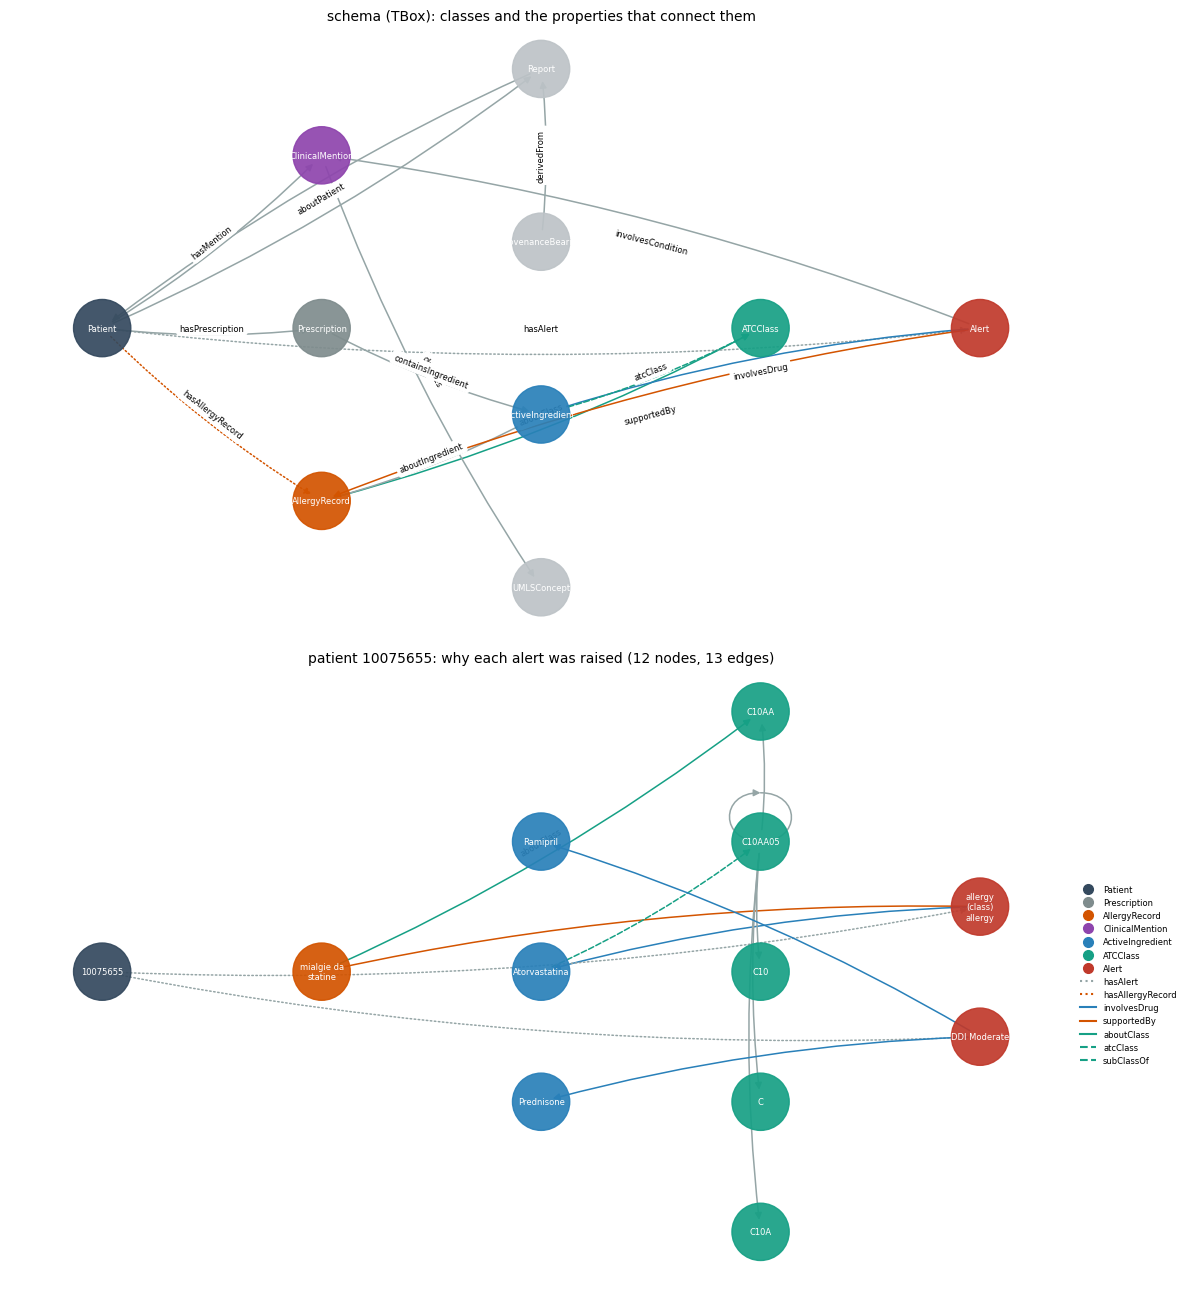

instance figure - patient 10075655: 12 nodes, 13 edges, projected from 42 triples
   alerts drawn: drug_allergy_class, drug_drug_interaction


In [146]:
# Render the schema and instance panels and print the counts behind the instance figure.
fig, axes = plt.subplots(2, 1, figsize=(12, 13))
draw(schema_graph, "schema (TBox): classes and the properties that connect them", axes[0],
     edge_labels=S_edge_labels)
draw(instance_graph, f"patient {viz_pid}: why each alert was raised "
         f"({instance_graph.number_of_nodes()} nodes, {instance_graph.number_of_edges()} edges)", axes[1], edge_labels=edge_lbl)
axes[1].legend(handles=[Line2D([], [], marker="o", ls="", color=c, markersize=7,
                               label=str(k).rsplit("/", 1)[-1]) for k, c in COLOR.items()] +
                       [Line2D([], [], color=c, ls=s, label=r) for r, (c, s) in REL_STYLE.items()],
               fontsize=6, loc="center left", bbox_to_anchor=(1.0, .5), frameon=False, ncol=1)
plt.tight_layout()
plt.show()

print(f"instance figure - patient {viz_pid}: {instance_graph.number_of_nodes()} nodes, {instance_graph.number_of_edges()} edges, "
      f"projected from {len(viz_g)} triples")
print("   alerts drawn:", ", ".join(sorted(str(viz_g.value(a, EX.alertType))
                                           for a in viz_g.subjects(EX.alertType, None))))


In [147]:
# SPARQL: seven hand-written queries, each exercising a different feature
PFX = ("PREFIX ex:<http://example.org/clinical/> PREFIX atc:<http://example.org/clinical/atc/> "
       "PREFIX umls:<http://example.org/clinical/umls/> "
       "PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#> "
       "PREFIX skos:<http://www.w3.org/2004/02/skos/core#>")

def sparql(title, feature, query, limit=8):
    print(f"\n### {title}\n    SPARQL feature: {feature}")
    rows = list(kg.query(query))

    for row in rows[:limit]:
        print("   ", " | ".join("" if v is None else str(v).rsplit("/", 1)[-1] for v in row))

    if len(rows) > limit:
        print(f"    ... {len(rows) - limit} more rows")

    return rows


In [148]:
# Q1 and Q2: basic patterns, and counting by alert class.
demo = int(alerts_df[alerts_df.alert_type.str.startswith(("drug_allergy", "drug_intolerance"))].iloc[0].encOid)

sparql(f"Q1 - the regimen of patient {demo}", "basic triple patterns, OPTIONAL, ORDER BY",
       PFX + f"""SELECT ?product ?ing ?code WHERE {{
                   ex:patient_{demo} ex:hasPrescription ?r .
                   ?r ex:containsIngredient ?i .
                   ?i rdfs:label ?ing .
                   OPTIONAL {{ ?r rdfs:label ?product }}
                   OPTIONAL {{ ?i ex:atcClass ?c . ?c skos:notation ?code }}
                 }} ORDER BY ?ing""")

sparql("Q2 - patients carrying at least one alert of each class", "COUNT DISTINCT, query by CLASS not by string",
       PFX + """SELECT ?cls (COUNT(DISTINCT ?p) AS ?patients) WHERE {
                  ?p ex:hasAlert ?a . ?a a ?cls . ?cls rdfs:subClassOf ex:Alert .
                } GROUP BY ?cls ORDER BY DESC(?patients)""")

# Q3: the query the graph exists for



### Q1 - the regimen of patient 10075117
    SPARQL feature: basic triple patterns, OPTIONAL, ORDER BY
    Ezevast | Atorvastatina | C10AA05
    Congescor | Bisoprololo Fumarato | C07AB07
    Citalopram eg | Citalopram | N06AB04
    Jardiance | Empagliflozin | A10BK03
    Enoxaparina rovi | Enoxaparina | B01AB05
    Ezevast | Ezetimibe | C10AX09
    Lasix | Furosemide | C03CA01
    Tresiba | Insulina Degludec | A10AE06
    ... 6 more rows

### Q2 - patients carrying at least one alert of each class
    SPARQL feature: COUNT DISTINCT, query by CLASS not by string
    DrugDrugInteractionAlert | 354
    DrugConditionContraindicationAlert | 88
    DuplicateIngredientAlert | 43
    DrugAllergyAlert | 3


[(rdflib.term.URIRef('http://example.org/clinical/DrugDrugInteractionAlert'),
  rdflib.term.Literal('354', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer'))),
 (rdflib.term.URIRef('http://example.org/clinical/DrugConditionContraindicationAlert'),
  rdflib.term.Literal('88', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer'))),
 (rdflib.term.URIRef('http://example.org/clinical/DuplicateIngredientAlert'),
  rdflib.term.Literal('43', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer'))),
 (rdflib.term.URIRef('http://example.org/clinical/DrugAllergyAlert'),
  rdflib.term.Literal('3', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))]

In [149]:
# Q3: the property path, against the two ways of asking without one.
direct = kg.query(PFX + """SELECT (COUNT(DISTINCT ?i) AS ?n) WHERE {
                              ?i a ex:ActiveIngredient ; ex:atcClass atc:C07 . }""")
class_prefix = kg.query(PFX + """SELECT (COUNT(DISTINCT ?i) AS ?n) WHERE {
                              ?i a ex:ActiveIngredient ; ex:atcClass ?c . ?c skos:notation ?code .
                              FILTER(STRSTARTS(STR(?code), "C07")) }""")
deep = kg.query(PFX + """SELECT (COUNT(DISTINCT ?i) AS ?n) WHERE {
                            ?i a ex:ActiveIngredient ; ex:atcClass ?c . ?c rdfs:subClassOf* atc:C07 . }""")
n_direct, n_prefix, n_deep = (int(list(x)[0][0]) for x in (direct, class_prefix, deep))
print(f"\n### Q3 - ingredients in ATC class C07 (beta blocking agents)\n"
      f"    SPARQL feature: rdfs:subClassOf* property path, against two alternatives")
display(pd.DataFrame([
    {"form": "direct link  ?i ex:atcClass atc:C07", "ingredients": n_direct,
     "why": "no instance carries the class directly - every ingredient carries a 7-character code"},
    {"form": 'string prefix  FILTER(STRSTARTS(?code, "C07"))', "ingredients": n_prefix,
     "why": "works, but only because ATC codes are positional"},
    {"form": "property path  ?c rdfs:subClassOf* atc:C07", "ingredients": n_deep,
     "why": "traverses a hierarchy that is declared in the graph"}]).set_index("form"))
sparql("     the ingredients the path returns", "property path, sample",
       PFX + """SELECT ?ing ?code WHERE {
                  ?i a ex:ActiveIngredient ; rdfs:label ?ing ; ex:atcClass ?c .
                  ?c rdfs:subClassOf* atc:C07 ; skos:notation ?code . } ORDER BY ?code""", limit=6)

# Q4: an alert re-derived from the graph alone



### Q3 - ingredients in ATC class C07 (beta blocking agents)
    SPARQL feature: rdfs:subClassOf* property path, against two alternatives


,ingredients,why
form,,
direct link ?i ex:atcClass atc:C07,0,no instance carries the class directly - every ingredient carries a 7-character code
"string prefix FILTER(STRSTARTS(?code, ""C07""))",8,"works, but only because ATC codes are positional"
property path ?c rdfs:subClassOf* atc:C07,8,traverses a hierarchy that is declared in the graph



###      the ingredients the path returns
    SPARQL feature: property path, sample
    Propranololo | C07AA05
    Sotalolo Cloridrato | C07AA07
    Nadololo | C07AA12
    Metoprololo | C07AB02
    Atenololo | C07AB03
    Bisoprololo Fumarato | C07AB07
    ... 2 more rows


[(rdflib.term.Literal('Propranololo'), rdflib.term.Literal('C07AA05')),
 (rdflib.term.Literal('Sotalolo Cloridrato'), rdflib.term.Literal('C07AA07')),
 (rdflib.term.Literal('Nadololo'), rdflib.term.Literal('C07AA12')),
 (rdflib.term.Literal('Metoprololo'), rdflib.term.Literal('C07AB02')),
 (rdflib.term.Literal('Atenololo'), rdflib.term.Literal('C07AB03')),
 (rdflib.term.Literal('Bisoprololo Fumarato'), rdflib.term.Literal('C07AB07')),
 (rdflib.term.Literal('Nebivololo'), rdflib.term.Literal('C07AB12')),
 (rdflib.term.Literal('Carvedilolo'), rdflib.term.Literal('C07AG02'))]

In [150]:
# Q4: an alert re-derived from the graph alone, checked against the engine.
# The graph node is minted on the CANONICAL crosswalk key and carries it as skos:notation, while
# the engine groups by the surface key of the printed name. Comparing a label against a surface key
# would measure the naming difference, not the reasoning; both sides are put on the canonical key.
dup = sparql("Q4 - one ingredient in two or more prescriptions of the same patient",
              "GROUP BY + HAVING COUNT(DISTINCT ?r) > 1",
              PFX + """SELECT ?p ?ing ?key (COUNT(DISTINCT ?r) AS ?n) WHERE {
                         ?p ex:hasPrescription ?r . ?r ex:containsIngredient ?i .
                         ?i rdfs:label ?ing ; skos:notation ?key .
                       } GROUP BY ?p ?i ?ing ?key HAVING (COUNT(DISTINCT ?r) > 1) ORDER BY ?p""",
              limit=6)
engine_dup = alerts_df[alerts_df.alert_type == "duplicate_active_ingredient"]
canonical_by_key = {key: canonical for key, canonical in
                    zip(discharge_linked.drug_key, discharge_linked.canonical_key)
                    if pd.notna(canonical)}


def canonical_identity(drug_name):
    """The canonical ingredient key behind a printed name, falling back to the surface key."""
    key = normalize_drug_key(drug_name)

    return canonical_by_key.get(key, key)


graph_pairs = {(str(row[0]).rsplit("_", 1)[-1], str(row[2])) for row in dup}
engine_pairs = {(str(row.encOid), canonical_identity(row.drug_a)) for row in engine_dup.itertuples()}
only_graph = sorted(graph_pairs - engine_pairs)
only_engine = sorted(engine_pairs - graph_pairs)
print(f"\n    graph: {len(graph_pairs)} (patient, ingredient) pairs | "
      f"symbolic engine: {len(engine_pairs)} alerts")
print(f"    shared: {len(graph_pairs & engine_pairs)} | only in the graph: {len(only_graph)} | "
      f"only in the engine: {len(only_engine)}")

if only_graph or only_engine:
    display(pd.DataFrame(
        [{"side": "graph only", "patient": patient, "ingredient": key} for patient, key in only_graph]
        + [{"side": "engine only", "patient": patient, "ingredient": key}
           for patient, key in only_engine]))



### Q4 - one ingredient in two or more prescriptions of the same patient
    SPARQL feature: GROUP BY + HAVING COUNT(DISTINCT ?r) > 1


    patient_10041091 | Levotiroxina Sodica | levotiroxina | 2
    patient_10044511 | Metformina | metformina | 2
    patient_10062201 | Furosemide | furosemide | 2
    patient_10063415 | Duloxetina | duloxetina | 2
    patient_10065599 | Levotiroxina Sodica | levotiroxina | 2
    patient_10067393 | Levotiroxina Sodica | levotiroxina | 2
    ... 50 more rows

    graph: 56 (patient, ingredient) pairs | symbolic engine: 56 alerts
    shared: 56 | only in the graph: 0 | only in the engine: 0


In [151]:
# Q5 to Q7: the evidence chain, recorded abstentions, and explicit years.
one_alert = next(kg.subjects(RDF.type, EX.DrugAllergyAlert), None) or next(kg.subjects(RDF.type, EX.Alert))
sparql("Q5 - the full evidence chain behind ONE alert",
       "traversal from an alert to its rule, its evidence node, and the report and offsets behind it",
       PFX + f"""SELECT ?type ?source ?conf ?status ?drug ?raw ?start ?end ?report WHERE {{
                   <{one_alert}> ex:alertType ?type ; ex:source ?source ; ex:ruleConfidence ?conf .
                   OPTIONAL {{ <{one_alert}> ex:allergyStatus ?status }}
                   OPTIONAL {{ <{one_alert}> ex:involvesDrug ?d . ?d rdfs:label ?drug }}
                   OPTIONAL {{ <{one_alert}> ex:supportedBy ?ev .
                               ?ev ex:allergenRaw ?raw ; ex:startOffset ?start ;
                                   ex:endOffset ?end ; ex:derivedFrom ?report }}
                 }}""")

# The builder records the ACTUAL abstention reason on the mention, not a single "NIL" literal, so
# the query groups by that reason: the graph can be asked why the linker declined, not merely that it did.
sparql("Q6 - condition mentions where the linker abstained, by recorded reason",
       "querying an explicitly recorded abstention",
       PFX + """SELECT ?status (COUNT(*) AS ?n) WHERE {
                  ?m a ex:ClinicalMention ; ex:linkStatus ?status .
                } GROUP BY ?status ORDER BY DESC(?n)""", limit=6)

# The year is a property of the SENTENCE, not of the mention: `extract_year` reads one temporal
# expression per sentence and every mention in that sentence inherits it. Two conditions named in one
# sentence therefore carry the same year even when only one of them is dated. Stated in the caption,
# because the property name alone reads as an attribute of the mention.
sparql("Q7 - mentions carrying an explicit year",
       "a mandatory pattern on a sparse property; the year is the SENTENCE's temporal expression, "
       "inherited by every mention in it - not a per-mention attribute",
       PFX + """SELECT ?year ?label (COUNT(*) AS ?n) WHERE {
                  ?m a ex:ClinicalMention ; rdfs:label ?label ; ex:year ?year ;
                     ex:assertion "affirmed" ; ex:experiencer "patient" .
                } GROUP BY ?year ?label ORDER BY DESC(?year)""", limit=6)
yr = len(list(kg.subject_objects(EX.year)))
print(f"    mentions carrying an explicit year: {yr} of {NODES['ClinicalMention']}")



### Q5 - the full evidence chain behind ONE alert
    SPARQL feature: traversal from an alert to its rule, its evidence node, and the report and offsets behind it
    drug_allergy_exact | anamnesis (GLiNER) | high | allergy | Bisoprololo Fumarato | bisoprololo | 41 | 52 | report_25415441

### Q6 - condition mentions where the linker abstained, by recorded reason
    SPARQL feature: querying an explicitly recorded abstention


    nil_no_candidates | 7650
    nil_low_margin | 1210
    nil_low_score | 98

### Q7 - mentions carrying an explicit year
    SPARQL feature: a mandatory pattern on a sparse property; the year is the SENTENCE's temporal expression, inherited by every mention in it - not a per-mention attribute


    2026 | PM | 1
    2026 | dispnea ingravescendente | 1
    2026 | stenosi aortica | 2
    2026 | valvulopatia tricuspidalica | 1
    2026 | dispnea | 22
    2026 | episodio di cardiopalmo | 1
    ... 3335 more rows
    mentions carrying an explicit year: 4784 of 17123


The comparison to read is the second row against the third, not the first. Prefix matching returns the
same ingredients; it is the mechanism the Python rule uses. It works by an accident of the ATC scheme:
a code's ancestors happen to be its prefixes. On MeSH or SNOMED that accident breaks - prefix
matching returns nothing usable - while the property path still works, because it walks a hierarchy
that is declared in the graph rather than inferred from the shape of a string.

Q3 and Q4 re-derive from the graph alone what the Python engine computed by other means: class
membership from the ATC hierarchy, and duplication from the prescription structure. The Q4 cell prints
the agreement and both one-sided differences, so the claim is measured rather than asserted.

One detail matters for that comparison to mean anything. The graph mints an ingredient node on the
canonical crosswalk key and carries it as `skos:notation`, while the engine groups prescriptions by the
normalised key of the printed name. Comparing a node label against a surface key measures the naming
difference, not the reasoning, so both sides are put on the canonical key before the sets are compared.

Only a minority of mentions state a year: sparse coverage of explicit dates, not a patient chronology.
The discourse section is recorded as document position, and deliberately not read as a time claim.


**Wrap-up.** The pipeline outputs converge into one queryable artifact: patients, prescriptions and their ingredients; ATC classes as resources arranged by `rdfs:subClassOf`; anamnesis mentions with their assertion and experiencer and either a UMLS concept or a recorded abstention status; allergy records; alerts as nodes carrying their provenance.

The graph is useful here for one thing: **subsumption**, through the `rdfs:subClassOf*` property path. The other queries in this section could be expressed as pandas aggregations over the same tables. Two queries re-derive from the graph alone what the symbolic engine computed by other means - a cross-check, not a second implementation.

**Why not OWL.** An OWL ontology with a reasoner is the obvious next step, and it was not taken.

OWL can express class constraints and support inference, but the operational joins used here are
simpler to implement and to inspect as explicit Python rules and SPARQL queries. The application also
uses closed-world lookup assumptions - "no allergy recorded" is treated as "no alert" - while OWL
itself follows the open-world assumption.
- **OWL is open-world.** From "no allergy recorded" a reasoner cannot conclude "not allergic": absence of information is not negative information. Clinical alerting is closed-world; it reasons by negation as failure. A semantic mismatch, not an implementation detail.
- **Cost without benefit.** rdflib performs no entailment, and materializing it with `owlrl` is slow at this triple count on this hardware - while the one inference actually needed, ATC subsumption, is free with a property path.

So: RDF with a small RDFS schema. No OWL, no ontological reasoning. The clinical rules stay in the symbolic engine; the graph integrates their results and makes them queryable.

## Section 9 - End-to-end demonstration and local LLM with tool calling

**No benchmark or clinical metric is reported here.** The demonstrations are accompanied only by
diagnostic counts - which tool was selected, whether the answer used the facts the tool returned.
Everything scored against a reference lives in Section 7.

Three parts:

1. **End-to-end demonstration case.** Whole pipeline on one worked case, then the local model verbalising the resulting facts - KAG by prompt augmentation: structured facts unparsed into text, re-injected into the model's context. The input is *not* unseen: the real patient belongs to the cohort already processed above, and the synthetic patient is constructed to trigger rules that are known in advance, with its GLiNER spans read from a precomputed sidecar rather than tagged here. It shows the path end to end; it establishes nothing about generalisation. The model decides nothing about whether an interaction exists; it puts facts into fluent Italian, the one thing it beats a template at.
2. **Tool calling over the graph** (Kautz Type 6, Neuro[Symbolic]): the neural component chooses which symbolic operation to invoke. Never writes a query - selects a tool and its arguments; each tool runs an already-validated SPARQL query.
3. **A negative experiment**: the same model asked to write SPARQL directly. Motivates part 2.

**Setup.** `qwen2.5:3b-instruct` via Ollama, `temperature=0`, on CPU. Selected patients only, for compute.

**Division of labour:** symbols retrieve and verify; the neural model verbalises and picks which symbolic operation to call. The rules stay in the engine.


### Part 1 - end-to-end demonstration on two patients

Pipeline on two worked cases, neither of them unseen. A **real cohort patient** first (system on genuine data), then a **synthetic patient** built to exercise the class-level ATC subsumption that fires only twice in the 857 real records. Both run the same functions - `parse_discharge_entry`, `resolve_drug_name`, ConText, the UMLS linker, `fire_alerts`. Neither enters any corpus-level count; the synthetic patient is never added to the cohort.

In [152]:
# Part 1a: a real cohort patient, end to end
# Deterministic selection: smallest encOid among patients with a Major drug-drug interaction.
# Real data here; the synthetic patient below shows class-level subsumption the cohort barely contains.
# Both rendered from the same pipeline tables.
REAL_DEMO_OID = int(sorted(alerts_df[(alerts_df.alert_type == "drug_drug_interaction") &
                                     (alerts_df.severity == "Major")].encOid.unique())[0])
print(f"real demo patient: {REAL_DEMO_OID}")
print("\ndischarge regimen (linked):")
display(discharge_linked[(discharge_linked.encOid == REAL_DEMO_OID) & (discharge_linked.status != "suspended")]
        [["principio_attivo", "nome_commerciale", "drug_key", "atc", "ddinter"]].reset_index(drop=True))
print("anamnesis conditions (affirmed, patient-referent):")
display(conditions_linked[(conditions_linked.encOid == REAL_DEMO_OID) &
                          (conditions_linked.assertion == "affirmed") &
                          (conditions_linked.experiencer == "patient")]
        [["condition", "section", "temporality", "umls_cui", "umls_label", "link_status"]]
        .drop_duplicates().head(10).reset_index(drop=True))
print("alerts, with provenance:")
display(alerts_df[alerts_df.encOid == REAL_DEMO_OID]
        [["alert_type", "drug_a", "drug_b", "condition", "severity", "source", "detail"]].reset_index(drop=True))


real demo patient: 9974566

discharge regimen (linked):


,principio_attivo,nome_commerciale,drug_key,atc,ddinter
0,Lacidipina,Ladip,lacidipina,C08CA09,<NA>
1,Nebivololo,Lobivon,nebivololo,C07AB12,<NA>
2,Rivaroxaban,Rivaroxaban doc,rivaroxaban,B01AF01,DDInter1609
3,Atorvastatina,Atorvastatina alm,atorvastatina,C10AA05,DDInter133
4,Lansoprazolo,Lansoprazolo my,lansoprazolo,A02BC03,<NA>
5,Acido acetilsalicilico,Acido acetils eg,acido acetilsalicilico,B01AC06,<NA>
6,Clopidogrel,Clopidogrel zen,clopidogrel,B01AC04,DDInter413


anamnesis conditions (affirmed, patient-referent):


,condition,section,temporality,umls_cui,umls_label,link_status
0,neurinoma,remota,unspecified,C0027809,Neurilemmoma,linked_exact
1,adenocarcinoma,remota,unspecified,C0001418,Adenocarcinoma,linked_contextual
2,Ipertensione arteriosa,remota,unspecified,C0020538,Hypertensive disease,linked_exact
3,adenocarcinoma polmonare,remota,unspecified,C0152013,Adenocarcinoma of lung (disorder),linked_exact
4,Macro-adenoma ipofisario,remota,unspecified,None,None,nil_no_candidates
5,angina atipica,remota,unspecified,C0741026,Atypical angina,linked_exact
6,dispnea da sforzo,remota,unspecified,C0231807,Dyspnea on exertion,linked_exact
7,angioTc coronarica,remota,unspecified,None,None,nil_no_candidates
8,incremento della componente di placca,remota,historical,None,None,nil_no_candidates
9,coronaropatia ostruttiva della destra,remota,historical,None,None,nil_no_candidates


alerts, with provenance:


,alert_type,drug_a,drug_b,condition,severity,source,detail
0,drug_drug_interaction,Atorvastatina,Clopidogrel,None,Moderate,DDInter 2.0,Atorvastatina + Clopidogrel
1,drug_drug_interaction,Rivaroxaban,Clopidogrel,None,Major,DDInter 2.0,Rivaroxaban + Clopidogrel


In [153]:
# Part 1b: the synthetic patient, through the real pipeline
# Anamnesis GLiNER spans precomputed in Section 5 (`demo_anam_spans`); everything else runs here on
# the cohort's own functions. No synthetic value enters any corpus figure.
print("=" * 96)
print("1. RAW SOURCE REPORTS  (patient", DEMO_OID + ")")
print("=" * 96)
print(DEMO_ANAMNESI[:430] + " ...\n")
print("admission therapy:", DEMO_INGRESSO[:150], "...\n")
print("discharge therapy:", DEMO_DIMISSIONE[0], "| ...", len(DEMO_DIMISSIONE), "entries")

# discharge: same parser, then same catalog resolution
collected_rows = []

for pid, entry_text in enumerate(DEMO_DIMISSIONE):
    parsed_entry = parse_discharge_entry(entry_text)

    for active_ingredient in parsed_entry["principio_attivo"]:
        demo_drug_key = normalize_drug_key(active_ingredient)
        collected_rows.append(dict(encOid=DEMO_OID, prescription_id=pid, principio_attivo=active_ingredient,
                          nome_commerciale=parsed_entry["nome_commerciale"], drug_key=demo_drug_key,
                          atc=KB_ATC.get(demo_drug_key), atc4=KB_ATC4.get(demo_drug_key), rxcui=KB_RXCUI.get(demo_drug_key),
                          ddinter=KB_DDI.get(demo_drug_key),
                          # The demo patient goes through the same rules as the cohort, so it carries
                          # the same two identity columns: the demo names ingredients rather than
                          # brands, so its surface key is already the canonical one.
                          rule_key=demo_drug_key, atc_committed=KB_ATC.get(demo_drug_key),
                          status=parsed_entry.get("status", "active")))

demo_drugs = pd.DataFrame(collected_rows)
print("\n" + "=" * 96)
print("2. STRUCTURED PIPELINE OUTPUT")
print("=" * 96)
print("discharge regimen (one row per ingredient; a combination stays ONE prescription):")
display(demo_drugs[["prescription_id", "principio_attivo", "nome_commerciale", "drug_key", "atc", "ddinter"]])

# admission: the real resolver, incl. the manufacturer-suffix case
demo_ingress_rows = []

for report, s0, e0 in gazetteer_spans(DEMO_INGRESSO):
    lab, atc, source_name, ings, amb = resolve_drug_name(report)
    demo_ingress_rows.append(dict(mention=report, resolved_label=lab, atc=atc, source=source_name))

demo_ingress = pd.DataFrame(demo_ingress_rows)
print("admission therapy, resolved (context only - it feeds no rule):")
display(demo_ingress.head(12))
ramipril_link = resolve_drug_name("Ramipril teva")
print(f"manufacturer-suffix case: resolve_drug_name('Ramipril teva') -> label={ramipril_link[0]!r} atc={ramipril_link[1]} source={ramipril_link[2]}")


1. RAW SOURCE REPORTS  (patient demo_synthetic_01)
Anamnesi patologica remota:
Ipertensione arteriosa in trattamento da circa quindici anni. Dislipidemia.
Fibrillazione atriale permanente, in terapia anticoagulante orale dal 2019.
Cardiopatia ischemica cronica, sottoposto ad angioplastica con impianto di stent
su discendente anteriore nel marzo 2021. Insufficienza renale cronica di grado
moderato, ultimo controllo con creatinina 1,6 mg/dl. Pregressa colecistectomia (2008).
Neg ...

admission therapy: Coumadin: 5 mg cpr /die (ore 17) ; Cardioaspirin: 100 mg cpr.gastrores. /die (ore 8) ; Ramipril teva: 5 mg cps. rigide /die (ore 8) ; Bisoprololo eg:  ...

discharge therapy: Warfarin (Coumadin cpr 5 mg): da assumere secondo INR, attualmente 5 mg (ore 17) | ... 9 entries

2. STRUCTURED PIPELINE OUTPUT
discharge regimen (one row per ingredient; a combination stays ONE prescription):


,prescription_id,principio_attivo,nome_commerciale,drug_key,atc,ddinter
0,0,Warfarin,Coumadin,warfarin,B01AA03,None
1,1,Acido acetilsalicilico,Cardioaspirin,acido acetilsalicilico,B01AC06,None
2,2,Amoxicillina,Augmentin,amoxicillina,J01CA04,DDInter83
3,2,acido clavulanico,Augmentin,acido clavulanico,None,None
4,3,Rosuvastatina,Crestor,rosuvastatina,C10AA07,None
5,4,Ramipril,Triatec,ramipril,C09AA05,DDInter1565
6,5,Bisoprololo,Concor,bisoprololo,C07AB07,DDInter216
7,6,Furosemide,Lasix,furosemide,C03CA01,DDInter790
8,7,Pantoprazolo,Pantorc,pantoprazolo,A02BC02,None
9,8,Pantoprazolo,Peptazol,pantoprazolo,A02BC02,None


admission therapy, resolved (context only - it feeds no rule):


,mention,resolved_label,atc,source
0,Coumadin,COUMADIN,B01AA03,exact_full
1,Cardioaspirin,CARDIOASPIRIN,B01AC06,exact_full
2,Ramipril,Ramipril,C09AA05,exact_full
3,Bisoprololo eg,BISOPROLOLO EG,C07AB07,exact_full
4,Lasix,LASIX,C03CA01,exact_full
5,Pantorc,PANTORC,A02BC02,exact_full
6,Omnic,OMNIC,G04CA02,exact_full


manufacturer-suffix case: resolve_drug_name('Ramipril teva') -> label='Ramipril' atc=C09AA05 source=gazetteer_anchor


In [154]:
# anamnesis: precomputed GLiNER spans, then ConText, then the UMLS linker
demo_condition_spans = [s for s in demo_anam_spans if s["label"] in CONDITION_LABELS]
section_offsets = section_marks(DEMO_ANAMNESI)
axis_values = context_axes(DEMO_ANAMNESI, [(c["start"], c["end"]) for c in demo_condition_spans], ctx_nlp)
demo_conditions = pd.DataFrame([
    dict(encOid=DEMO_OID, condition=c["text"], label=c["label"], start=c["start"], end=c["end"],
         section=section_of(section_offsets, c["start"]),
         sentence=c["sentence"],
         **{a: ax[a] for a in AXES})
    for c, ax in zip(demo_condition_spans, axis_values)])

# The synthetic patient is linked by the SAME functions as the cohort, not by a lookup table: its
# conditions are not in the cohort, and the cache makes a repeat run free.
demo_links = [link_umls_mention(str(r.condition).strip(), sentence=str(r.sentence))
              if umls_linking_possible else unlinked(str(r.condition).strip(), "api_unavailable")
              for r in demo_conditions.itertuples()]
demo_conditions = pd.concat(
    [demo_conditions.reset_index(drop=True),
     pd.DataFrame(demo_links).drop(columns="mention").reset_index(drop=True)], axis=1)
print("\nanamnesis conditions with their context axes and UMLS link:")
display(demo_conditions[["condition", "label", "section", "assertion", "experiencer",
                         "umls_cui", "umls_label", "link_status"]])

# NER recall made concrete: "cardiopalmo" is in the anamnesis ("associata a cardiopalmo") but GLiNER
# did not tag it, so it never reaches linking - the exact-span recall of Section 7.3, on the page.
missed = [w for w in ["cardiopalmo"] if w not in " ".join(demo_conditions.condition.astype(str)).lower()]

if missed:
    print(wrap(f"NER recall, live: {missed} present in the text but NOT extracted by GLiNER "
               f"(cf. the exact-span recall of {exact_R} reported in Section 7.3)."))

print("negated / possible / family mentions (the independent-axis cases):")
display(demo_conditions[(demo_conditions.assertion != "affirmed") | (demo_conditions.experiencer == "family")]
        [["condition", "section", "assertion", "experiencer"]].reset_index(drop=True))



anamnesis conditions with their context axes and UMLS link:


,condition,label,section,assertion,experiencer,umls_cui,umls_label,link_status
0,Ipertensione arteriosa,malattia,remota,affirmed,patient,C0020538,Hypertensive disease,linked_exact
1,Dislipidemia,malattia,remota,affirmed,patient,C0242339,Dyslipidemias,linked_exact
2,Fibrillazione atriale permanente,malattia,remota,affirmed,patient,C2586056,Permanent atrial fibrillation,linked_exact
3,Cardiopatia ischemica cronica,malattia,remota,affirmed,patient,C0264694,Chronic myocardial ischemia,linked_contextual
4,Insufficienza renale cronica,malattia,remota,affirmed,patient,C0403447,Chronic Kidney Insufficiency,linked_contextual
5,Pregressa colecistectomia,malattia,remota,affirmed,patient,None,None,nil_no_candidates
6,diabete mellito,malattia,remota,negated,patient,C0011849,Diabetes Mellitus,linked_exact
7,broncopneumopatia cronica ostruttiva,malattia,remota,negated,patient,C0024117,Chronic Obstructive Airway Disease,linked_exact
8,infarto miocardico,malattia,familiare,affirmed,family,C0027051,Myocardial Infarction,linked_exact
9,cardiopatia ischemica,malattia,familiare,affirmed,family,C0151744,Myocardial Ischemia,linked_exact


NER recall, live: ['cardiopalmo'] present in the text but NOT extracted by GLiNER (cf. the exact-
span recall of 0.579 reported in Section 7.3).
negated / possible / family mentions (the independent-axis cases):


,condition,section,assertion,experiencer
0,diabete mellito,remota,negated,patient
1,broncopneumopatia cronica ostruttiva,remota,negated,patient
2,infarto miocardico,familiare,affirmed,family
3,cardiopatia ischemica,familiare,affirmed,family
4,neoplasie,familiare,negated,family
5,trombosi venosa profonda,prossima,negated,patient


The drug and condition tables built above, together with the allergy mentions extracted here, are passed to the same rule function the cohort pipeline uses.


In [155]:
# allergens: template regex, then the shared resolver
arows = []

for kind_label, subject_rows, template_start, template_end in allergy_template_mentions(DEMO_ANAMNESI):
    # local names: `key_list` is a module-level index built in Section 7 and must not be rebound here
    demo_ingredients, demo_class = resolve_allergen(subject_rows)
    arows.append(dict(encOid=DEMO_OID, mention=subject_rows, kind=kind_label, mention_source="template regex",
                       ingredients=demo_ingredients, atc_class=demo_class,
                       start=template_start, end=template_end))

demo_allergens = pd.DataFrame(arows, columns=["encOid", "mention", "kind", "mention_source",
                                               "ingredients", "atc_class", "start", "end"])
print("\nallergy substances (template regex + shared catalog resolution):")

if len(demo_allergens):
    display(demo_allergens[["mention", "kind", "ingredients", "atc_class"]])
else:
    print("  (none extracted)")

# the rules: the same function the pipeline runs
demo_alerts, _, _ = fire_alerts(demo_drugs, demo_conditions,
                                {DEMO_OID: demo_allergens} if len(demo_allergens) else {},
                                contraindication_pairs, contraindication_metadata)
demo_alerts = pd.DataFrame(demo_alerts)
print("\nalerts, with provenance:")

if len(demo_alerts):
    display(demo_alerts[["alert_type", "drug_a", "drug_b", "allergen", "severity", "confidence", "source", "detail"]])
else:
    print("  (no alert fired)")



allergy substances (template regex + shared catalog resolution):


,mention,kind,ingredients,atc_class
0,Penicilline,allergy,[],J01C
1,statine,intolerance,[],C10AA
2,pollini,allergy,[],None
3,acari della polvere,allergy,[],None



alerts, with provenance:


,alert_type,drug_a,drug_b,allergen,severity,confidence,source,detail
0,duplicate_active_ingredient,Pantoprazolo,None,None,duplication,high,discharge prescriptions,"pantoprazolo in 2 prescriptions (different product: Pantorc, Peptazol)"
1,drug_allergy_class,Amoxicillina,None,Penicilline,allergy,medium,ATC hierarchy,"Amoxicillina (J01CA04) is under J01C, the class of Penicilline"
2,drug_intolerance_class,Rosuvastatina,None,statine,intolerance,medium,ATC hierarchy,"Rosuvastatina (C10AA07) is under C10AA, the class of statine"


The last block traces a class-level alert back to its premises: the ATC class assigned to the allergen, the ATC code of the prescribed drug, and the chain of ATC prefixes connecting them.


In [156]:
# 3. the subsumption derivation, printed as a chain
print("\n" + "=" * 96)
print("3. WHY THE CLASS-LEVEL ALERT FIRED")
print("=" * 96)
cls_alerts = demo_alerts[demo_alerts.alert_type.str.endswith("_class")] if len(demo_alerts) else demo_alerts

if len(cls_alerts):
    for class_alert_row in cls_alerts.itertuples():
        pref = ALLERGY_CLASSES[CLASS_RE.search(str(class_alert_row.allergen)).group(1).lower()]
        atc = str(demo_drugs.loc[demo_drugs.principio_attivo == class_alert_row.drug_a, "atc"].iloc[0])
        atc_prefix_chain = [atc[:n] for n in (7, 5, 4, 3, 1) if len(atc) >= n and len(atc[:n]) >= len(pref)]
        print(f'  allergen "{class_alert_row.allergen}" -> ATC class {pref}   (curated class map)')
        print(f"  {class_alert_row.drug_a.lower():<28} -> {atc}   (catalog)")
        print(f"  {' ⊑ '.join(atc_prefix_chain)}  ->  member of {pref}  ->  {class_alert_row.alert_type}\n")
else:
    print("  no class-level alert fired - see the report on section segmentation.")



3. WHY THE CLASS-LEVEL ALERT FIRED
  allergen "Penicilline" -> ATC class J01C   (curated class map)
  amoxicillina                 -> J01CA04   (catalog)
  J01CA04 ⊑ J01CA ⊑ J01C  ->  member of J01C  ->  drug_allergy_class

  allergen "statine" -> ATC class C10AA   (curated class map)
  rosuvastatina                -> C10AA07   (catalog)
  C10AA07 ⊑ C10AA  ->  member of C10AA  ->  drug_intolerance_class



Acido clavulanico has no crosswalk entry (atc/ddinter blank): the combination stays one prescription, two ingredients. The unresolved component is kept, not discarded; the alert still fires on the linked one (amoxicillina).

In [157]:
# Free spaCy and the E5 embedder before the graph and the local runner, which share this machine's
# RAM. spaCy is reloaded in Section 7; the embedder is lazily reloaded if anything needs it again.
for global_name in ["nlp"]:
    if global_name in globals():
        del globals()[global_name]

embedder = None                       # reset the lazy cache (see Section 5)
gc.collect()

try:
    torch.cuda.empty_cache()
except RuntimeError:
    pass

# Confirm what was freed.
print("freed from memory:", [v for v in ["nlp"] if v not in globals()])


freed from memory: ['nlp']


In [158]:
# 4-5. The facts, unparsed into text and re-injected into the model's context
# KAG by prompt augmentation: the structured facts computed above become the model's context. The
# intended role of the model is limited to verbalising them - whether it stays inside that role is
# what the grounding check below examines.
client = ollama.Client(timeout=600)

# Everything that can come back from an unreachable or crashed runner. `ConnectionError` is the
# BUILTIN one: the ollama client converts httpx.ConnectError into it and re-raises with `from None`,
# so none of the three library exceptions ever sees it. Without it here, a runner that is not running
# aborts the whole notebook instead of being recorded as a failed call.
OLLAMA_FAILURES = (ollama.RequestError, ollama.ResponseError, httpx.HTTPError, ConnectionError)


def ollama_chat(messages, tools=None, retries=4):
    """The llama.cpp runner crashes intermittently under RAM pressure on this machine (the graph stays
    resident for the tool calls). Retry, keeping the model loaded between attempts."""

    for attempt in range(retries):
        try:
            return client.chat(model=OLLAMA_MODEL, messages=messages, tools=tools,
                                options={"temperature": 0, "num_gpu": 0, "num_ctx": 2048})
        except OLLAMA_FAILURES as err:
            if attempt == retries - 1:
                raise

            time.sleep(4)

GROUNDING_RULES = ("Rispondi SOLO con i fatti forniti. Non aggiungere meccanismi farmacologici, "
                   "raccomandazioni o interpretazioni cliniche. Se i fatti non bastano a rispondere, "
                   "dillo esplicitamente. Massimo 120 parole.")

def facts_of(alerts, drugs, conditions):
    """Unparse the structured rows into the plain text that goes into the prompt."""
    L = ["FARMACI ALLA DIMISSIONE: " + ", ".join(sorted(set(drugs.principio_attivo.astype(str))))]
    aff = conditions[(conditions.assertion == "affirmed") & (conditions.experiencer == "patient")]
    L.append("CONDIZIONI AFFERMATE: " + ", ".join(sorted(set(aff.condition.astype(str)))[:12]))
    neg = conditions[conditions.assertion == "negated"]

    if len(neg):
        L.append("CONDIZIONI NEGATE: " + ", ".join(sorted(set(neg.condition.astype(str)))[:8]))

    for r in alerts.itertuples():
        L.append(f"ALERT [{r.alert_type} | fonte {r.source} | confidenza {r.confidence}]: {r.detail}")

    return "\n".join(L)

def ask(prompt, facts):
    """One grounded question. Goes through `ollama_chat`, so it gets the same retry as every other
    call: the runner crashes under memory pressure regardless of which cell is asking."""
    response = ollama_chat([{"role": "system", "content": GROUNDING_RULES},
                            {"role": "user", "content": f"FATTI:\n{facts}\n\nDOMANDA: {prompt}"}])

    return response["message"]["content"].strip()

facts = facts_of(demo_alerts, demo_drugs, demo_conditions)
print("=" * 96)
print("4. THE PROMPT ACTUALLY SENT")
print("=" * 96)
print("[system]", GROUNDING_RULES, "\n")
print("[user] FATTI:\n" + facts)
demo_question = "Riassumi le segnalazioni di sicurezza per questo paziente e indica su quale evidenza si basano."
print("\n[user] DOMANDA:", demo_question)

print("\n" + "=" * 96)
print("5. THE MODEL'S ANSWER")
print("=" * 96)

try:
    ans = ask(demo_question, facts)
    answer_available = True
except OLLAMA_FAILURES as err:
    ans = f"[Ollama unavailable: {type(err).__name__}]"
    answer_available = False

print(ans)

# limited lexical grounding check, at CLAIM level
# A token-level check flags every connective and paraphrase - measures nothing. What matters here: was
# anything clinically substantive - a drug, a severity, an alert type - invented? That is the whole
# extent of it. It is a lexical membership test over a closed vocabulary, NOT a factuality evaluation:
# an invented mechanism, a wrong relation between two real entities, an inverted negation and an
# omission all pass it untouched.
if not answer_available:
    # Running the check on the error string would report "nothing invented" about a sentence the
    # model never produced, so there is nothing to check and the cell reports that instead.
    print("\ngrounding check skipped: the model returned no answer in this run.")
else:
    ans_low = ans.lower()
    fact_drug_keys = {normalize_drug_key(d) for d in demo_drugs.principio_attivo}
    # any catalog ingredient (>=6 characters, to skip short false hits) named in the answer
    named = {key for key in KB_ATC if len(key) >= 6 and re.search(rf"\b{re.escape(key)}\b", ans_low)}
    invented_drugs = sorted(named - fact_drug_keys)
    fact_severities = {str(s).lower() for s in demo_alerts.severity}
    answer_severities = {word for word in ("major", "moderate", "minor", "grave", "severa", "critica")
                         if word in ans_low}
    invented_severities = sorted(answer_severities - fact_severities)
    print("\nlimited lexical grounding check (did the answer name a substance or severity absent "
          "from the facts?):")
    print("  drugs named but NOT in the facts:     ", invented_drugs or "(none)")
    print("  severities named but NOT in the facts:", invented_severities or "(none)")


4. THE PROMPT ACTUALLY SENT
[system] Rispondi SOLO con i fatti forniti. Non aggiungere meccanismi farmacologici, raccomandazioni o interpretazioni cliniche. Se i fatti non bastano a rispondere, dillo esplicitamente. Massimo 120 parole. 

[user] FATTI:
FARMACI ALLA DIMISSIONE: Acido acetilsalicilico, Amoxicillina, Bisoprololo, Furosemide, Pantoprazolo, Ramipril, Rosuvastatina, Warfarin, acido clavulanico
CONDIZIONI AFFERMATE: Allergie, Cardiopatia ischemica cronica, Dislipidemia, Fibrillazione atriale permanente, Insufficienza renale cronica, Intolleranze, Ipertensione arteriosa, Pregressa colecistectomia, crepitii bibasali, dispnea da sforzo ingravescente, mialgie, obiettivita polmonare
CONDIZIONI NEGATE: broncopneumopatia cronica ostruttiva, diabete mellito, neoplasie, trombosi venosa profonda
ALERT [duplicate_active_ingredient | fonte discharge prescriptions | confidenza high]: pantoprazolo in 2 prescriptions (different product: Pantorc, Peptazol)
ALERT [drug_allergy_class | fonte AT

ALERT [duplicate_active_ingredient | fonte discharge prescriptions | confidenza high]: Il paziente ha prescrizioni duplicati del Pantoprazolo, con due farmaci diversi (Pantorc, Peptazol). Questa è una segnalazione di sicurezza perché potrebbe causare effetti collaterali duplicati o incompatibili.

ALERT [drug_allergy_class | fonte ATC hierarchy | confidenza medium]: L'amoxicillina appartiene alla classe J01C, che comprende i farmaci penicillinici. Questa segnalazione di sicurezza si basa sulla classificazione farmacologica dell'amoxicillina.

ALERT [drug_intolerance_class | fonte ATC hierarchy | confidenza medium]: La rosuvastatina appartiene alla classe C10AA, che comprende i farmaci statinici. Questa segnalazione di sicurezza si basa sulla classificazione farmacologica della rosuvastatina.

limited lexical grounding check (did the answer name a substance or severity absent from the facts?):
  drugs named but NOT in the facts:      (none)
  severities named but NOT in the facts: (none

**A limited lexical grounding check, not a factuality evaluation.** The check below asks one question:
does a drug or a severity absent from the facts appear in the answer? That is string matching over
two closed vocabularies. It does **not** detect an invented mechanism, a relation asserted
between the wrong entities, an inverted negation, or an omission.

The answer above shows exactly that gap. The check finds no invented drug and no invented severity -
every entity the model names is grounded - yet the answer adds that duplicated prescriptions could
cause duplicated or incompatible adverse effects. Nothing in the facts says so, and the prompt
explicitly forbade adding pharmacological mechanisms or clinical interpretation. The entities are
grounded; the causal claim built around them is not, and a lexical check cannot see the difference.

Grounding reduces hallucination, it does not remove it, and one example is not evidence of
reliability either way.


In [159]:
# Part 2: tool calling over the knowledge graph (Kautz Type 6)
# The model never writes SPARQL. It picks a tool and its arguments; each tool runs a query written and
# validated here. get_drugs_in_class walks rdfs:subClassOf*, so "is this
# patient on a beta blocker?" is answerable without the question knowing which drugs those are.
TPFX = ('PREFIX ex:<http://example.org/clinical/> PREFIX atc:<http://example.org/clinical/atc/> '
         'PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#> '
         'PREFIX skos:<http://www.w3.org/2004/02/skos/core#>')

def get_patient_regimen(patient_id):
    q = TPFX + f"""SELECT ?ing WHERE {{ ex:patient_{patient_id} ex:hasPrescription ?r .
                    ?r ex:containsIngredient ?i . ?i rdfs:label ?ing }}"""
    return sorted({str(r[0]) for r in kg.query(q)}) or ["(nessun farmaco)"]

def get_patient_interactions(patient_id):
    """Return the patient's drug-drug interaction alerts.

    The alert type is filtered INSIDE the tool. Exposing it as a free-text argument made the model
    supply "interaction", which matches no alert type in the graph, so the query returned nothing
    while the routing looked correct.
    """
    q = TPFX + f"""SELECT ?d WHERE {{ ex:patient_{patient_id} ex:hasAlert ?a .
                    ?a ex:alertType "drug_drug_interaction" ; ex:detail ?d }}"""

    return [str(r[0]) for r in kg.query(q)] or ["(nessuna interazione)"]


def get_drugs_in_class(patient_id, atc_prefix):
    q = TPFX + f"""SELECT ?ing ?code WHERE {{ ex:patient_{patient_id} ex:hasPrescription ?r .
                    ?r ex:containsIngredient ?i . ?i rdfs:label ?ing ; ex:atcClass ?c .
                    ?c rdfs:subClassOf* atc:{atc_prefix} ; skos:notation ?code }}"""
    return [f"{r[0]} ({r[1]})" for r in kg.query(q)] or [f"(nessun farmaco sotto {atc_prefix})"]


In [160]:
# The tool registry and the JSON schema the model is shown.
# Three tools, one per answerable question. A tool the demonstration never exercises would only
# make the routing task look harder than it was measured to be.
TOOLS = {"get_patient_regimen": get_patient_regimen,
         "get_patient_interactions": get_patient_interactions,
         "get_drugs_in_class": get_drugs_in_class}
TOOL_SPEC = [
    {"type": "function", "function": {"name": "get_patient_regimen",
     "description": "Elenca i principi attivi prescritti alla dimissione per un paziente.",
     "parameters": {"type": "object", "properties": {"patient_id": {"type": "string"}}, "required": ["patient_id"]}}},
    {"type": "function", "function": {"name": "get_patient_interactions",
     "description": "Elenca gli alert di interazione farmaco-farmaco di un paziente.",
     "parameters": {"type": "object", "properties": {"patient_id": {"type": "string"}},
                    "required": ["patient_id"]}}},
    {"type": "function", "function": {"name": "get_drugs_in_class",
     "description": "Elenca i farmaci del paziente che appartengono a una classe ATC, seguendo la gerarchia "
                    "(es. C07 = betabloccanti, C10AA = statine, J01C = penicilline).",
     "parameters": {"type": "object", "properties": {"patient_id": {"type": "string"},
                    "atc_prefix": {"type": "string"}}, "required": ["patient_id", "atc_prefix"]}}},
]


In [161]:
# The four questions: three answerable from the graph, one that is not.
tool_pid = int(alerts_df[alerts_df.alert_type == "drug_drug_interaction"].iloc[0].encOid)
QUESTION_BETA_BLOCKER = f"Il paziente {tool_pid} assume betabloccanti?"
QUESTION_REGIMEN = f"Quali farmaci ha alla dimissione il paziente {tool_pid}?"
QUESTION_INTERACTIONS = f"Che alert di interazione ha il paziente {tool_pid}?"
QUESTION_BLOOD_PRESSURE = f"Qual e la pressione arteriosa del paziente {tool_pid}?"

QUESTIONS = [QUESTION_BETA_BLOCKER, QUESTION_REGIMEN, QUESTION_INTERACTIONS,
             QUESTION_BLOOD_PRESSURE]

# Routing is a classification with a known answer. Counting any tool call as a success would score a
# model that always picks the same tool as perfect, so each question names the tool it requires.
# The blood-pressure question has no applicable tool: the graph holds no vital signs, and the only
# correct behaviour is to call nothing.
EXPECTED_TOOL = {
    QUESTION_BETA_BLOCKER: "get_drugs_in_class",
    QUESTION_REGIMEN: "get_patient_regimen",
    QUESTION_INTERACTIONS: "get_patient_interactions",
    QUESTION_BLOOD_PRESSURE: None,
}

REFUSAL_CUE = re.compile(r"non (?:e|\u00e8) possibile|non permettono|non ci sono|non ho (?:le )?informazioni|"
                         r"non posso|non sono (?:stati )?forniti|dati (?:non )?disponibili|insufficien",
                         re.I)

def reports_a_returned_fact(answer, facts):
    """A LEXICAL proxy for 'the model used what the tool returned': does the answer repeat at least
    one substantive word from the facts, without a refusal cue? It does not judge whether the answer
    is clinically right - only whether the returned facts reached it at all."""
    if REFUSAL_CUE.search(answer):
        return False

    words = {w.lower() for f in facts for w in re.findall(r"[A-Za-z\u00c0-\u00ff]{6,}", str(f))}

    return any(w in answer.lower() for w in words)


In [162]:
# Ask the model each question, run the tool it chooses, then let it answer from the facts.
trace = []

for question in QUESTIONS:
    print("\n" + "-" * 96)
    print("Q:", question)

    try:
        routing_response = ollama_chat([{"role": "system", "content":
                            "Scegli lo strumento adatto. Non inventare dati. Se nessuno strumento "
                            "puo rispondere, dillo."},
                           {"role": "user", "content": question}], tools=TOOL_SPEC)
        calls = routing_response["message"].get("tool_calls") or []

        if not calls:
            print("   [no tool selected] ->", routing_response["message"]["content"].strip()[:200])
            trace.append({"question": question, "tool selected": "(none)", "arguments": "-",
                          "facts returned": 0, "answer reports them": False})
            continue

        tool_name = calls[0]["function"]["name"]
        args = dict(calls[0]["function"].get("arguments") or {})
        print(f"   [tool call] {tool_name}({args})")
        tool_facts = TOOLS[tool_name](**args) if tool_name in TOOLS else ["(strumento inesistente)"]
        print("   [facts]", str(tool_facts)[:200])
        final_response = ollama_chat([{"role": "system", "content": GROUNDING_RULES},
                                      {"role": "user",
                                       "content": f"FATTI: {tool_facts}\n\nDOMANDA: {question}"}])
        answer = final_response["message"]["content"].strip()
        print("   [answer]", answer[:300])
        trace.append({"question": question, "tool selected": tool_name, "arguments": str(args),
                      "facts returned": len(tool_facts),
                      "answer reports them": reports_a_returned_fact(answer, tool_facts)})
    except OLLAMA_FAILURES as err:
        print("   [Ollama unavailable]", type(err).__name__)
        trace.append({"question": question, "tool selected": "(error)", "arguments": "-",
                      "facts returned": 0, "answer reports them": False})

# The Type-6 result, computed not asserted: routing and use-of-result are separate halves.



------------------------------------------------------------------------------------------------
Q: Il paziente 9858479 assume betabloccanti?


   [tool call] get_drugs_in_class({'atc_prefix': 'C07', 'patient_id': '9858479'})
   [facts] ['Bisoprololo Fumarato (C07AB07)']


   [answer] Massimo i fatti forniti non permettono di rispondere se il paziente assumi bisoprololo.

------------------------------------------------------------------------------------------------
Q: Quali farmaci ha alla dimissione il paziente 9858479?


   [tool call] get_patient_regimen({'patient_id': '9858479'})
   [facts] ['Acido Acetilsalicilico', 'Apalutamide', 'Bisoprololo Fumarato', 'Clopidogrel', 'Eplerenone', 'Ezetimibe', 'Furosemide', 'Isosorbide Mononitrato', 'Lorazepam', 'Pantoprazolo', 'Paracetamolo', 'Predni


   [answer] Massimo i fatti forniti non sono sufficienti per rispondere alla domanda. Non c'è informazione sul paziente 9858479.

------------------------------------------------------------------------------------------------
Q: Che alert di interazione ha il paziente 9858479?


   [tool call] get_patient_interactions({'patient_id': '9858479'})
   [facts] ['Apalutamide + Valsartan', 'Apalutamide + ezetimibe', 'Prednisone + Valsartan', 'Prednisone + Bisoprololo', 'Prednisone + Eplerenone', 'Prednisone + Furosemide']


   [answer] Non ci sono fatti forniti che riguardino l'alert di interazione per il paziente con codice 9858479.

------------------------------------------------------------------------------------------------
Q: Qual e la pressione arteriosa del paziente 9858479?


   [no tool selected] -> Il tuo sistema di informazioni attuale non include direttamente i dati della pressione sanguigna. Non ho accesso ai dettagli medici specifici come la pressione arteriosa per un paziente individuale. T


In [163]:
# Routing is scored against the expected tool, not against "some tool was called".
routing_rows = []

for step in trace:
    question = step["question"]
    expected = EXPECTED_TOOL[question]
    selected = step["tool selected"]
    selected_tool = None if selected in ("(none)", "(error)") else selected

    # For the interaction question the arguments matter too: the right tool on the wrong patient
    # would still be a wrong answer.
    arguments_ok = True

    if expected is not None:
        arguments_ok = str(tool_pid) in str(step["arguments"])

    routing_rows.append({"question": question[:52], "expected": expected or "(none)",
                         "selected": selected_tool or "(none)",
                         "correct": selected_tool == expected and arguments_ok})

routing = pd.DataFrame(routing_rows)
display(routing)

routing_ok = int(routing.correct.sum())
routing_total = len(routing)
answerable_questions = {q for q, tool in EXPECTED_TOOL.items() if tool is not None}
verbalisation_total = sum(1 for t in trace if t["question"] in answerable_questions
                          and t["tool selected"] not in ("(none)", "(error)"))
verbalisation_ok = sum(1 for t in trace if t["question"] in answerable_questions
                       and t["answer reports them"])
connection_errors = sum(1 for t in trace if t["tool selected"] == "(error)")

print(f"\nrouting  : {routing_ok}/{routing_total} questions sent to the expected tool "
      f"(the unanswerable one counts as correct only when NO tool is called)")
print(f"grounding: {verbalisation_ok}/{verbalisation_total} answers repeat a fact the tool returned")
print(f"tool-calling connection errors in this run: {connection_errors}")
print(wrap("The grounding counter is a LEXICAL criterion - the answer repeats a substantive word "
           "from what the tool returned. It does not judge clinical correctness."))


,question,expected,selected,correct
0,Il paziente 9858479 assume betabloccanti?,get_drugs_in_class,get_drugs_in_class,True
1,Quali farmaci ha alla dimissione il paziente 9858479,get_patient_regimen,get_patient_regimen,True
2,Che alert di interazione ha il paziente 9858479?,get_patient_interactions,get_patient_interactions,True
3,Qual e la pressione arteriosa del paziente 9858479?,(none),(none),True



routing  : 4/4 questions sent to the expected tool (the unanswerable one counts as correct only when NO tool is called)
grounding: 0/3 answers repeat a fact the tool returned
tool-calling connection errors in this run: 0
The grounding counter is a LEXICAL criterion - the answer repeats a substantive word from what the
tool returned. It does not judge clinical correctness.


In [164]:
# Part 3: the negative experiment - the same model asked to write SPARQL itself
schema = ("Classi: ex:Patient, ex:Prescription, ex:ActiveIngredient, ex:ATCClass, ex:Alert. "
           "Proprieta: ex:hasPrescription, ex:containsIngredient, ex:atcClass, ex:hasAlert, ex:alertType. "
           "Prefisso ex: <http://example.org/clinical/>.")

try:
    sq = ollama_chat([{"role": "user", "content":
                                  f"Schema RDF: {schema}\nScrivi SOLO una query SPARQL che elenchi i "
                                  f"principi attivi del paziente ex:patient_{tool_pid}."}])["message"]["content"]
except OLLAMA_FAILURES as err:
    sq = f"[Ollama unavailable: {type(err).__name__}]"

print("model-authored SPARQL, verbatim:\n")
print(sq[:700])


def extract_sparql_block(text):
    """Take the fenced block when the model wrapped its query in prose, else the whole answer.

    Without this step the parser is handed the explanation as well, and a parse error would only
    prove that the model ignored the instruction - not that the query it wrote is wrong.
    """
    match = re.search(r"```(?:sparql)?\s*(.*?)```", text, flags=re.DOTALL | re.IGNORECASE)

    return match.group(1).strip() if match else text.strip()


query_text = extract_sparql_block(sq)
followed_instruction = query_text == sq.strip()      # "write ONLY a SPARQL query"
parses = executes = False
returned_rows = []

try:
    prepareQuery(query_text)
    parses = True
except Exception as err:                             # rdflib reports every syntax problem this way
    parse_error = f"{type(err).__name__}: {str(err)[:120]}"

if parses:
    try:
        returned_rows = list(kg.query(query_text))
        executes = True
    except Exception as err:
        execution_error = f"{type(err).__name__}: {str(err)[:120]}"

# The ground truth: the ingredients the graph holds for that patient, as BOTH the node URIs and
# their labels. Selecting either is a correct answer to the question asked, so comparing only against
# the labels would mark a query that returns the nodes as wrong.
expected_rows = list(kg.query(
    PFX + f"""SELECT ?i ?ing WHERE {{ ex:patient_{tool_pid} ex:hasPrescription ?r .
                                      ?r ex:containsIngredient ?i . ?i rdfs:label ?ing }}"""))
expected_uris = {str(row[0]) for row in expected_rows}
expected_labels = {str(row[1]) for row in expected_rows}
returned_values = {str(value) for row in returned_rows for value in row if value is not None}
returned_as = ("node URIs" if expected_uris & returned_values
               else "labels" if expected_labels & returned_values else "neither form")
answers_the_question = bool(expected_uris) and (expected_uris <= returned_values
                                                or expected_labels <= returned_values)

display(pd.DataFrame([
    {"check": "1. followed the instruction to emit only a query", "result": followed_instruction},
    {"check": "2. the extracted query parses", "result": parses},
    {"check": "3. it executes against this graph", "result": executes},
    {"check": "4. it returns the patient's ingredients", "result": answers_the_question},
]).set_index("check"))

if not parses:
    print("parse error:", parse_error)
elif not executes:
    print("execution error:", execution_error)
else:
    matched = max(len(expected_uris & returned_values), len(expected_labels & returned_values))
    print(f"rows returned: {len(returned_rows)} | the query selected {returned_as} | "
          f"ingredients matched: {matched} of {len(expected_uris)}")


model-authored SPARQL, verbatim:

Per ottenere la lista dei principi attivi (ex:ActiveIngredient) di un paziente specifico (ex:Patient), puoi utilizzare una query SPARQL come quella qui sotto:

```sparql
PREFIX ex: <http://example.org/clinical/>

SELECT ?activeIngredient 
WHERE {
  ex:patient_9858479 ex:hasPrescription ?prescription .
  ?prescription ex:containsIngredient ?activeIngredient .
}
```

Questa query seleziona i principi attivi (ex:ActiveIngredient) che sono contenuti in una prescrizione di un paziente specifico (ex:patient_9858479).


,result
check,
1. followed the instruction to emit only a query,False
2. the extracted query parses,True
3. it executes against this graph,True
4. it returns the patient's ingredients,True


rows returned: 15 | the query selected node URIs | ingredients matched: 15 of 15


Why part 2 constrains the model to selecting a tool with typed arguments instead of authoring a query. A malformed query is a silent failure mode: it raises, or worse returns plausible rows from the wrong pattern. With tools the query is fixed and validated; the model only picks which one to run - the neural component decides WHEN to call a symbolic operation, never what it is.

In [165]:
# The two halves of the experiment: choosing the operation, and using what it returned.
type6_result = pd.DataFrame([
    {"half": "routing (expected tool selected)", "correct": routing_ok, "of": routing_total},
    {"half": "grounding (answer uses the returned facts)", "correct": verbalisation_ok,
     "of": verbalisation_total},
]).set_index("half")

display(type6_result)


,correct,of
half,,
routing (expected tool selected),4,4
grounding (answer uses the returned facts),0,3


**Wrap-up.** Three small demonstrations are accompanied by diagnostic counts, but they are not
treated as a benchmark or a clinical evaluation. Routing and lexical grounding are reported
separately: routing asks whether the expected tool was selected, grounding asks only whether the
answer repeats a word from what the tool returned. Neither measures factuality or clinical
correctness.

Section 9 is the only worked patient-level walkthrough that follows the pipeline through extraction,
linking, symbolic alerts and LLM verbalisation. It is not an
unseen input: the real patient belongs to the cohort already processed, and the synthetic one is built
to trigger known rules. The facts come from the rules; the model receives them already computed and
turns them into Italian. Read in the printed order - source text, structured tables, subsumption chain,
prompt, answer - the reasoning visibly happened before the model was called.

**The Type 6 result.** Kautz Type 6 describes a neural component that decides *when* to invoke a
symbolic one and then proceeds with its output. The table above separates the two halves, and they
behave differently: the model routes the answerable questions and declines the unanswerable one far
more reliably than it reports the facts the tool hands back.

The verbalisation failures are genuine model outputs rather than runner crashes - the connection-error
count printed above is what distinguishes the two, since a crash prints `[Ollama unavailable]` instead
of a sentence. The failure mode is **wrongful abstention**, declaring held facts insufficient, not
confabulation: paired with the grounding check, which found no drug and no severity that the facts
did not contain, the model under-uses the facts rather than adding to them. In this demonstration, the observed failure is
under-use of available facts rather than unsupported addition. No clinical safety conclusion follows
from these examples - an abstention can omit something that mattered.

The negative experiment is more interesting than a simple failure, and the four checks above separate
what actually happened. Asked to emit a query and nothing else, the model wrapped one in explanation,
so feeding its raw answer to the parser fails - but that failure is about the output format, not about
SPARQL. Extracted from its prose, the query itself is what the checks report on.

This is the argument for tool calling, and it is a narrower one than "the model cannot write queries":
a tool call has a typed signature, so the format is not something the model has to get right. Symbols
retrieve and verify, the model routes and verbalises, and no clinical decision is delegated to it.


## Section 10 - Discussion

### What the pipeline does

Each knowledge source answers one question, and none of them answers another's:

| source | supplies |
|---|---|
| **RxNorm** | drug identifiers (RxCUI) for the extracted ingredients |
| **ATC** | the drug class hierarchy, used for class-level allergy reasoning |
| **DDInter** | drug-drug interactions and their severity |
| **MED-RT** | the `ci_with` contraindication relation between a drug and a disease class |
| **UMLS** | concept identity - it aligns an Italian condition mention and a MeSH disease class, and asserts nothing clinical |
| **RDF / SPARQL** | integration of all of the above into one queryable artifact |

Condition linking works in two steps. **Candidate generation is lexical and API-based**: the
normalised Italian surface form is sent to the UMLS search endpoint, restricted server-side to the
`Disorders` semantic group, exact search first and word search only when exact returns nothing.
**Ranking is contextual**: the embedding of the mention inside its own sentence is compared, by
cosine similarity, with the embedding of each candidate's preferred label and semantic types. A
single exact match is accepted before any reranking.

`linked_exact` records **how** a link was obtained, not that it is correct. An exact search says the
Italian string matched an atom of that concept; it does not say the concept is the one the clinician
meant. `prolasso` linking to *Ptosis* is the case to keep in mind - a real exact match to a concept
that is almost certainly not the intended one. How often either branch is acceptable is what the Section 7.5 held-out evaluation establishes.

The cosine floor and the tie margin were fixed from the score distribution in Section 5, **before**
the held-out gold was read, and were not revised after it. Section 7.5 reports linking accuracy on
that gold; the full-cohort figures in the same section are coverage, which is a different quantity.
The ranking is *designed* to use sentence context; the sample does not isolate the contribution of
context, so no claim is made that context improved the result.

### What worked, and why

The two extraction stages that score highest do so because of their source, not their method.
Discharge therapy is a filled template - a form the regex can read - and admission therapy names
products from a closed, curated catalog, which is where a character-level match belongs. Anamnesis
NER is a much harder setting: free narrative Italian, zero-shot, and a gold that annotates symptoms
and abnormal findings as conditions. Context works on the two axes for which Italian clinical writing
carries an explicit lexical cue.

The recurring result is that the simpler technique won wherever the surface forms were close: a
character-trigram match over a curated catalog needs no dense retrieval, short type-name NER labels
outperformed the descriptive formulations tested here, and the three token-scope ConText configurations separate by far less than
any of them separates from the dependency-based variant.

### What the held-out gold says about linking

Section 7.5 evaluates the linker on 120 manually reviewed mentions from the 30 held-out patients:

| metric | value | denominator |
|---|---|---|
| candidate Recall@5 | 1.000 | 100 linkable mentions |
| **CUI Accuracy@1** | **0.940** | 100 linkable mentions |
| coverage | 0.960 | 100 linkable mentions |
| selective accuracy | 0.979 | 96 committed predictions |
| NIL precision / recall / F1 | 0.833 / 1.000 / 0.909 | 120 mentions |
| end-to-end CUI correctness | 0.730 | 100 linkable mentions |

**No candidate-generation miss was observed on this sample under the current annotation protocol.**
The error taxonomy puts 94 mentions in `correct_link` and 20 in `correct_nil`, leaving 4
`abstained_on_linkable` and 2 `wrong_cui`, with `candidate_generation_miss` at zero.

Because UMLS search output supported the annotation process, this is **not an independent estimate of
candidate-generation recall outside the sample**. Recall@5 is retained because it separates candidate
generation from final selection, which is the distinction the two-stage design exists to expose — but
1.000 here is an annotation-assisted, optimistic figure, not evidence that retrieval is solved.

What the sample *does* support is a claim about where the remaining losses sit, and it is specific.
Both `wrong_cui` cases are polysemous symptom terms decided by contextual ranking on a thin margin:
`soffio` went to *Mid-diastolic murmur* rather than the general heart murmur, and `angina` to a
surgical-result concept rather than angina pectoris — both accepted by contextual ranking on a gap to
the runner-up of a few thousandths, just above the 0.005 gate. All four
`abstained_on_linkable` cases are `nil_low_margin` on common diagnoses — *scompenso cardiaco*,
*Obesità*, *diabete tipo 2*, *polmonite* — where UMLS holds several near-identical concepts and the
margin gate refuses to choose. The margin is doing the abstaining, and it abstains most on exactly
the conditions a reader would consider easiest.

The abstentions are cheap rather than harmful: coverage 0.960 against selective accuracy 0.979 means
that when the linker commits it is nearly always acceptable, and Accuracy@1 sits below selective
accuracy by exactly those four declined mentions. On the gold NIL side it declined on all 20 and
produced no false link, which is why NIL recall is 1.000. Those 20 are also the 20 mentions for which
the API returned no candidate at all — the abstention is retrieval returning nothing, not the linker
weighing evidence and declining.

By entity type, diagnoses reach Accuracy@1 0.949 over 79 mentions and symptoms 0.905 over 21.

**End-to-end, decomposed.** Only 77 of the 120 gold spans exist in `conditions_linked` at the same
offsets, and end-to-end correctness is 0.730 against an intrinsic 0.940. Over the 100 gold-linkable
rows:

| outcome | mentions |
|---|---|
| exact span missing | 24 |
| exact span found + acceptable CUI | 73 |
| exact span found + wrong CUI | 0 |
| exact span found + linker abstention | 3 |

Missing exact spans are the main source of the drop, but the end-to-end figure combines both:
extraction failures and the linking decisions that remain on the spans that were extracted. On this
sample the linker made no wrong-CUI error on an extracted span; the three remaining losses are
abstentions. The sample is stratified for linking difficulty and not drawn to estimate NER recall, so
the 64.2% span availability is **not** an NER measurement.

**What this does not establish.** The sample is 120 mentions, single-annotator, with no
inter-annotator agreement and therefore no agreement ceiling. It measures concept linking, not
clinical safety, and says nothing about the MeSH-to-CUI crosswalk on the other side of the
contraindication rule. Full-cohort coverage — a minority of distinct surface forms return any
candidate — remains a separate quantity from held-out accuracy, and the two must not be read as one.

### Two negative results

**Temporality is the wrong target for a text-based system.** The gold labels each mention current,
historical or unspecified, but that records the annotator's clinical reading rather than textual
marking: most mentions carry no explicit temporal cue, most of those still receive a definite label,
and where a cue is present it agrees with the gold barely above chance. A cue-based classifier cannot
reproduce a target that is not in the text, and Section 7.4 puts a number on how badly: macro-F1
0.151 against a 0.220 majority baseline, the only axis in the notebook that loses to its own
baseline. The classifier answers `unspecified` almost everywhere rather than guessing. The axis is
therefore reported and then kept out of every decision - it selects no configuration and gates no
alert.

**A 3B model routes better than it reports.** The tool-calling experiment separates the two halves.
Routing is scored against the tool each question actually requires, and the unanswerable
blood-pressure question counts as correct only when no tool is called. Grounding is scored by whether
the answer repeats a fact the tool returned. Asked to write SPARQL directly instead of selecting a
tool, the model wrapped its query in explanation, so the raw answer will not parse; what it wrote
inside the fence is judged separately in Section 9. These are demonstrations of a mechanism, **not
clinical evaluations**: the model communicates and selects operations, while the graph and the
symbolic tools supply every fact.

### What limits the numbers

A single annotator, so no inter-annotator agreement. The NER label set and the ConText scope were
selected on the development half and reported on the held-out half, so those figures are a held-out
estimate. UMLS linking carries an extra caveat: its gold is a stratified 120-mention sample, so its figures
describe mentions of the kind sampled and cannot be read as a whole-cohort accuracy. The held-out half is small, with bootstrap intervals wide
enough that small differences are not resolvable. Rule recall is bounded by knowledge-base coverage,
and agreement with a knowledge base is faithful reproduction of that base, not clinical validity.

Known defects that remain, all affecting the printed name rather than the lookup key: a few ingredient
names still carry a trailing dose number, a monitoring note (`Warfarin INR target 2,5-3,5`) reaches
the ingredient field and resolves to NIL, some brand names survive in the active-ingredient field, and
the ambiguous salt ions are stripped by surface position, which is right for the common forms and
wrong for a rare leading counterion such as `calcio folinato`.

### What the neuro-symbolic split bought

Each component sits where its assumptions hold. The symbolic side owns identity, membership and the
rules: it is exact, inspectable, and every alert carries the identifiers and offsets behind it. The
neural side owns the two problems no lexicon solves - finding condition mentions in free prose, and
choosing among the concepts an Italian phrase could denote - and its output is treated as a candidate
that a symbolic stage accepts, rejects or abstains on. The graph is what makes the two meet: it holds
a declared hierarchy, so subsumption is a query rather than a string prefix.

### Reproducibility

`temperature=0` on every model call, a fixed seed, deterministic figure layouts, and cached neural
artifacts guarded by signatures that include a content hash, so a stale cache is rejected rather than
reused. UMLS results are cached by release, so a re-run reaches the same concepts. Every measured
figure is produced by the run that displays it. The Ollama runner is the one non-deterministic
element, which is why the SPARQL queries are written by hand and why the LLM section is framed as a
demonstration.